# Dynamical_Systems — part 3 of 4

This notebook was automatically split from a larger notebook.

# Lyapunov-Spectrum Diagnostics: Largest Exponent, Positive-Exponent Count, Divergence, and Kaplan–Yorke Dimension (10D)

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block converts a saved 10D Lyapunov spectrum (<code>Exp1</code> … <code>Exp10</code> per channel/file) into a compact set of
            chaos/stability diagnostics that are easier to compare across channels than raw spectra alone. Specifically, it reports:
            (i) the largest Lyapunov exponent (LLE), (ii) how many exponents are positive, (iii) the sum of positive exponents,
            (iv) the total sum of the spectrum (divergence / volume contraction rate), and (v) the Kaplan–Yorke (Lyapunov) dimension.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            For a reconstructed dynamical system of dimension <code>D</code>, the Lyapunov spectrum is
            <code>{λ₁, …, λ_D}</code> (commonly ordered <code>λ₁ ≥ λ₂ ≥ … ≥ λ_D</code>).
            Each exponent measures the asymptotic exponential growth/decay of infinitesimal perturbations:
        </p>
        \[
            \lambda_i =
            \lim_{t \to \infty}
            \frac{1}{t}\ln\left(\frac{\|\delta \mathbf{x}_i(t)\|}{\|\delta \mathbf{x}_i(0)\|}\right),
            \quad i=1,\dots,D
        \]
        <p>
            The code derives the following standard diagnostics:
        </p>
        <ul>
            <li>
                <b>Largest Lyapunov Exponent (LLE):</b> <code>λ₁</code>. A robust indicator of sensitive dependence; <code>λ₁ &gt; 0</code> suggests chaos.
            </li>
            <li>
                <b>Number of Positive Exponents:</b> <code>#{i : λ_i &gt; 0}</code>. Indicates how many independent expanding directions exist
                (useful for “hyperchaos” when more than one exponent is positive).
            </li>
            <li>
                <b>Sum of Positive Exponents:</b> <code>∑_{λ_i &gt; 0} λ_i</code>. A proxy for total expansion rate across unstable directions.
            </li>
            <li>
                <b>Divergence / Volume Contraction:</b> <code>∑_{i=1}^D λ_i</code>. Negative values imply dissipative dynamics (overall contraction of phase-space volume).
            </li>
            <li>
                <b>Kaplan–Yorke Dimension:</b> a fractal-dimension proxy derived from partial sums of the ordered spectrum:
            </li>
        </ul>
        \[
            D_{KY} = j + \frac{\sum_{i=1}^{j}\lambda_i}{|\lambda_{j+1}|},
            \quad \text{where } j = \max\left\{k : \sum_{i=1}^{k}\lambda_i \ge 0 \right\}
        \]
        <p>
            Intuitively, <code>D<sub>KY</sub></code> estimates the effective attractor dimension by counting how many expanding/neutral directions are sustained
            before contraction dominates.
        </p>
        <h2>Why Sorting Matters</h2>
        <p>
            The spectrum should be interpreted in descending order (<code>λ₁ ≥ λ₂ ≥ …</code>). Because numerical estimation can return exponents in an
            arbitrary or slightly permuted order, the code sorts each row descending (<code>E_sorted</code>) prior to reporting. This is essential for:
            (i) defining the LLE as the first exponent, and (ii) computing Kaplan–Yorke dimension correctly from ordered partial sums.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Load</b> the CSV and keep only successful rows (<code>status == "ok"</code>).</li>
                <li><b>Extract</b> exponent columns <code>Exp1…Exp10</code> into a dense matrix <code>E</code> of shape <code>(n_channels, D)</code>.</li>
                <li><b>Sort</b> each spectrum row descending to obtain canonical ordering (<code>E_sorted</code>).</li>
                <li><b>Compute</b> diagnostic scalars per channel: <code>λ₁</code>, count/sum of positives, total sum, and <code>D<sub>KY</sub></code>.</li>
                <li><b>Assemble</b> a summary table and rank channels by <code>λ₁</code> (descending).</li>
            </ol>
        </p>
        <h2>Outputs and Their Interpretive Use</h2>
        <p>
            The resulting <code>summary</code> DataFrame provides a channel-wise “chaos dashboard”:
            <ul>
                <li><code>LLE_Exp1</code>: the dominant instability rate (primary chaos marker).</li>
                <li><code>n_pos</code>: how many expanding directions exist (0 → non-chaotic/stable; ≥2 → potential hyperchaos).</li>
                <li><code>sum_pos</code>: aggregate expansion across unstable directions (useful for comparing strength of instability).</li>
                <li><code>divergence_sum</code>: dissipativity; strongly negative implies rapid contraction overall.</li>
                <li><code>KY_dim</code>: effective attractor dimension estimate (higher suggests richer dynamics).</li>
            </ul>
            Sorting by <code>LLE_Exp1</code> surfaces channels with the strongest estimated instability for downstream inspection
            (e.g., artifact checks, segment stability analysis, or physiological interpretation).
        </p>
        <h2>Numerical and Methodological Notes</h2>
        <p>
            <ul>
                <li>
                    <b>Units:</b> Exponents inherit the time base used in estimation (per-sample if <code>dt=1</code>, per-second if <code>dt=1/fs</code>).
                    Comparisons are valid as long as the same convention is used across channels.
                </li>
                <li>
                    <b>Near-zero LLE:</b> Small positive values can be sensitive to window length, noise, and estimator bias.
                    For rigorous claims of chaos, validate stability via segmentation/bootstrapping and ensure consistent positivity of <code>λ₁</code>.
                </li>
                <li>
                    <b>Kaplan–Yorke sensitivity:</b> <code>D<sub>KY</sub></code> can change noticeably when <code>λ_{j+1}</code> is close to zero;
                    interpret it as a comparative metric rather than an exact dimension.
                </li>
                <li>
                    <b>Quality control:</b> The <code>status</code> filter prevents failed/partial spectra from corrupting diagnostics.
                    If some rows contain NaNs in later exponents, consider restricting to complete spectra or imputing only with strong justification.
                </li>
            </ul>
        </p>
        <h2>Practical Next Steps</h2>
        <p>
            Typical expert follow-ups after this summary include:
            (i) plotting <code>LLE_Exp1</code> distributions, (ii) correlating <code>D<sub>KY</sub></code> with clinical/behavioral variables,
            and (iii) verifying spectral stability over time by recomputing on multiple segments per channel.
        </p>
    </div>
</div>

Exact CSV not found. Searching for latest usable Lyapunov CSV...
Loading Lyapunov CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/lyap_spectrum_20260603_013142.csv
Using raw input exponent columns: ['Exp1', 'Exp2', 'Exp3', 'Exp4', 'Exp5', 'Exp6', 'Exp7', 'Exp8', 'Exp9', 'Exp10']

Saved all-dimension summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_all_dimensions_summary.csv
Saved target-dimension summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_10d_only_summary.csv
Saved NaN-safe sorted spectra CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_nan_safe_sorted_spectra.csv

Input CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/lyap_spectrum_20260603_013142.csv
Available embedding dimensions: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Selected dimension for clean sin

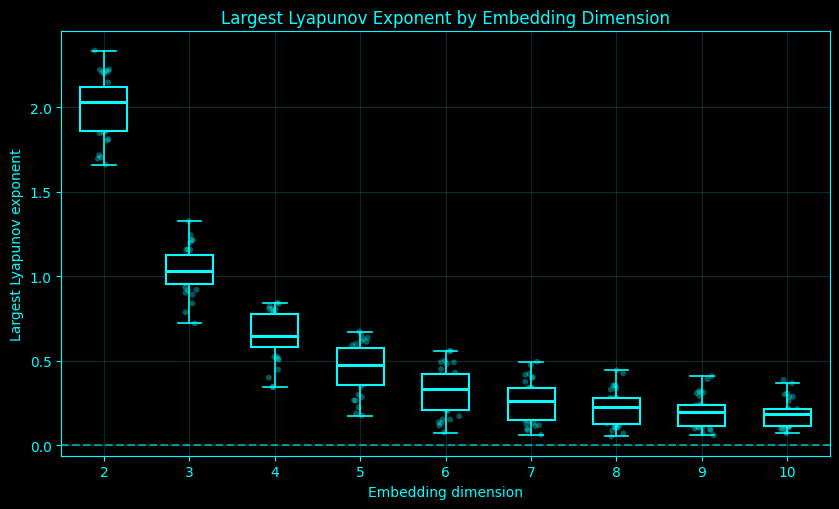

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots/01_lle_by_embedding_dimension.png


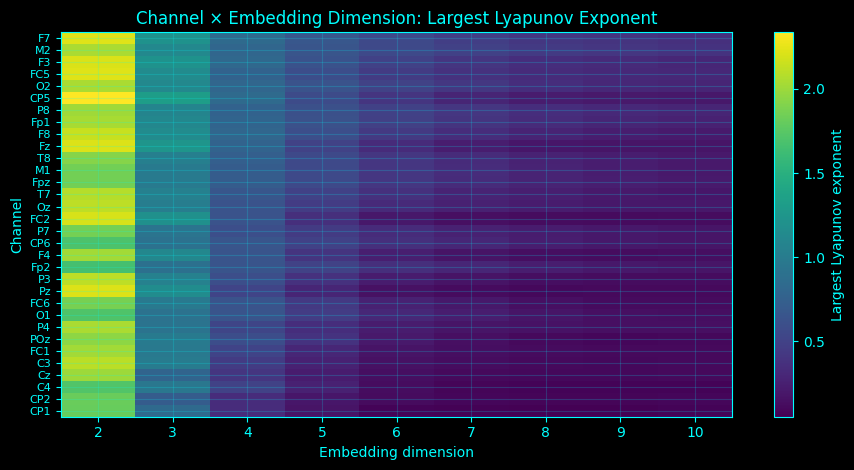

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots/02_channel_by_dimension_lle_heatmap.png


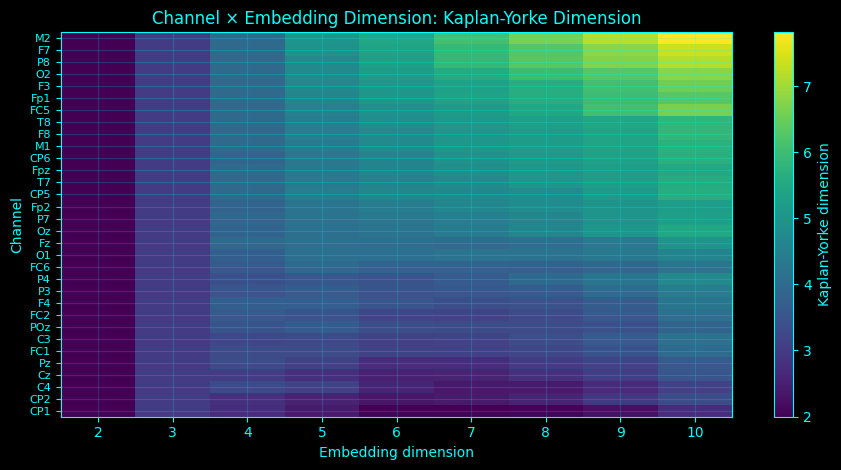

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots/03_channel_by_dimension_ky_heatmap.png


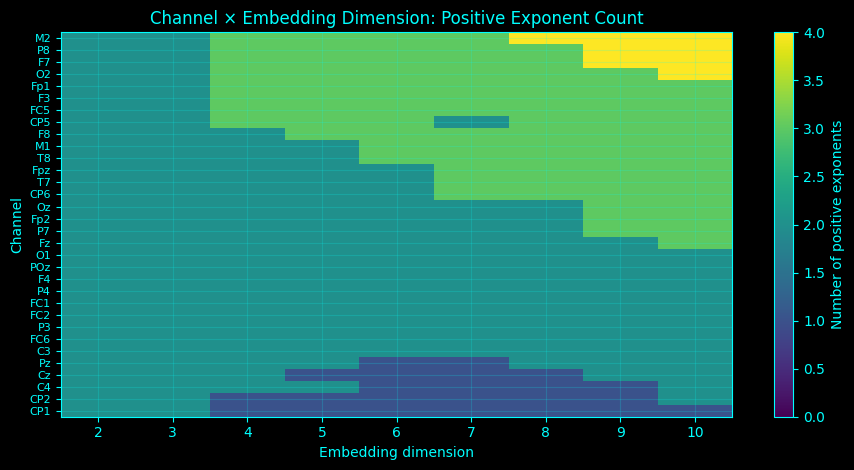

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots/04_channel_by_dimension_positive_count_heatmap.png


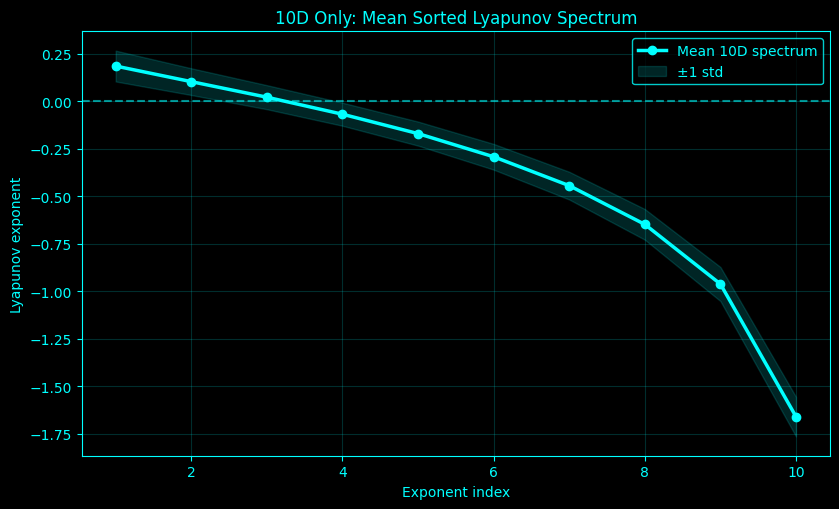

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots/05_10d_mean_sorted_lyapunov_spectrum.png


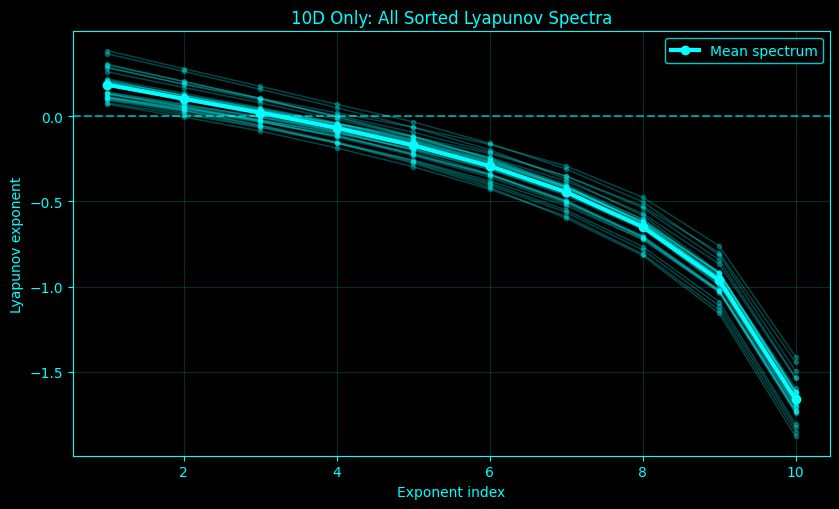

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots/06_10d_all_sorted_lyapunov_spectra.png


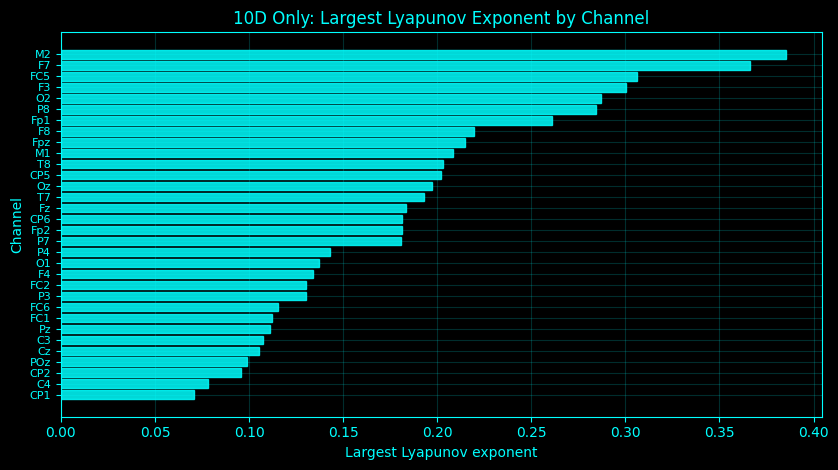

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots/07_10d_lle_by_channel.png


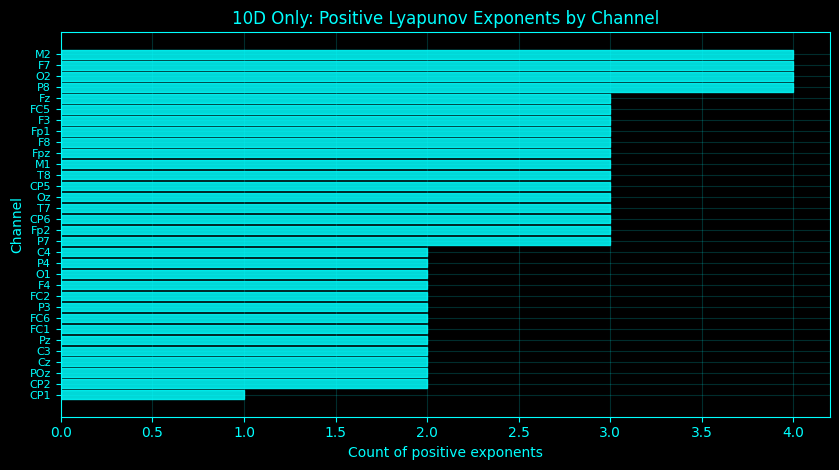

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots/08_10d_positive_count_by_channel.png


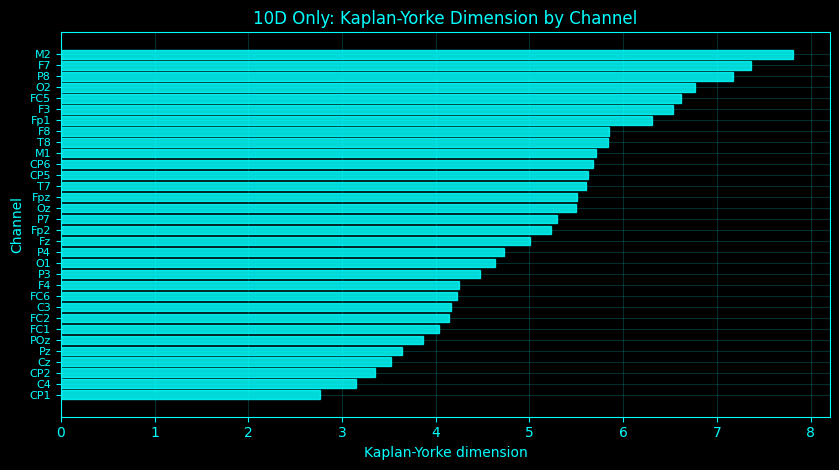

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots/09_10d_ky_dimension_by_channel.png


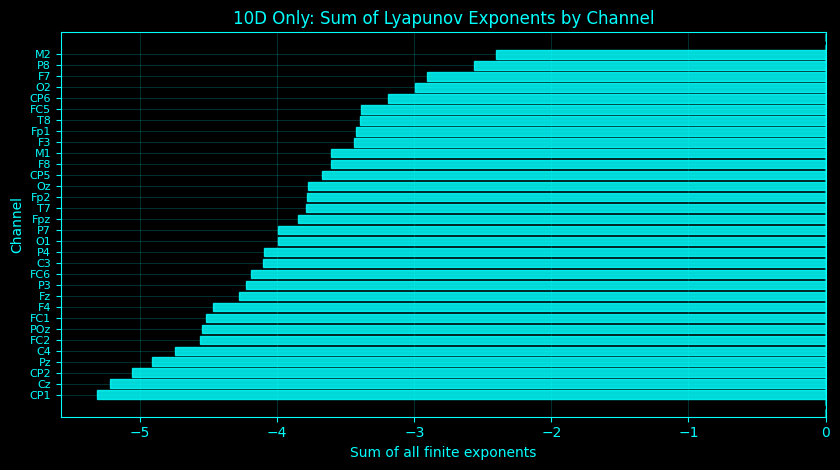

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots/10_10d_divergence_by_channel.png


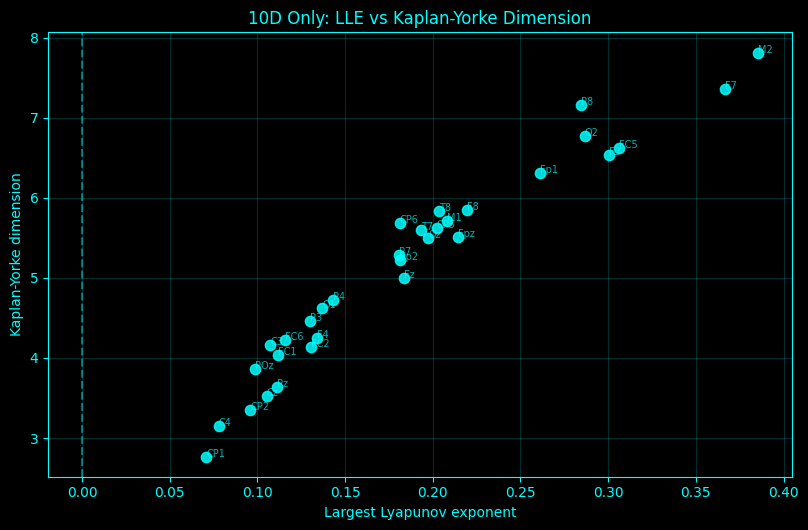

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots/11_10d_lle_vs_ky_dimension.png


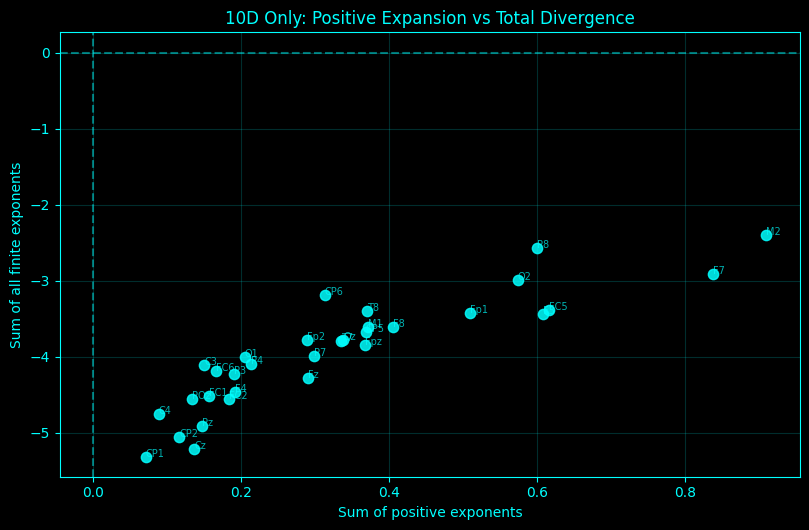

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots/12_10d_sum_positive_vs_divergence.png


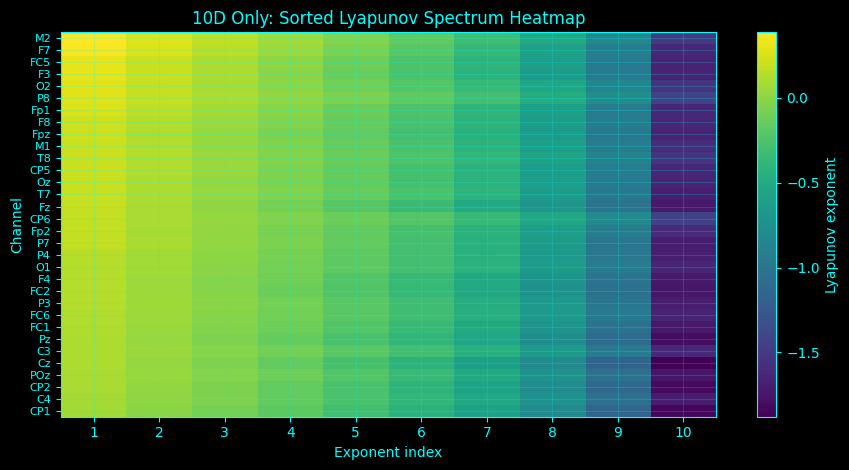

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots/13_10d_sorted_spectrum_heatmap.png


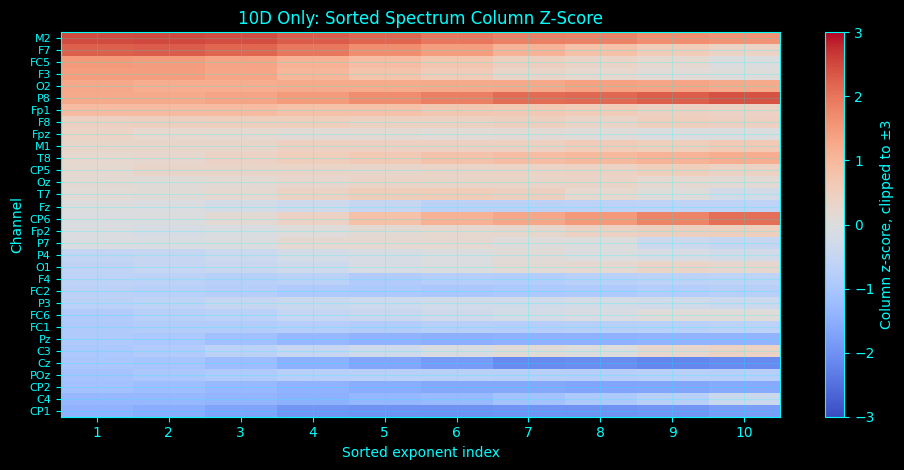

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots/14_10d_sorted_spectrum_column_zscore.png


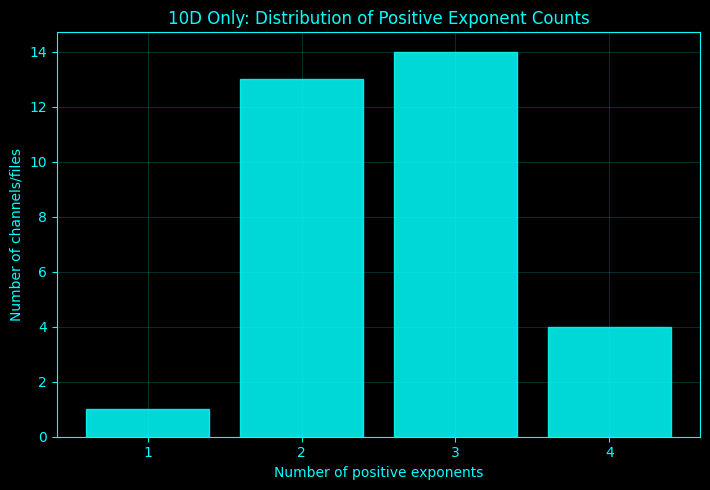

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots/15_10d_distribution_positive_counts.png

Done.
Input CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/lyap_spectrum_20260603_013142.csv
Selected dimension: 10
Plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots
All-dimension summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_all_dimensions_summary.csv
Target-dimension summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_10d_only_summary.csv
NaN-safe sorted spectra CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_nan_safe_sorted_spectra.csv


In [1]:
import os
import re
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

# Preferred raw CSV. If missing, code will search for a usable one.
CSV_PATH = os.path.join(
    base_dir,
    "lyapunov_results_10D",
    "lyap_spectrum_10D_20260305_151303.csv"
)

SEARCH_FALLBACK = True

results_dir = os.path.join(base_dir, "results", "lyapunov_dimension_aware_summary")
plots_dir = os.path.join(results_dir, "plots")

os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

OUT_ALL_SUMMARY_CSV = os.path.join(results_dir, "lyapunov_all_dimensions_summary.csv")
OUT_10D_SUMMARY_CSV = os.path.join(results_dir, "lyapunov_10d_only_summary.csv")
OUT_SORTED_SPECTRA_CSV = os.path.join(results_dir, "lyapunov_nan_safe_sorted_spectra.csv")

# If 10D is missing, analyze the largest available dimension.
TARGET_DIMENSION = 10

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=220):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)


def compact_height(n_rows, per_row=0.14, min_h=4.8, max_h=6.8):
    """
    Keeps plots readable without becoming huge.
    """
    return float(min(max_h, max(min_h, per_row * max(n_rows, 1))))


def set_compact_yticks(ax, labels, max_labels=32, fontsize=8):
    """
    Show a compact subset of y tick labels when there are many rows.
    """
    labels = list(labels)
    n = len(labels)

    if n == 0:
        return

    if n <= max_labels:
        ticks = np.arange(n)
        shown = labels
    else:
        step = int(np.ceil(n / max_labels))
        ticks = np.arange(0, n, step)
        shown = [labels[i] for i in ticks]

    ax.set_yticks(ticks)
    ax.set_yticklabels(shown, fontsize=fontsize)


def compact_barh(
    ax,
    labels,
    values,
    xerr=None,
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.85,
    max_labels=32,
):
    labels = list(labels)
    values = np.asarray(values, dtype=float)
    y = np.arange(len(labels))

    ax.barh(
        y,
        values,
        xerr=xerr,
        color=color,
        edgecolor=edgecolor,
        alpha=alpha,
    )

    set_compact_yticks(ax, labels, max_labels=max_labels, fontsize=8)


# -------------------------------------------------------
# HEARTBEAT
# -------------------------------------------------------
last_heartbeat = time.time()

def heartbeat(message, every_sec=10, force=False):
    global last_heartbeat
    now = time.time()

    if force or (now - last_heartbeat >= every_sec):
        print(message, flush=True)
        last_heartbeat = now


# -------------------------------------------------------
# FILE HELPERS
# -------------------------------------------------------
def csv_has_lyapunov_columns(path):
    """
    Check whether a CSV has Exp* or SortedExp* columns.
    """
    try:
        header = pd.read_csv(path, nrows=0).columns
    except Exception:
        return False

    has_raw = any(c.startswith("Exp") and c[3:].isdigit() for c in header)
    has_sorted = any(c.startswith("SortedExp") and c[9:].isdigit() for c in header)

    return has_raw or has_sorted


def find_latest_lyapunov_csv(base_dir):
    """
    Find a usable Lyapunov spectrum CSV.

    Preference:
    1. raw lyap_spectrum*.csv files
    2. already-sorted spectrum CSVs
    """
    raw_patterns = [
        os.path.join(base_dir, "lyapunov_results_10D", "lyap_spectrum*.csv"),
        os.path.join(base_dir, "results", "**", "lyap_spectrum*.csv"),
        os.path.join(base_dir, "**", "lyap_spectrum*.csv"),
    ]

    sorted_patterns = [
        os.path.join(base_dir, "results", "**", "*sorted_spectra*.csv"),
        os.path.join(base_dir, "**", "*sorted_spectra*.csv"),
    ]

    bad_names = [
        "summary_metrics",
        "expert_group_summary",
        "top_outliers",
        "channel_summary",
        "enriched",
    ]

    def collect(patterns):
        out = []
        for pattern in patterns:
            out.extend(glob.glob(pattern, recursive=True))
        out = sorted(set(out), key=lambda p: os.path.getmtime(p), reverse=True)
        return out

    def clean(paths):
        cleaned = []
        for p in paths:
            name = os.path.basename(p).lower()
            if any(bad in name for bad in bad_names):
                continue
            if csv_has_lyapunov_columns(p):
                cleaned.append(p)
        return cleaned

    raw_clean = clean(collect(raw_patterns))
    if len(raw_clean) > 0:
        return raw_clean[0]

    sorted_clean = clean(collect(sorted_patterns))
    if len(sorted_clean) > 0:
        return sorted_clean[0]

    raise FileNotFoundError(
        "Could not find a usable Lyapunov CSV with Exp1... or SortedExp1... columns."
    )


# -------------------------------------------------------
# ANALYSIS HELPERS
# -------------------------------------------------------
def infer_channel_from_stem(stem):
    stem = str(stem)

    if "dembedded_" in stem:
        return stem.split("dembedded_", 1)[1]

    if "_" in stem:
        return stem.split("_")[-1]

    return stem


def infer_embedding_dimension(row, exp_cols):
    """
    Infer embedding dimension safely.

    Priority:
    1. filename/stem prefix like 10dembedded_C3
    2. embedding_dimension column
    3. state_dim column
    4. number of finite exponent values
    """
    for key in ["stem", "file"]:
        if key in row.index:
            text = str(row[key])
            m = re.match(r"^(\d+)dembedded_", text)
            if m:
                return int(m.group(1))

    if "embedding_dimension" in row.index and pd.notna(row["embedding_dimension"]):
        try:
            return int(row["embedding_dimension"])
        except Exception:
            pass

    if "state_dim" in row.index and pd.notna(row["state_dim"]):
        try:
            return int(row["state_dim"])
        except Exception:
            pass

    vals = pd.to_numeric(row[exp_cols], errors="coerce").to_numpy(dtype=float)
    return int(np.isfinite(vals).sum())


def nan_safe_sort_desc(row_values, target_len=None):
    """
    Sort finite values descending and put NaNs at the end.
    This avoids NaNs corrupting sorted spectra.
    """
    row_values = np.asarray(row_values, dtype=float)
    finite = row_values[np.isfinite(row_values)]
    finite = np.sort(finite)[::-1]

    if target_len is None:
        target_len = len(row_values)

    out = np.full(target_len, np.nan, dtype=float)
    out[:min(len(finite), target_len)] = finite[:target_len]

    return out


def ky_dim_row(lam):
    """
    Kaplan-Yorke / Lyapunov dimension from a descending-sorted spectrum.
    Ignores NaNs.
    """
    lam = np.asarray(lam, dtype=float)
    lam = lam[np.isfinite(lam)]

    if len(lam) == 0:
        return np.nan

    cs = np.cumsum(lam)
    valid = np.where(cs >= 0)[0]

    if len(valid) == 0:
        return 0.0

    j = valid[-1]

    if j == len(lam) - 1:
        return float(len(lam))

    denom = lam[j + 1]

    if not np.isfinite(denom) or denom == 0:
        return float(j + 1)

    return float((j + 1) + cs[j] / abs(denom))


def safe_numeric_matrix(df, cols):
    X = df[cols].copy()

    for c in cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")

    return X.to_numpy(dtype=float)


def column_zscore(Z):
    Z = np.asarray(Z, dtype=float)
    mu = np.nanmean(Z, axis=0, keepdims=True)
    sd = np.nanstd(Z, axis=0, keepdims=True) + 1e-12
    return (Z - mu) / sd


def build_summary_from_dataframe(df_ok, exp_cols):
    """
    Build dimension-aware summary using NaN-safe sorted spectra.
    """
    E_input = safe_numeric_matrix(df_ok, exp_cols)

    valid_rows = np.isfinite(E_input).any(axis=1)
    df_valid = df_ok.loc[valid_rows].copy()
    E_input = E_input[valid_rows]

    if len(df_valid) == 0:
        raise ValueError("No valid Lyapunov spectra after removing all-NaN rows.")

    max_exp = E_input.shape[1]

    E_sorted = np.vstack([
        nan_safe_sort_desc(row, target_len=max_exp)
        for row in E_input
    ])

    if "stem" in df_valid.columns:
        stems = df_valid["stem"].astype(str).values
    elif "file" in df_valid.columns:
        stems = df_valid["file"].astype(str).str.replace(".npy", "", regex=False).values
    else:
        stems = np.array([f"row_{i}" for i in range(len(df_valid))], dtype=object)

    if "channel" in df_valid.columns:
        channels = df_valid["channel"].astype(str).values
    else:
        channels = np.array([infer_channel_from_stem(s) for s in stems], dtype=object)

    embedding_dims = np.array(
        [infer_embedding_dimension(row, exp_cols) for _, row in df_valid.iterrows()],
        dtype=int
    )

    n_pos = np.array([
        int(np.sum(row[np.isfinite(row)] > 0))
        for row in E_sorted
    ])

    sum_pos = np.array([
        float(np.sum(row[np.isfinite(row) & (row > 0)]))
        for row in E_sorted
    ])

    divergence = np.array([
        float(np.sum(row[np.isfinite(row)]))
        for row in E_sorted
    ])

    ky_dim = np.array([ky_dim_row(row) for row in E_sorted], dtype=float)

    lle = np.array([
        float(np.nanmax(row)) if np.isfinite(row).any() else np.nan
        for row in E_sorted
    ])

    most_negative = np.array([
        float(np.nanmin(row)) if np.isfinite(row).any() else np.nan
        for row in E_sorted
    ])

    spectrum_width = lle - most_negative
    hyperchaotic_flag = n_pos >= 2

    summary = pd.DataFrame({
        "stem": stems,
        "channel": channels,
        "embedding_dimension": embedding_dims,
        "LLE": lle,
        "n_positive_exponents": n_pos,
        "sum_positive_exponents": sum_pos,
        "divergence_sum_all_exponents": divergence,
        "KY_dimension": ky_dim,
        "most_negative_exponent": most_negative,
        "spectrum_width": spectrum_width,
        "hyperchaotic_candidate": hyperchaotic_flag,
    })

    for i in range(max_exp):
        summary[f"SortedExp{i + 1}"] = E_sorted[:, i]

    input_df = df_valid.copy()
    input_df["_stem_clean"] = stems
    input_df["_channel_clean"] = channels
    input_df["_embedding_dimension_clean"] = embedding_dims

    return summary, E_input, E_sorted, input_df


# -------------------------------------------------------
# LOAD CSV
# -------------------------------------------------------
if not os.path.exists(CSV_PATH):
    if SEARCH_FALLBACK:
        print("Exact CSV not found. Searching for latest usable Lyapunov CSV...", flush=True)
        CSV_PATH = find_latest_lyapunov_csv(base_dir)
    else:
        raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

if not csv_has_lyapunov_columns(CSV_PATH):
    if SEARCH_FALLBACK:
        print("CSV exists but has no Exp*/SortedExp* columns. Searching fallback...", flush=True)
        CSV_PATH = find_latest_lyapunov_csv(base_dir)
    else:
        raise ValueError(f"CSV has no Exp*/SortedExp* columns: {CSV_PATH}")

heartbeat(f"Loading Lyapunov CSV: {CSV_PATH}", force=True)

df = pd.read_csv(CSV_PATH)

if "status" in df.columns:
    df_ok = df[df["status"].astype(str).str.lower() == "ok"].copy()
else:
    df_ok = df.copy()
    df_ok["status"] = "ok"

if len(df_ok) == 0:
    raise ValueError("No rows with status == 'ok' found.")

# -------------------------------------------------------
# FIND EXPONENT COLUMNS
# -------------------------------------------------------
raw_exp_cols = [f"Exp{i}" for i in range(1, 51)]
sorted_exp_cols = [f"SortedExp{i}" for i in range(1, 51)]

exp_cols = [c for c in raw_exp_cols if c in df_ok.columns]
using_sorted_input = False

if len(exp_cols) == 0:
    exp_cols = [c for c in sorted_exp_cols if c in df_ok.columns]
    using_sorted_input = True

if len(exp_cols) == 0:
    raise ValueError("No exponent columns found. Expected Exp1... or SortedExp1... columns.")

# Keep up to 10 exponent columns
exp_cols = exp_cols[:10]

if using_sorted_input:
    print(f"Using already-sorted input columns: {exp_cols}", flush=True)
else:
    print(f"Using raw input exponent columns: {exp_cols}", flush=True)

# -------------------------------------------------------
# BUILD DIMENSION-AWARE SUMMARY
# -------------------------------------------------------
summary_all, E_input, E_sorted, input_df = build_summary_from_dataframe(df_ok, exp_cols)

sorted_cols = [c for c in summary_all.columns if c.startswith("SortedExp")]
n_exp = len(sorted_cols)

summary_all = summary_all.sort_values(
    ["embedding_dimension", "channel", "stem"],
    ascending=[True, True, True]
).reset_index(drop=True)

summary_all.to_csv(OUT_ALL_SUMMARY_CSV, index=False)

sorted_spectra_df = summary_all[
    ["stem", "channel", "embedding_dimension"] + sorted_cols
].copy()
sorted_spectra_df.to_csv(OUT_SORTED_SPECTRA_CSV, index=False)

available_dims = sorted(summary_all["embedding_dimension"].dropna().unique())

if TARGET_DIMENSION in available_dims:
    selected_dim = TARGET_DIMENSION
else:
    selected_dim = int(max(available_dims))
    print(
        f"Requested TARGET_DIMENSION={TARGET_DIMENSION} not found. "
        f"Using largest available dimension: {selected_dim}",
        flush=True
    )

summary_target = summary_all[summary_all["embedding_dimension"] == selected_dim].copy()
summary_target = summary_target.sort_values("LLE", ascending=False).reset_index(drop=True)
summary_target.to_csv(OUT_10D_SUMMARY_CSV, index=False)

print("\nSaved all-dimension summary CSV:", OUT_ALL_SUMMARY_CSV, flush=True)
print("Saved target-dimension summary CSV:", OUT_10D_SUMMARY_CSV, flush=True)
print("Saved NaN-safe sorted spectra CSV:", OUT_SORTED_SPECTRA_CSV, flush=True)

print("\nInput CSV:", CSV_PATH)
print("Available embedding dimensions:", available_dims)
print("Selected dimension for clean single-dimension plots:", selected_dim)

print(f"\nTop 12 rows for {selected_dim}D by largest Lyapunov exponent:")
print(
    summary_target[
        [
            "stem",
            "channel",
            "embedding_dimension",
            "LLE",
            "n_positive_exponents",
            "sum_positive_exponents",
            "divergence_sum_all_exponents",
            "KY_dimension",
        ]
    ].head(12).to_string(index=False)
)

print(f"\n{selected_dim}D summary statistics:")
print(
    summary_target[
        [
            "LLE",
            "n_positive_exponents",
            "sum_positive_exponents",
            "divergence_sum_all_exponents",
            "KY_dimension",
            "spectrum_width",
        ]
    ].describe().to_string()
)

print(
    f"\n{selected_dim}D hyperchaotic candidates n_pos >= 2:",
    int(summary_target["hyperchaotic_candidate"].sum()),
    "of",
    len(summary_target),
)

# -------------------------------------------------------
# PLOT 1: LLE BY EMBEDDING DIMENSION
# -------------------------------------------------------
dim_values = sorted(summary_all["embedding_dimension"].dropna().unique())

data_by_dim = [
    summary_all.loc[summary_all["embedding_dimension"] == d, "LLE"].to_numpy(dtype=float)
    for d in dim_values
]

fig, ax = plt.subplots(figsize=(8.5, 5.2), facecolor=BG)
style_ax(ax)

bp = ax.boxplot(
    data_by_dim,
    positions=np.arange(len(dim_values)),
    widths=0.55,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set(facecolor=BG, edgecolor=ACCENT, linewidth=1.5)
for whisker in bp["whiskers"]:
    whisker.set(color=ACCENT, linewidth=1.2)
for cap in bp["caps"]:
    cap.set(color=ACCENT, linewidth=1.2)
for median in bp["medians"]:
    median.set(color=ACCENT, linewidth=2.2)

rng = np.random.default_rng(42)

for i, vals in enumerate(data_by_dim):
    jitter = rng.normal(0, 0.055, size=len(vals))
    ax.scatter(
        np.full(len(vals), i) + jitter,
        vals,
        color=ACCENT,
        alpha=0.35,
        s=18,
        edgecolor="none",
    )

ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.55)

ax.set_xticks(np.arange(len(dim_values)))
ax.set_xticklabels([str(int(d)) for d in dim_values])

ax.set_title("Largest Lyapunov Exponent by Embedding Dimension")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Largest Lyapunov exponent")

plot_path = os.path.join(plots_dir, "01_lle_by_embedding_dimension.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 2: CHANNEL × DIMENSION LLE HEATMAP
# -------------------------------------------------------
lle_pivot = summary_all.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="LLE",
    aggfunc="mean",
)

lle_pivot = lle_pivot.loc[lle_pivot.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(
    figsize=(9.2, compact_height(len(lle_pivot), per_row=0.13)),
    facecolor=BG,
)
style_ax(ax)

im = ax.imshow(
    lle_pivot.to_numpy(dtype=float),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
)

ax.set_title("Channel × Embedding Dimension: Largest Lyapunov Exponent")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Channel")

ax.set_xticks(np.arange(len(lle_pivot.columns)))
ax.set_xticklabels([str(int(c)) for c in lle_pivot.columns])

set_compact_yticks(ax, lle_pivot.index.values, max_labels=32, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Largest Lyapunov exponent")
style_colorbar(cbar)

plot_path = os.path.join(plots_dir, "02_channel_by_dimension_lle_heatmap.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 3: CHANNEL × DIMENSION KY DIMENSION HEATMAP
# -------------------------------------------------------
ky_pivot = summary_all.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="KY_dimension",
    aggfunc="mean",
)

ky_pivot = ky_pivot.loc[ky_pivot.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(
    figsize=(9.2, compact_height(len(ky_pivot), per_row=0.13)),
    facecolor=BG,
)
style_ax(ax)

im = ax.imshow(
    ky_pivot.to_numpy(dtype=float),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
)

ax.set_title("Channel × Embedding Dimension: Kaplan-Yorke Dimension")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Channel")

ax.set_xticks(np.arange(len(ky_pivot.columns)))
ax.set_xticklabels([str(int(c)) for c in ky_pivot.columns])

set_compact_yticks(ax, ky_pivot.index.values, max_labels=32, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Kaplan-Yorke dimension")
style_colorbar(cbar)

plot_path = os.path.join(plots_dir, "03_channel_by_dimension_ky_heatmap.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 4: CHANNEL × DIMENSION POSITIVE EXPONENT COUNT
# -------------------------------------------------------
npos_pivot = summary_all.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="n_positive_exponents",
    aggfunc="mean",
)

npos_pivot = npos_pivot.loc[npos_pivot.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(
    figsize=(9.2, compact_height(len(npos_pivot), per_row=0.13)),
    facecolor=BG,
)
style_ax(ax)

im = ax.imshow(
    npos_pivot.to_numpy(dtype=float),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    vmin=0,
)

ax.set_title("Channel × Embedding Dimension: Positive Exponent Count")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Channel")

ax.set_xticks(np.arange(len(npos_pivot.columns)))
ax.set_xticklabels([str(int(c)) for c in npos_pivot.columns])

set_compact_yticks(ax, npos_pivot.index.values, max_labels=32, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of positive exponents")
style_colorbar(cbar)

plot_path = os.path.join(plots_dir, "04_channel_by_dimension_positive_count_heatmap.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# TARGET-DIMENSION CLEAN DATA
# -------------------------------------------------------
target_sorted = summary_target[sorted_cols].to_numpy(dtype=float)
target_sorted = np.vstack([
    nan_safe_sort_desc(row, target_len=n_exp)
    for row in target_sorted
])

# Keep only exponent positions actually present in this dimension
valid_exp_mask = np.isfinite(target_sorted).any(axis=0)
target_sorted_valid = target_sorted[:, valid_exp_mask]
target_sorted_cols_valid = [c for c, keep in zip(sorted_cols, valid_exp_mask) if keep]
n_exp_target = target_sorted_valid.shape[1]

x = np.arange(1, n_exp_target + 1)

mean_spec = np.nanmean(target_sorted_valid, axis=0)
std_spec = np.nanstd(target_sorted_valid, axis=0)

# -------------------------------------------------------
# PLOT 5: TARGET-DIMENSION MEAN LYAPUNOV SPECTRUM
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.5, 5.2), facecolor=BG)
style_ax(ax)

ax.plot(
    x,
    mean_spec,
    marker="o",
    linewidth=2.5,
    color=ACCENT,
    label=f"Mean {selected_dim}D spectrum",
)

ax.fill_between(
    x,
    mean_spec - std_spec,
    mean_spec + std_spec,
    color=ACCENT,
    alpha=0.15,
    label="±1 std",
)

ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.55)

ax.set_title(f"{selected_dim}D Only: Mean Sorted Lyapunov Spectrum")
ax.set_xlabel("Exponent index")
ax.set_ylabel("Lyapunov exponent")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, f"05_{selected_dim}d_mean_sorted_lyapunov_spectrum.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 6: TARGET-DIMENSION ALL SORTED SPECTRA
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.5, 5.2), facecolor=BG)
style_ax(ax)

for row in target_sorted_valid:
    ax.plot(
        x,
        row,
        color=ACCENT,
        alpha=0.28,
        linewidth=1.1,
        marker="o",
        markersize=3,
    )

ax.plot(
    x,
    mean_spec,
    color=ACCENT,
    linewidth=3.0,
    marker="o",
    label="Mean spectrum",
)

ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.55)

ax.set_title(f"{selected_dim}D Only: All Sorted Lyapunov Spectra")
ax.set_xlabel("Exponent index")
ax.set_ylabel("Lyapunov exponent")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, f"06_{selected_dim}d_all_sorted_lyapunov_spectra.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 7: TARGET-DIMENSION LLE BY CHANNEL
# -------------------------------------------------------
plot_df = summary_target.sort_values("LLE", ascending=True)

fig, ax = plt.subplots(
    figsize=(8.5, compact_height(len(plot_df))),
    facecolor=BG,
)
style_ax(ax)

compact_barh(ax, plot_df["channel"], plot_df["LLE"])
ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.55)

ax.set_title(f"{selected_dim}D Only: Largest Lyapunov Exponent by Channel")
ax.set_xlabel("Largest Lyapunov exponent")
ax.set_ylabel("Channel")

plot_path = os.path.join(plots_dir, f"07_{selected_dim}d_lle_by_channel.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 8: TARGET-DIMENSION POSITIVE EXPONENT COUNT
# -------------------------------------------------------
plot_df = summary_target.sort_values("n_positive_exponents", ascending=True)

fig, ax = plt.subplots(
    figsize=(8.5, compact_height(len(plot_df))),
    facecolor=BG,
)
style_ax(ax)

compact_barh(ax, plot_df["channel"], plot_df["n_positive_exponents"])

ax.set_title(f"{selected_dim}D Only: Positive Lyapunov Exponents by Channel")
ax.set_xlabel("Count of positive exponents")
ax.set_ylabel("Channel")

plot_path = os.path.join(plots_dir, f"08_{selected_dim}d_positive_count_by_channel.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 9: TARGET-DIMENSION KY DIMENSION BY CHANNEL
# -------------------------------------------------------
plot_df = summary_target.sort_values("KY_dimension", ascending=True)

fig, ax = plt.subplots(
    figsize=(8.5, compact_height(len(plot_df))),
    facecolor=BG,
)
style_ax(ax)

compact_barh(ax, plot_df["channel"], plot_df["KY_dimension"])

ax.set_title(f"{selected_dim}D Only: Kaplan-Yorke Dimension by Channel")
ax.set_xlabel("Kaplan-Yorke dimension")
ax.set_ylabel("Channel")

plot_path = os.path.join(plots_dir, f"09_{selected_dim}d_ky_dimension_by_channel.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 10: TARGET-DIMENSION DIVERGENCE BY CHANNEL
# -------------------------------------------------------
plot_df = summary_target.sort_values("divergence_sum_all_exponents", ascending=True)

fig, ax = plt.subplots(
    figsize=(8.5, compact_height(len(plot_df))),
    facecolor=BG,
)
style_ax(ax)

compact_barh(ax, plot_df["channel"], plot_df["divergence_sum_all_exponents"])
ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.55)

ax.set_title(f"{selected_dim}D Only: Sum of Lyapunov Exponents by Channel")
ax.set_xlabel("Sum of all finite exponents")
ax.set_ylabel("Channel")

plot_path = os.path.join(plots_dir, f"10_{selected_dim}d_divergence_by_channel.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 11: TARGET-DIMENSION LLE VS KY DIMENSION
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.2, 5.4), facecolor=BG)
style_ax(ax)

ax.scatter(
    summary_target["LLE"],
    summary_target["KY_dimension"],
    color=ACCENT,
    edgecolor=ACCENT,
    s=55,
    alpha=0.85,
)

for _, row in summary_target.iterrows():
    ax.text(
        row["LLE"],
        row["KY_dimension"],
        str(row["channel"]),
        color=ACCENT,
        fontsize=7,
        alpha=0.7,
    )

ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.45)

ax.set_title(f"{selected_dim}D Only: LLE vs Kaplan-Yorke Dimension")
ax.set_xlabel("Largest Lyapunov exponent")
ax.set_ylabel("Kaplan-Yorke dimension")

plot_path = os.path.join(plots_dir, f"11_{selected_dim}d_lle_vs_ky_dimension.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 12: TARGET-DIMENSION SUM POSITIVE VS DIVERGENCE
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.2, 5.4), facecolor=BG)
style_ax(ax)

ax.scatter(
    summary_target["sum_positive_exponents"],
    summary_target["divergence_sum_all_exponents"],
    color=ACCENT,
    edgecolor=ACCENT,
    s=55,
    alpha=0.85,
)

for _, row in summary_target.iterrows():
    ax.text(
        row["sum_positive_exponents"],
        row["divergence_sum_all_exponents"],
        str(row["channel"]),
        color=ACCENT,
        fontsize=7,
        alpha=0.7,
    )

ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.45)
ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.45)

ax.set_title(f"{selected_dim}D Only: Positive Expansion vs Total Divergence")
ax.set_xlabel("Sum of positive exponents")
ax.set_ylabel("Sum of all finite exponents")

plot_path = os.path.join(plots_dir, f"12_{selected_dim}d_sum_positive_vs_divergence.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 13: TARGET-DIMENSION SORTED SPECTRUM HEATMAP
# -------------------------------------------------------
heat_df = summary_target.sort_values("LLE", ascending=True)
heat_matrix = heat_df[target_sorted_cols_valid].to_numpy(dtype=float)

fig, ax = plt.subplots(
    figsize=(9.0, compact_height(len(heat_df), per_row=0.13)),
    facecolor=BG,
)
style_ax(ax)

im = ax.imshow(
    heat_matrix,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
)

ax.set_title(f"{selected_dim}D Only: Sorted Lyapunov Spectrum Heatmap")
ax.set_xlabel("Exponent index")
ax.set_ylabel("Channel")

ax.set_xticks(np.arange(n_exp_target))
ax.set_xticklabels([str(i + 1) for i in range(n_exp_target)])

set_compact_yticks(ax, heat_df["channel"].values, max_labels=32, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Lyapunov exponent")
style_colorbar(cbar)

plot_path = os.path.join(plots_dir, f"13_{selected_dim}d_sorted_spectrum_heatmap.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 14: TARGET-DIMENSION SORTED SPECTRUM COLUMN-Z-SCORED
# -------------------------------------------------------
Z_target_z = column_zscore(heat_matrix)
z_clip = 3.0
Z_target_z_clip = np.clip(Z_target_z, -z_clip, z_clip)

fig, ax = plt.subplots(
    figsize=(9.8, compact_height(len(heat_df), per_row=0.13)),
    facecolor=BG,
)
style_ax(ax)

im = ax.imshow(
    Z_target_z_clip,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=-z_clip,
    vmax=z_clip,
)

ax.set_title(f"{selected_dim}D Only: Sorted Spectrum Column Z-Score")
ax.set_xlabel("Sorted exponent index")
ax.set_ylabel("Channel")

ax.set_xticks(np.arange(n_exp_target))
ax.set_xticklabels([str(i + 1) for i in range(n_exp_target)])

set_compact_yticks(ax, heat_df["channel"].values, max_labels=32, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f"Column z-score, clipped to ±{z_clip:g}")
style_colorbar(cbar)

plot_path = os.path.join(plots_dir, f"14_{selected_dim}d_sorted_spectrum_column_zscore.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 15: TARGET-DIMENSION POSITIVE COUNT DISTRIBUTION
# -------------------------------------------------------
counts = summary_target["n_positive_exponents"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7.2, 5.0), facecolor=BG)
style_ax(ax)

ax.bar(
    counts.index.astype(str),
    counts.values,
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.85,
)

ax.set_title(f"{selected_dim}D Only: Distribution of Positive Exponent Counts")
ax.set_xlabel("Number of positive exponents")
ax.set_ylabel("Number of channels/files")

plot_path = os.path.join(plots_dir, f"15_{selected_dim}d_distribution_positive_counts.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# FINAL PRINT
# -------------------------------------------------------
print("\nDone.")
print("Input CSV:", CSV_PATH)
print("Selected dimension:", selected_dim)
print("Plots saved to:", plots_dir)
print("All-dimension summary CSV:", OUT_ALL_SUMMARY_CSV)
print("Target-dimension summary CSV:", OUT_10D_SUMMARY_CSV)
print("NaN-safe sorted spectra CSV:", OUT_SORTED_SPECTRA_CSV)

# Contrast-Enhanced Lyapunov Spectrum Heatmap via Column-wise Z-Score Normalization (10D)

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block renders a contrast-enhanced heatmap of the Lyapunov spectrum by applying <b>column-wise z-score normalization</b> prior to visualization.
            Raw Lyapunov spectra frequently exhibit large magnitude differences across exponent indices (e.g., strongly negative tail exponents),
            which can dominate global color scaling and visually suppress meaningful variation in smaller-magnitude components (notably <code>Exp1</code> near zero).
            Standardizing each exponent column independently makes inter-channel deviations visible for every exponent index.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            Let <code>Z</code> denote the Lyapunov spectrum matrix of shape <code>(n_channels, D)</code>, where each column corresponds to exponent index <code>k</code>
            (e.g., <code>Exp1</code>…<code>Exp10</code>). The code standardizes each column using:
        </p>
        \[
            Z^{(z)}_{i,k} = \frac{Z_{i,k} - \mu_k}{\sigma_k + \epsilon}
        \]
        <p>
            where:
            <ul>
                <li><code>\mu_k</code> is the mean of exponent column <code>k</code> across channels,</li>
                <li><code>\sigma_k</code> is the standard deviation of exponent column <code>k</code> across channels,</li>
                <li><code>\epsilon</code> is a numerical stabilizer (<code>1e-12</code>) to avoid division by zero when <code>\sigma_k</code> is extremely small.</li>
            </ul>
            This yields a dimensionless matrix in which each exponent index has comparable variance, enabling fair visual comparison of channels within each exponent dimension.
        </p>
        <h2>Why Column-wise Standardization is Appropriate Here</h2>
        <p>
            The objective is to emphasize <b>relative channel-to-channel deviations</b> for each exponent index, not to preserve absolute exponent magnitudes across indices.
            Column z-scoring answers the diagnostic question:
            <i>“For exponent <code>k</code>, which channels are unusually high or low compared to the cohort?”</i>
            This is especially useful when:
            <ul>
                <li>Large-magnitude negative exponents dominate the raw heatmap scale,</li>
                <li>The LLE (<code>Exp1</code>) varies subtly but carries primary dynamical significance,</li>
                <li>You want to identify outlier channels per exponent dimension for targeted inspection.</li>
            </ul>
        </p>
        <h2>Interpretation of Z-Scores</h2>
        <p>
            After normalization, each cell is interpreted as a standardized deviation:
            <ul>
                <li><b>+2</b>: approximately two standard deviations above the mean for that exponent index,</li>
                <li><b>0</b>: typical relative to other channels for that exponent index,</li>
                <li><b>-2</b>: approximately two standard deviations below the mean for that exponent index.</li>
            </ul>
            Because z-scores are unitless, this view is ideal for comparative diagnostics and outlier discovery, while absolute dynamical quantities should be read from the raw (non-normalized) spectrum.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Assemble</b> the spectrum matrix <code>Z</code> from <code>df_ok</code> with <code>stem</code> as the row index and <code>Exp*</code> as columns.</li>
                <li><b>Compute</b> column-wise mean (<code>mu</code>) and standard deviation (<code>sd</code>) across channels.</li>
                <li><b>Standardize</b> each column to produce <code>Zz</code> (z-scored spectrum matrix).</li>
                <li><b>Visualize</b> <code>Zz</code> using <code>matplotlib.imshow</code> with a diverging colormap.</li>
            </ol>
            Axis labels preserve the spectrum-per-channel semantics while the normalization improves visual sensitivity to differences.
        </p>
        <h2>Color Scaling Choice</h2>
        <p>
            The plot fixes <code>vmin=-3</code> and <code>vmax=3</code>, which:
            <ul>
                <li>treats ±3σ deviations as “extreme,”</li>
                <li>reduces the influence of rare outliers on the colormap,</li>
                <li>keeps interpretation consistent across runs and datasets.</li>
            </ul>
            Values outside ±3σ saturate at the ends of the colormap, improving comparability and avoiding rescaling artifacts.
        </p>
        <h2>What This Plot Reveals (and What It Hides)</h2>
        <p>
            <b>Reveals:</b>
            <ul>
                <li>Exponent-specific channel outliers (unusually unstable/stable channels for a given exponent index),</li>
                <li>Structured deviations concentrated in early vs. late exponents,</li>
                <li>Potential artifact-driven channels that diverge systematically from the cohort.</li>
            </ul>
            <b>Hides:</b>
            <ul>
                <li>Absolute differences in magnitude between exponent indices (the raw spectrum “shape”),</li>
                <li>Physical units of the exponents (per-sample or per-second), since the display is standardized.</li>
            </ul>
            Use the raw spectrum heatmap or numeric summaries for reporting actual Lyapunov values; use the z-scored heatmap for sensitive comparative diagnostics.
        </p>
        <h2>Practical Next Steps</h2>
        <p>
            Common expert follow-ups include:
            (i) ranking channels by z-scored <code>Exp1</code> to flag atypically chaotic channels,
            (ii) clustering channels using <code>Zz</code> to discover groups with similar dynamical signatures,
            and (iii) validating that outliers persist across time segments (segmentation/bootstrapping) to separate estimator noise from stable physiological structure.
        </p>
    </div>
</div>

Loading saved Lyapunov results from: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_10d_only_summary.csv
Using exponent columns: ['SortedExp1', 'SortedExp2', 'SortedExp3', 'SortedExp4', 'SortedExp5', 'SortedExp6', 'SortedExp7', 'SortedExp8', 'SortedExp9', 'SortedExp10']


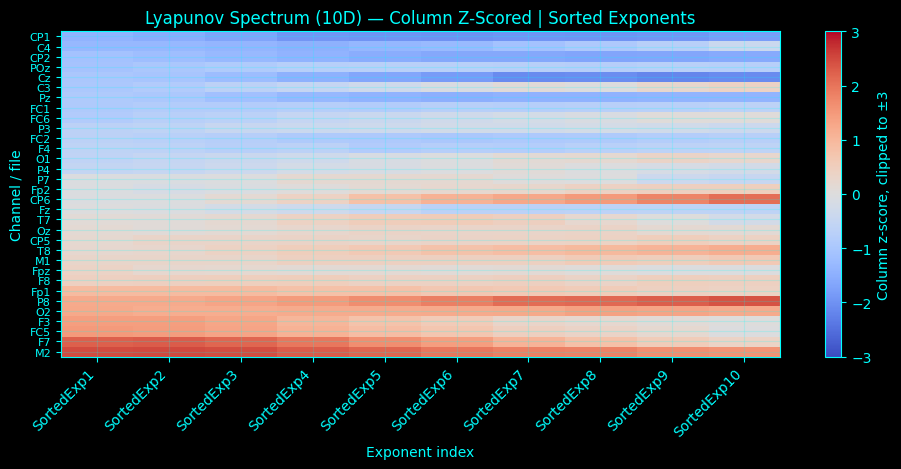

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots_from_saved_files/saved_file_column_zscore_heatmap_10d.png


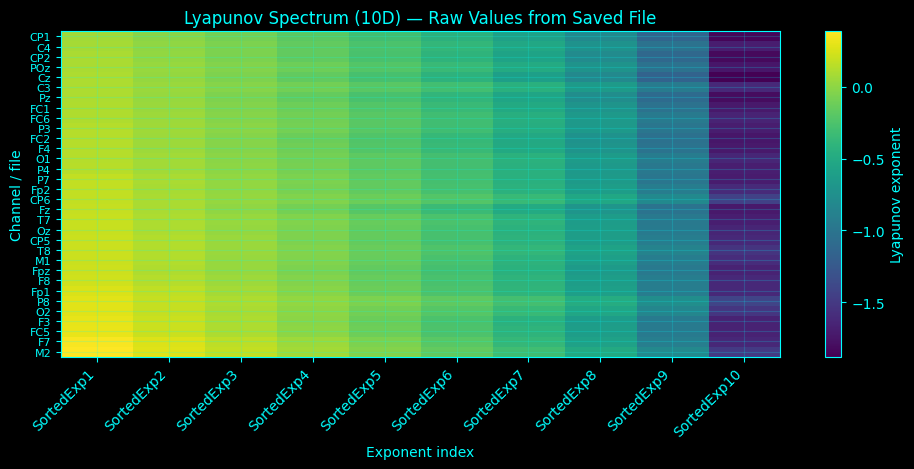

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots_from_saved_files/saved_file_raw_lyapunov_heatmap_10d.png

Done.
Input results CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_10d_only_summary.csv
Plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots_from_saved_files
Plotted matrix CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots_from_saved_files/saved_file_plotted_lyapunov_matrix_10d.csv
Z-score matrix CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots_from_saved_files/saved_file_plotted_lyapunov_matrix_zscore_10d.csv


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

results_dir = os.path.join(base_dir, "results", "lyapunov_dimension_aware_summary")
plots_dir = os.path.join(results_dir, "plots_from_saved_files")
os.makedirs(plots_dir, exist_ok=True)

# Prefer the clean target-dimension summary created by the previous block.
PREFERRED_CSV = os.path.join(results_dir, "lyapunov_10d_only_summary.csv")

# Fallbacks if the preferred file is missing.
FALLBACK_CSVS = [
    os.path.join(results_dir, "lyapunov_all_dimensions_summary.csv"),
    os.path.join(results_dir, "lyapunov_nan_safe_sorted_spectra.csv"),
]

TARGET_DIMENSION = 10

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=220):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)


def compact_height(n_rows, per_row=0.13, min_h=4.8, max_h=6.8):
    return float(min(max_h, max(min_h, per_row * max(n_rows, 1))))


def set_compact_yticks(ax, labels, max_labels=32, fontsize=8):
    labels = list(labels)
    n = len(labels)

    if n == 0:
        return

    if n <= max_labels:
        ticks = np.arange(n)
        shown = labels
    else:
        step = int(np.ceil(n / max_labels))
        ticks = np.arange(0, n, step)
        shown = [labels[i] for i in ticks]

    ax.set_yticks(ticks)
    ax.set_yticklabels(shown, fontsize=fontsize)


# -------------------------------------------------------
# LOAD RESULTS FROM FILE
# -------------------------------------------------------
def find_results_csv():
    if os.path.exists(PREFERRED_CSV):
        return PREFERRED_CSV

    for path in FALLBACK_CSVS:
        if os.path.exists(path):
            return path

    matches = glob.glob(
        os.path.join(base_dir, "results", "**", "lyapunov*summary*.csv"),
        recursive=True
    )

    matches = sorted(matches, key=lambda p: os.path.getmtime(p), reverse=True)

    for path in matches:
        try:
            cols = pd.read_csv(path, nrows=0).columns
            has_sorted = any(c.startswith("SortedExp") for c in cols)
            has_raw = any(c.startswith("Exp") and c[3:].isdigit() for c in cols)
            if has_sorted or has_raw:
                return path
        except Exception:
            pass

    raise FileNotFoundError(
        "Could not find a saved Lyapunov results CSV. "
        "Run the dimension-aware Lyapunov summary block first."
    )


CSV_PATH = find_results_csv()
print("Loading saved Lyapunov results from:", CSV_PATH, flush=True)

df = pd.read_csv(CSV_PATH)

# -------------------------------------------------------
# FILTER TO TARGET DIMENSION IF AVAILABLE
# -------------------------------------------------------
if "embedding_dimension" in df.columns:
    df["embedding_dimension"] = pd.to_numeric(df["embedding_dimension"], errors="coerce")

    if (df["embedding_dimension"] == TARGET_DIMENSION).any():
        df_plot_source = df[df["embedding_dimension"] == TARGET_DIMENSION].copy()
        selected_dim = TARGET_DIMENSION
    else:
        selected_dim = int(df["embedding_dimension"].dropna().max())
        df_plot_source = df[df["embedding_dimension"] == selected_dim].copy()
        print(
            f"TARGET_DIMENSION={TARGET_DIMENSION} not found. "
            f"Using largest available dimension: {selected_dim}",
            flush=True
        )
else:
    df_plot_source = df.copy()
    selected_dim = None

if len(df_plot_source) == 0:
    raise ValueError("No rows available for plotting after filtering.")

# -------------------------------------------------------
# FIND EXPONENT COLUMNS FROM SAVED FILE
# -------------------------------------------------------
sorted_exp_cols = [f"SortedExp{i}" for i in range(1, 51)]
raw_exp_cols = [f"Exp{i}" for i in range(1, 51)]

exp_cols = [c for c in sorted_exp_cols if c in df_plot_source.columns]
using_sorted = True

if len(exp_cols) == 0:
    exp_cols = [c for c in raw_exp_cols if c in df_plot_source.columns]
    using_sorted = False

if len(exp_cols) == 0:
    raise ValueError(
        "No exponent columns found in saved file. Expected SortedExp1... or Exp1..."
    )

# Keep only columns with at least one finite value.
valid_exp_cols = []

for c in exp_cols:
    vals = pd.to_numeric(df_plot_source[c], errors="coerce").to_numpy(dtype=float)
    if np.isfinite(vals).any():
        valid_exp_cols.append(c)

exp_cols = valid_exp_cols

if len(exp_cols) == 0:
    raise ValueError("All exponent columns were empty/NaN.")

print("Using exponent columns:", exp_cols, flush=True)

# -------------------------------------------------------
# BUILD ROW LABELS
# -------------------------------------------------------
if "channel" in df_plot_source.columns:
    row_labels = df_plot_source["channel"].astype(str).values
elif "stem" in df_plot_source.columns:
    row_labels = df_plot_source["stem"].astype(str).values
else:
    row_labels = np.array([f"row_{i}" for i in range(len(df_plot_source))], dtype=object)

if "LLE" in df_plot_source.columns:
    df_plot_source["LLE"] = pd.to_numeric(df_plot_source["LLE"], errors="coerce")
    df_plot_source = df_plot_source.sort_values("LLE", ascending=True)
elif "stem" in df_plot_source.columns:
    df_plot_source = df_plot_source.sort_values("stem")
else:
    df_plot_source = df_plot_source.reset_index(drop=True)

if "channel" in df_plot_source.columns:
    row_labels = df_plot_source["channel"].astype(str).values
elif "stem" in df_plot_source.columns:
    row_labels = df_plot_source["stem"].astype(str).values
else:
    row_labels = np.array([f"row_{i}" for i in range(len(df_plot_source))], dtype=object)

# -------------------------------------------------------
# MATRIX + COLUMN Z-SCORE
# -------------------------------------------------------
Z_df = df_plot_source[exp_cols].copy()

for c in exp_cols:
    Z_df[c] = pd.to_numeric(Z_df[c], errors="coerce")

Z = Z_df.to_numpy(dtype=float)

mu = np.nanmean(Z, axis=0, keepdims=True)
sd = np.nanstd(Z, axis=0, keepdims=True) + 1e-12
Zz = (Z - mu) / sd

z_clip = 3.0
Zz_clip = np.clip(Zz, -z_clip, z_clip)

# Make NaNs display as black
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color=BG)

Zz_masked = np.ma.masked_invalid(Zz_clip)

# -------------------------------------------------------
# PLOT 1: COLUMN-Z-SCORED HEATMAP FROM SAVED FILE
# -------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(9.8, compact_height(Zz_masked.shape[0])),
    facecolor=BG
)
style_ax(ax)

im = ax.imshow(
    Zz_masked,
    aspect="auto",
    interpolation="nearest",
    cmap=cmap,
    vmin=-z_clip,
    vmax=z_clip
)

if selected_dim is not None:
    title = f"Lyapunov Spectrum ({selected_dim}D) — Column Z-Scored"
else:
    title = "Lyapunov Spectrum — Column Z-Scored"

if using_sorted:
    title += " | Sorted Exponents"
else:
    title += " | Raw Exponent Columns"

ax.set_title(title)
ax.set_ylabel("Channel / file")
ax.set_xlabel("Exponent index")

ax.set_xticks(np.arange(len(exp_cols)))
ax.set_xticklabels(exp_cols, rotation=45, ha="right")

set_compact_yticks(ax, row_labels, max_labels=32, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f"Column z-score, clipped to ±{z_clip:g}")
style_colorbar(cbar)

plot_path = os.path.join(
    plots_dir,
    f"saved_file_column_zscore_heatmap_{selected_dim if selected_dim is not None else 'all'}d.png"
)
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 2: RAW VALUE HEATMAP FROM SAVED FILE
# -------------------------------------------------------
Z_masked = np.ma.masked_invalid(Z)

fig, ax = plt.subplots(
    figsize=(9.8, compact_height(Z_masked.shape[0])),
    facecolor=BG
)
style_ax(ax)

im = ax.imshow(
    Z_masked,
    aspect="auto",
    interpolation="nearest"
)

if selected_dim is not None:
    title = f"Lyapunov Spectrum ({selected_dim}D) — Raw Values from Saved File"
else:
    title = "Lyapunov Spectrum — Raw Values from Saved File"

ax.set_title(title)
ax.set_ylabel("Channel / file")
ax.set_xlabel("Exponent index")

ax.set_xticks(np.arange(len(exp_cols)))
ax.set_xticklabels(exp_cols, rotation=45, ha="right")

set_compact_yticks(ax, row_labels, max_labels=32, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Lyapunov exponent")
style_colorbar(cbar)

plot_path = os.path.join(
    plots_dir,
    f"saved_file_raw_lyapunov_heatmap_{selected_dim if selected_dim is not None else 'all'}d.png"
)
save_show_close(fig, plot_path)

# -------------------------------------------------------
# SAVE THE PLOTTED MATRIX
# -------------------------------------------------------
out_matrix_csv = os.path.join(
    plots_dir,
    f"saved_file_plotted_lyapunov_matrix_{selected_dim if selected_dim is not None else 'all'}d.csv"
)

out_zscore_csv = os.path.join(
    plots_dir,
    f"saved_file_plotted_lyapunov_matrix_zscore_{selected_dim if selected_dim is not None else 'all'}d.csv"
)

matrix_out = pd.DataFrame(Z, columns=exp_cols)
matrix_out.insert(0, "row_label", row_labels)
matrix_out.to_csv(out_matrix_csv, index=False)

zscore_out = pd.DataFrame(Zz, columns=exp_cols)
zscore_out.insert(0, "row_label", row_labels)
zscore_out.to_csv(out_zscore_csv, index=False)

print("\nDone.")
print("Input results CSV:", CSV_PATH)
print("Plots saved to:", plots_dir)
print("Plotted matrix CSV:", out_matrix_csv)
print("Z-score matrix CSV:", out_zscore_csv)

# Population-Average Lyapunov Spectrum with Across-Channel Variability (Mean ± Std Envelope)

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block summarizes the Lyapunov spectra computed for multiple EEG channels (or files) by plotting the <b>population-average spectrum</b>
            alongside an uncertainty band representing <b>across-channel variability</b>. Rather than inspecting each channel’s spectrum individually,
            the figure provides a cohort-level “typical” dynamical profile and highlights how consistent (or heterogeneous) the spectrum is across channels.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            Let the Lyapunov spectrum for channel <code>i</code> be a vector <code>λ^{(i)} = (λ^{(i)}_1, …, λ^{(i)}_D)</code>.
            Since the canonical interpretation assumes ordered exponents (<code>λ_1 ≥ λ_2 ≥ … ≥ λ_D</code>), the code sorts each channel’s spectrum
            in descending order to obtain <code>Zs</code>. The across-channel mean and standard deviation are then computed for each index <code>k</code>:
        </p>
        \[
            \mu_k = \frac{1}{N}\sum_{i=1}^{N} \lambda^{(i)}_k,
            \qquad
            \sigma_k = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\left(\lambda^{(i)}_k - \mu_k\right)^2}
        \]
        <p>
            The plotted curve corresponds to <code>\mu_k</code> over exponent index <code>k</code>, and the shaded band corresponds to
            <code>\mu_k \pm \sigma_k</code>. A horizontal reference line at <code>0</code> marks the stability boundary separating
            expansion (<code>λ &gt; 0</code>) from contraction (<code>λ &lt; 0</code>).
        </p>
        <h2>Why Sorting Before Averaging is Essential</h2>
        <p>
            Averaging unsorted spectra is generally meaningless because exponent indices may be permuted or numerically unstable across channels.
            Sorting enforces a consistent semantic interpretation: index <code>1</code> corresponds to the largest exponent (LLE), index <code>2</code> to the
            second-largest, etc. This ensures that the mean curve truly reflects the “typical” ordered spectrum across channels.
        </p>
        <h2>Interpretation of the Mean Spectrum</h2>
        <p>
            The mean spectrum encodes the cohort’s average dynamical character:
            <ul>
                <li><b>Mean LLE &gt; 0</b>: on average, channels exhibit sensitivity to initial conditions (chaos-like instability).</li>
                <li><b>Mean spectrum strongly negative</b>: globally dissipative dynamics (overall contraction in state space).</li>
                <li><b>Near-zero exponents</b>: potentially neutral directions (common in flows or due to estimation/finite-data effects).</li>
            </ul>
            The shape (steepness of decay across indices) often reflects how rapidly the system contracts in subordinate directions.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Extract</b> the exponent matrix from <code>df_ok</code> (<code>n_channels × D</code>).</li>
                <li><b>Sort</b> each row descending to enforce canonical exponent ordering (<code>Zs</code>).</li>
                <li><b>Compute</b> the column-wise mean <code>m</code> and standard deviation <code>s</code> across channels.</li>
                <li><b>Plot</b> the mean spectrum and overlay a shaded <code>±1σ</code> envelope via <code>fill_between</code>.</li>
                <li><b>Reference</b> stability by drawing a horizontal line at <code>0</code>.</li>
            </ol>
            The x-axis is the exponent rank (sorted index), not a physical dimension, which makes the plot directly interpretable in dynamical-systems terms.
        </p>
        <h2>What the Variability Band Represents</h2>
        <p>
            The <code>±1σ</code> band reflects <b>heterogeneity across channels</b> at each exponent index:
            <ul>
                <li><b>Narrow band:</b> channels share a consistent spectral structure (similar dynamics or estimator behavior).</li>
                <li><b>Wide band:</b> substantial channel-to-channel differences (potential physiological variation, artifacts, or segment instability).</li>
            </ul>
            Note that <code>±1σ</code> is a descriptive spread, not a confidence interval; for inferential uncertainty you would use bootstrapping over time windows.
        </p>
        <h2>What This Plot Reveals (and What It Hides)</h2>
        <p>
            <b>Reveals:</b>
            <ul>
                <li>The cohort-level “typical” Lyapunov spectrum shape,</li>
                <li>Whether the largest exponent is robustly positive across channels,</li>
                <li>Which exponent ranks exhibit the greatest between-channel variability.</li>
            </ul>
            <b>Hides:</b>
            <ul>
                <li>Individual channel identities and outliers (those require per-channel plots or ranked tables),</li>
                <li>Temporal variability within channels (requires segmentation or bootstrap resampling over time),</li>
                <li>Correlations between exponents within a channel (requires multivariate analysis).</li>
            </ul>
        </p>
        <h2>Practical Next Steps</h2>
        <p>
            Common expert follow-ups include:
            (i) plotting the distribution of the LLE (<code>λ₁</code>) across channels,
            (ii) computing Kaplan–Yorke dimension from each channel spectrum and summarizing it similarly,
            and (iii) repeating the spectrum estimation over multiple time windows to test stability of the mean curve and its spread.
        </p>
    </div>
</div>

Loading saved Lyapunov results from: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_10d_only_summary.csv
Using exponent columns: ['SortedExp1', 'SortedExp2', 'SortedExp3', 'SortedExp4', 'SortedExp5', 'SortedExp6', 'SortedExp7', 'SortedExp8', 'SortedExp9', 'SortedExp10']


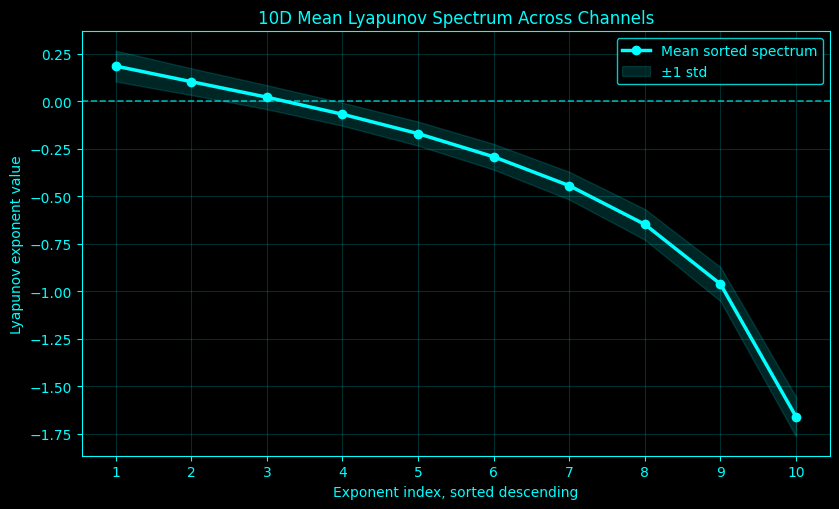

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots_from_saved_files/mean_lyapunov_spectrum_from_saved_file_10d.png

Done.
Input results CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_10d_only_summary.csv
Rows used: 32
Selected dimension: 10
Using sorted input columns: True
Plot saved to: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots_from_saved_files/mean_lyapunov_spectrum_from_saved_file_10d.png
Mean spectrum CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/plots_from_saved_files/mean_lyapunov_spectrum_from_saved_file_10d.csv


In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

results_dir = os.path.join(base_dir, "results", "lyapunov_dimension_aware_summary")
plots_dir = os.path.join(results_dir, "plots_from_saved_files")
os.makedirs(plots_dir, exist_ok=True)

# Prefer the clean summary created by the dimension-aware block
PREFERRED_CSV = os.path.join(results_dir, "lyapunov_10d_only_summary.csv")

FALLBACK_CSVS = [
    os.path.join(results_dir, "lyapunov_all_dimensions_summary.csv"),
    os.path.join(results_dir, "lyapunov_nan_safe_sorted_spectra.csv"),
]

TARGET_DIMENSION = 10

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def save_show_close(fig, out_path, dpi=220):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)


# -------------------------------------------------------
# LOAD SAVED RESULTS FROM FILE
# -------------------------------------------------------
def find_results_csv():
    if os.path.exists(PREFERRED_CSV):
        return PREFERRED_CSV

    for path in FALLBACK_CSVS:
        if os.path.exists(path):
            return path

    matches = glob.glob(
        os.path.join(base_dir, "results", "**", "lyapunov*.csv"),
        recursive=True
    )

    matches = sorted(matches, key=lambda p: os.path.getmtime(p), reverse=True)

    for path in matches:
        try:
            cols = pd.read_csv(path, nrows=0).columns
            has_sorted = any(c.startswith("SortedExp") for c in cols)
            has_raw = any(c.startswith("Exp") and c[3:].isdigit() for c in cols)

            if has_sorted or has_raw:
                return path

        except Exception:
            pass

    raise FileNotFoundError(
        "Could not find a saved Lyapunov results CSV. "
        "Run the dimension-aware Lyapunov summary block first."
    )


CSV_PATH = find_results_csv()
print("Loading saved Lyapunov results from:", CSV_PATH, flush=True)

df = pd.read_csv(CSV_PATH)

# -------------------------------------------------------
# FILTER TO TARGET DIMENSION IF AVAILABLE
# -------------------------------------------------------
selected_dim = None

if "embedding_dimension" in df.columns:
    df["embedding_dimension"] = pd.to_numeric(df["embedding_dimension"], errors="coerce")

    if (df["embedding_dimension"] == TARGET_DIMENSION).any():
        df_plot = df[df["embedding_dimension"] == TARGET_DIMENSION].copy()
        selected_dim = TARGET_DIMENSION
    else:
        selected_dim = int(df["embedding_dimension"].dropna().max())
        df_plot = df[df["embedding_dimension"] == selected_dim].copy()

        print(
            f"TARGET_DIMENSION={TARGET_DIMENSION} not found. "
            f"Using largest available dimension: {selected_dim}",
            flush=True
        )

else:
    df_plot = df.copy()

if len(df_plot) == 0:
    raise ValueError("No rows available for plotting after filtering.")

# -------------------------------------------------------
# FIND EXPONENT COLUMNS
# -------------------------------------------------------
sorted_exp_cols = [f"SortedExp{i}" for i in range(1, 51)]
raw_exp_cols = [f"Exp{i}" for i in range(1, 51)]

exp_cols = [c for c in sorted_exp_cols if c in df_plot.columns]
using_sorted = True

if len(exp_cols) == 0:
    exp_cols = [c for c in raw_exp_cols if c in df_plot.columns]
    using_sorted = False

if len(exp_cols) == 0:
    raise ValueError("No exponent columns found. Expected SortedExp1... or Exp1...")

# Keep only exponent columns with at least one finite value
valid_exp_cols = []

for c in exp_cols:
    vals = pd.to_numeric(df_plot[c], errors="coerce").to_numpy(dtype=float)

    if np.isfinite(vals).any():
        valid_exp_cols.append(c)

exp_cols = valid_exp_cols

if len(exp_cols) == 0:
    raise ValueError("All exponent columns are empty/NaN.")

print("Using exponent columns:", exp_cols, flush=True)

# -------------------------------------------------------
# NAN-SAFE SORTING
# -------------------------------------------------------
def nan_safe_sort_desc(row_values, target_len=None):
    """
    Sort finite Lyapunov exponents descending and put NaNs at the end.
    """
    row_values = np.asarray(row_values, dtype=float)

    finite = row_values[np.isfinite(row_values)]
    finite = np.sort(finite)[::-1]

    if target_len is None:
        target_len = len(row_values)

    out = np.full(target_len, np.nan, dtype=float)

    n = min(len(finite), target_len)
    out[:n] = finite[:n]

    return out


# -------------------------------------------------------
# BUILD MATRIX FROM SAVED FILE
# -------------------------------------------------------
Z_df = df_plot[exp_cols].copy()

for c in exp_cols:
    Z_df[c] = pd.to_numeric(Z_df[c], errors="coerce")

Z = Z_df.to_numpy(dtype=float)

Zs = np.vstack([
    nan_safe_sort_desc(row, target_len=Z.shape[1])
    for row in Z
])

# Remove exponent positions that are all NaN
valid_positions = np.isfinite(Zs).any(axis=0)
Zs = Zs[:, valid_positions]

if Zs.shape[1] == 0:
    raise ValueError("No valid exponent positions after NaN-safe sorting.")

# -------------------------------------------------------
# MEAN AND STD
# -------------------------------------------------------
m = np.nanmean(Zs, axis=0)
s = np.nanstd(Zs, axis=0)

x = np.arange(1, Zs.shape[1] + 1)

# -------------------------------------------------------
# PLOT: MEAN LYAPUNOV SPECTRUM
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.5, 5.2), facecolor=BG)
style_ax(ax)

ax.plot(
    x,
    m,
    marker="o",
    linewidth=2.5,
    color=ACCENT,
    label="Mean sorted spectrum"
)

ax.fill_between(
    x,
    m - s,
    m + s,
    color=ACCENT,
    alpha=0.15,
    label="±1 std"
)

ax.axhline(
    0,
    color=ACCENT,
    linestyle="--",
    linewidth=1.2,
    alpha=0.65
)

if selected_dim is not None:
    title = f"{selected_dim}D Mean Lyapunov Spectrum Across Channels"
else:
    title = "Mean Lyapunov Spectrum Across Saved Rows"

ax.set_title(title)
ax.set_xlabel("Exponent index, sorted descending")
ax.set_ylabel("Lyapunov exponent value")

ax.set_xticks(x)

leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(
    plots_dir,
    f"mean_lyapunov_spectrum_from_saved_file_{selected_dim if selected_dim is not None else 'all'}d.png"
)

save_show_close(fig, plot_path)

# -------------------------------------------------------
# SAVE MEAN SPECTRUM VALUES
# -------------------------------------------------------
out_csv = os.path.join(
    plots_dir,
    f"mean_lyapunov_spectrum_from_saved_file_{selected_dim if selected_dim is not None else 'all'}d.csv"
)

mean_df = pd.DataFrame({
    "exponent_index": x,
    "mean_exponent": m,
    "std_exponent": s,
    "mean_minus_std": m - s,
    "mean_plus_std": m + s,
})

mean_df.to_csv(out_csv, index=False)

# -------------------------------------------------------
# PRINT SUMMARY
# -------------------------------------------------------
print("\nDone.")
print("Input results CSV:", CSV_PATH)
print("Rows used:", len(df_plot))
print("Selected dimension:", selected_dim)
print("Using sorted input columns:", using_sorted)
print("Plot saved to:", plot_path)
print("Mean spectrum CSV:", out_csv)

Loading saved Lyapunov summary from: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_all_dimensions_summary.csv
Using exponent columns: ['SortedExp1', 'SortedExp2', 'SortedExp3', 'SortedExp4', 'SortedExp5', 'SortedExp6', 'SortedExp7', 'SortedExp8', 'SortedExp9', 'SortedExp10']
Using already-sorted exponent columns: True

Saved stability table, all dimensions: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_stability_all_dimensions_fixed.csv
Saved stability table, selected dimension: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_stability_10d_fixed.csv
Saved tolerance sweep: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_stability_tolerance_sweep.csv

Selected dimension: 10
Classification tolerance: 0.001

Candidate stability counts:
stability
multi_positive_candidate    31
chaotic_c

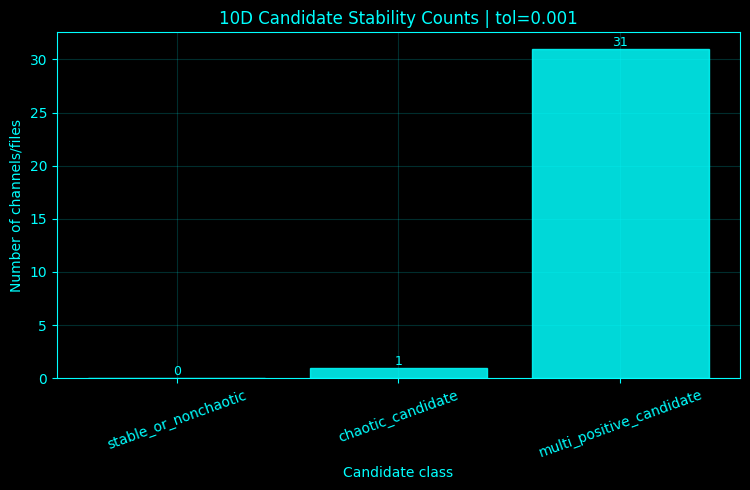

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/stability_plots_fixed_from_saved_files/01_10d_candidate_stability_counts.png


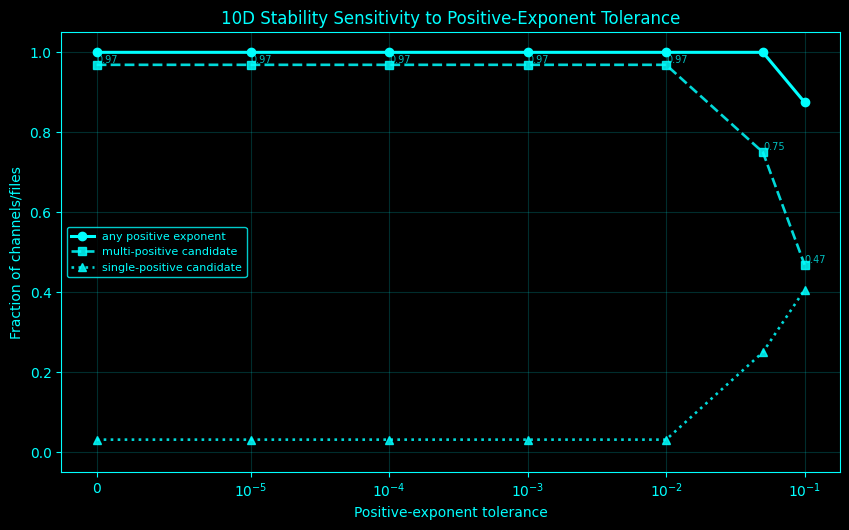

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/stability_plots_fixed_from_saved_files/02_10d_tolerance_sensitivity.png


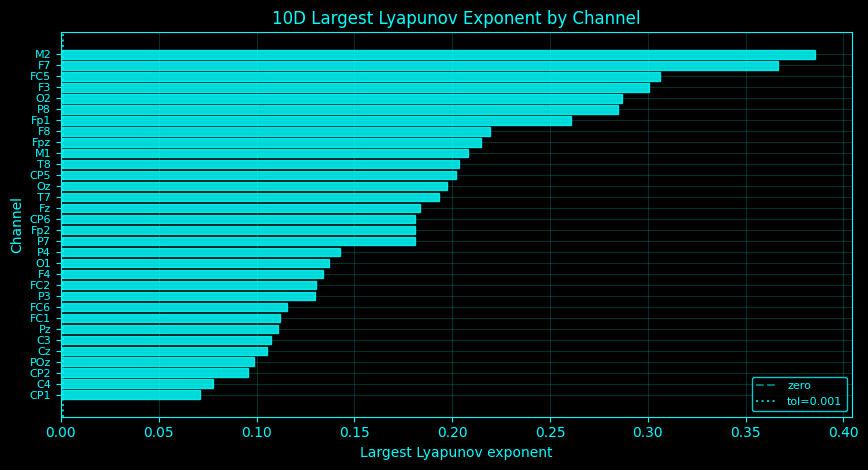

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/stability_plots_fixed_from_saved_files/03_10d_lle_by_channel_tolerance.png


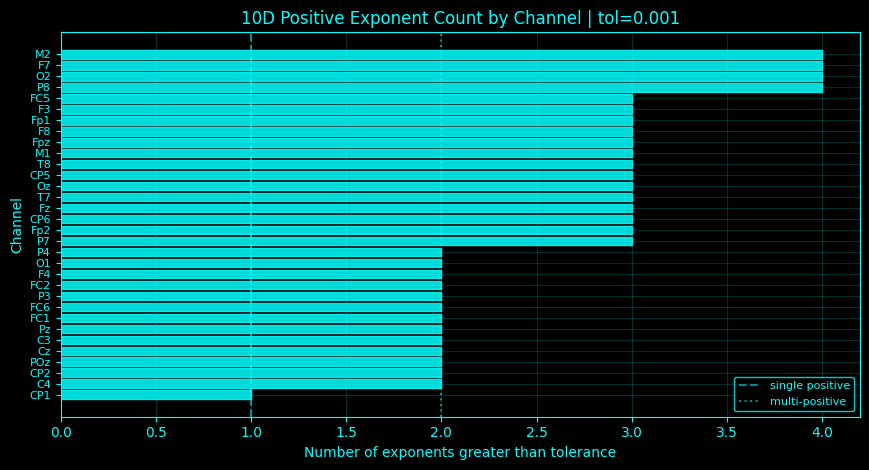

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/stability_plots_fixed_from_saved_files/04_10d_positive_count_by_channel_tolerance.png


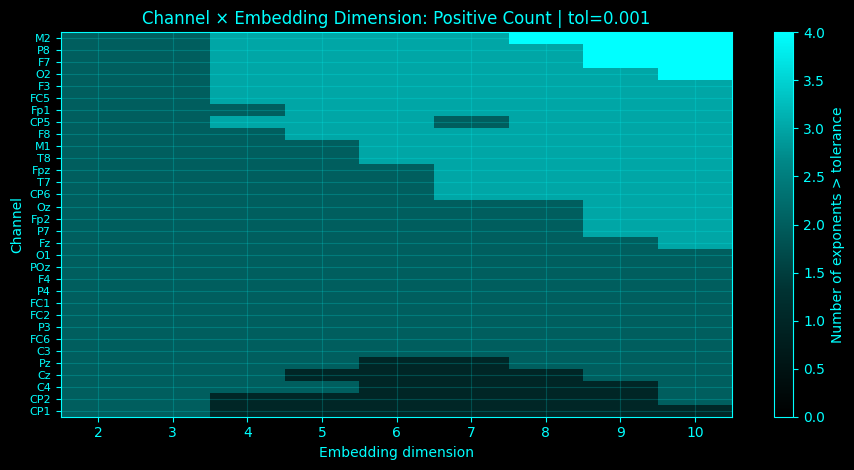

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/stability_plots_fixed_from_saved_files/05_channel_by_dimension_positive_count_heatmap.png


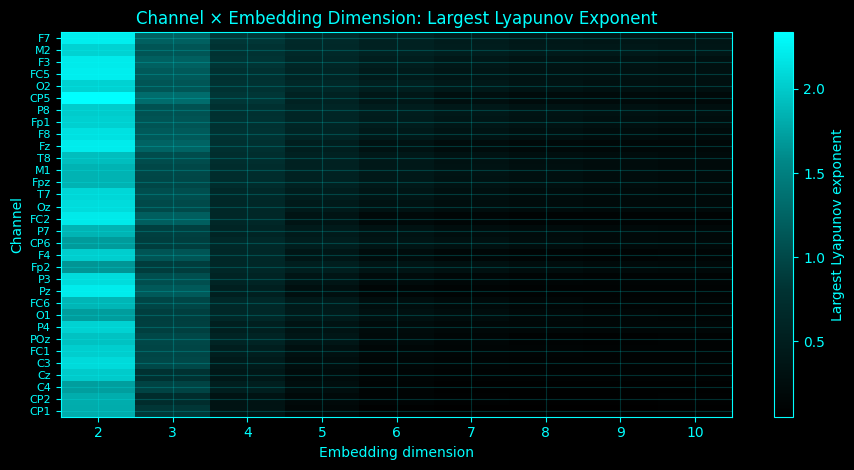

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/stability_plots_fixed_from_saved_files/06_channel_by_dimension_lle_heatmap.png


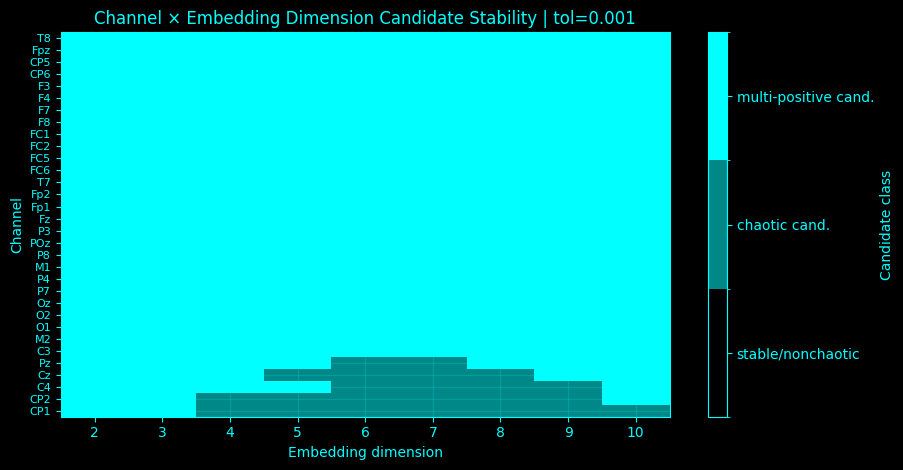

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/stability_plots_fixed_from_saved_files/07_channel_by_dimension_candidate_stability_heatmap.png


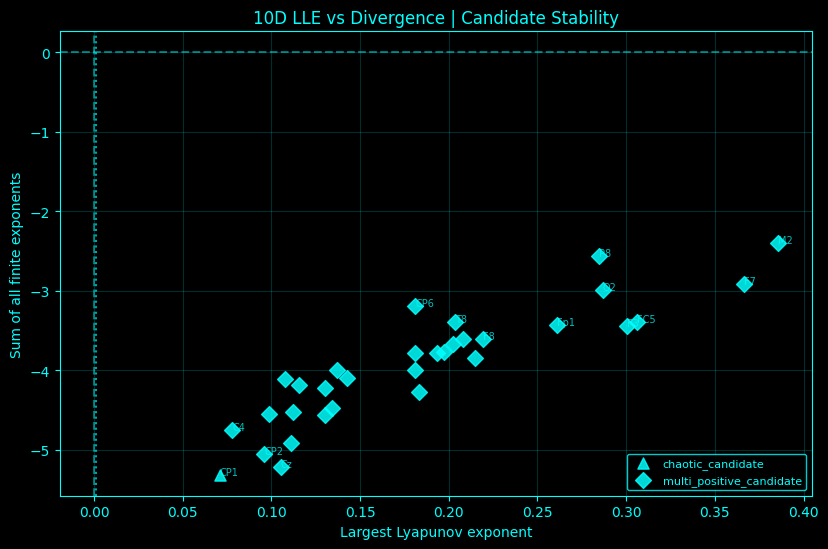

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/stability_plots_fixed_from_saved_files/08_10d_lle_vs_divergence_candidate_stability.png


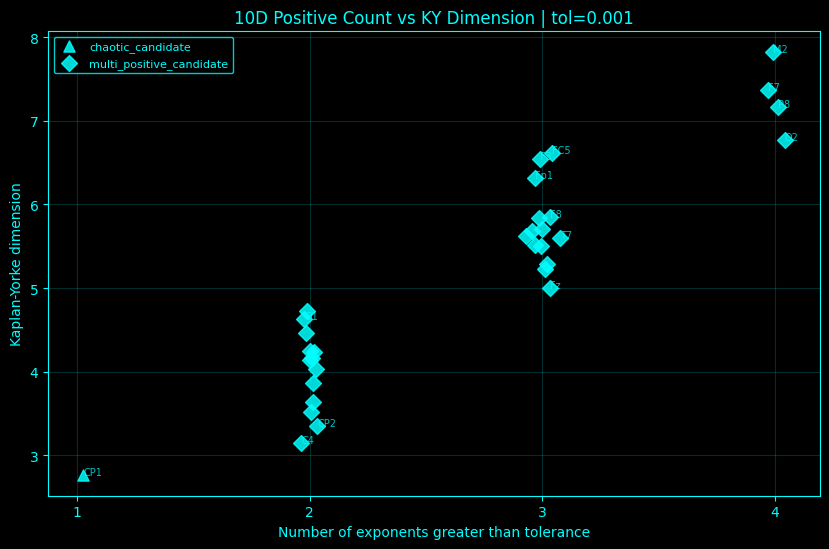

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/stability_plots_fixed_from_saved_files/09_10d_positive_count_vs_ky_dimension_jittered.png


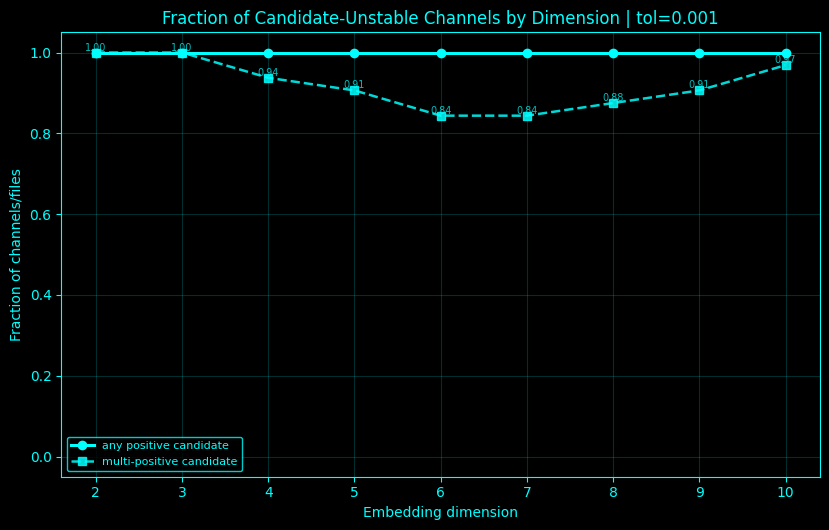

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/stability_plots_fixed_from_saved_files/10_fraction_candidate_unstable_by_dimension.png


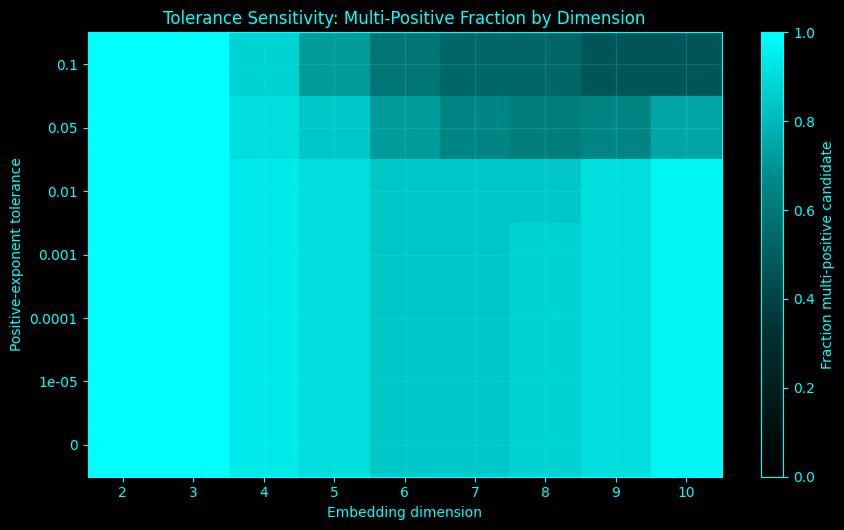

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/stability_plots_fixed_from_saved_files/11_tolerance_by_dimension_multi_positive_fraction.png

Done.
Input summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_all_dimensions_summary.csv
Selected dimension: 10
Classification tolerance: 0.001
All-dim stability CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_stability_all_dimensions_fixed.csv
Selected-dim stability CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_stability_10d_fixed.csv
Tolerance sweep CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_stability_tolerance_sweep.csv
By-dimension summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_dimension_aware_summary/lyapunov_stability_by_dimensi

In [7]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

results_dir = os.path.join(base_dir, "results", "lyapunov_dimension_aware_summary")
plots_dir = os.path.join(results_dir, "stability_plots_fixed_from_saved_files")
os.makedirs(plots_dir, exist_ok=True)

PREFERRED_ALL_DIM_CSV = os.path.join(results_dir, "lyapunov_all_dimensions_summary.csv")
PREFERRED_TARGET_DIM_CSV = os.path.join(results_dir, "lyapunov_10d_only_summary.csv")
PREFERRED_SORTED_CSV = os.path.join(results_dir, "lyapunov_nan_safe_sorted_spectra.csv")

TARGET_DIMENSION = 10

# Main classification threshold.
# Exponents must be greater than this to count as positive.
CLASSIFICATION_TOL = 1e-3

# Robustness sweep.
TOLERANCE_SWEEP = [0.0, 1e-5, 1e-4, 1e-3, 1e-2, 5e-2, 1e-1]

# Labeling controls for scatter plots
LABEL_TOP_N = 8
LABEL_BOTTOM_N = 3
RANDOM_SEED = 42

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=220):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)


def compact_height(n_rows, per_row=0.14, min_h=4.8, max_h=6.8):
    return float(min(max_h, max(min_h, per_row * max(n_rows, 1))))


def set_compact_yticks(ax, labels, max_labels=32, fontsize=8):
    labels = list(labels)
    n = len(labels)

    if n == 0:
        return

    if n <= max_labels:
        ticks = np.arange(n)
        shown = labels
    else:
        step = int(np.ceil(n / max_labels))
        ticks = np.arange(0, n, step)
        shown = [labels[i] for i in ticks]

    ax.set_yticks(ticks)
    ax.set_yticklabels(shown, fontsize=fontsize)


def compact_barh(ax, labels, values, xerr=None, max_labels=32):
    labels = list(labels)
    values = np.asarray(values, dtype=float)
    y = np.arange(len(labels))

    ax.barh(
        y,
        values,
        xerr=xerr,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.85
    )

    set_compact_yticks(ax, labels, max_labels=max_labels, fontsize=8)


def annotate_selected_points(ax, df, x_col, y_col, label_col="channel", top_n=8, bottom_n=3):
    """
    Avoids unreadable scatter plots by labeling only the strongest and weakest rows.
    """
    if len(df) == 0:
        return

    label_df = pd.concat([
        df.sort_values(y_col, ascending=False).head(top_n),
        df.sort_values(y_col, ascending=True).head(bottom_n),
        df.sort_values(x_col, ascending=False).head(top_n),
        df.sort_values(x_col, ascending=True).head(bottom_n),
    ]).drop_duplicates()

    for _, row in label_df.iterrows():
        ax.text(
            row[x_col],
            row[y_col],
            str(row[label_col]),
            color=ACCENT,
            fontsize=7,
            alpha=0.75
        )


# -------------------------------------------------------
# COLORMAPS
# -------------------------------------------------------
cyan_cmap = LinearSegmentedColormap.from_list(
    "black_to_cyan",
    ["black", "#003333", "#008888", "cyan"]
)

candidate_cmap = ListedColormap([
    "black",       # stable_or_nonchaotic
    "#008888",     # chaotic_candidate
    "cyan",        # multi_positive_candidate
])

candidate_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], candidate_cmap.N)

# -------------------------------------------------------
# FILE LOADING
# -------------------------------------------------------
def csv_has_useful_columns(path):
    try:
        cols = set(pd.read_csv(path, nrows=0).columns)
    except Exception:
        return False

    has_metrics = len({
        "LLE",
        "n_positive_exponents",
        "KY_dimension",
        "divergence_sum_all_exponents",
    }.intersection(cols)) >= 2

    has_exponents = any(c.startswith("SortedExp") for c in cols) or any(
        c.startswith("Exp") and c[3:].isdigit() for c in cols
    )

    return has_metrics or has_exponents


def find_saved_lyapunov_summary():
    preferred = [
        PREFERRED_ALL_DIM_CSV,
        PREFERRED_TARGET_DIM_CSV,
        PREFERRED_SORTED_CSV,
    ]

    for path in preferred:
        if os.path.exists(path) and csv_has_useful_columns(path):
            return path

    matches = glob.glob(
        os.path.join(base_dir, "results", "**", "lyapunov*.csv"),
        recursive=True
    )

    matches = sorted(matches, key=lambda p: os.path.getmtime(p), reverse=True)

    for path in matches:
        if csv_has_useful_columns(path):
            return path

    raise FileNotFoundError(
        "Could not find a saved Lyapunov summary CSV. "
        "Run the dimension-aware Lyapunov summary block first."
    )


CSV_PATH = find_saved_lyapunov_summary()
print("Loading saved Lyapunov summary from:", CSV_PATH, flush=True)

df = pd.read_csv(CSV_PATH)

# -------------------------------------------------------
# BASIC ANALYSIS HELPERS
# -------------------------------------------------------
def infer_channel_from_stem(stem):
    stem = str(stem)

    if "dembedded_" in stem:
        return stem.split("dembedded_", 1)[1]

    if "_" in stem:
        return stem.split("_")[-1]

    return stem


def infer_embedding_dimension_from_row(row, exp_cols):
    for key in ["stem", "file"]:
        if key in row.index:
            text = str(row[key])
            m = re.match(r"^(\d+)dembedded_", text)
            if m:
                return int(m.group(1))

    for key in ["embedding_dimension", "state_dim"]:
        if key in row.index and pd.notna(row[key]):
            try:
                return int(row[key])
            except Exception:
                pass

    vals = pd.to_numeric(row[exp_cols], errors="coerce").to_numpy(dtype=float)
    return int(np.isfinite(vals).sum())


def nan_safe_sort_desc(row_values, target_len=None):
    row_values = np.asarray(row_values, dtype=float)
    finite = row_values[np.isfinite(row_values)]
    finite = np.sort(finite)[::-1]

    if target_len is None:
        target_len = len(row_values)

    out = np.full(target_len, np.nan, dtype=float)
    n = min(len(finite), target_len)
    out[:n] = finite[:n]

    return out


def ky_dim_row(lam):
    lam = np.asarray(lam, dtype=float)
    lam = lam[np.isfinite(lam)]

    if len(lam) == 0:
        return np.nan

    cs = np.cumsum(lam)
    valid = np.where(cs >= 0)[0]

    if len(valid) == 0:
        return 0.0

    j = valid[-1]

    if j == len(lam) - 1:
        return float(len(lam))

    denom = lam[j + 1]

    if not np.isfinite(denom) or denom == 0:
        return float(j + 1)

    return float((j + 1) + cs[j] / abs(denom))


def classify_from_npos(n_positive):
    """
    Candidate labels are intentionally cautious:
    - stable_or_nonchaotic: no exponents greater than tolerance
    - chaotic_candidate: exactly one exponent greater than tolerance
    - multi_positive_candidate: two or more exponents greater than tolerance
    """
    if n_positive <= 0:
        return "stable_or_nonchaotic"
    if n_positive == 1:
        return "chaotic_candidate"
    return "multi_positive_candidate"


def stability_code(label):
    mapping = {
        "stable_or_nonchaotic": 0,
        "chaotic_candidate": 1,
        "multi_positive_candidate": 2,
    }
    return mapping.get(label, np.nan)


# -------------------------------------------------------
# FIND EXPONENT COLUMNS
# -------------------------------------------------------
sorted_exp_cols = [f"SortedExp{i}" for i in range(1, 51)]
raw_exp_cols = [f"Exp{i}" for i in range(1, 51)]

exp_cols = [c for c in sorted_exp_cols if c in df.columns]
using_sorted_exponents = True

if len(exp_cols) == 0:
    exp_cols = [c for c in raw_exp_cols if c in df.columns]
    using_sorted_exponents = False

if len(exp_cols) == 0:
    raise ValueError("No exponent columns found. Expected SortedExp1... or Exp1... columns.")

exp_cols = exp_cols[:10]

print("Using exponent columns:", exp_cols, flush=True)
print("Using already-sorted exponent columns:", using_sorted_exponents, flush=True)

# -------------------------------------------------------
# CLEAN / INFER REQUIRED COLUMNS
# -------------------------------------------------------
if "channel" not in df.columns:
    if "stem" in df.columns:
        df["channel"] = df["stem"].apply(infer_channel_from_stem)
    elif "file" in df.columns:
        df["channel"] = df["file"].apply(infer_channel_from_stem)
    else:
        df["channel"] = [f"row_{i}" for i in range(len(df))]

if "stem" not in df.columns:
    if "file" in df.columns:
        df["stem"] = df["file"].astype(str).str.replace(".npy", "", regex=False)
    else:
        df["stem"] = [f"row_{i}" for i in range(len(df))]

for col in exp_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

E_raw = df[exp_cols].to_numpy(dtype=float)

valid_rows = np.isfinite(E_raw).any(axis=1)
df = df.loc[valid_rows].copy()
E_raw = E_raw[valid_rows]

if len(df) == 0:
    raise ValueError("No valid rows with finite exponent values.")

E_sorted = np.vstack([
    nan_safe_sort_desc(row, target_len=len(exp_cols))
    for row in E_raw
])

for i in range(E_sorted.shape[1]):
    df[f"SortedExp{i + 1}"] = E_sorted[:, i]

sorted_cols = [f"SortedExp{i + 1}" for i in range(E_sorted.shape[1])]

if "embedding_dimension" not in df.columns:
    df["embedding_dimension"] = [
        infer_embedding_dimension_from_row(row, exp_cols)
        for _, row in df.iterrows()
    ]

df["embedding_dimension"] = pd.to_numeric(df["embedding_dimension"], errors="coerce")

# -------------------------------------------------------
# RECOMPUTE METRICS FROM SAVED EXPONENTS
# -------------------------------------------------------
df["LLE"] = np.array([
    np.nanmax(row) if np.isfinite(row).any() else np.nan
    for row in E_sorted
], dtype=float)

df["strict_n_positive_exponents"] = np.array([
    int(np.sum(row[np.isfinite(row)] > 0.0))
    for row in E_sorted
], dtype=int)

df["n_positive_exponents"] = np.array([
    int(np.sum(row[np.isfinite(row)] > CLASSIFICATION_TOL))
    for row in E_sorted
], dtype=int)

df["sum_positive_exponents"] = np.array([
    float(np.sum(row[np.isfinite(row) & (row > CLASSIFICATION_TOL)]))
    for row in E_sorted
], dtype=float)

df["strict_sum_positive_exponents"] = np.array([
    float(np.sum(row[np.isfinite(row) & (row > 0.0)]))
    for row in E_sorted
], dtype=float)

df["divergence_sum_all_exponents"] = np.array([
    float(np.sum(row[np.isfinite(row)]))
    for row in E_sorted
], dtype=float)

df["KY_dimension"] = np.array([
    ky_dim_row(row)
    for row in E_sorted
], dtype=float)

df["most_negative_exponent"] = np.array([
    np.nanmin(row) if np.isfinite(row).any() else np.nan
    for row in E_sorted
], dtype=float)

df["spectrum_width"] = df["LLE"] - df["most_negative_exponent"]

df["stability"] = df["n_positive_exponents"].apply(classify_from_npos)
df["stability_code"] = df["stability"].apply(stability_code)

df["original_binary_stability"] = np.where(
    df["strict_n_positive_exponents"] > 0,
    "chaotic",
    "stable"
)

df = df[np.isfinite(df["LLE"])].copy()

if len(df) == 0:
    raise ValueError("No valid rows after recomputing metrics.")

# -------------------------------------------------------
# SELECT TARGET DIMENSION
# -------------------------------------------------------
available_dims = sorted(df["embedding_dimension"].dropna().unique())

if len(available_dims) > 0:
    if TARGET_DIMENSION in available_dims:
        selected_dim = TARGET_DIMENSION
    else:
        selected_dim = int(max(available_dims))
        print(
            f"TARGET_DIMENSION={TARGET_DIMENSION} not found. "
            f"Using largest available dimension: {selected_dim}",
            flush=True
        )

    df_target = df[df["embedding_dimension"] == selected_dim].copy()
else:
    selected_dim = None
    df_target = df.copy()

if len(df_target) == 0:
    raise ValueError("No rows available for selected dimension.")

channel_counts = df_target["channel"].value_counts()

if (channel_counts > 1).any():
    df_target["plot_label"] = df_target["channel"].astype(str) + " | " + df_target["stem"].astype(str)
else:
    df_target["plot_label"] = df_target["channel"].astype(str)

# -------------------------------------------------------
# TOLERANCE SWEEP
# -------------------------------------------------------
sweep_records = []

for tol in TOLERANCE_SWEEP:
    for dim, dim_df in df.groupby("embedding_dimension", dropna=False):
        spectra = dim_df[sorted_cols].to_numpy(dtype=float)

        npos_tol = np.array([
            int(np.sum(row[np.isfinite(row)] > tol))
            for row in spectra
        ], dtype=int)

        labels = np.array([classify_from_npos(n) for n in npos_tol], dtype=object)

        sweep_records.append({
            "tolerance": tol,
            "embedding_dimension": dim,
            "n_rows": len(dim_df),
            "frac_stable_or_nonchaotic": float(np.mean(labels == "stable_or_nonchaotic")),
            "frac_chaotic_candidate": float(np.mean(labels == "chaotic_candidate")),
            "frac_multi_positive_candidate": float(np.mean(labels == "multi_positive_candidate")),
            "frac_any_positive_candidate": float(np.mean(npos_tol > 0)),
            "mean_n_positive": float(np.mean(npos_tol)),
            "median_n_positive": float(np.median(npos_tol)),
        })

sweep_df = pd.DataFrame(sweep_records)
target_sweep_df = sweep_df[sweep_df["embedding_dimension"] == selected_dim].copy()

# -------------------------------------------------------
# SAVE TABLES
# -------------------------------------------------------
out_all_csv = os.path.join(results_dir, "lyapunov_stability_all_dimensions_fixed.csv")
out_target_csv = os.path.join(
    results_dir,
    f"lyapunov_stability_{selected_dim if selected_dim is not None else 'all'}d_fixed.csv"
)
out_sweep_csv = os.path.join(results_dir, "lyapunov_stability_tolerance_sweep.csv")

df.to_csv(out_all_csv, index=False)
df_target.to_csv(out_target_csv, index=False)
sweep_df.to_csv(out_sweep_csv, index=False)

print("\nSaved stability table, all dimensions:", out_all_csv)
print("Saved stability table, selected dimension:", out_target_csv)
print("Saved tolerance sweep:", out_sweep_csv)

print("\nSelected dimension:", selected_dim)
print("Classification tolerance:", CLASSIFICATION_TOL)

print("\nCandidate stability counts:")
print(df_target["stability"].value_counts().to_string())

print("\nOriginal strict binary stability counts:")
print(df_target["original_binary_stability"].value_counts().to_string())

print("\nTop rows by LLE:")
print(
    df_target
    .sort_values("LLE", ascending=False)
    [["channel", "stem", "LLE", "strict_n_positive_exponents", "n_positive_exponents", "KY_dimension", "divergence_sum_all_exponents", "stability"]]
    .head(12)
    .to_string(index=False)
)

print("\nSelected-dimension candidate stability map:")
for _, row in df_target.sort_values("channel").iterrows():
    print(f"{row['channel']}: {row['stability']}")

candidate_order = [
    "stable_or_nonchaotic",
    "chaotic_candidate",
    "multi_positive_candidate",
]

marker_map = {
    "stable_or_nonchaotic": "o",
    "chaotic_candidate": "^",
    "multi_positive_candidate": "D",
}

# -------------------------------------------------------
# PLOT 1: CANDIDATE CLASS COUNTS
# -------------------------------------------------------
counts = df_target["stability"].value_counts().reindex(candidate_order, fill_value=0)

fig, ax = plt.subplots(figsize=(7.6, 5.0), facecolor=BG)
style_ax(ax)

bars = ax.bar(
    counts.index,
    counts.values,
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.85
)

for b in bars:
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        str(int(b.get_height())),
        ha="center",
        va="bottom",
        color=ACCENT,
        fontsize=9
    )

ax.set_title(f"{selected_dim}D Candidate Stability Counts | tol={CLASSIFICATION_TOL:g}")
ax.set_xlabel("Candidate class")
ax.set_ylabel("Number of channels/files")
ax.tick_params(axis="x", rotation=20)

plot_path = os.path.join(plots_dir, f"01_{selected_dim}d_candidate_stability_counts.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 2: TOLERANCE SENSITIVITY, SELECTED DIMENSION
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.6, 5.4), facecolor=BG)
style_ax(ax)

if len(target_sweep_df) > 0:
    ax.plot(
        target_sweep_df["tolerance"],
        target_sweep_df["frac_any_positive_candidate"],
        color=ACCENT,
        marker="o",
        linewidth=2.2,
        label="any positive exponent"
    )

    ax.plot(
        target_sweep_df["tolerance"],
        target_sweep_df["frac_multi_positive_candidate"],
        color=ACCENT,
        marker="s",
        linestyle="--",
        linewidth=1.9,
        alpha=0.85,
        label="multi-positive candidate"
    )

    ax.plot(
        target_sweep_df["tolerance"],
        target_sweep_df["frac_chaotic_candidate"],
        color=ACCENT,
        marker="^",
        linestyle=":",
        linewidth=1.9,
        alpha=0.85,
        label="single-positive candidate"
    )

    for _, row in target_sweep_df.iterrows():
        ax.text(
            row["tolerance"],
            row["frac_multi_positive_candidate"],
            f"{row['frac_multi_positive_candidate']:.2f}",
            color=ACCENT,
            fontsize=7,
            alpha=0.75,
            ha="left",
            va="bottom"
        )

ax.set_xscale("symlog", linthresh=1e-5)
ax.set_ylim(-0.05, 1.05)

ax.set_title(f"{selected_dim}D Stability Sensitivity to Positive-Exponent Tolerance")
ax.set_xlabel("Positive-exponent tolerance")
ax.set_ylabel("Fraction of channels/files")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, f"02_{selected_dim}d_tolerance_sensitivity.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 3: LLE BY CHANNEL WITH TOLERANCE LINE
# -------------------------------------------------------
plot_df = df_target.sort_values("LLE", ascending=True)

fig, ax = plt.subplots(
    figsize=(8.8, compact_height(len(plot_df))),
    facecolor=BG
)
style_ax(ax)

compact_barh(ax, plot_df["plot_label"], plot_df["LLE"])

ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.45, label="zero")
ax.axvline(CLASSIFICATION_TOL, color=ACCENT, linestyle=":", alpha=0.75, label=f"tol={CLASSIFICATION_TOL:g}")

ax.set_title(f"{selected_dim}D Largest Lyapunov Exponent by Channel")
ax.set_xlabel("Largest Lyapunov exponent")
ax.set_ylabel("Channel")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, f"03_{selected_dim}d_lle_by_channel_tolerance.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 4: POSITIVE EXPONENT COUNT BY CHANNEL
# -------------------------------------------------------
plot_df = df_target.sort_values(["n_positive_exponents", "LLE"], ascending=True)

fig, ax = plt.subplots(
    figsize=(8.8, compact_height(len(plot_df))),
    facecolor=BG
)
style_ax(ax)

compact_barh(ax, plot_df["plot_label"], plot_df["n_positive_exponents"])

ax.axvline(1, color=ACCENT, linestyle="--", alpha=0.55, label="single positive")
ax.axvline(2, color=ACCENT, linestyle=":", alpha=0.55, label="multi-positive")

ax.set_title(f"{selected_dim}D Positive Exponent Count by Channel | tol={CLASSIFICATION_TOL:g}")
ax.set_xlabel("Number of exponents greater than tolerance")
ax.set_ylabel("Channel")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, f"04_{selected_dim}d_positive_count_by_channel_tolerance.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 5: CHANNEL × DIMENSION POSITIVE EXPONENT COUNT HEATMAP
# -------------------------------------------------------
npos_pivot = df.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="n_positive_exponents",
    aggfunc="mean"
)

npos_pivot = npos_pivot.loc[npos_pivot.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(
    figsize=(9.2, compact_height(len(npos_pivot), per_row=0.13)),
    facecolor=BG
)
style_ax(ax)

im = ax.imshow(
    npos_pivot.to_numpy(dtype=float),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap=cyan_cmap,
    vmin=0
)

ax.set_title(f"Channel × Embedding Dimension: Positive Count | tol={CLASSIFICATION_TOL:g}")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Channel")

ax.set_xticks(np.arange(len(npos_pivot.columns)))
ax.set_xticklabels([str(int(c)) for c in npos_pivot.columns])

set_compact_yticks(ax, npos_pivot.index.values, max_labels=32, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of exponents > tolerance")
style_colorbar(cbar)

plot_path = os.path.join(plots_dir, "05_channel_by_dimension_positive_count_heatmap.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 6: CHANNEL × DIMENSION LLE HEATMAP
# -------------------------------------------------------
lle_pivot = df.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="LLE",
    aggfunc="mean"
)

lle_pivot = lle_pivot.loc[lle_pivot.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(
    figsize=(9.2, compact_height(len(lle_pivot), per_row=0.13)),
    facecolor=BG
)
style_ax(ax)

im = ax.imshow(
    lle_pivot.to_numpy(dtype=float),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap=cyan_cmap
)

ax.set_title("Channel × Embedding Dimension: Largest Lyapunov Exponent")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Channel")

ax.set_xticks(np.arange(len(lle_pivot.columns)))
ax.set_xticklabels([str(int(c)) for c in lle_pivot.columns])

set_compact_yticks(ax, lle_pivot.index.values, max_labels=32, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Largest Lyapunov exponent")
style_colorbar(cbar)

plot_path = os.path.join(plots_dir, "06_channel_by_dimension_lle_heatmap.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 7: CANDIDATE STABILITY MAP BY DIMENSION
# -------------------------------------------------------
stability_pivot = df.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="stability_code",
    aggfunc="mean"
)

stability_pivot = stability_pivot.loc[stability_pivot.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(
    figsize=(9.2, compact_height(len(stability_pivot), per_row=0.13)),
    facecolor=BG
)
style_ax(ax)

im = ax.imshow(
    stability_pivot.to_numpy(dtype=float),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap=candidate_cmap,
    norm=candidate_norm
)

ax.set_title(f"Channel × Embedding Dimension Candidate Stability | tol={CLASSIFICATION_TOL:g}")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Channel")

ax.set_xticks(np.arange(len(stability_pivot.columns)))
ax.set_xticklabels([str(int(c)) for c in stability_pivot.columns])

set_compact_yticks(ax, stability_pivot.index.values, max_labels=32, fontsize=8)

cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.set_ticklabels(["stable/nonchaotic", "chaotic cand.", "multi-positive cand."])
cbar.set_label("Candidate class")
style_colorbar(cbar)

plot_path = os.path.join(plots_dir, "07_channel_by_dimension_candidate_stability_heatmap.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 8: LLE VS DIVERGENCE, LABELING ONLY IMPORTANT POINTS
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.4, 5.6), facecolor=BG)
style_ax(ax)

for label in candidate_order:
    sub = df_target[df_target["stability"] == label]

    if len(sub) == 0:
        continue

    ax.scatter(
        sub["LLE"],
        sub["divergence_sum_all_exponents"],
        color=ACCENT,
        edgecolor=ACCENT,
        marker=marker_map.get(label, "o"),
        s=65,
        alpha=0.85,
        label=label
    )

annotate_selected_points(
    ax,
    df_target,
    x_col="LLE",
    y_col="divergence_sum_all_exponents",
    label_col="channel",
    top_n=LABEL_TOP_N,
    bottom_n=LABEL_BOTTOM_N
)

ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.45)
ax.axvline(CLASSIFICATION_TOL, color=ACCENT, linestyle=":", alpha=0.65)
ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.45)

ax.set_title(f"{selected_dim}D LLE vs Divergence | Candidate Stability")
ax.set_xlabel("Largest Lyapunov exponent")
ax.set_ylabel("Sum of all finite exponents")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, f"08_{selected_dim}d_lle_vs_divergence_candidate_stability.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 9: POSITIVE COUNT VS KY DIMENSION WITH JITTER
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.4, 5.6), facecolor=BG)
style_ax(ax)

rng = np.random.default_rng(RANDOM_SEED)
df_target_plot = df_target.copy()
df_target_plot["npos_jitter"] = (
    df_target_plot["n_positive_exponents"].astype(float)
    + rng.normal(0, 0.035, size=len(df_target_plot))
)

for label in candidate_order:
    sub = df_target_plot[df_target_plot["stability"] == label]

    if len(sub) == 0:
        continue

    ax.scatter(
        sub["npos_jitter"],
        sub["KY_dimension"],
        color=ACCENT,
        edgecolor=ACCENT,
        marker=marker_map.get(label, "o"),
        s=65,
        alpha=0.85,
        label=label
    )

annotate_selected_points(
    ax,
    df_target_plot,
    x_col="npos_jitter",
    y_col="KY_dimension",
    label_col="channel",
    top_n=LABEL_TOP_N,
    bottom_n=LABEL_BOTTOM_N
)

ax.set_xticks(sorted(df_target["n_positive_exponents"].unique()))
ax.set_title(f"{selected_dim}D Positive Count vs KY Dimension | tol={CLASSIFICATION_TOL:g}")
ax.set_xlabel("Number of exponents greater than tolerance")
ax.set_ylabel("Kaplan-Yorke dimension")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, f"09_{selected_dim}d_positive_count_vs_ky_dimension_jittered.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 10: FRACTION OF CANDIDATES BY DIMENSION
# -------------------------------------------------------
dim_summary = (
    df
    .groupby("embedding_dimension")
    .agg(
        n=("channel", "count"),
        frac_any_positive_candidate=("n_positive_exponents", lambda x: np.mean(np.asarray(x) > 0)),
        frac_multi_positive_candidate=("n_positive_exponents", lambda x: np.mean(np.asarray(x) >= 2)),
        mean_lle=("LLE", "mean"),
        median_lle=("LLE", "median"),
        mean_n_positive=("n_positive_exponents", "mean"),
    )
    .reset_index()
    .sort_values("embedding_dimension")
)

dim_summary_csv = os.path.join(results_dir, "lyapunov_stability_by_dimension_summary_fixed.csv")
dim_summary.to_csv(dim_summary_csv, index=False)

fig, ax = plt.subplots(figsize=(8.4, 5.4), facecolor=BG)
style_ax(ax)

ax.plot(
    dim_summary["embedding_dimension"],
    dim_summary["frac_any_positive_candidate"],
    color=ACCENT,
    marker="o",
    linewidth=2.2,
    label="any positive candidate"
)

ax.plot(
    dim_summary["embedding_dimension"],
    dim_summary["frac_multi_positive_candidate"],
    color=ACCENT,
    marker="s",
    linestyle="--",
    linewidth=1.8,
    alpha=0.85,
    label="multi-positive candidate"
)

for _, row in dim_summary.iterrows():
    ax.text(
        row["embedding_dimension"],
        row["frac_multi_positive_candidate"],
        f"{row['frac_multi_positive_candidate']:.2f}",
        color=ACCENT,
        fontsize=7,
        alpha=0.75,
        ha="center",
        va="bottom"
    )

ax.set_ylim(-0.05, 1.05)

ax.set_title(f"Fraction of Candidate-Unstable Channels by Dimension | tol={CLASSIFICATION_TOL:g}")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Fraction of channels/files")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, "10_fraction_candidate_unstable_by_dimension.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 11: TOLERANCE × DIMENSION MULTI-POSITIVE FRACTION
# -------------------------------------------------------
multi_pivot = sweep_df.pivot_table(
    index="tolerance",
    columns="embedding_dimension",
    values="frac_multi_positive_candidate",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(9.0, 5.4), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    multi_pivot.to_numpy(dtype=float),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap=cyan_cmap,
    vmin=0,
    vmax=1
)

ax.set_title("Tolerance Sensitivity: Multi-Positive Fraction by Dimension")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Positive-exponent tolerance")

ax.set_xticks(np.arange(len(multi_pivot.columns)))
ax.set_xticklabels([str(int(c)) for c in multi_pivot.columns])

ax.set_yticks(np.arange(len(multi_pivot.index)))
ax.set_yticklabels([f"{v:g}" for v in multi_pivot.index])

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Fraction multi-positive candidate")
style_colorbar(cbar)

plot_path = os.path.join(plots_dir, "11_tolerance_by_dimension_multi_positive_fraction.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# FINAL PRINT
# -------------------------------------------------------
print("\nDone.")
print("Input summary CSV:", CSV_PATH)
print("Selected dimension:", selected_dim)
print("Classification tolerance:", CLASSIFICATION_TOL)
print("All-dim stability CSV:", out_all_csv)
print("Selected-dim stability CSV:", out_target_csv)
print("Tolerance sweep CSV:", out_sweep_csv)
print("By-dimension summary CSV:", dim_summary_csv)
print("Plots saved to:", plots_dir)

### Heatmap of Lyapunov Exponents

Loading Lyapunov CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/lyap_spectrum_20260603_013142.csv
Using exponent columns: ['Exp1', 'Exp2', 'Exp3', 'Exp4', 'Exp5', 'Exp6', 'Exp7', 'Exp8', 'Exp9', 'Exp10']
Using already-sorted input: False

Saved expanded all-dimension metrics: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/expanded_no_repeat_analysis/lyapunov_custom_expanded_metrics_all_dimensions.csv
Saved expanded target-dimension metrics: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/expanded_no_repeat_analysis/lyapunov_custom_expanded_metrics_10d.csv

Available dimensions: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Selected dimension: 10

Top rows by composite instability score:
channel            stem      LLE  lambda2  spectral_gap12  tol_n_positive  positive_mass_tol  negative_mass_abs  contraction_balance_ratio  KY_dimension  KY_efficiency  composite_instability_score
     M2  10dembedded_M2 0.385346 0.279029 

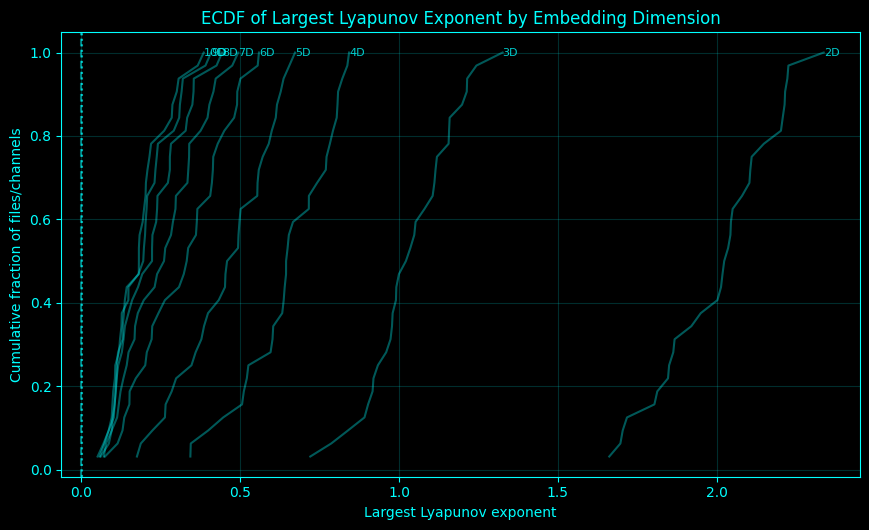

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/expanded_no_repeat_analysis/plots/01_lle_ecdf_by_embedding_dimension.png


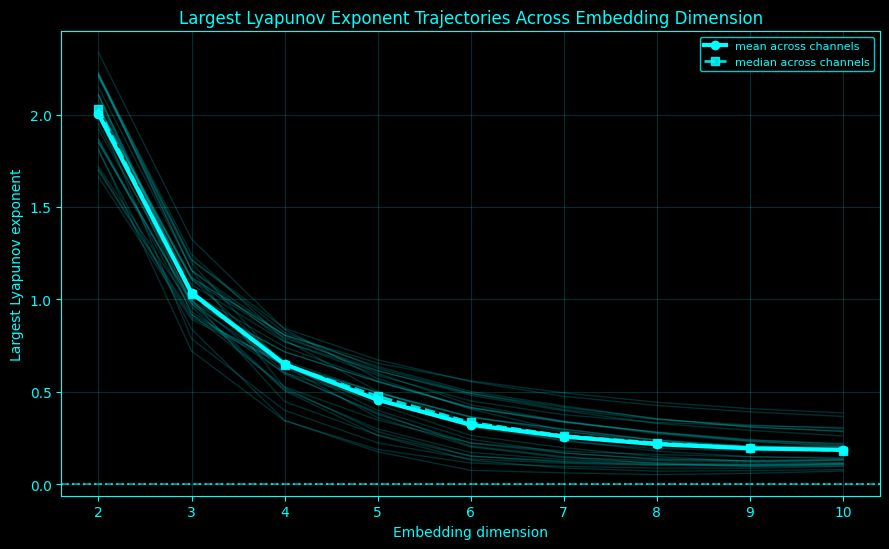

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/expanded_no_repeat_analysis/plots/02_lle_trajectories_across_dimension.png


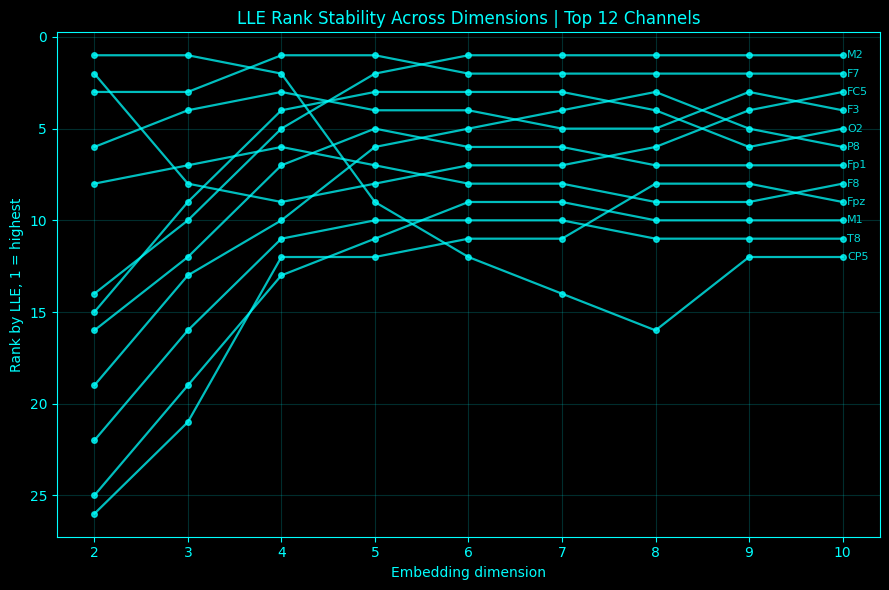

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/expanded_no_repeat_analysis/plots/03_lle_rank_bump_chart_top_channels.png


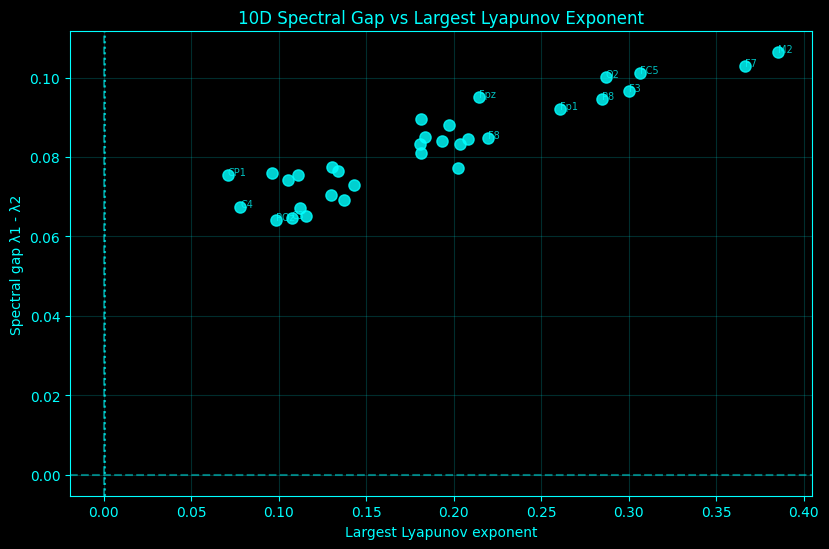

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/expanded_no_repeat_analysis/plots/04_10d_spectral_gap_vs_lle.png


/tmp/ipykernel_582322/1287533788.py:808: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_df = target.replace([np.inf, -np.inf], np.nan).copy()


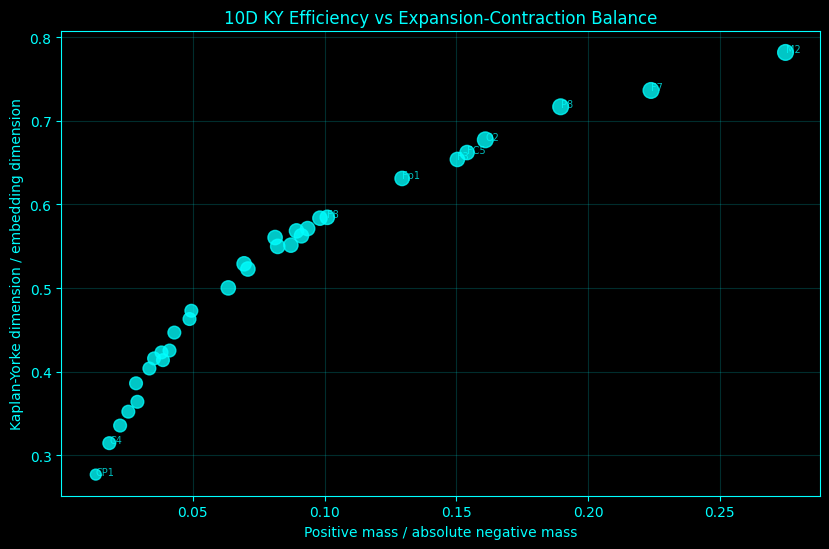

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/expanded_no_repeat_analysis/plots/05_10d_ky_efficiency_vs_balance_ratio.png


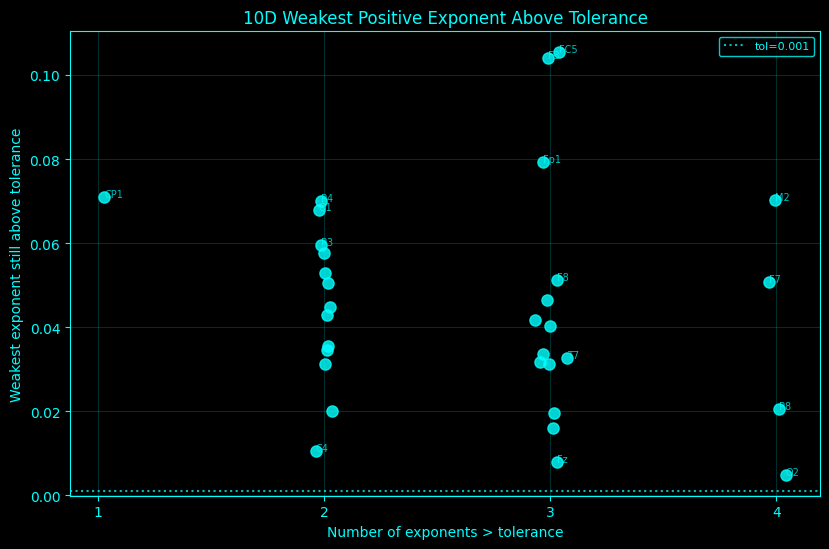

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/expanded_no_repeat_analysis/plots/06_10d_weakest_positive_margin.png


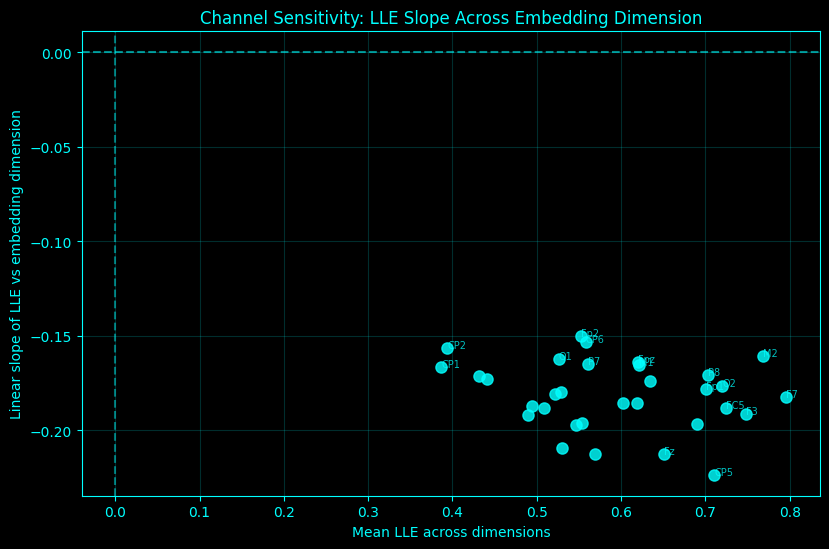

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/expanded_no_repeat_analysis/plots/07_lle_dimension_slope_vs_mean_lle.png


/tmp/ipykernel_582322/1287533788.py:961: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace([np.inf, -np.inf], np.nan)


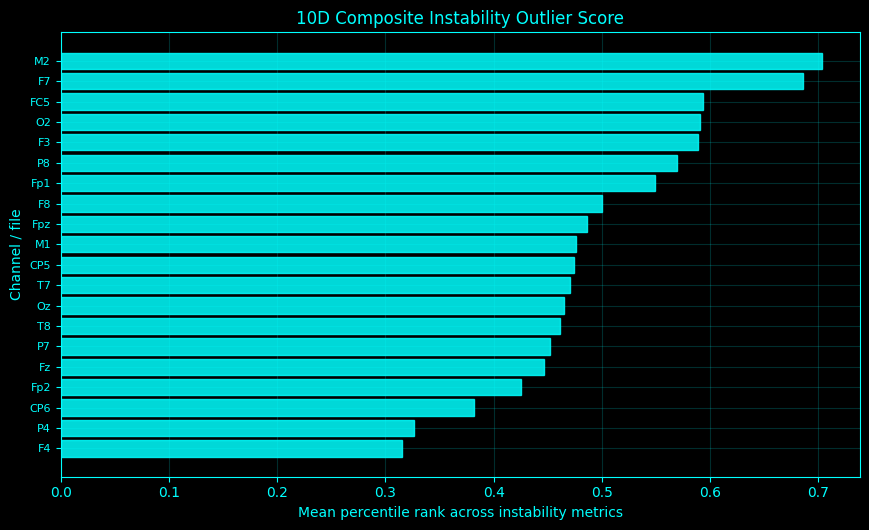

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/expanded_no_repeat_analysis/plots/08_10d_composite_instability_outliers.png

Done.
Input CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/lyap_spectrum_20260603_013142.csv
Selected dimension: 10
Plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/expanded_no_repeat_analysis/plots
Expanded all-dimension metrics CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/expanded_no_repeat_analysis/lyapunov_custom_expanded_metrics_all_dimensions.csv
Expanded target-dimension metrics CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/expanded_no_repeat_analysis/lyapunov_custom_expanded_metrics_10d.csv
LLE slope CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/expanded_no_repeat_analysis/lyapunov_custom_lle_dimension_slopes_by_channel.csv
Composite outlier CSV: /home/a/proj

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

CSV_PATH = os.path.join(
    base_dir,
    "results",
    "lyapunov_custom",
    "lyap_spectrum_20260603_013142.csv"
)

SEARCH_FALLBACK = True

results_dir = os.path.join(base_dir, "results", "lyapunov_custom", "expanded_no_repeat_analysis")
plots_dir = os.path.join(results_dir, "plots")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

TARGET_DIMENSION = 10

# Tolerance for practical positivity.
# This does NOT replace strict positivity; both are computed.
POSITIVE_TOL = 1e-3

TOP_N_RANK_PLOT = 12
TOP_N_LABELS = 8
TOP_N_OUTLIERS = 20

RANDOM_SEED = 42

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=220):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)


def compact_height(n_rows, per_row=0.16, min_h=4.8, max_h=7.0):
    return float(min(max_h, max(min_h, per_row * max(n_rows, 1))))


def set_compact_yticks(ax, labels, max_labels=32, fontsize=8):
    labels = list(labels)
    n = len(labels)

    if n == 0:
        return

    if n <= max_labels:
        ticks = np.arange(n)
        shown = labels
    else:
        step = int(np.ceil(n / max_labels))
        ticks = np.arange(0, n, step)
        shown = [labels[i] for i in ticks]

    ax.set_yticks(ticks)
    ax.set_yticklabels(shown, fontsize=fontsize)


def compact_barh(ax, labels, values, max_labels=32):
    labels = list(labels)
    values = np.asarray(values, dtype=float)
    y = np.arange(len(labels))

    ax.barh(
        y,
        values,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.85
    )

    set_compact_yticks(ax, labels, max_labels=max_labels, fontsize=8)


def annotate_extremes(ax, df, x_col, y_col, label_col="channel", top_n=8):
    """
    Label only the most extreme points to avoid unreadable scatter plots.
    """
    if len(df) == 0:
        return

    parts = []

    for col in [x_col, y_col]:
        finite_df = df[np.isfinite(df[col])].copy()

        if len(finite_df) == 0:
            continue

        parts.append(finite_df.sort_values(col, ascending=False).head(top_n))
        parts.append(finite_df.sort_values(col, ascending=True).head(max(2, top_n // 3)))

    if len(parts) == 0:
        return

    label_df = pd.concat(parts).drop_duplicates()

    for _, row in label_df.iterrows():
        if np.isfinite(row[x_col]) and np.isfinite(row[y_col]):
            ax.text(
                row[x_col],
                row[y_col],
                str(row[label_col]),
                color=ACCENT,
                fontsize=7,
                alpha=0.75
            )


# -------------------------------------------------------
# FILE HELPERS
# -------------------------------------------------------
def csv_has_exp_columns(path):
    try:
        cols = pd.read_csv(path, nrows=0).columns
    except Exception:
        return False

    return any(re.match(r"^Exp\d+$", c) for c in cols) or any(
        re.match(r"^SortedExp\d+$", c) for c in cols
    )


def find_latest_custom_lyapunov_csv(base_dir):
    patterns = [
        os.path.join(base_dir, "results", "lyapunov_custom", "lyap_spectrum*.csv"),
        os.path.join(base_dir, "results", "**", "lyap_spectrum*.csv"),
        os.path.join(base_dir, "**", "lyap_spectrum*.csv"),
    ]

    matches = []

    for pattern in patterns:
        matches.extend(glob.glob(pattern, recursive=True))

    bad_names = [
        "summary",
        "sorted_spectra",
        "stability",
        "matrix",
        "zscore",
        "outlier",
        "expanded",
    ]

    usable = []

    for path in sorted(set(matches)):
        name = os.path.basename(path).lower()

        if any(bad in name for bad in bad_names):
            continue

        if csv_has_exp_columns(path):
            usable.append(path)

    usable = sorted(usable, key=lambda p: os.path.getmtime(p), reverse=True)

    if len(usable) == 0:
        raise FileNotFoundError(
            "Could not find a usable Lyapunov spectrum CSV with Exp* columns."
        )

    return usable[0]


if not os.path.exists(CSV_PATH):
    if SEARCH_FALLBACK:
        print("Exact CSV not found. Searching for newest usable custom Lyapunov CSV...", flush=True)
        CSV_PATH = find_latest_custom_lyapunov_csv(base_dir)
    else:
        raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

if not csv_has_exp_columns(CSV_PATH):
    if SEARCH_FALLBACK:
        print("CSV has no Exp*/SortedExp* columns. Searching fallback...", flush=True)
        CSV_PATH = find_latest_custom_lyapunov_csv(base_dir)
    else:
        raise ValueError(f"CSV has no Exp*/SortedExp* columns: {CSV_PATH}")

print("Loading Lyapunov CSV:", CSV_PATH, flush=True)

df = pd.read_csv(CSV_PATH)

# -------------------------------------------------------
# BASIC HELPERS
# -------------------------------------------------------
def infer_channel_from_stem(stem):
    stem = str(stem)

    if "dembedded_" in stem:
        return stem.split("dembedded_", 1)[1]

    if "_" in stem:
        return stem.split("_")[-1]

    return stem


def infer_embedding_dimension(row, exp_cols):
    for key in ["stem", "file"]:
        if key in row.index:
            text = str(row[key])
            m = re.match(r"^(\d+)dembedded_", text)
            if m:
                return int(m.group(1))

    for key in ["embedding_dimension", "state_dim"]:
        if key in row.index and pd.notna(row[key]):
            try:
                return int(row[key])
            except Exception:
                pass

    vals = pd.to_numeric(row[exp_cols], errors="coerce").to_numpy(dtype=float)
    return int(np.isfinite(vals).sum())


def nan_safe_sort_desc(row_values, target_len=None):
    row_values = np.asarray(row_values, dtype=float)
    finite = row_values[np.isfinite(row_values)]
    finite = np.sort(finite)[::-1]

    if target_len is None:
        target_len = len(row_values)

    out = np.full(target_len, np.nan, dtype=float)
    n = min(len(finite), target_len)
    out[:n] = finite[:n]

    return out


def ky_dim_row(lam):
    lam = np.asarray(lam, dtype=float)
    lam = lam[np.isfinite(lam)]

    if len(lam) == 0:
        return np.nan

    cs = np.cumsum(lam)
    valid = np.where(cs >= 0)[0]

    if len(valid) == 0:
        return 0.0

    j = valid[-1]

    if j == len(lam) - 1:
        return float(len(lam))

    denom = lam[j + 1]

    if not np.isfinite(denom) or denom == 0:
        return float(j + 1)

    return float((j + 1) + cs[j] / abs(denom))


def safe_percentile_rank(series):
    s = pd.to_numeric(series, errors="coerce")

    if s.notna().sum() <= 1:
        return pd.Series(np.full(len(s), 0.5), index=s.index)

    return s.rank(pct=True)


# -------------------------------------------------------
# FILTER SUCCESSFUL ROWS
# -------------------------------------------------------
if "status" in df.columns:
    df_ok = df[df["status"].astype(str).str.lower() == "ok"].copy()
else:
    df_ok = df.copy()
    df_ok["status"] = "ok"

if len(df_ok) == 0:
    raise ValueError("No successful rows found.")

# -------------------------------------------------------
# FIND EXPONENT COLUMNS
# -------------------------------------------------------
raw_exp_cols = sorted(
    [c for c in df_ok.columns if re.match(r"^Exp\d+$", c)],
    key=lambda s: int(s.replace("Exp", ""))
)

sorted_exp_cols = sorted(
    [c for c in df_ok.columns if re.match(r"^SortedExp\d+$", c)],
    key=lambda s: int(s.replace("SortedExp", ""))
)

if len(raw_exp_cols) > 0:
    exp_cols = raw_exp_cols
    using_sorted_input = False
elif len(sorted_exp_cols) > 0:
    exp_cols = sorted_exp_cols
    using_sorted_input = True
else:
    raise ValueError("No exponent columns found.")

# Keep up to 10 exponents for this analysis
exp_cols = exp_cols[:10]

print("Using exponent columns:", exp_cols, flush=True)
print("Using already-sorted input:", using_sorted_input, flush=True)

for c in exp_cols:
    df_ok[c] = pd.to_numeric(df_ok[c], errors="coerce")

E_raw = df_ok[exp_cols].to_numpy(dtype=float)

valid_rows = np.isfinite(E_raw).any(axis=1)
df_ok = df_ok.loc[valid_rows].copy().reset_index(drop=True)
E_raw = E_raw[valid_rows]

if len(df_ok) == 0:
    raise ValueError("No rows with finite Lyapunov exponents.")

E_sorted = np.vstack([
    nan_safe_sort_desc(row, target_len=len(exp_cols))
    for row in E_raw
])

sorted_cols = [f"SortedExp{i + 1}" for i in range(E_sorted.shape[1])]

for i, c in enumerate(sorted_cols):
    df_ok[c] = E_sorted[:, i]

# -------------------------------------------------------
# METADATA
# -------------------------------------------------------
if "stem" not in df_ok.columns:
    if "file" in df_ok.columns:
        df_ok["stem"] = df_ok["file"].astype(str).str.replace(".npy", "", regex=False)
    else:
        df_ok["stem"] = [f"row_{i}" for i in range(len(df_ok))]

if "channel" not in df_ok.columns:
    df_ok["channel"] = df_ok["stem"].apply(infer_channel_from_stem)

df_ok["embedding_dimension"] = [
    infer_embedding_dimension(row, exp_cols)
    for _, row in df_ok.iterrows()
]

df_ok["embedding_dimension"] = pd.to_numeric(df_ok["embedding_dimension"], errors="coerce").astype("Int64")

# -------------------------------------------------------
# EXPANDED METRICS
# -------------------------------------------------------
metrics = df_ok.copy()

metrics["finite_exponent_count"] = np.sum(np.isfinite(E_sorted), axis=1)

metrics["LLE"] = np.array([
    np.nanmax(row) if np.isfinite(row).any() else np.nan
    for row in E_sorted
], dtype=float)

metrics["lambda2"] = E_sorted[:, 1] if E_sorted.shape[1] >= 2 else np.nan
metrics["lambda3"] = E_sorted[:, 2] if E_sorted.shape[1] >= 3 else np.nan

metrics["spectral_gap12"] = metrics["LLE"] - metrics["lambda2"]

metrics["strict_n_positive"] = np.array([
    int(np.sum(row[np.isfinite(row)] > 0.0))
    for row in E_sorted
])

metrics["tol_n_positive"] = np.array([
    int(np.sum(row[np.isfinite(row)] > POSITIVE_TOL))
    for row in E_sorted
])

metrics["positive_mass_strict"] = np.array([
    float(np.sum(row[np.isfinite(row) & (row > 0.0)]))
    for row in E_sorted
])

metrics["positive_mass_tol"] = np.array([
    float(np.sum(row[np.isfinite(row) & (row > POSITIVE_TOL)]))
    for row in E_sorted
])

metrics["negative_mass_abs"] = np.array([
    float(abs(np.sum(row[np.isfinite(row) & (row < 0.0)])))
    for row in E_sorted
])

metrics["divergence_sum"] = np.array([
    float(np.sum(row[np.isfinite(row)]))
    for row in E_sorted
])

metrics["most_negative"] = np.array([
    np.nanmin(row) if np.isfinite(row).any() else np.nan
    for row in E_sorted
], dtype=float)

metrics["spectrum_width"] = metrics["LLE"] - metrics["most_negative"]

metrics["KY_dimension"] = np.array([
    ky_dim_row(row)
    for row in E_sorted
])

metrics["KY_efficiency"] = metrics["KY_dimension"] / metrics["embedding_dimension"].astype(float)

metrics["contraction_balance_ratio"] = metrics["positive_mass_tol"] / (
    metrics["negative_mass_abs"] + 1e-12
)

metrics["dominant_positive_fraction"] = metrics["LLE"] / (
    metrics["positive_mass_strict"] + 1e-12
)

weakest_positive = []

for row in E_sorted:
    vals = row[np.isfinite(row) & (row > POSITIVE_TOL)]

    if len(vals) == 0:
        weakest_positive.append(np.nan)
    else:
        weakest_positive.append(float(np.min(vals)))

metrics["weakest_positive_above_tol"] = weakest_positive
metrics["weakest_positive_margin"] = metrics["weakest_positive_above_tol"] - POSITIVE_TOL

# Positive-exponent concentration: high means one positive exponent dominates.
pos_concentration = []

for row in E_sorted:
    vals = row[np.isfinite(row) & (row > 0.0)]

    if len(vals) == 0:
        pos_concentration.append(np.nan)
    else:
        w = vals / (np.sum(vals) + 1e-12)
        pos_concentration.append(float(np.sum(w ** 2)))

metrics["positive_mass_concentration"] = pos_concentration

# Composite outlier score based on percentile ranks of multiple instability metrics.
score_cols = [
    "LLE",
    "positive_mass_tol",
    "tol_n_positive",
    "KY_efficiency",
    "contraction_balance_ratio",
    "spectrum_width",
]

rank_cols = []

for col in score_cols:
    rank_col = f"{col}_percentile"
    metrics[rank_col] = safe_percentile_rank(metrics[col])
    rank_cols.append(rank_col)

metrics["composite_instability_score"] = metrics[rank_cols].mean(axis=1, skipna=True)

# -------------------------------------------------------
# SELECT TARGET DIMENSION
# -------------------------------------------------------
available_dims = sorted(metrics["embedding_dimension"].dropna().astype(int).unique())

if len(available_dims) == 0:
    raise ValueError("Could not infer embedding dimensions.")

if TARGET_DIMENSION in available_dims:
    selected_dim = TARGET_DIMENSION
else:
    selected_dim = max(available_dims)
    print(
        f"TARGET_DIMENSION={TARGET_DIMENSION} not found. Using largest available dimension: {selected_dim}",
        flush=True
    )

target = metrics[metrics["embedding_dimension"].astype(int) == selected_dim].copy()

if len(target) == 0:
    raise ValueError("No rows found for selected dimension.")

channel_counts = target["channel"].value_counts()

if (channel_counts > 1).any():
    target["plot_label"] = target["channel"].astype(str) + " | " + target["stem"].astype(str)
else:
    target["plot_label"] = target["channel"].astype(str)

# -------------------------------------------------------
# SAVE EXPANDED TABLES
# -------------------------------------------------------
metrics_csv = os.path.join(results_dir, "lyapunov_custom_expanded_metrics_all_dimensions.csv")
target_csv = os.path.join(results_dir, f"lyapunov_custom_expanded_metrics_{selected_dim}d.csv")

metrics.to_csv(metrics_csv, index=False)
target.to_csv(target_csv, index=False)

print("\nSaved expanded all-dimension metrics:", metrics_csv)
print("Saved expanded target-dimension metrics:", target_csv)

print("\nAvailable dimensions:", available_dims)
print("Selected dimension:", selected_dim)

print("\nTop rows by composite instability score:")
print(
    target
    .sort_values("composite_instability_score", ascending=False)
    [
        [
            "channel",
            "stem",
            "LLE",
            "lambda2",
            "spectral_gap12",
            "tol_n_positive",
            "positive_mass_tol",
            "negative_mass_abs",
            "contraction_balance_ratio",
            "KY_dimension",
            "KY_efficiency",
            "composite_instability_score",
        ]
    ]
    .head(12)
    .to_string(index=False)
)

# -------------------------------------------------------
# PLOT 1: LLE ECDF BY EMBEDDING DIMENSION
# New plot: distribution curves, not boxplots/heatmaps.
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.8, 5.4), facecolor=BG)
style_ax(ax)

for dim in available_dims:
    vals = metrics.loc[
        metrics["embedding_dimension"].astype(int) == dim,
        "LLE"
    ].dropna().to_numpy(dtype=float)

    if len(vals) == 0:
        continue

    vals = np.sort(vals)
    y = np.arange(1, len(vals) + 1) / len(vals)

    ax.plot(
        vals,
        y,
        color=ACCENT,
        alpha=0.35,
        linewidth=1.5
    )

    ax.text(
        vals[-1],
        y[-1],
        f"{dim}D",
        color=ACCENT,
        fontsize=8,
        alpha=0.8,
        ha="left",
        va="center"
    )

ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.45)
ax.axvline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)

ax.set_title("ECDF of Largest Lyapunov Exponent by Embedding Dimension")
ax.set_xlabel("Largest Lyapunov exponent")
ax.set_ylabel("Cumulative fraction of files/channels")

plot_path = os.path.join(plots_dir, "01_lle_ecdf_by_embedding_dimension.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 2: LLE TRAJECTORIES ACROSS EMBEDDING DIMENSION
# New plot: channel trajectories instead of heatmaps.
# -------------------------------------------------------
lle_pivot = metrics.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="LLE",
    aggfunc="mean"
)

lle_pivot = lle_pivot.reindex(sorted(lle_pivot.columns), axis=1)

fig, ax = plt.subplots(figsize=(9.0, 5.6), facecolor=BG)
style_ax(ax)

dims = np.array([int(c) for c in lle_pivot.columns])

for channel, row in lle_pivot.iterrows():
    vals = row.to_numpy(dtype=float)

    ax.plot(
        dims,
        vals,
        color=ACCENT,
        alpha=0.18,
        linewidth=1.0
    )

mean_vals = np.nanmean(lle_pivot.to_numpy(dtype=float), axis=0)
median_vals = np.nanmedian(lle_pivot.to_numpy(dtype=float), axis=0)

ax.plot(
    dims,
    mean_vals,
    color=ACCENT,
    linewidth=3.0,
    marker="o",
    label="mean across channels"
)

ax.plot(
    dims,
    median_vals,
    color=ACCENT,
    linewidth=2.0,
    marker="s",
    linestyle="--",
    alpha=0.85,
    label="median across channels"
)

ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.45)
ax.axhline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)

ax.set_title("Largest Lyapunov Exponent Trajectories Across Embedding Dimension")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Largest Lyapunov exponent")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, "02_lle_trajectories_across_dimension.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 3: LLE RANK BUMP CHART FOR TOP TARGET-DIM CHANNELS
# New plot: rank stability across dimensions.
# -------------------------------------------------------
rank_pivot = lle_pivot.rank(axis=0, method="average", ascending=False)

if selected_dim in rank_pivot.columns:
    top_channels = (
        rank_pivot[selected_dim]
        .dropna()
        .sort_values()
        .head(TOP_N_RANK_PLOT)
        .index
        .tolist()
    )
else:
    top_channels = (
        rank_pivot.mean(axis=1)
        .dropna()
        .sort_values()
        .head(TOP_N_RANK_PLOT)
        .index
        .tolist()
    )

fig, ax = plt.subplots(figsize=(9.0, 6.0), facecolor=BG)
style_ax(ax)

for channel in top_channels:
    vals = rank_pivot.loc[channel].to_numpy(dtype=float)

    ax.plot(
        dims,
        vals,
        color=ACCENT,
        alpha=0.75,
        linewidth=1.6,
        marker="o",
        markersize=4
    )

    finite = np.isfinite(vals)

    if finite.any():
        last_x = dims[finite][-1]
        last_y = vals[finite][-1]

        ax.text(
            last_x + 0.05,
            last_y,
            str(channel),
            color=ACCENT,
            fontsize=8,
            alpha=0.85,
            va="center"
        )

ax.invert_yaxis()

ax.set_title(f"LLE Rank Stability Across Dimensions | Top {len(top_channels)} Channels")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Rank by LLE, 1 = highest")

plot_path = os.path.join(plots_dir, "03_lle_rank_bump_chart_top_channels.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 4: SPECTRAL GAP VS LLE
# New plot: distinguishes dominant single expansion from distributed expansion.
# -------------------------------------------------------
plot_df = target.copy()

fig, ax = plt.subplots(figsize=(8.4, 5.6), facecolor=BG)
style_ax(ax)

ax.scatter(
    plot_df["LLE"],
    plot_df["spectral_gap12"],
    color=ACCENT,
    edgecolor=ACCENT,
    s=65,
    alpha=0.82
)

ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.45)
ax.axvline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)
ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.45)

annotate_extremes(
    ax,
    plot_df,
    x_col="LLE",
    y_col="spectral_gap12",
    label_col="channel",
    top_n=TOP_N_LABELS
)

ax.set_title(f"{selected_dim}D Spectral Gap vs Largest Lyapunov Exponent")
ax.set_xlabel("Largest Lyapunov exponent")
ax.set_ylabel("Spectral gap λ1 - λ2")

plot_path = os.path.join(plots_dir, f"04_{selected_dim}d_spectral_gap_vs_lle.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 5: KY EFFICIENCY VS EXPANSION-CONTRACTION BALANCE
# New plot: compactness/dimension-use vs expansion-to-contraction ratio.
# -------------------------------------------------------
plot_df = target.replace([np.inf, -np.inf], np.nan).copy()
plot_df = plot_df[
    np.isfinite(plot_df["contraction_balance_ratio"])
    & np.isfinite(plot_df["KY_efficiency"])
].copy()

fig, ax = plt.subplots(figsize=(8.4, 5.6), facecolor=BG)
style_ax(ax)

sizes = 40 + 22 * plot_df["tol_n_positive"].fillna(0).to_numpy(dtype=float)

ax.scatter(
    plot_df["contraction_balance_ratio"],
    plot_df["KY_efficiency"],
    color=ACCENT,
    edgecolor=ACCENT,
    s=sizes,
    alpha=0.78
)

annotate_extremes(
    ax,
    plot_df,
    x_col="contraction_balance_ratio",
    y_col="KY_efficiency",
    label_col="channel",
    top_n=TOP_N_LABELS
)

ax.set_title(f"{selected_dim}D KY Efficiency vs Expansion-Contraction Balance")
ax.set_xlabel("Positive mass / absolute negative mass")
ax.set_ylabel("Kaplan-Yorke dimension / embedding dimension")

plot_path = os.path.join(plots_dir, f"05_{selected_dim}d_ky_efficiency_vs_balance_ratio.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 6: WEAKEST POSITIVE EXPONENT MARGIN
# New plot: identifies borderline multi-positive candidates.
# -------------------------------------------------------
plot_df = target.copy()
plot_df = plot_df[np.isfinite(plot_df["weakest_positive_above_tol"])].copy()

rng = np.random.default_rng(RANDOM_SEED)
plot_df["npos_jitter"] = (
    plot_df["tol_n_positive"].astype(float)
    + rng.normal(0, 0.035, size=len(plot_df))
)

fig, ax = plt.subplots(figsize=(8.4, 5.6), facecolor=BG)
style_ax(ax)

ax.scatter(
    plot_df["npos_jitter"],
    plot_df["weakest_positive_above_tol"],
    color=ACCENT,
    edgecolor=ACCENT,
    s=65,
    alpha=0.82
)

ax.axhline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.75, label=f"tol={POSITIVE_TOL:g}")

annotate_extremes(
    ax,
    plot_df,
    x_col="npos_jitter",
    y_col="weakest_positive_above_tol",
    label_col="channel",
    top_n=TOP_N_LABELS
)

ax.set_xticks(sorted(plot_df["tol_n_positive"].dropna().astype(int).unique()))
ax.set_title(f"{selected_dim}D Weakest Positive Exponent Above Tolerance")
ax.set_xlabel("Number of exponents > tolerance")
ax.set_ylabel("Weakest exponent still above tolerance")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, f"06_{selected_dim}d_weakest_positive_margin.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 7: CHANNEL SLOPE OF LLE ACROSS DIMENSIONS
# New plot: tells which channels gain/lose instability as dimension increases.
# -------------------------------------------------------
slope_records = []

for channel, row in lle_pivot.iterrows():
    y = row.to_numpy(dtype=float)
    x = dims.astype(float)
    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() >= 3:
        slope, intercept = np.polyfit(x[mask], y[mask], deg=1)

        slope_records.append({
            "channel": channel,
            "lle_dimension_slope": float(slope),
            "lle_dimension_intercept": float(intercept),
            "mean_lle": float(np.nanmean(y)),
            "median_lle": float(np.nanmedian(y)),
            "min_lle": float(np.nanmin(y)),
            "max_lle": float(np.nanmax(y)),
            "lle_range": float(np.nanmax(y) - np.nanmin(y)),
            "n_dimensions_used": int(mask.sum()),
        })

slope_df = pd.DataFrame(slope_records)

slope_csv = os.path.join(results_dir, "lyapunov_custom_lle_dimension_slopes_by_channel.csv")
slope_df.to_csv(slope_csv, index=False)

fig, ax = plt.subplots(figsize=(8.4, 5.6), facecolor=BG)
style_ax(ax)

if len(slope_df) > 0:
    ax.scatter(
        slope_df["mean_lle"],
        slope_df["lle_dimension_slope"],
        color=ACCENT,
        edgecolor=ACCENT,
        s=65,
        alpha=0.82
    )

    annotate_extremes(
        ax,
        slope_df,
        x_col="mean_lle",
        y_col="lle_dimension_slope",
        label_col="channel",
        top_n=TOP_N_LABELS
    )

ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.55)
ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.45)

ax.set_title("Channel Sensitivity: LLE Slope Across Embedding Dimension")
ax.set_xlabel("Mean LLE across dimensions")
ax.set_ylabel("Linear slope of LLE vs embedding dimension")

plot_path = os.path.join(plots_dir, "07_lle_dimension_slope_vs_mean_lle.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 8: COMPOSITE INSTABILITY OUTLIER SCORE
# New plot: not just LLE; combines multiple diagnostics.
# -------------------------------------------------------
outlier_df = (
    target
    .replace([np.inf, -np.inf], np.nan)
    .sort_values("composite_instability_score", ascending=True)
    .tail(TOP_N_OUTLIERS)
    .copy()
)

outlier_csv = os.path.join(results_dir, f"lyapunov_custom_top_{TOP_N_OUTLIERS}_composite_outliers_{selected_dim}d.csv")
outlier_df.to_csv(outlier_csv, index=False)

fig, ax = plt.subplots(
    figsize=(8.8, compact_height(len(outlier_df), per_row=0.23, min_h=5.4, max_h=7.6)),
    facecolor=BG
)
style_ax(ax)

compact_barh(
    ax,
    outlier_df["plot_label"],
    outlier_df["composite_instability_score"],
    max_labels=TOP_N_OUTLIERS
)

ax.set_title(f"{selected_dim}D Composite Instability Outlier Score")
ax.set_xlabel("Mean percentile rank across instability metrics")
ax.set_ylabel("Channel / file")

plot_path = os.path.join(plots_dir, f"08_{selected_dim}d_composite_instability_outliers.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# FINAL PRINT
# -------------------------------------------------------
print("\nDone.")
print("Input CSV:", CSV_PATH)
print("Selected dimension:", selected_dim)
print("Plots saved to:", plots_dir)
print("Expanded all-dimension metrics CSV:", metrics_csv)
print("Expanded target-dimension metrics CSV:", target_csv)
print("LLE slope CSV:", slope_csv)
print("Composite outlier CSV:", outlier_csv)

Exact CSV not found. Searching for newest usable Lyapunov CSV...
Loading Lyapunov CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/lyap_spectrum_20260603_013142.csv
Using ALL exponent columns: ['Exp1', 'Exp2', 'Exp3', 'Exp4', 'Exp5', 'Exp6', 'Exp7', 'Exp8', 'Exp9', 'Exp10']
Using already-sorted input: False

Saved wide metrics: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/all_exponents_all_dims_wide_metrics.csv
Saved long exponent table: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/all_exponents_all_dims_long_table.csv
Saved adjacent pair table: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/all_adjacent_exponent_pairs_all_dims.csv

Rows by embedding dimension:
embedding_dimension
2     32
3     32
4     32
5     32
6     32
7     32
8     32
9     32
10    32

Finite exponent count

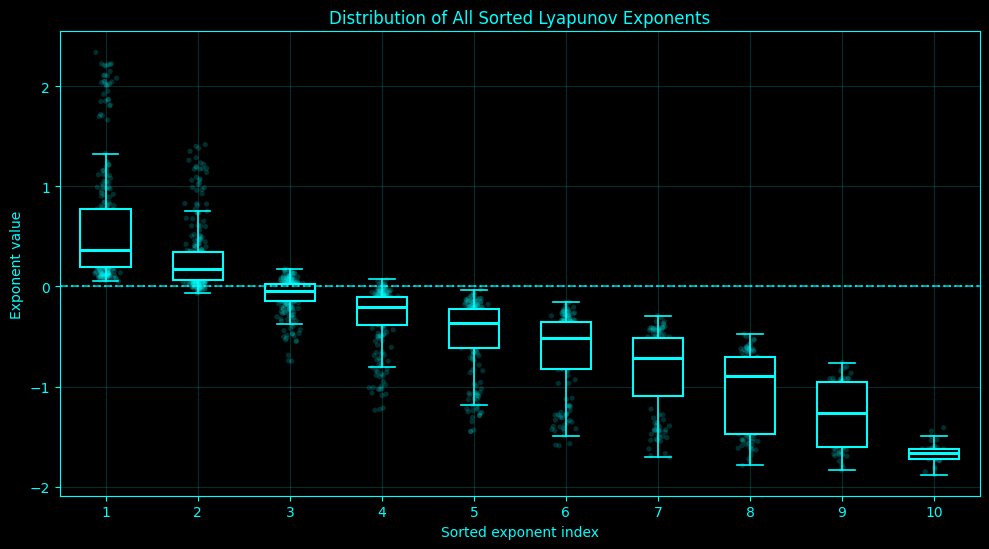

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/01_all_exponent_distributions_by_index.png


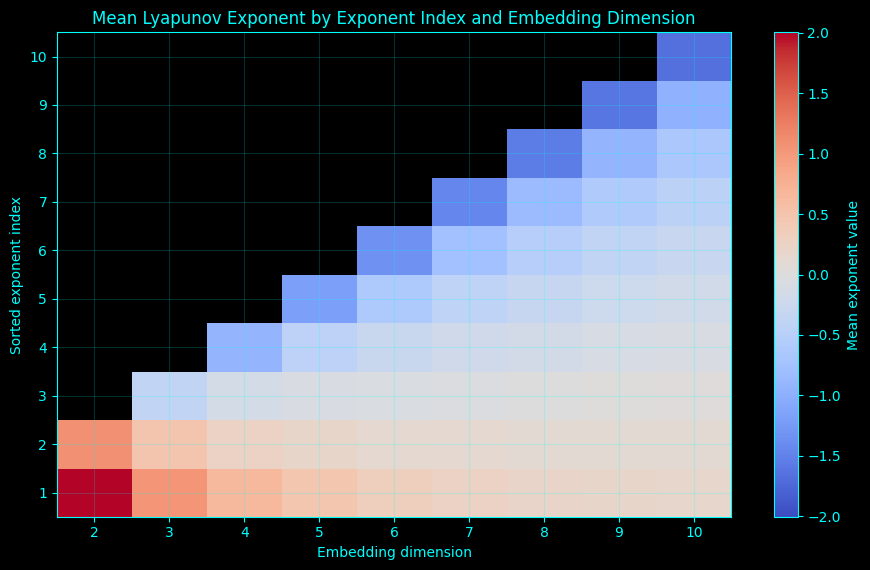

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/02_mean_exponent_index_by_dimension_heatmap.png


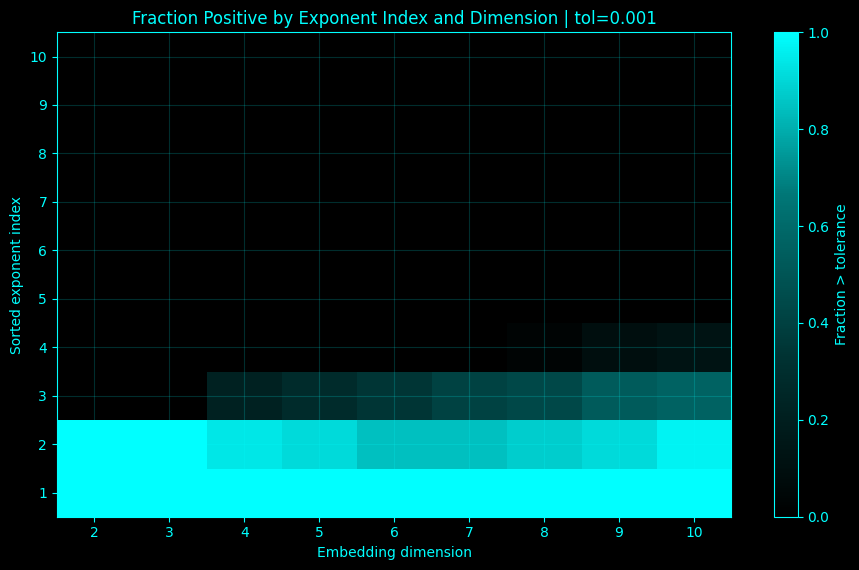

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/03_positive_fraction_exponent_index_by_dimension.png


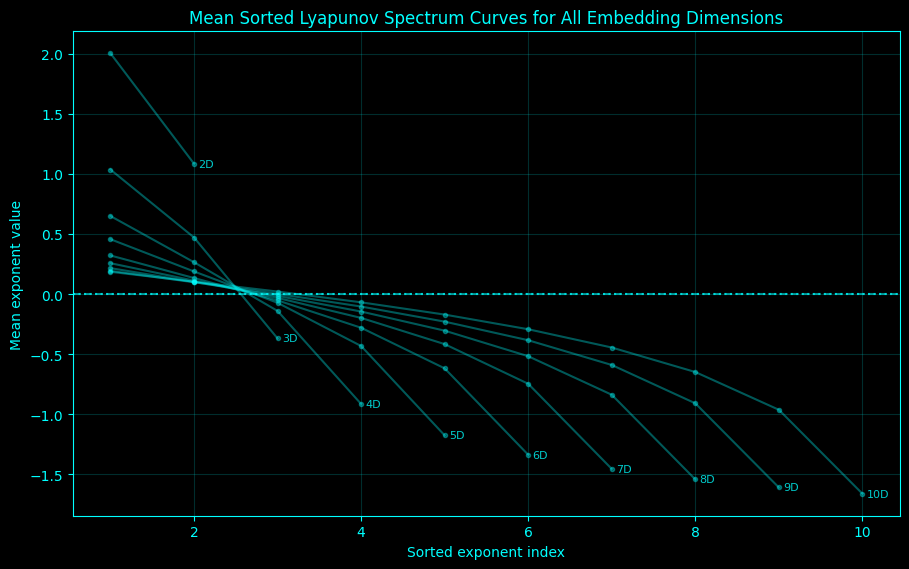

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/04_mean_spectrum_curves_all_dimensions.png


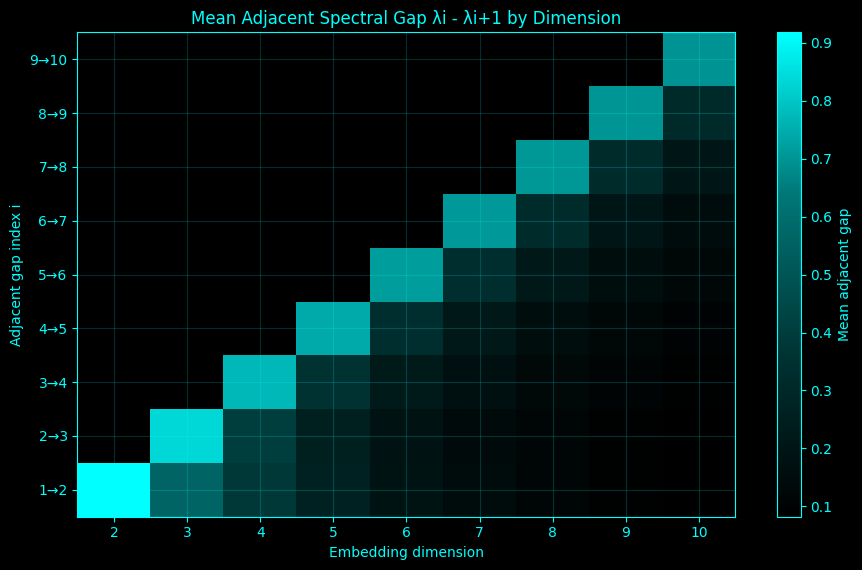

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/05_adjacent_gap_index_by_dimension_heatmap.png


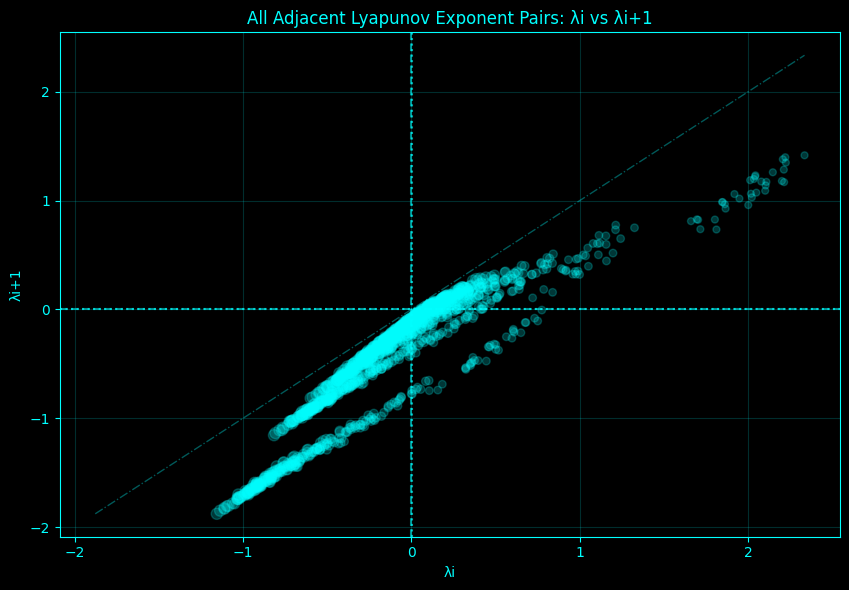

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/06_all_adjacent_lambda_pairs_cloud.png


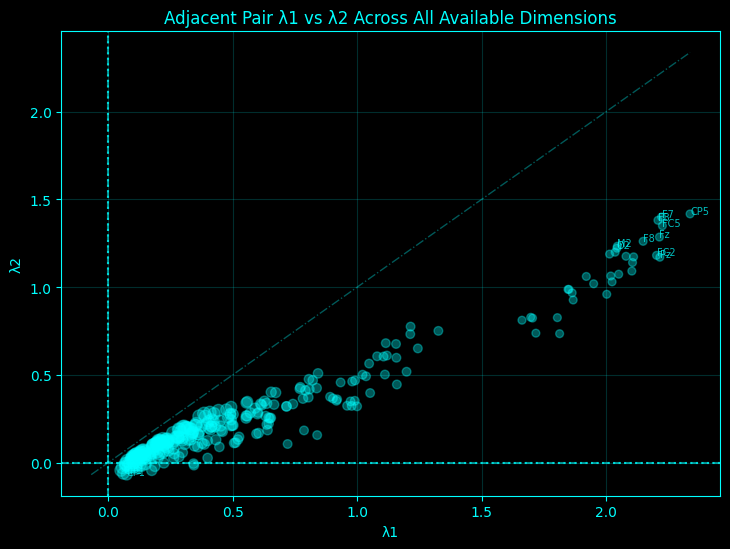

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/adjacent_pair_scatters/lambda1_vs_lambda2_all_dimensions.png


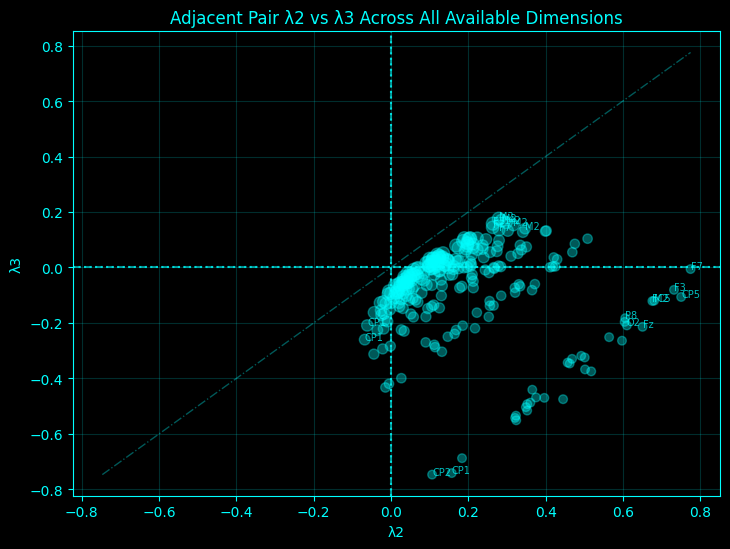

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/adjacent_pair_scatters/lambda2_vs_lambda3_all_dimensions.png


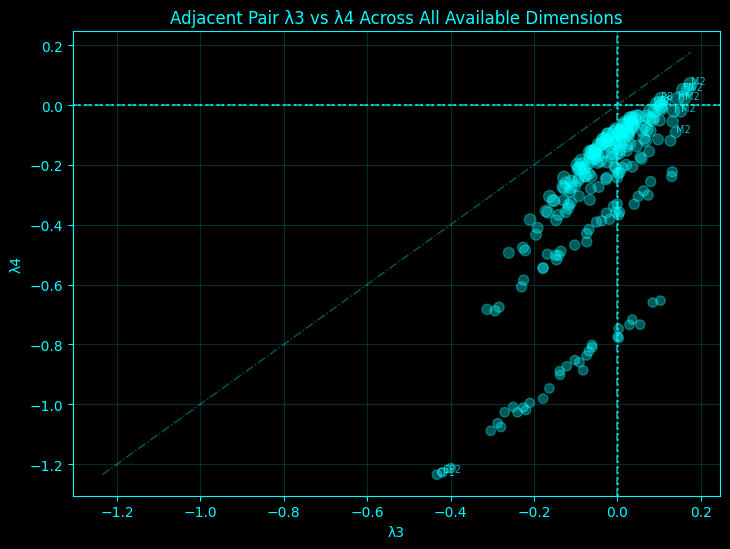

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/adjacent_pair_scatters/lambda3_vs_lambda4_all_dimensions.png


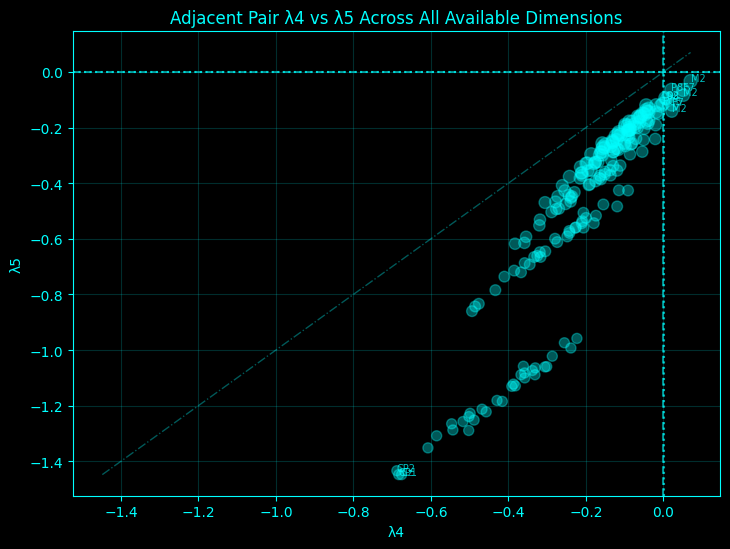

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/adjacent_pair_scatters/lambda4_vs_lambda5_all_dimensions.png


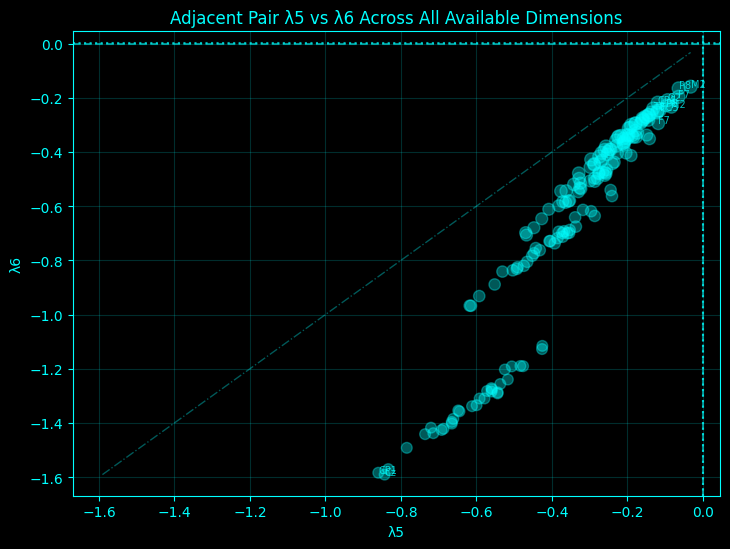

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/adjacent_pair_scatters/lambda5_vs_lambda6_all_dimensions.png


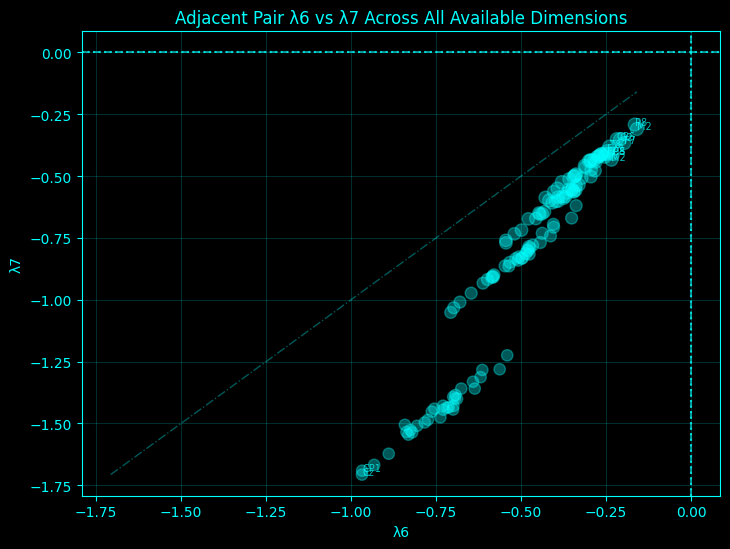

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/adjacent_pair_scatters/lambda6_vs_lambda7_all_dimensions.png


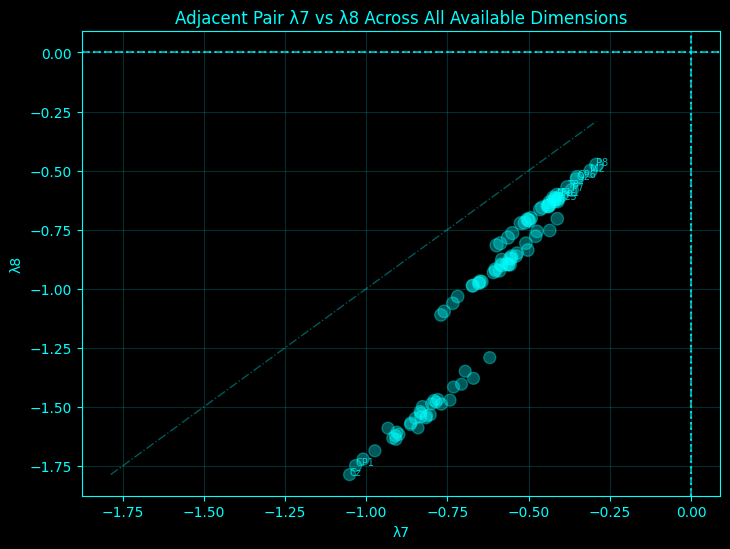

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/adjacent_pair_scatters/lambda7_vs_lambda8_all_dimensions.png


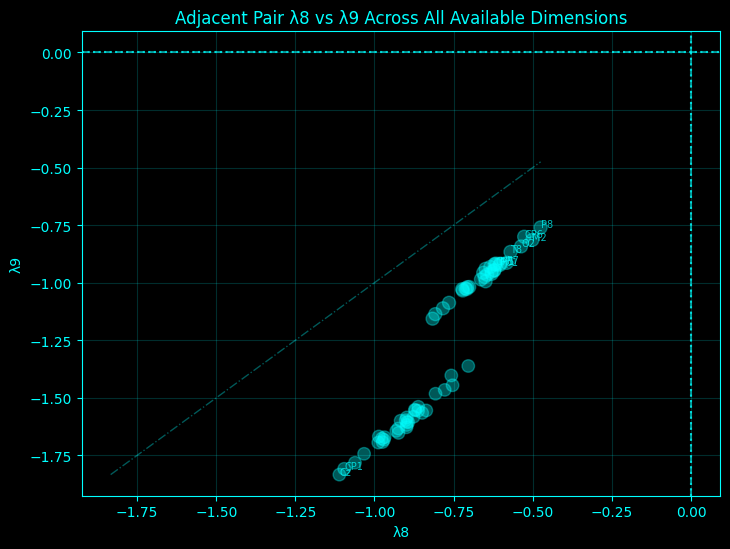

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/adjacent_pair_scatters/lambda8_vs_lambda9_all_dimensions.png


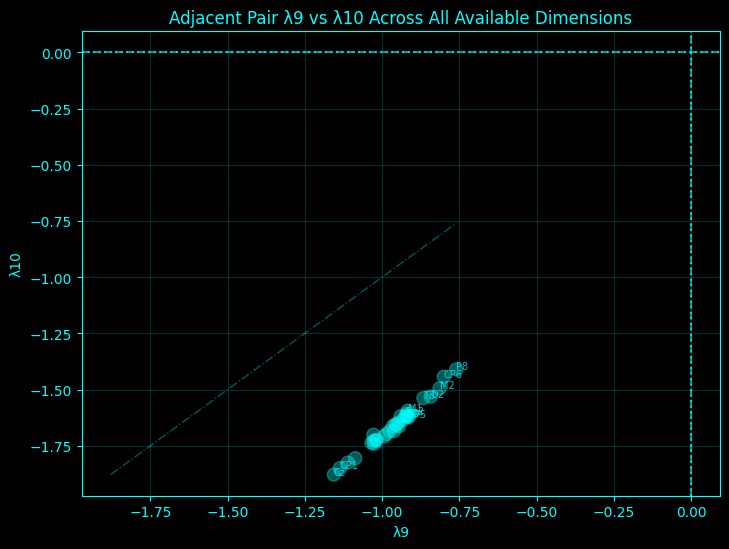

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/adjacent_pair_scatters/lambda9_vs_lambda10_all_dimensions.png


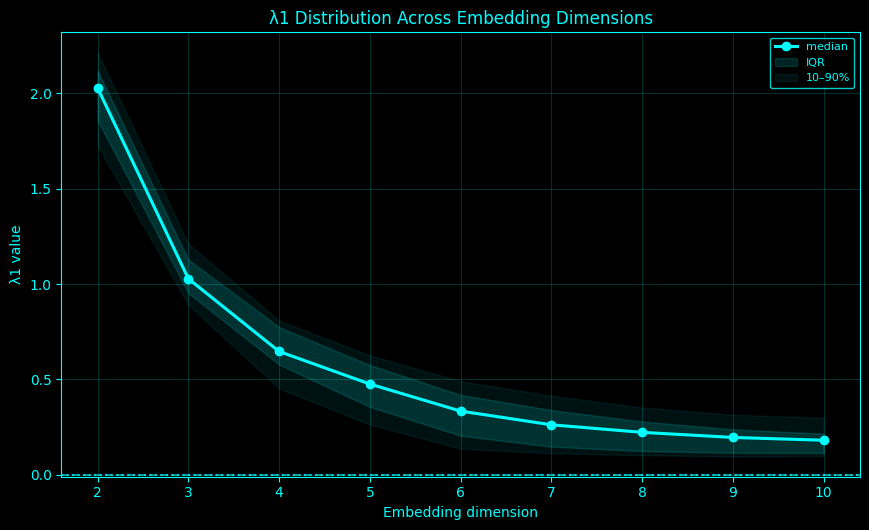

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/per_exponent_index_by_dimension/lambda1_quantiles_by_dimension.png


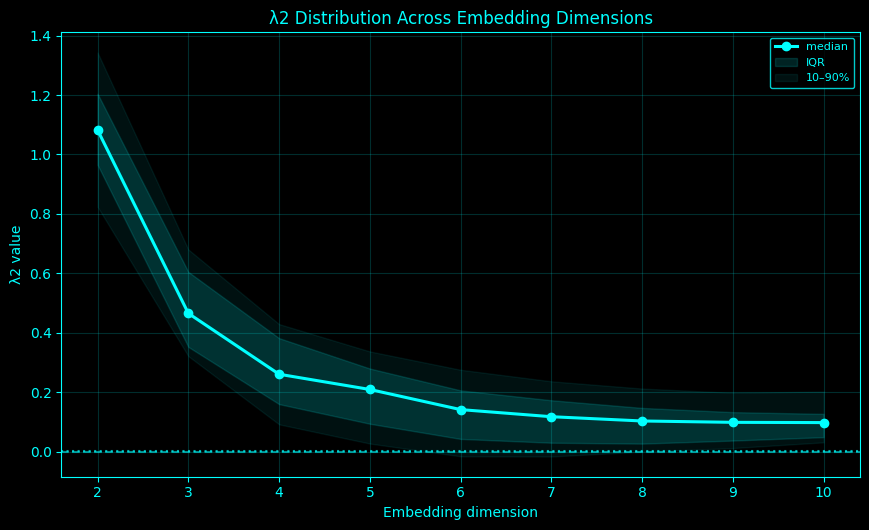

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/per_exponent_index_by_dimension/lambda2_quantiles_by_dimension.png


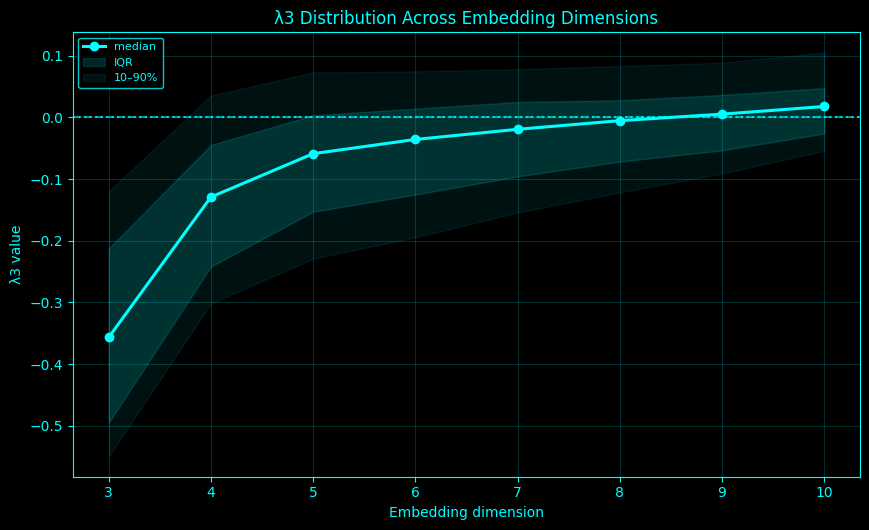

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/per_exponent_index_by_dimension/lambda3_quantiles_by_dimension.png


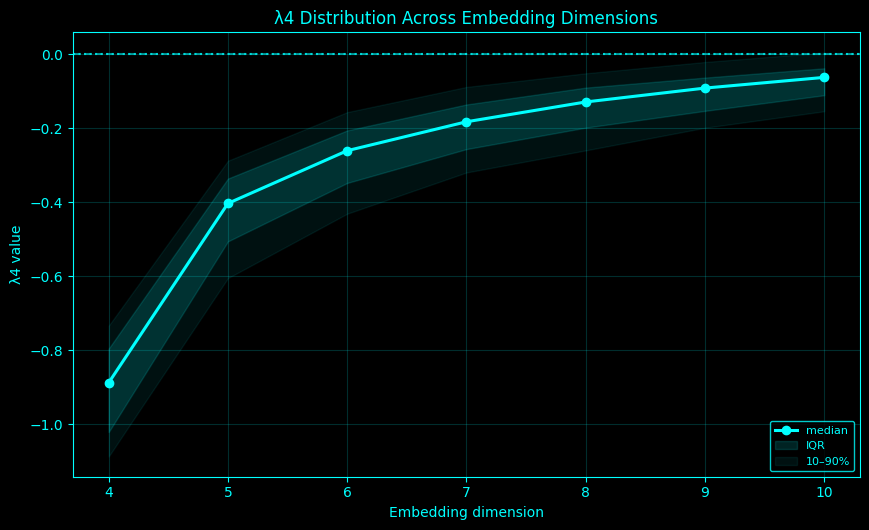

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/per_exponent_index_by_dimension/lambda4_quantiles_by_dimension.png


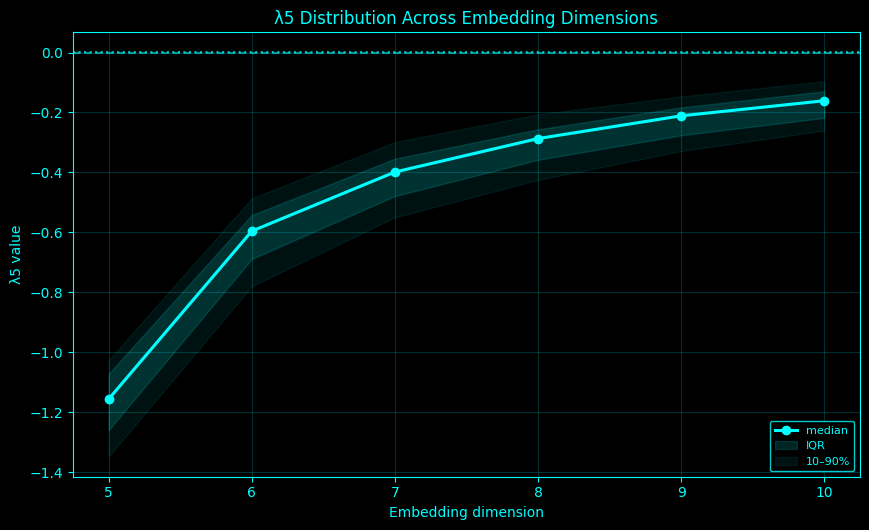

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/per_exponent_index_by_dimension/lambda5_quantiles_by_dimension.png


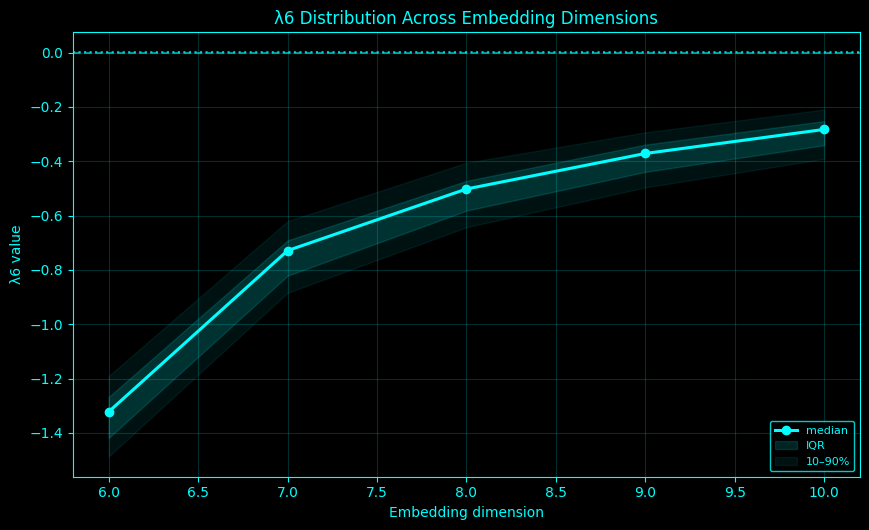

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/per_exponent_index_by_dimension/lambda6_quantiles_by_dimension.png


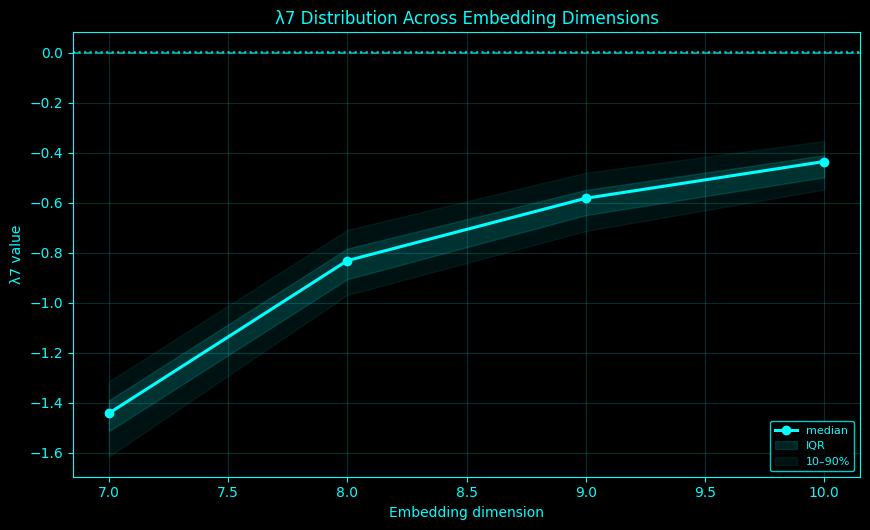

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/per_exponent_index_by_dimension/lambda7_quantiles_by_dimension.png


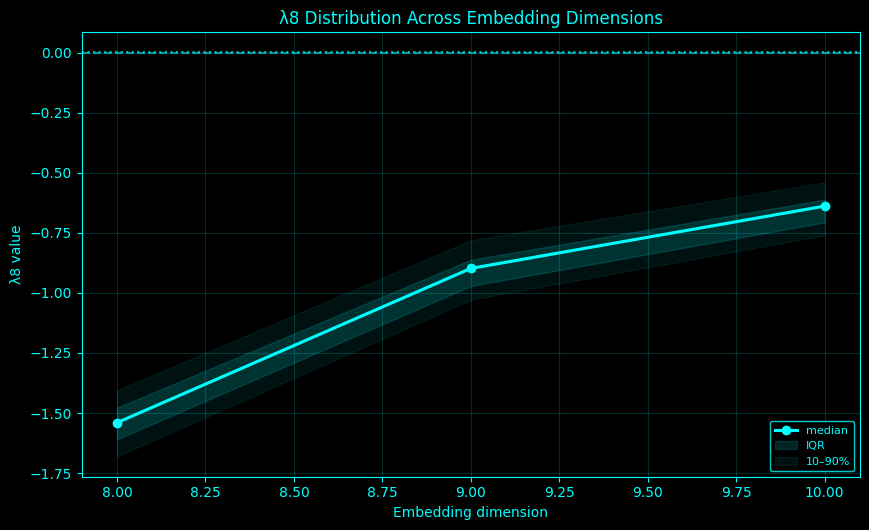

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/per_exponent_index_by_dimension/lambda8_quantiles_by_dimension.png


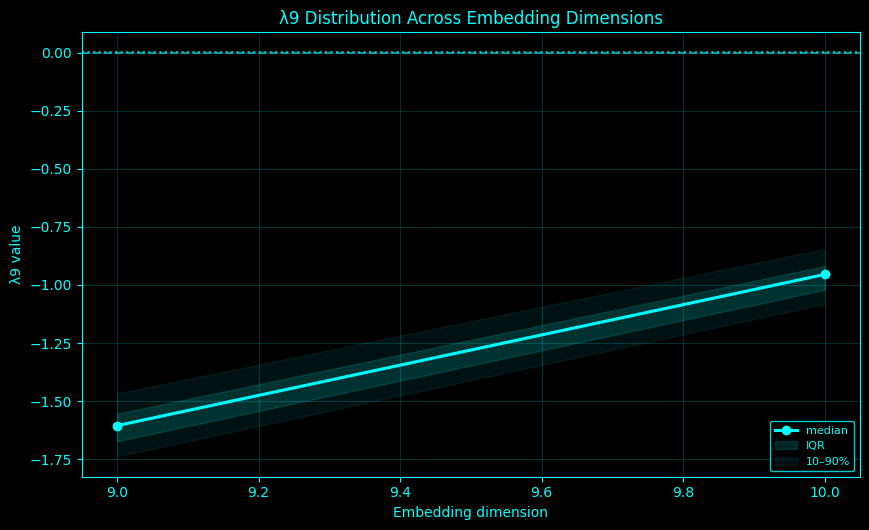

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/per_exponent_index_by_dimension/lambda9_quantiles_by_dimension.png


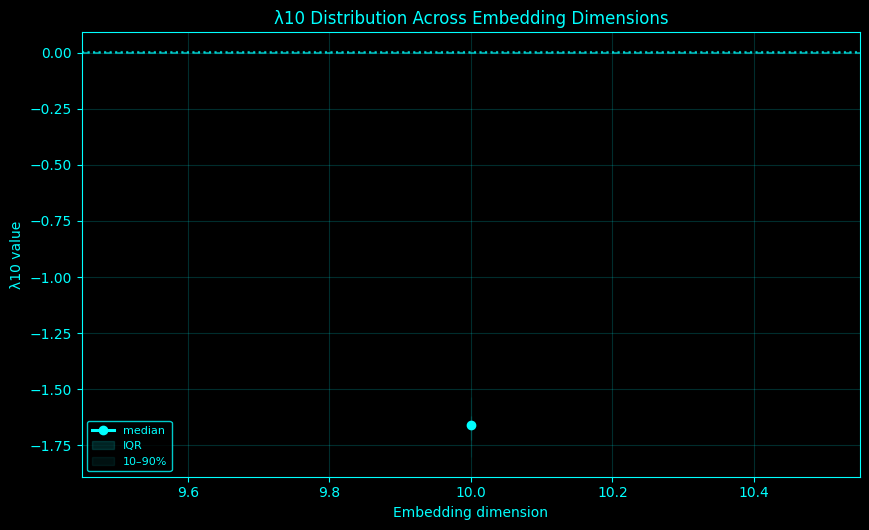

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/per_exponent_index_by_dimension/lambda10_quantiles_by_dimension.png


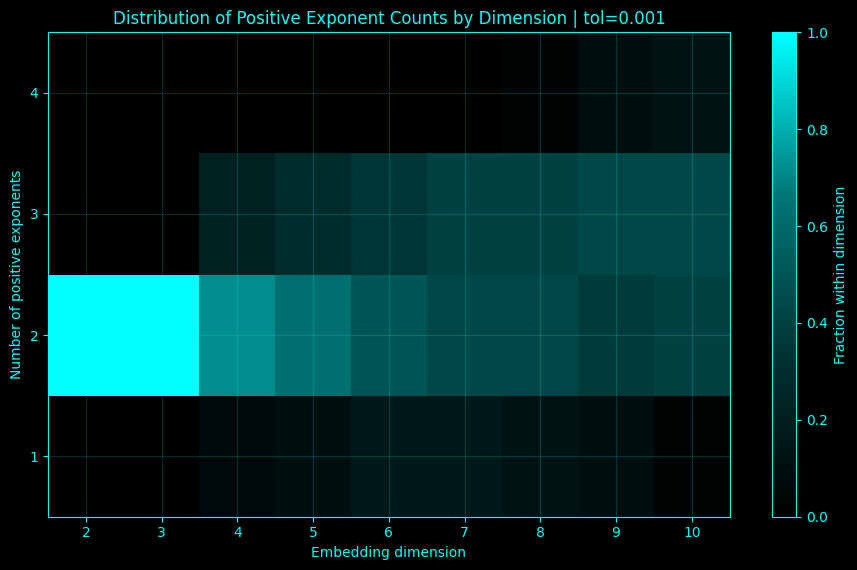

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/09_positive_count_distribution_by_dimension.png

Done.
Input CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/lyap_spectrum_20260603_013142.csv
All available embedding dimensions: [2, 3, 4, 5, 6, 7, 8, 9, 10]
All available exponent columns used: ['Exp1', 'Exp2', 'Exp3', 'Exp4', 'Exp5', 'Exp6', 'Exp7', 'Exp8', 'Exp9', 'Exp10']
Number of sorted exponent positions: 10
Plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots
Adjacent-pair scatter plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/adjacent_pair_scatters
Per-exponent plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/all_exponents_all_dims_analysis/plots/per_exponent_index_by_dimension
Wide metrics C

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

CSV_PATH = os.path.join(
    base_dir,
    "results",
    "lyapunov_custom",
    "lyap_spectrum_20260305_145136.csv"
)

SEARCH_FALLBACK = True

results_dir = os.path.join(base_dir, "results", "lyapunov_custom", "all_exponents_all_dims_analysis")
plots_dir = os.path.join(results_dir, "plots")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

POSITIVE_TOL = 1e-3
N_BINS = 32
RANDOM_SEED = 42
LABEL_TOP_N = 8

ACCENT = "cyan"
BG = "black"

CYAN_CMAP = LinearSegmentedColormap.from_list(
    "black_to_cyan",
    ["black", "#003333", "#007777", "cyan"]
)

COOLWARM_BAD_BLACK = plt.get_cmap("coolwarm").copy()
COOLWARM_BAD_BLACK.set_bad(color=BG)

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=220):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)


def compact_height(n_rows, per_row=0.15, min_h=4.8, max_h=7.2):
    return float(min(max_h, max(min_h, per_row * max(n_rows, 1))))


def set_compact_yticks(ax, labels, max_labels=36, fontsize=8):
    labels = list(labels)
    n = len(labels)

    if n == 0:
        return

    if n <= max_labels:
        ticks = np.arange(n)
        shown = labels
    else:
        step = int(np.ceil(n / max_labels))
        ticks = np.arange(0, n, step)
        shown = [labels[i] for i in ticks]

    ax.set_yticks(ticks)
    ax.set_yticklabels(shown, fontsize=fontsize)


def annotate_extremes(ax, df, x_col, y_col, label_col="channel", top_n=8):
    if len(df) == 0:
        return

    parts = []

    for col in [x_col, y_col]:
        finite_df = df[np.isfinite(df[col])].copy()

        if len(finite_df) == 0:
            continue

        parts.append(finite_df.sort_values(col, ascending=False).head(top_n))
        parts.append(finite_df.sort_values(col, ascending=True).head(max(2, top_n // 3)))

    if len(parts) == 0:
        return

    label_df = pd.concat(parts).drop_duplicates()

    for _, row in label_df.iterrows():
        if np.isfinite(row[x_col]) and np.isfinite(row[y_col]):
            ax.text(
                row[x_col],
                row[y_col],
                str(row[label_col]),
                color=ACCENT,
                fontsize=7,
                alpha=0.75
            )


# -------------------------------------------------------
# FILE HELPERS
# -------------------------------------------------------
def csv_has_exp_columns(path):
    try:
        cols = pd.read_csv(path, nrows=0).columns
    except Exception:
        return False

    has_raw = any(re.match(r"^Exp\d+$", c) for c in cols)
    has_sorted = any(re.match(r"^SortedExp\d+$", c) for c in cols)

    return has_raw or has_sorted


def find_latest_custom_lyapunov_csv(base_dir):
    patterns = [
        os.path.join(base_dir, "results", "lyapunov_custom", "lyap_spectrum*.csv"),
        os.path.join(base_dir, "results", "**", "lyap_spectrum*.csv"),
        os.path.join(base_dir, "**", "lyap_spectrum*.csv"),
    ]

    matches = []

    for pattern in patterns:
        matches.extend(glob.glob(pattern, recursive=True))

    bad_names = [
        "summary",
        "sorted_spectra",
        "stability",
        "matrix",
        "zscore",
        "outlier",
        "expanded",
        "slope",
        "metrics",
    ]

    usable = []

    for path in sorted(set(matches)):
        name = os.path.basename(path).lower()

        if any(bad in name for bad in bad_names):
            continue

        if csv_has_exp_columns(path):
            usable.append(path)

    usable = sorted(usable, key=lambda p: os.path.getmtime(p), reverse=True)

    if len(usable) == 0:
        raise FileNotFoundError(
            "Could not find a usable Lyapunov spectrum CSV with Exp* or SortedExp* columns."
        )

    return usable[0]


if not os.path.exists(CSV_PATH):
    if SEARCH_FALLBACK:
        print("Exact CSV not found. Searching for newest usable Lyapunov CSV...", flush=True)
        CSV_PATH = find_latest_custom_lyapunov_csv(base_dir)
    else:
        raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

if not csv_has_exp_columns(CSV_PATH):
    if SEARCH_FALLBACK:
        print("CSV has no Exp*/SortedExp* columns. Searching fallback...", flush=True)
        CSV_PATH = find_latest_custom_lyapunov_csv(base_dir)
    else:
        raise ValueError(f"CSV has no Exp*/SortedExp* columns: {CSV_PATH}")

print("Loading Lyapunov CSV:", CSV_PATH, flush=True)

df = pd.read_csv(CSV_PATH)

# -------------------------------------------------------
# BASIC HELPERS
# -------------------------------------------------------
def infer_channel_from_stem(stem):
    stem = str(stem)

    if "dembedded_" in stem:
        return stem.split("dembedded_", 1)[1]

    if "_" in stem:
        return stem.split("_")[-1]

    return stem


def infer_embedding_dimension(row, exp_cols):
    for key in ["stem", "file"]:
        if key in row.index:
            text = str(row[key])
            m = re.match(r"^(\d+)dembedded_", text)
            if m:
                return int(m.group(1))

    for key in ["embedding_dimension", "state_dim"]:
        if key in row.index and pd.notna(row[key]):
            try:
                return int(row[key])
            except Exception:
                pass

    vals = pd.to_numeric(row[exp_cols], errors="coerce").to_numpy(dtype=float)
    return int(np.isfinite(vals).sum())


def nan_safe_sort_desc(row_values, target_len=None):
    row_values = np.asarray(row_values, dtype=float)
    finite = row_values[np.isfinite(row_values)]
    finite = np.sort(finite)[::-1]

    if target_len is None:
        target_len = len(row_values)

    out = np.full(target_len, np.nan, dtype=float)
    n = min(len(finite), target_len)
    out[:n] = finite[:n]

    return out


def ky_dim_row(lam):
    lam = np.asarray(lam, dtype=float)
    lam = lam[np.isfinite(lam)]

    if len(lam) == 0:
        return np.nan

    cs = np.cumsum(lam)
    valid = np.where(cs >= 0)[0]

    if len(valid) == 0:
        return 0.0

    j = valid[-1]

    if j == len(lam) - 1:
        return float(len(lam))

    denom = lam[j + 1]

    if not np.isfinite(denom) or denom == 0:
        return float(j + 1)

    return float((j + 1) + cs[j] / abs(denom))


# -------------------------------------------------------
# FILTER SUCCESSFUL ROWS
# -------------------------------------------------------
if "status" in df.columns:
    df_ok = df[df["status"].astype(str).str.lower() == "ok"].copy()
else:
    df_ok = df.copy()
    df_ok["status"] = "ok"

if len(df_ok) == 0:
    raise ValueError("No successful rows found.")

# -------------------------------------------------------
# FIND ALL AVAILABLE EXPONENT COLUMNS
# -------------------------------------------------------
raw_exp_cols = sorted(
    [c for c in df_ok.columns if re.match(r"^Exp\d+$", c)],
    key=lambda s: int(s.replace("Exp", ""))
)

sorted_exp_cols = sorted(
    [c for c in df_ok.columns if re.match(r"^SortedExp\d+$", c)],
    key=lambda s: int(s.replace("SortedExp", ""))
)

if len(raw_exp_cols) > 0:
    exp_cols = raw_exp_cols
    using_sorted_input = False
elif len(sorted_exp_cols) > 0:
    exp_cols = sorted_exp_cols
    using_sorted_input = True
else:
    raise ValueError("No exponent columns found.")

if len(exp_cols) < 2:
    raise ValueError("Need at least two exponent columns for all-pair exponent analysis.")

print("Using ALL exponent columns:", exp_cols, flush=True)
print("Using already-sorted input:", using_sorted_input, flush=True)

df_ok = df_ok.reset_index(drop=True)

for c in exp_cols:
    df_ok[c] = pd.to_numeric(df_ok[c], errors="coerce")

E_raw = df_ok[exp_cols].to_numpy(dtype=float)

valid_rows = np.isfinite(E_raw).any(axis=1)
df_ok = df_ok.loc[valid_rows].copy().reset_index(drop=True)
E_raw = E_raw[valid_rows]

if len(df_ok) == 0:
    raise ValueError("No rows with finite Lyapunov exponents.")

E_sorted = np.vstack([
    nan_safe_sort_desc(row, target_len=len(exp_cols))
    for row in E_raw
])

sorted_cols = [f"SortedExp{i + 1}" for i in range(E_sorted.shape[1])]

for i, c in enumerate(sorted_cols):
    df_ok[c] = E_sorted[:, i]

# -------------------------------------------------------
# METADATA
# -------------------------------------------------------
if "stem" not in df_ok.columns:
    if "file" in df_ok.columns:
        df_ok["stem"] = df_ok["file"].astype(str).str.replace(".npy", "", regex=False)
    else:
        df_ok["stem"] = [f"row_{i}" for i in range(len(df_ok))]

if "channel" not in df_ok.columns:
    df_ok["channel"] = df_ok["stem"].apply(infer_channel_from_stem)

df_ok["embedding_dimension"] = [
    infer_embedding_dimension(row, exp_cols)
    for _, row in df_ok.iterrows()
]

df_ok["embedding_dimension"] = pd.to_numeric(
    df_ok["embedding_dimension"],
    errors="coerce"
).astype("Int64")

available_dims = sorted(df_ok["embedding_dimension"].dropna().astype(int).unique())

if len(available_dims) == 0:
    raise ValueError("Could not infer embedding dimensions.")

n_exp = E_sorted.shape[1]
exp_indices = np.arange(1, n_exp + 1)

# -------------------------------------------------------
# BUILD WIDE METRICS
# -------------------------------------------------------
metrics = df_ok.copy()

metrics["finite_exponent_count"] = np.sum(np.isfinite(E_sorted), axis=1)

metrics["LLE"] = np.array([
    np.nanmax(row) if np.isfinite(row).any() else np.nan
    for row in E_sorted
], dtype=float)

metrics["most_negative"] = np.array([
    np.nanmin(row) if np.isfinite(row).any() else np.nan
    for row in E_sorted
], dtype=float)

metrics["divergence_sum"] = np.array([
    float(np.sum(row[np.isfinite(row)]))
    for row in E_sorted
])

metrics["n_positive_tol"] = np.array([
    int(np.sum(row[np.isfinite(row)] > POSITIVE_TOL))
    for row in E_sorted
])

metrics["n_positive_strict"] = np.array([
    int(np.sum(row[np.isfinite(row)] > 0.0))
    for row in E_sorted
])

metrics["sum_positive_tol"] = np.array([
    float(np.sum(row[np.isfinite(row) & (row > POSITIVE_TOL)]))
    for row in E_sorted
])

metrics["KY_dimension"] = np.array([
    ky_dim_row(row)
    for row in E_sorted
])

# -------------------------------------------------------
# BUILD LONG-FORM TABLE FOR ALL EXPONENTS
# -------------------------------------------------------
long_records = []

for row_idx, row in metrics.iterrows():
    for j in range(n_exp):
        val = E_sorted[row_idx, j]

        if not np.isfinite(val):
            continue

        long_records.append({
            "stem": row["stem"],
            "channel": row["channel"],
            "embedding_dimension": int(row["embedding_dimension"]),
            "exponent_index": j + 1,
            "lambda_value": float(val),
            "is_positive_strict": bool(val > 0.0),
            "is_positive_tol": bool(val > POSITIVE_TOL),
        })

long_df = pd.DataFrame(long_records)

if len(long_df) == 0:
    raise ValueError("No finite long-form exponent values created.")

# -------------------------------------------------------
# BUILD ADJACENT PAIR TABLE FOR ALL AVAILABLE λi VS λi+1
# -------------------------------------------------------
pair_records = []

for row_idx, row in metrics.iterrows():
    for j in range(n_exp - 1):
        xval = E_sorted[row_idx, j]
        yval = E_sorted[row_idx, j + 1]

        if not (np.isfinite(xval) and np.isfinite(yval)):
            continue

        pair_records.append({
            "stem": row["stem"],
            "channel": row["channel"],
            "embedding_dimension": int(row["embedding_dimension"]),
            "pair": f"lambda{j + 1}_vs_lambda{j + 2}",
            "i": j + 1,
            "lambda_i": float(xval),
            "lambda_next": float(yval),
            "gap": float(xval - yval),
            "both_positive_tol": bool((xval > POSITIVE_TOL) and (yval > POSITIVE_TOL)),
        })

pair_df = pd.DataFrame(pair_records)

if len(pair_df) == 0:
    raise ValueError("No adjacent exponent pairs were available.")

# -------------------------------------------------------
# SAVE TABLES
# -------------------------------------------------------
metrics_csv = os.path.join(results_dir, "all_exponents_all_dims_wide_metrics.csv")
long_csv = os.path.join(results_dir, "all_exponents_all_dims_long_table.csv")
pair_csv = os.path.join(results_dir, "all_adjacent_exponent_pairs_all_dims.csv")

metrics.to_csv(metrics_csv, index=False)
long_df.to_csv(long_csv, index=False)
pair_df.to_csv(pair_csv, index=False)

print("\nSaved wide metrics:", metrics_csv)
print("Saved long exponent table:", long_csv)
print("Saved adjacent pair table:", pair_csv)

print("\nRows by embedding dimension:")
print(metrics["embedding_dimension"].value_counts().sort_index().to_string())

print("\nFinite exponent counts:")
print(metrics["finite_exponent_count"].value_counts().sort_index().to_string())

# -------------------------------------------------------
# PLOT 1: ALL EXPONENT DISTRIBUTIONS BY INDEX
# -------------------------------------------------------
data_by_index = [
    long_df.loc[long_df["exponent_index"] == idx, "lambda_value"].to_numpy(dtype=float)
    for idx in exp_indices
]

fig, ax = plt.subplots(figsize=(10.0, 5.6), facecolor=BG)
style_ax(ax)

bp = ax.boxplot(
    data_by_index,
    positions=np.arange(n_exp),
    widths=0.55,
    patch_artist=True,
    showfliers=False
)

for box in bp["boxes"]:
    box.set(facecolor=BG, edgecolor=ACCENT, linewidth=1.5)
for whisker in bp["whiskers"]:
    whisker.set(color=ACCENT, linewidth=1.2)
for cap in bp["caps"]:
    cap.set(color=ACCENT, linewidth=1.2)
for median in bp["medians"]:
    median.set(color=ACCENT, linewidth=2.2)

rng = np.random.default_rng(RANDOM_SEED)

for i, vals in enumerate(data_by_index):
    if len(vals) == 0:
        continue

    jitter = rng.normal(0, 0.055, size=len(vals))

    ax.scatter(
        np.full(len(vals), i) + jitter,
        vals,
        color=ACCENT,
        alpha=0.18,
        s=14,
        edgecolor="none"
    )

ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.55)
ax.axhline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)

ax.set_xticks(np.arange(n_exp))
ax.set_xticklabels([str(i) for i in exp_indices])

ax.set_title("Distribution of All Sorted Lyapunov Exponents")
ax.set_xlabel("Sorted exponent index")
ax.set_ylabel("Exponent value")

plot_path = os.path.join(plots_dir, "01_all_exponent_distributions_by_index.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 2: EXPONENT INDEX × EMBEDDING DIMENSION MEAN HEATMAP
# -------------------------------------------------------
mean_pivot = long_df.pivot_table(
    index="exponent_index",
    columns="embedding_dimension",
    values="lambda_value",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(9.2, 5.8), facecolor=BG)
style_ax(ax)

M = np.ma.masked_invalid(mean_pivot.to_numpy(dtype=float))

v = np.nanmax(np.abs(M.filled(np.nan))) if np.isfinite(M.filled(np.nan)).any() else 1.0

im = ax.imshow(
    M,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap=COOLWARM_BAD_BLACK,
    vmin=-v,
    vmax=v
)

ax.set_title("Mean Lyapunov Exponent by Exponent Index and Embedding Dimension")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Sorted exponent index")

ax.set_xticks(np.arange(len(mean_pivot.columns)))
ax.set_xticklabels([str(int(c)) for c in mean_pivot.columns])

ax.set_yticks(np.arange(len(mean_pivot.index)))
ax.set_yticklabels([str(int(i)) for i in mean_pivot.index])

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean exponent value")
style_colorbar(cbar)

plot_path = os.path.join(plots_dir, "02_mean_exponent_index_by_dimension_heatmap.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 3: POSITIVE FRACTION BY EXPONENT INDEX AND DIMENSION
# -------------------------------------------------------
pos_pivot = long_df.pivot_table(
    index="exponent_index",
    columns="embedding_dimension",
    values="is_positive_tol",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(9.2, 5.8), facecolor=BG)
style_ax(ax)

M = np.ma.masked_invalid(pos_pivot.to_numpy(dtype=float))

im = ax.imshow(
    M,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap=CYAN_CMAP,
    vmin=0,
    vmax=1
)

ax.set_title(f"Fraction Positive by Exponent Index and Dimension | tol={POSITIVE_TOL:g}")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Sorted exponent index")

ax.set_xticks(np.arange(len(pos_pivot.columns)))
ax.set_xticklabels([str(int(c)) for c in pos_pivot.columns])

ax.set_yticks(np.arange(len(pos_pivot.index)))
ax.set_yticklabels([str(int(i)) for i in pos_pivot.index])

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Fraction > tolerance")
style_colorbar(cbar)

plot_path = os.path.join(plots_dir, "03_positive_fraction_exponent_index_by_dimension.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 4: MEAN SPECTRUM CURVES FOR ALL DIMENSIONS
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9.2, 5.8), facecolor=BG)
style_ax(ax)

for dim in available_dims:
    sub = long_df[long_df["embedding_dimension"] == dim]

    s = (
        sub
        .groupby("exponent_index")["lambda_value"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("exponent_index")
    )

    ax.plot(
        s["exponent_index"],
        s["mean"],
        color=ACCENT,
        alpha=0.35,
        linewidth=1.5,
        marker="o",
        markersize=3
    )

    if len(s) > 0:
        ax.text(
            s["exponent_index"].iloc[-1] + 0.05,
            s["mean"].iloc[-1],
            f"{dim}D",
            color=ACCENT,
            fontsize=8,
            alpha=0.8,
            va="center"
        )

ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.55)
ax.axhline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)

ax.set_title("Mean Sorted Lyapunov Spectrum Curves for All Embedding Dimensions")
ax.set_xlabel("Sorted exponent index")
ax.set_ylabel("Mean exponent value")

plot_path = os.path.join(plots_dir, "04_mean_spectrum_curves_all_dimensions.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 5: ADJACENT GAP INDEX × DIMENSION HEATMAP
# -------------------------------------------------------
gap_pivot = pair_df.pivot_table(
    index="i",
    columns="embedding_dimension",
    values="gap",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(9.2, 5.8), facecolor=BG)
style_ax(ax)

M = np.ma.masked_invalid(gap_pivot.to_numpy(dtype=float))

im = ax.imshow(
    M,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap=CYAN_CMAP
)

ax.set_title("Mean Adjacent Spectral Gap λi - λi+1 by Dimension")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Adjacent gap index i")

ax.set_xticks(np.arange(len(gap_pivot.columns)))
ax.set_xticklabels([str(int(c)) for c in gap_pivot.columns])

ax.set_yticks(np.arange(len(gap_pivot.index)))
ax.set_yticklabels([f"{int(i)}→{int(i)+1}" for i in gap_pivot.index])

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean adjacent gap")
style_colorbar(cbar)

plot_path = os.path.join(plots_dir, "05_adjacent_gap_index_by_dimension_heatmap.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 6: ADJACENT PAIR CLOUD FOR ALL λi VS λi+1
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.6, 6.0), facecolor=BG)
style_ax(ax)

sizes = 15 + 5 * pair_df["embedding_dimension"].astype(float).to_numpy()

ax.scatter(
    pair_df["lambda_i"],
    pair_df["lambda_next"],
    color=ACCENT,
    edgecolor=ACCENT,
    s=sizes,
    alpha=0.22
)

lo = np.nanmin([pair_df["lambda_i"].min(), pair_df["lambda_next"].min()])
hi = np.nanmax([pair_df["lambda_i"].max(), pair_df["lambda_next"].max()])

ax.plot([lo, hi], [lo, hi], color=ACCENT, linestyle="-.", alpha=0.35, linewidth=1.0)

ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.55)
ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.55)
ax.axhline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)
ax.axvline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)

ax.set_title("All Adjacent Lyapunov Exponent Pairs: λi vs λi+1")
ax.set_xlabel("λi")
ax.set_ylabel("λi+1")

plot_path = os.path.join(plots_dir, "06_all_adjacent_lambda_pairs_cloud.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 7: SMALL MULTIPLES FOR EVERY ADJACENT EXPONENT PAIR
# Saves one plot per adjacent pair.
# -------------------------------------------------------
pair_plots_dir = os.path.join(plots_dir, "adjacent_pair_scatters")
os.makedirs(pair_plots_dir, exist_ok=True)

for i in sorted(pair_df["i"].unique()):
    sub = pair_df[pair_df["i"] == i].copy()

    if len(sub) == 0:
        continue

    fig, ax = plt.subplots(figsize=(7.4, 5.6), facecolor=BG)
    style_ax(ax)

    sizes = 18 + 7 * sub["embedding_dimension"].astype(float).to_numpy()

    ax.scatter(
        sub["lambda_i"],
        sub["lambda_next"],
        color=ACCENT,
        edgecolor=ACCENT,
        s=sizes,
        alpha=0.35
    )

    lo = np.nanmin([sub["lambda_i"].min(), sub["lambda_next"].min()])
    hi = np.nanmax([sub["lambda_i"].max(), sub["lambda_next"].max()])

    ax.plot([lo, hi], [lo, hi], color=ACCENT, linestyle="-.", alpha=0.35, linewidth=1.0)

    ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.55)
    ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.55)
    ax.axhline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)
    ax.axvline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)

    annotate_extremes(
        ax,
        sub,
        x_col="lambda_i",
        y_col="lambda_next",
        label_col="channel",
        top_n=LABEL_TOP_N
    )

    ax.set_title(f"Adjacent Pair λ{i} vs λ{i + 1} Across All Available Dimensions")
    ax.set_xlabel(f"λ{i}")
    ax.set_ylabel(f"λ{i + 1}")

    plot_path = os.path.join(pair_plots_dir, f"lambda{i}_vs_lambda{i + 1}_all_dimensions.png")
    save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 8: PER-EXPONENT INDEX QUANTILE BANDS BY DIMENSION
# Saves one plot per exponent index.
# -------------------------------------------------------
exponent_plots_dir = os.path.join(plots_dir, "per_exponent_index_by_dimension")
os.makedirs(exponent_plots_dir, exist_ok=True)

summary_records = []

for idx in exp_indices:
    sub = long_df[long_df["exponent_index"] == idx].copy()

    if len(sub) == 0:
        continue

    grouped = (
        sub
        .groupby("embedding_dimension")["lambda_value"]
        .agg(
            n="count",
            mean="mean",
            median="median",
            std="std",
            q10=lambda x: np.nanpercentile(x, 10),
            q25=lambda x: np.nanpercentile(x, 25),
            q75=lambda x: np.nanpercentile(x, 75),
            q90=lambda x: np.nanpercentile(x, 90),
            frac_positive=lambda x: np.mean(np.asarray(x) > POSITIVE_TOL),
        )
        .reset_index()
        .sort_values("embedding_dimension")
    )

    grouped["exponent_index"] = idx
    summary_records.append(grouped)

    fig, ax = plt.subplots(figsize=(8.8, 5.4), facecolor=BG)
    style_ax(ax)

    x = grouped["embedding_dimension"].to_numpy(dtype=float)

    ax.plot(
        x,
        grouped["median"],
        color=ACCENT,
        marker="o",
        linewidth=2.2,
        label="median"
    )

    ax.fill_between(
        x,
        grouped["q25"].to_numpy(dtype=float),
        grouped["q75"].to_numpy(dtype=float),
        color=ACCENT,
        alpha=0.14,
        label="IQR"
    )

    ax.fill_between(
        x,
        grouped["q10"].to_numpy(dtype=float),
        grouped["q90"].to_numpy(dtype=float),
        color=ACCENT,
        alpha=0.07,
        label="10–90%"
    )

    ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.55)
    ax.axhline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)

    ax.set_title(f"λ{idx} Distribution Across Embedding Dimensions")
    ax.set_xlabel("Embedding dimension")
    ax.set_ylabel(f"λ{idx} value")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    plot_path = os.path.join(exponent_plots_dir, f"lambda{idx}_quantiles_by_dimension.png")
    save_show_close(fig, plot_path)

if len(summary_records) > 0:
    exponent_summary = pd.concat(summary_records, ignore_index=True)
else:
    exponent_summary = pd.DataFrame()

summary_csv = os.path.join(results_dir, "per_exponent_index_by_dimension_summary.csv")
exponent_summary.to_csv(summary_csv, index=False)

# -------------------------------------------------------
# PLOT 9: ZERO-CROSSING / POSITIVE COUNT DISTRIBUTION BY DIMENSION
# -------------------------------------------------------
positive_count_summary = (
    metrics
    .groupby("embedding_dimension")["n_positive_tol"]
    .value_counts(normalize=True)
    .rename("fraction")
    .reset_index()
)

positive_count_pivot = positive_count_summary.pivot_table(
    index="n_positive_tol",
    columns="embedding_dimension",
    values="fraction",
    fill_value=0.0
)

fig, ax = plt.subplots(figsize=(9.2, 5.8), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    positive_count_pivot.to_numpy(dtype=float),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap=CYAN_CMAP,
    vmin=0,
    vmax=1
)

ax.set_title(f"Distribution of Positive Exponent Counts by Dimension | tol={POSITIVE_TOL:g}")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Number of positive exponents")

ax.set_xticks(np.arange(len(positive_count_pivot.columns)))
ax.set_xticklabels([str(int(c)) for c in positive_count_pivot.columns])

ax.set_yticks(np.arange(len(positive_count_pivot.index)))
ax.set_yticklabels([str(int(i)) for i in positive_count_pivot.index])

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Fraction within dimension")
style_colorbar(cbar)

plot_path = os.path.join(plots_dir, "09_positive_count_distribution_by_dimension.png")
save_show_close(fig, plot_path)

positive_count_csv = os.path.join(results_dir, "positive_count_distribution_by_dimension.csv")
positive_count_pivot.to_csv(positive_count_csv)

# -------------------------------------------------------
# FINAL PRINT
# -------------------------------------------------------
print("\nDone.")
print("Input CSV:", CSV_PATH)
print("All available embedding dimensions:", available_dims)
print("All available exponent columns used:", exp_cols)
print("Number of sorted exponent positions:", n_exp)
print("Plots saved to:", plots_dir)
print("Adjacent-pair scatter plots saved to:", pair_plots_dir)
print("Per-exponent plots saved to:", exponent_plots_dir)
print("Wide metrics CSV:", metrics_csv)
print("Long exponent table CSV:", long_csv)
print("Adjacent pair table CSV:", pair_csv)
print("Per-exponent summary CSV:", summary_csv)
print("Positive count distribution CSV:", positive_count_csv)

# Full 10D Lyapunov Spectrum Estimation from Embedded Trajectories via Local Jacobian Regression and Benettin QR (Batch Pipeline)

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block implements a <b>self-contained, library-light</b> workflow to estimate the <b>full Lyapunov spectrum</b> (here, 10 exponents) from
            precomputed embedding trajectories stored as <code>.npy</code> arrays. It combines (i) fast nearest-neighbor search (optional SciPy <code>cKDTree</code>),
            (ii) local linear regression to estimate the flow’s Jacobian from trajectory data, and (iii) the <b>Benettin QR method</b> to accumulate exponential
            growth rates in tangent space. The script runs this estimator in batch over all embedding files, performs basic quality control, and writes a
            reproducible CSV artifact containing exponents and derived dynamical summaries.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            For a discrete-time trajectory <code>x_t ∈ ℝ^D</code> (or a sampled flow treated discretely), local dynamics can be approximated by a Jacobian
            mapping near <code>x_t</code>:
        </p>
        \[
            \delta x_{t+1} \approx J_t \, \delta x_t
        \]
        <p>
            where <code>J_t</code> is the Jacobian of the (unknown) evolution operator at time <code>t</code>. The Lyapunov exponents are the long-time average
            logarithmic growth rates of perturbation vectors under repeated application of these Jacobians. The Benettin approach evolves an orthonormal basis
            <code>Q_t</code> in tangent space and periodically re-orthonormalizes via QR decomposition:
        </p>
        \[
            Z_t = J_t Q_t,\quad Z_t = Q_{t+1}R_t,\quad \lambda_i \approx \frac{1}{T}\sum_{t=1}^{T}\ln |(R_t)_{ii}|
        \]
        <p>
            Here, the diagonal entries of <code>R_t</code> capture expansion/contraction along orthonormal tangent directions at step <code>t</code>. Summing
            <code>\ln |(R_t)_{ii}|\</code> over steps and dividing by total elapsed time yields the spectrum <code>{λ₁,…,λ_D}</code>.
        </p>
        <h2>Local Jacobian Estimation from Data</h2>
        <p>
            Because the true Jacobian is not known, the code estimates <code>J_t</code> from nearest neighbors around <code>x_t</code>. For a set of neighbors
            <code>x_{t,j}</code>, it uses the linearization:
        </p>
        \[
            (x_{t+1,j}-x_{t+1}) \approx J_t (x_{t,j}-x_t)
        \]
        <p>
            forming matrices <code>A = [x_{t,j}-x_t]</code> and <code>B = [x_{t+1,j}-x_{t+1}]</code>, then solving <code>A J_t^T ≈ B</code> by least squares
            (<code>np.linalg.lstsq</code>). This yields a data-driven local Jacobian used in the Benettin accumulation.
        </p>
        <h2>Theiler Window and Temporal Bias Control</h2>
        <p>
            To avoid selecting trivially “near” points that are close only because they are adjacent in time, the neighbor search applies a <b>Theiler window</b>
            exclusion: neighbors within <code>|j - i| ≤ theiler</code> are discarded. This reduces temporal correlation bias and improves the fidelity of local
            geometry in reconstructed state space.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The workflow is organized into four stages:
            <ol>
                <li><b>Neighbor Search</b>: <code>_neighbors_indices</code> returns kNN indices for each time point, optionally using <code>cKDTree</code> for speed, with a Theiler exclusion.</li>
                <li><b>Spectrum Estimation</b>: <code>lyapunov_spectrum_from_trajectory</code> estimates local Jacobians, advances an orthonormal basis, performs QR, and accumulates <code>log|diag(R)|</code>.</li>
                <li><b>Derived Metrics</b>: <code>kaplan_yorke_dimension</code> computes <code>D<sub>KY</sub></code>, and the script also records <code>sum_pos</code> as the sum of positive exponents.</li>
                <li><b>Batch Processing & QC</b>: iterates over files, checks shape and dimensionality, computes results, logs failures, and saves a single CSV artifact.</li>
            </ol>
        </p>
        <h2>Key Parameters and Their Effects</h2>
        <p>
            The most consequential hyperparameters are:
            <ul>
                <li><b><code>TARGET_D</code></b>: target state dimension (here 10). The estimator produces exactly <code>D</code> exponents for a <code>(N,D)</code> trajectory.</li>
                <li><b><code>K_NEIGHBORS</code></b>: neighbors used for Jacobian regression. Too small increases variance/ill-conditioning; too large can violate locality assumptions.</li>
                <li><b><code>THEILER</code></b>: temporal exclusion radius. Larger reduces bias but may reduce usable neighbors in short records.</li>
                <li><b><code>STRIDE</code></b>: evaluates Jacobians every <code>stride</code> points; a major speed/variance trade-off knob.</li>
                <li><b><code>DT</code></b>: sampling interval used to scale exponents. <code>DT=1</code> yields per-sample units; <code>DT=1/fs</code> yields per-second units.</li>
            </ul>
            In high-sample settings (as typical in EEG), using a moderate <code>STRIDE</code> (e.g., 5–20) can reduce compute while still providing stable averages.
        </p>
        <h2>Output Schema and Reproducibility</h2>
        <p>
            Each file contributes one row to the output table with:
            <ul>
                <li><code>path</code>, <code>file</code>, <code>stem</code>: traceability back to the raw embedding array,</li>
                <li><code>status</code> and <code>error</code>: explicit logging for skipped files (wrong shape/dimension) and runtime failures,</li>
                <li><code>n_samples</code>, <code>state_dim</code>, <code>steps_used</code>: diagnostics on data size and effective estimator iterations,</li>
                <li><code>Exp1…Exp10</code>: the full Lyapunov spectrum estimate,</li>
                <li><code>sum_pos</code>: total expansion rate across unstable directions,</li>
                <li><code>ky_dim</code>: Kaplan–Yorke dimension estimate derived from the spectrum.</li>
            </ul>
            The timestamped filename (<code>lyap_spectrum_10D_YYYYMMDD_HHMMSS.csv</code>) ensures provenance and allows side-by-side comparison of runs with different parameter settings.
        </p>
        <h2>Practical Interpretation Notes</h2>
        <p>
            The resulting spectrum is a powerful diagnostic but should be interpreted cautiously in noisy biological systems:
            <ul>
                <li><b>Small positive <code>Exp1</code></b> can be sensitive to estimator bias, windowing, and measurement noise; validate stability across time segments.</li>
                <li><b>Strongly negative tails</b> typically indicate dissipative reconstruction or contraction in subordinate directions; compare across channels rather than relying on absolute values alone.</li>
                <li><b><code>D<sub>KY</sub></code></b> is a comparative fractal-dimension proxy and can be unstable if exponents near the threshold are close to zero.</li>
            </ul>
            For publication-grade inference, segment/bootstrap resampling and parameter sensitivity sweeps (neighbors, theiler, stride) are standard best practice.
        </p>
    </div>
</div>

Using KDTree: True
Embedding directory: /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/embeddings_4to10
Files after fast dimension pre-filter: 33
Workers: 6
Output CSV: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D_fast/lyap_spectrum_10D_FAST_20260603_145229.csv
[1/33] ok 10dembedded_C3.npy | LLE=0.49426 | steps=234 | time=0.05s
[2/33] ok 10dembedded_CP1.npy | LLE=0.50373 | steps=234 | time=0.05s
[3/33] ok 10dembedded_C4.npy | LLE=0.30919 | steps=234 | time=0.05s
[4/33] ok 10dembedded_CP2.npy | LLE=0.62353 | steps=234 | time=0.05s
[5/33] ok 10dembedded_CP5.npy | LLE=0.43342 | steps=234 | time=0.05s
[6/33] ok 10dembedded_CP6.npy | LLE=0.25316 | steps=234 | time=0.05s
[7/33] ok 10dembedded_Cz.npy | LLE=0.55803 | steps=234 | time=0.04s
[8/33] ok 10dembedded_F8.npy | LLE=0.40977 | steps=234 | time=0.04s
[9/33] ok 10dembedded_F3.npy | LLE=0.28332 | steps=234 | time=0.05s
[10/33] ok 10dembedded_F4.npy | LLE=0.3436 | steps=234 | time=0.05s
[11/33] ok 1

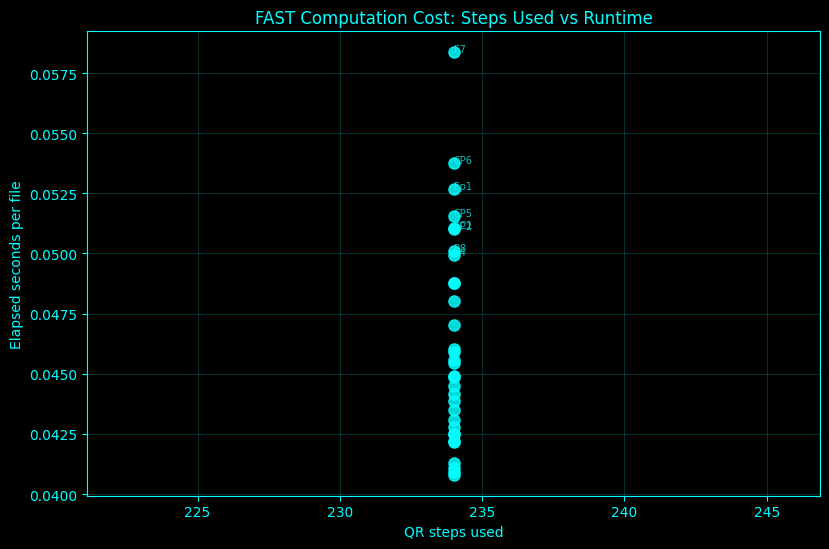

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D_fast/plots/01_fast_steps_used_vs_elapsed_sec.png


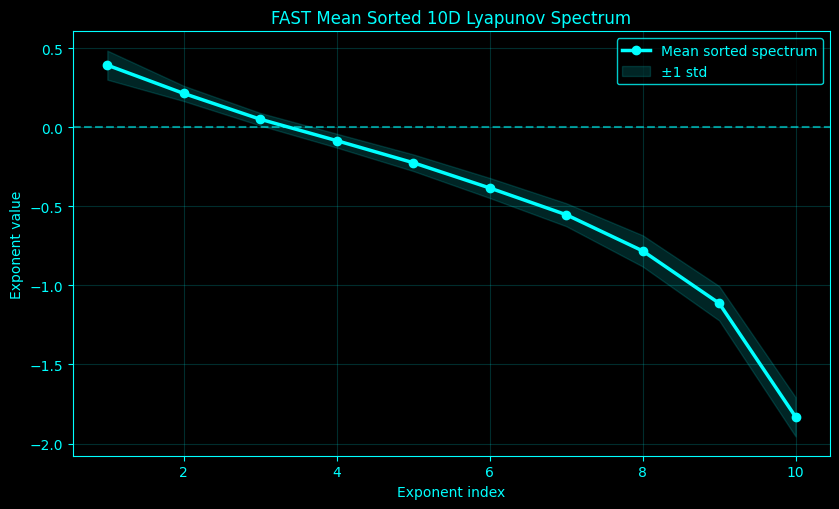

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D_fast/plots/02_fast_mean_sorted_10d_spectrum.png


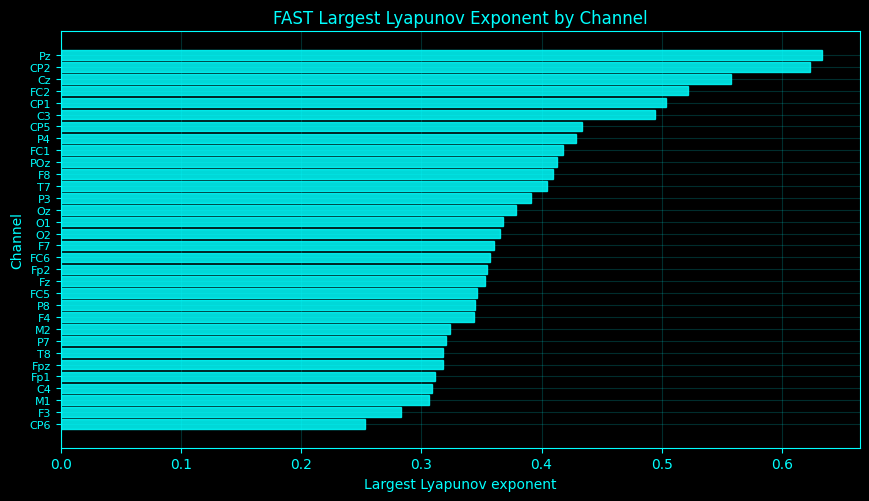

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D_fast/plots/03_fast_lle_by_channel.png


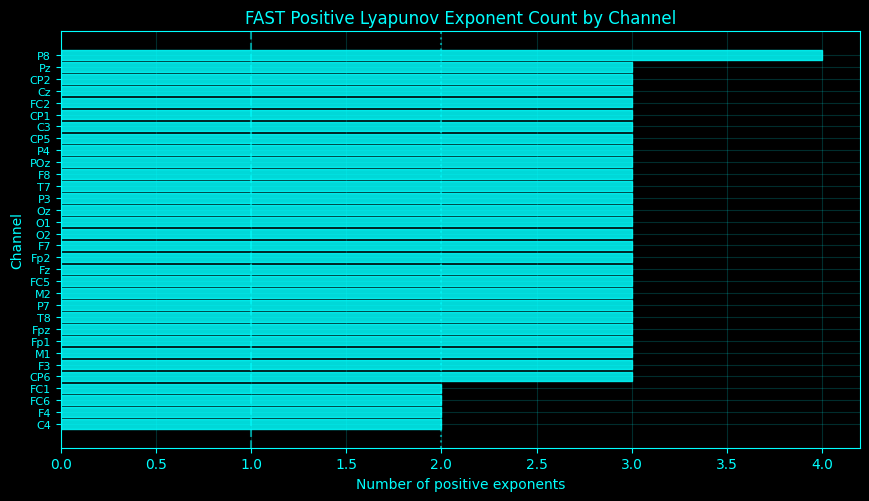

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D_fast/plots/04_fast_positive_exponent_count_by_channel.png


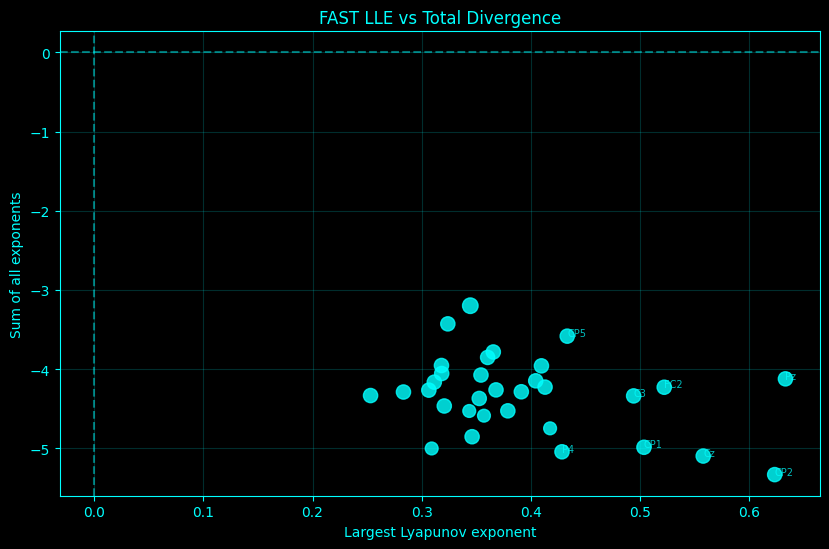

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D_fast/plots/05_fast_lle_vs_divergence.png

All done.
Final spectrum CSV: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D_fast/lyap_spectrum_10D_FAST_20260603_145229.csv
Summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D_fast/lyap_spectrum_10D_FAST_summary_20260603_145229.csv
Checkpoint CSV: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D_fast/checkpoints/lyap_spectrum_10D_FAST_checkpoint_20260603_145229.csv
Plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D_fast/plots


In [1]:
import os
import re
import glob
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor, as_completed

warnings.filterwarnings("ignore", category=RuntimeWarning)

# -------------------------------------------------------
# FAST NEAREST NEIGHBORS
# -------------------------------------------------------
try:
    from scipy.spatial import cKDTree as KDTree
    _HAVE_KDTREE = True
except Exception:
    KDTree = None
    _HAVE_KDTREE = False

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

emb_dir = os.path.join(base_dir, "embedding_data", "embeddings_4to10")

results_dir = os.path.join(base_dir, "lyapunov_results_10D_fast")
plots_dir = os.path.join(results_dir, "plots")
checkpoints_dir = os.path.join(results_dir, "checkpoints")

os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(checkpoints_dir, exist_ok=True)

run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")

OUT_CSV = os.path.join(results_dir, f"lyap_spectrum_10D_FAST_{run_tag}.csv")
OUT_SUMMARY_CSV = os.path.join(results_dir, f"lyap_spectrum_10D_FAST_summary_{run_tag}.csv")
OUT_CHECKPOINT_CSV = os.path.join(checkpoints_dir, f"lyap_spectrum_10D_FAST_checkpoint_{run_tag}.csv")

# -------------------------------------------------------
# SPEED SETTINGS
# -------------------------------------------------------
TARGET_D = 10

# Faster defaults
K_NEIGHBORS = 25       # was 50
THEILER = 10
STRIDE = 30            # was 10. Higher = faster.
MAX_POINTS = 7000      # cap trajectory length. Lower = much faster.
DT = 1.0

# Parallelism
N_WORKERS = min(6, max(1, (os.cpu_count() or 2) - 1))

# For testing
MAX_FILES = None       # set to 5 for test run

CHECKPOINT_EVERY = 20
STANDARDIZE_TRAJECTORY = True
RCOND = None

MAKE_PLOTS = True

# -------------------------------------------------------
# PLOT STYLE
# -------------------------------------------------------
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=180):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)


def compact_height(n_rows, per_row=0.16, min_h=4.8, max_h=7.0):
    return float(min(max_h, max(min_h, per_row * max(n_rows, 1))))


def set_compact_yticks(ax, labels, max_labels=32, fontsize=8):
    labels = list(labels)
    n = len(labels)

    if n == 0:
        return

    if n <= max_labels:
        ticks = np.arange(n)
        shown = labels
    else:
        step = int(np.ceil(n / max_labels))
        ticks = np.arange(0, n, step)
        shown = [labels[i] for i in ticks]

    ax.set_yticks(ticks)
    ax.set_yticklabels(shown, fontsize=fontsize)


def compact_barh(ax, labels, values, max_labels=32):
    labels = list(labels)
    values = np.asarray(values, dtype=float)
    y = np.arange(len(labels))

    ax.barh(
        y,
        values,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.85
    )

    set_compact_yticks(ax, labels, max_labels=max_labels, fontsize=8)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def infer_channel_from_stem(stem):
    stem = str(stem)

    if "dembedded_" in stem:
        return stem.split("dembedded_", 1)[1]

    if "_" in stem:
        return stem.split("_")[-1]

    return stem


def infer_embedding_dim_from_stem(stem):
    stem = str(stem)
    m = re.match(r"^(\d+)dembedded_", stem)

    if m:
        return int(m.group(1))

    m = re.search(r"(\d+)d", stem)

    if m:
        return int(m.group(1))

    return np.nan


def load_npy_safely(fp):
    # mmap helps avoid copying full file immediately
    try:
        arr = np.load(fp, allow_pickle=True, mmap_mode="r")
    except Exception:
        arr = np.load(fp, allow_pickle=True)

    if isinstance(arr, np.ndarray) and arr.dtype == object:
        try:
            arr = np.asarray(arr.tolist(), dtype=float)
        except Exception:
            arr = np.asarray(arr, dtype=float)

    arr = np.asarray(arr, dtype=float)
    arr = np.squeeze(arr)

    return arr


def uniform_subsample_rows(X, max_points):
    X = np.asarray(X, dtype=float)

    if max_points is None or X.shape[0] <= max_points:
        return X

    idx = np.linspace(0, X.shape[0] - 1, max_points).astype(int)
    return X[idx]


def standardize_X(X):
    X = np.asarray(X, dtype=float)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    sd[sd == 0] = 1.0
    return (X - mu) / (sd + 1e-12)


def nan_safe_sort_desc(row_values, target_len=None):
    row_values = np.asarray(row_values, dtype=float)
    finite = row_values[np.isfinite(row_values)]
    finite = np.sort(finite)[::-1]

    if target_len is None:
        target_len = len(row_values)

    out = np.full(target_len, np.nan, dtype=float)
    n = min(len(finite), target_len)
    out[:n] = finite[:n]

    return out


def kaplan_yorke_dimension(exps):
    lam = nan_safe_sort_desc(exps)
    lam = lam[np.isfinite(lam)]

    if len(lam) == 0:
        return np.nan

    cs = np.cumsum(lam)
    valid = np.where(cs >= 0)[0]

    if len(valid) == 0:
        return 0.0

    j = valid[-1]

    if j == len(lam) - 1:
        return float(len(lam))

    denom = lam[j + 1]

    if not np.isfinite(denom) or denom == 0:
        return float(j + 1)

    return float((j + 1) + cs[j] / abs(denom))


def compute_spectrum_metrics(exps_sorted):
    exps_sorted = np.asarray(exps_sorted, dtype=float)
    finite = exps_sorted[np.isfinite(exps_sorted)]

    if len(finite) == 0:
        return {
            "LLE": np.nan,
            "n_positive": np.nan,
            "sum_positive": np.nan,
            "divergence_sum": np.nan,
            "most_negative": np.nan,
            "spectrum_width": np.nan,
            "ky_dim": np.nan,
            "positive_mass_fraction": np.nan,
            "contraction_strength": np.nan,
            "lambda1_lambda2_gap": np.nan,
        }

    pos = finite[finite > 0]
    neg = finite[finite < 0]

    LLE = float(finite[0])
    most_negative = float(np.nanmin(finite))
    sum_positive = float(np.sum(pos)) if len(pos) > 0 else 0.0
    divergence_sum = float(np.sum(finite))
    contraction_strength = float(abs(np.sum(neg))) if len(neg) > 0 else 0.0

    if len(finite) >= 2:
        lambda1_lambda2_gap = float(finite[0] - finite[1])
    else:
        lambda1_lambda2_gap = np.nan

    return {
        "LLE": LLE,
        "n_positive": int(np.sum(finite > 0)),
        "sum_positive": sum_positive,
        "divergence_sum": divergence_sum,
        "most_negative": most_negative,
        "spectrum_width": float(LLE - most_negative),
        "ky_dim": float(kaplan_yorke_dimension(finite)),
        "positive_mass_fraction": float(sum_positive / (abs(divergence_sum) + sum_positive + 1e-12)),
        "contraction_strength": contraction_strength,
        "lambda1_lambda2_gap": lambda1_lambda2_gap,
    }


def _neighbors_indices_fast(X, i, k, theiler, tree=None, extra=80):
    n = X.shape[0]

    if tree is not None:
        qk = min(n, k + extra)

        _, idx = tree.query(X[i], k=qk)
        idx = np.atleast_1d(idx)

        mask = (np.abs(idx - i) > theiler) & (idx >= 0) & (idx < n)
        idx = idx[mask]

        return idx[:k]

    diffs = X - X[i]
    d2 = np.einsum("ij,ij->i", diffs, diffs)

    lo = max(0, i - theiler)
    hi = min(n, i + theiler + 1)
    d2[lo:hi] = np.inf

    if k < len(d2):
        idx = np.argpartition(d2, k)[:k]
        idx = idx[np.argsort(d2[idx])]
    else:
        idx = np.argsort(d2)

    idx = idx[np.isfinite(d2[idx])]

    return idx[:k]


def lyapunov_spectrum_from_trajectory_fast(
    X,
    k_neighbors=25,
    theiler=10,
    stride=30,
    dt=1.0,
    rcond=None,
):
    X = np.asarray(X, dtype=float)

    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape {X.shape}")

    mask = np.all(np.isfinite(X), axis=1)
    X = X[mask]

    n, d = X.shape

    if n < max(20, d + 5):
        raise ValueError(f"Trajectory too short after finite filtering: shape={X.shape}")

    X0 = X[:-1]
    X1 = X[1:]
    n0 = X0.shape[0]

    tree = KDTree(X0) if _HAVE_KDTREE else None

    Q = np.eye(d)
    sums = np.zeros(d, dtype=float)
    used = 0

    min_required = max(d + 1, k_neighbors)
    query_k = min(n0, k_neighbors * 2)

    # Precompute indices once
    candidate_i = np.arange(0, n0 - 1, stride)

    for i in candidate_i:
        nbrs = _neighbors_indices_fast(
            X0,
            i,
            query_k,
            theiler,
            tree=tree,
            extra=80
        )

        nbrs = nbrs[nbrs < (n0 - 1)]

        if nbrs.size < min_required:
            continue

        nbrs = nbrs[:k_neighbors]

        A = X0[nbrs] - X0[i]
        B = X1[nbrs] - X1[i]

        try:
            JT, *_ = np.linalg.lstsq(A, B, rcond=rcond)
            J = JT.T
        except np.linalg.LinAlgError:
            continue

        Z = J @ Q
        Q, R = np.linalg.qr(Z)

        diag = np.abs(np.diag(R))
        diag[diag == 0] = np.finfo(float).tiny

        sums += np.log(diag)
        used += 1

    if used == 0:
        raise ValueError("No usable steps. Try smaller THEILER/K_NEIGHBORS or smaller STRIDE.")

    exps = sums / (used * dt)

    return exps, used, len(candidate_i)


# -------------------------------------------------------
# WORKER
# -------------------------------------------------------
def process_one_file(args):
    (
        fp,
        target_d,
        k_neighbors,
        theiler,
        stride,
        dt,
        max_points,
        standardize_trajectory,
        rcond,
    ) = args

    file_start = time.time()

    file_name = os.path.basename(fp)
    stem = os.path.splitext(file_name)[0]
    channel = infer_channel_from_stem(stem)
    inferred_dim = infer_embedding_dim_from_stem(stem)

    rec = {
        "file": file_name,
        "stem": stem,
        "channel": channel,
        "path": fp,
        "status": "ok",
        "error": "",
        "n_samples_original": np.nan,
        "n_samples_used": np.nan,
        "state_dim": np.nan,
        "inferred_embedding_dim_from_name": inferred_dim,
        "target_dim": target_d,
        "k_neighbors": k_neighbors,
        "theiler": theiler,
        "stride": stride,
        "dt": dt,
        "max_points": max_points,
        "standardized": standardize_trajectory,
        "steps_used": np.nan,
        "candidate_steps": np.nan,
        "usable_step_fraction": np.nan,
        "elapsed_sec": np.nan,
    }

    for i in range(1, target_d + 1):
        rec[f"RawExp{i}"] = np.nan
        rec[f"Exp{i}"] = np.nan

    try:
        X = load_npy_safely(fp)

        if X.ndim != 2:
            rec["status"] = "skip_dim"
            rec["error"] = f"expected 2D array (N,D), got shape {X.shape}"
            rec["elapsed_sec"] = time.time() - file_start
            return rec

        n, d = X.shape
        rec["n_samples_original"] = int(n)
        rec["state_dim"] = int(d)

        if d < target_d:
            rec["status"] = "skip_dim"
            rec["error"] = f"state_dim={d} < target_dim={target_d}"
            rec["elapsed_sec"] = time.time() - file_start
            return rec

        X_target = np.asarray(X[:, :target_d], dtype=float)

        finite_rows = np.all(np.isfinite(X_target), axis=1)
        X_target = X_target[finite_rows]

        X_target = uniform_subsample_rows(X_target, max_points=max_points)
        rec["n_samples_used"] = int(X_target.shape[0])

        if X_target.shape[0] < max(20, target_d + 5):
            rec["status"] = "error"
            rec["error"] = f"too few finite rows after cleaning/subsample: {X_target.shape}"
            rec["elapsed_sec"] = time.time() - file_start
            return rec

        if standardize_trajectory:
            X_target = standardize_X(X_target)

        exps_raw, used, candidate_steps = lyapunov_spectrum_from_trajectory_fast(
            X_target,
            k_neighbors=k_neighbors,
            theiler=theiler,
            stride=stride,
            dt=dt,
            rcond=rcond,
        )

        exps_sorted = nan_safe_sort_desc(exps_raw, target_len=target_d)

        rec["steps_used"] = int(used)
        rec["candidate_steps"] = int(candidate_steps)
        rec["usable_step_fraction"] = float(used / max(1, candidate_steps))

        for i, val in enumerate(exps_raw[:target_d], start=1):
            rec[f"RawExp{i}"] = float(val)

        for i, val in enumerate(exps_sorted[:target_d], start=1):
            rec[f"Exp{i}"] = float(val)

        metric_dict = compute_spectrum_metrics(exps_sorted)

        for key, value in metric_dict.items():
            rec[key] = value

    except Exception as e:
        rec["status"] = "error"
        rec["error"] = f"{type(e).__name__}: {e}"

    rec["elapsed_sec"] = time.time() - file_start
    return rec


# -------------------------------------------------------
# FIND FILES
# -------------------------------------------------------
file_paths = sorted(glob.glob(os.path.join(emb_dir, "**", "*.npy"), recursive=True))

if len(file_paths) == 0:
    raise FileNotFoundError(f"No .npy files found recursively in: {emb_dir}")

# Fast pre-filter: only files that look like 10D or higher
filtered_paths = []

for fp in file_paths:
    stem = os.path.splitext(os.path.basename(fp))[0]
    dim = infer_embedding_dim_from_stem(stem)

    if np.isfinite(dim):
        if int(dim) >= TARGET_D:
            filtered_paths.append(fp)
    else:
        filtered_paths.append(fp)

file_paths = filtered_paths

if MAX_FILES is not None:
    file_paths = file_paths[:MAX_FILES]

print("Using KDTree:", _HAVE_KDTREE, flush=True)
print("Embedding directory:", emb_dir, flush=True)
print("Files after fast dimension pre-filter:", len(file_paths), flush=True)
print("Workers:", N_WORKERS, flush=True)
print("Output CSV:", OUT_CSV, flush=True)

worker_args = [
    (
        fp,
        TARGET_D,
        K_NEIGHBORS,
        THEILER,
        STRIDE,
        DT,
        MAX_POINTS,
        STANDARDIZE_TRAJECTORY,
        RCOND,
    )
    for fp in file_paths
]

# -------------------------------------------------------
# PARALLEL COMPUTE
# -------------------------------------------------------
records = []
run_start = time.time()

if N_WORKERS == 1:
    for idx, args in enumerate(worker_args, start=1):
        rec = process_one_file(args)
        records.append(rec)

        if rec["status"] == "ok":
            print(
                f"[{idx}/{len(worker_args)}] ok {rec['file']} | "
                f"LLE={rec.get('LLE', np.nan):.5g} | "
                f"steps={rec.get('steps_used', np.nan)} | "
                f"time={rec['elapsed_sec']:.2f}s",
                flush=True
            )
        else:
            print(
                f"[{idx}/{len(worker_args)}] {rec['status']} {rec['file']} | {rec['error']}",
                flush=True
            )

        if (idx % CHECKPOINT_EVERY == 0) or (idx == len(worker_args)):
            pd.DataFrame(records).to_csv(OUT_CHECKPOINT_CSV, index=False)
            elapsed = time.time() - run_start
            print(
                f"Checkpoint saved | {idx}/{len(worker_args)} | elapsed={elapsed/60:.2f} min",
                flush=True
            )

else:
    with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
        futures = {
            executor.submit(process_one_file, args): args[0]
            for args in worker_args
        }

        for idx, future in enumerate(as_completed(futures), start=1):
            rec = future.result()
            records.append(rec)

            if rec["status"] == "ok":
                print(
                    f"[{idx}/{len(worker_args)}] ok {rec['file']} | "
                    f"LLE={rec.get('LLE', np.nan):.5g} | "
                    f"steps={rec.get('steps_used', np.nan)} | "
                    f"time={rec['elapsed_sec']:.2f}s",
                    flush=True
                )
            else:
                print(
                    f"[{idx}/{len(worker_args)}] {rec['status']} {rec['file']} | {rec['error']}",
                    flush=True
                )

            if (idx % CHECKPOINT_EVERY == 0) or (idx == len(worker_args)):
                pd.DataFrame(records).to_csv(OUT_CHECKPOINT_CSV, index=False)

                elapsed = time.time() - run_start
                done = len(records)
                avg = elapsed / max(done, 1)
                remaining = len(worker_args) - done

                print(
                    f"Checkpoint saved | {done}/{len(worker_args)} done | "
                    f"elapsed={elapsed/60:.2f} min | "
                    f"est_remaining={remaining * avg / 60:.2f} min",
                    flush=True
                )

df = pd.DataFrame(records)

# Put rows in deterministic order
if "file" in df.columns:
    df = df.sort_values("file").reset_index(drop=True)

df.to_csv(OUT_CSV, index=False)

print("\nSaved final CSV:", OUT_CSV)
print("\nStatus counts:")
print(df["status"].value_counts(dropna=False).to_string())

# -------------------------------------------------------
# SUMMARIES
# -------------------------------------------------------
df_ok = df[df["status"] == "ok"].copy()

if len(df_ok) == 0:
    raise ValueError("No successful Lyapunov spectra were computed. Check errors in the CSV.")

metric_cols = [
    "LLE",
    "n_positive",
    "sum_positive",
    "divergence_sum",
    "ky_dim",
    "spectrum_width",
    "positive_mass_fraction",
    "contraction_strength",
    "lambda1_lambda2_gap",
    "steps_used",
    "candidate_steps",
    "usable_step_fraction",
    "elapsed_sec",
]

summary_stats = df_ok[metric_cols].describe().T
summary_stats.to_csv(OUT_SUMMARY_CSV)

print("\nSaved summary CSV:", OUT_SUMMARY_CSV)

print("\nTop rows by LLE:")
print(
    df_ok
    .sort_values("LLE", ascending=False)
    [["channel", "stem", "LLE", "n_positive", "sum_positive", "divergence_sum", "ky_dim", "steps_used", "elapsed_sec"]]
    .head(12)
    .to_string(index=False)
)

print("\nTop rows by KY dimension:")
print(
    df_ok
    .sort_values("ky_dim", ascending=False)
    [["channel", "stem", "LLE", "n_positive", "sum_positive", "divergence_sum", "ky_dim", "steps_used", "elapsed_sec"]]
    .head(12)
    .to_string(index=False)
)

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
if MAKE_PLOTS:
    exp_cols = [f"Exp{i}" for i in range(1, TARGET_D + 1)]
    E = df_ok[exp_cols].to_numpy(dtype=float)

    # ---------------------------------------------------
    # PLOT 1: runtime
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(8.4, 5.6), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        df_ok["steps_used"],
        df_ok["elapsed_sec"],
        color=ACCENT,
        edgecolor=ACCENT,
        s=65,
        alpha=0.85
    )

    for _, row in df_ok.sort_values("elapsed_sec", ascending=False).head(8).iterrows():
        ax.text(
            row["steps_used"],
            row["elapsed_sec"],
            str(row["channel"]),
            color=ACCENT,
            fontsize=7,
            alpha=0.75
        )

    ax.set_title("FAST Computation Cost: Steps Used vs Runtime")
    ax.set_xlabel("QR steps used")
    ax.set_ylabel("Elapsed seconds per file")

    plot_path = os.path.join(plots_dir, "01_fast_steps_used_vs_elapsed_sec.png")
    save_show_close(fig, plot_path)

    # ---------------------------------------------------
    # PLOT 2: mean spectrum
    # ---------------------------------------------------
    x = np.arange(1, TARGET_D + 1)
    mean_spec = np.nanmean(E, axis=0)
    std_spec = np.nanstd(E, axis=0)

    fig, ax = plt.subplots(figsize=(8.5, 5.2), facecolor=BG)
    style_ax(ax)

    ax.plot(
        x,
        mean_spec,
        color=ACCENT,
        marker="o",
        linewidth=2.5,
        label="Mean sorted spectrum"
    )

    ax.fill_between(
        x,
        mean_spec - std_spec,
        mean_spec + std_spec,
        color=ACCENT,
        alpha=0.15,
        label="±1 std"
    )

    ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.55)

    ax.set_title("FAST Mean Sorted 10D Lyapunov Spectrum")
    ax.set_xlabel("Exponent index")
    ax.set_ylabel("Exponent value")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    plot_path = os.path.join(plots_dir, "02_fast_mean_sorted_10d_spectrum.png")
    save_show_close(fig, plot_path)

    # ---------------------------------------------------
    # PLOT 3: LLE by channel
    # ---------------------------------------------------
    plot_df = df_ok.sort_values("LLE", ascending=True)

    fig, ax = plt.subplots(
        figsize=(8.8, compact_height(len(plot_df))),
        facecolor=BG
    )
    style_ax(ax)

    compact_barh(ax, plot_df["channel"], plot_df["LLE"])

    ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.55)

    ax.set_title("FAST Largest Lyapunov Exponent by Channel")
    ax.set_xlabel("Largest Lyapunov exponent")
    ax.set_ylabel("Channel")

    plot_path = os.path.join(plots_dir, "03_fast_lle_by_channel.png")
    save_show_close(fig, plot_path)

    # ---------------------------------------------------
    # PLOT 4: positive count
    # ---------------------------------------------------
    plot_df = df_ok.sort_values(["n_positive", "LLE"], ascending=True)

    fig, ax = plt.subplots(
        figsize=(8.8, compact_height(len(plot_df))),
        facecolor=BG
    )
    style_ax(ax)

    compact_barh(ax, plot_df["channel"], plot_df["n_positive"])

    ax.axvline(1, color=ACCENT, linestyle="--", alpha=0.55)
    ax.axvline(2, color=ACCENT, linestyle=":", alpha=0.55)

    ax.set_title("FAST Positive Lyapunov Exponent Count by Channel")
    ax.set_xlabel("Number of positive exponents")
    ax.set_ylabel("Channel")

    plot_path = os.path.join(plots_dir, "04_fast_positive_exponent_count_by_channel.png")
    save_show_close(fig, plot_path)

    # ---------------------------------------------------
    # PLOT 5: LLE vs divergence
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(8.4, 5.6), facecolor=BG)
    style_ax(ax)

    sizes = 45 + 20 * df_ok["n_positive"].to_numpy(dtype=float)

    ax.scatter(
        df_ok["LLE"],
        df_ok["divergence_sum"],
        color=ACCENT,
        edgecolor=ACCENT,
        s=sizes,
        alpha=0.82
    )

    for _, row in df_ok.sort_values("LLE", ascending=False).head(8).iterrows():
        ax.text(
            row["LLE"],
            row["divergence_sum"],
            str(row["channel"]),
            color=ACCENT,
            fontsize=7,
            alpha=0.75
        )

    ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.45)
    ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.45)

    ax.set_title("FAST LLE vs Total Divergence")
    ax.set_xlabel("Largest Lyapunov exponent")
    ax.set_ylabel("Sum of all exponents")

    plot_path = os.path.join(plots_dir, "05_fast_lle_vs_divergence.png")
    save_show_close(fig, plot_path)

print("\nAll done.")
print("Final spectrum CSV:", OUT_CSV)
print("Summary CSV:", OUT_SUMMARY_CSV)
print("Checkpoint CSV:", OUT_CHECKPOINT_CSV)
print("Plots saved to:", plots_dir)

# Auto-Selecting the Latest 10D Lyapunov-Spectrum Results and Rendering a Full-Spectrum Heatmap 

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block provides a reproducible “last-run” visualization workflow for Lyapunov-spectrum experiments. It automatically discovers the most recently
            generated CSV in <code>lyapunov_results_10D</code>, loads the results table, filters to successful computations, and renders a heatmap of the full
            Lyapunov spectrum (<code>Exp1…Exp10</code>) for each channel/file. The key intent is to eliminate manual timestamp bookkeeping while ensuring the plotted
            heatmap always corresponds to the newest available spectrum results.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            For each channel/file <code>i</code>, the Lyapunov spectrum is the ordered set of exponents <code>{λ₁,…,λ_D}</code> (here nominally <code>D=10</code>),
            where each exponent measures the asymptotic exponential rate of separation (or contraction) of nearby trajectories along a tangent-space direction:
        </p>
        \[
            \lambda_k =
            \lim_{t \to \infty}
            \frac{1}{t}\ln\left(\frac{\|\delta \mathbf{x}_k(t)\|}{\|\delta \mathbf{x}_k(0)\|}\right),
            \quad k=1,\dots,D
        \]
        <p>
            A heatmap of the spectrum is a compact diagnostic: rows correspond to channels/files, columns to exponent indices, and color encodes the exponent value.
            This enables rapid comparison of dynamical stability/instability across channels, including whether <code>λ₁</code> (the LLE) is positive and how strongly
            dissipative the remaining directions are.
        </p>
        <h2>Data Model and Robust Column Selection</h2>
        <p>
            The script expects a CSV schema produced by upstream computation, typically including:
            <ul>
                <li><code>stem</code>: channel/file identifier used for row labels,</li>
                <li><code>status</code>: quality-control label (only <code>ok</code> rows are plotted),</li>
                <li><code>Exp1…Exp10</code>: Lyapunov exponents, one column per exponent index.</li>
            </ul>
            To remain robust to partial outputs or different dimensional runs, the block constructs the intended exponent list and then filters to columns that
            actually exist (<code>exp_cols = [c for c in exp_cols if c in df_ok.columns]</code>). This prevents runtime errors and makes the plot adapt automatically
            if a run produced fewer than 10 exponents.
        </p>
        <h2>Why “Latest File” Selection Matters</h2>
        <p>
            Spectrum estimation is often iterated with different hyperparameters (neighbors, stride, Theiler window, embedding choice). Using filesystem
            modification time (<code>os.path.getmtime</code>) ensures the visualization always targets the most recent run artifact, reducing the risk of accidentally
            plotting stale results and improving experimental traceability.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Discover</b> all matching result files (<code>glob("lyap_spectrum_10D_*.csv")</code>).</li>
                <li><b>Select</b> the most recently modified file via <code>max(..., key=os.path.getmtime)</code>.</li>
                <li><b>Load</b> the table with <code>pd.read_csv</code> and filter to successful rows (<code>status == "ok"</code>).</li>
                <li><b>Assemble</b> a dense matrix <code>Z</code> with shape <code>(n_channels, D)</code> from <code>Exp*</code> columns.</li>
                <li><b>Render</b> a heatmap using <code>matplotlib.imshow</code> with a diverging colormap centered at zero.</li>
            </ol>
            The plot title is parameterized by the number of exponent columns actually present, which provides an immediate sanity check on dimensionality.
        </p>
        <h2>Color Scaling and Interpretability</h2>
        <p>
            The color range is set symmetrically to <code>[-v, +v]</code> where <code>v = max(|Z|)</code>. Symmetric scaling ensures that zero is visually central:
            positive exponents (expansion/instability) and negative exponents (contraction/stability) are comparable across channels. This is a principled default
            for Lyapunov spectra; however, if tail exponents are large in magnitude, they can dominate the scale and compress the visual contrast of near-zero exponents
            (in which case a z-scored heatmap is a complementary diagnostic).
        </p>
        <h2>Axis Semantics</h2>
        <p>
            <ul>
                <li><b>Rows (y-axis):</b> channels/files indexed by <code>stem</code>, sorted alphabetically for reproducibility.</li>
                <li><b>Columns (x-axis):</b> exponent indices (<code>Exp1…ExpD</code>), representing the available Lyapunov spectrum.</li>
                <li><b>Cell color:</b> exponent magnitude and sign for that channel and exponent index.</li>
            </ul>
            The heatmap is therefore a direct visualization of the spectrum matrix <code>Z</code>.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This view is most useful for:
            <ul>
                <li>Quickly spotting channels with unusually positive <code>Exp1</code> (potentially stronger chaos/instability),</li>
                <li>Comparing spectral “shape” across channels (e.g., whether contraction strengthens rapidly in higher indices),</li>
                <li>Identifying outliers that may indicate artifacts, embedding issues, or genuinely distinct dynamics.</li>
            </ul>
            For rigorous conclusions, exponents should be validated for stability across time windows and parameter sensitivity (neighbors, Theiler window, stride).
        </p>
        <h2>Reproducibility Tip</h2>
        <p>
            Because the selected file is printed (<code>print("Latest:", latest)</code>), the exact artifact used for plotting is recorded in logs/notebooks.
            This makes it easy to trace plots back to a specific run and ensures downstream figures remain auditable.
        </p>
    </div>
</div>

Latest usable 10D Lyapunov CSV: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D_fast/lyap_spectrum_10D_FAST_20260603_145229.csv
Using exponent columns: ['Exp1', 'Exp2', 'Exp3', 'Exp4', 'Exp5', 'Exp6', 'Exp7', 'Exp8', 'Exp9', 'Exp10']

Saved clean metrics CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/latest_10d_lyapunov_clean_metrics.csv

Rows used: 32

Top rows by LLE:
channel            stem      LLE  lambda2  n_positive_tol  sum_positive_tol  divergence_sum  KY_dimension
     Pz  10dembedded_Pz 0.633395 0.336675               3          1.086355       -4.124398      6.598995
    CP2 10dembedded_CP2 0.623527 0.193159               3          0.854736       -5.334345      5.634615
     Cz  10dembedded_Cz 0.558033 0.283314               3          0.880134       -5.099705      5.822814
    FC2 10dembedded_FC2 0.522296 0.280596               3          0.889544       -4.230254      6.159499
    CP1 10dembedded_CP1 0.

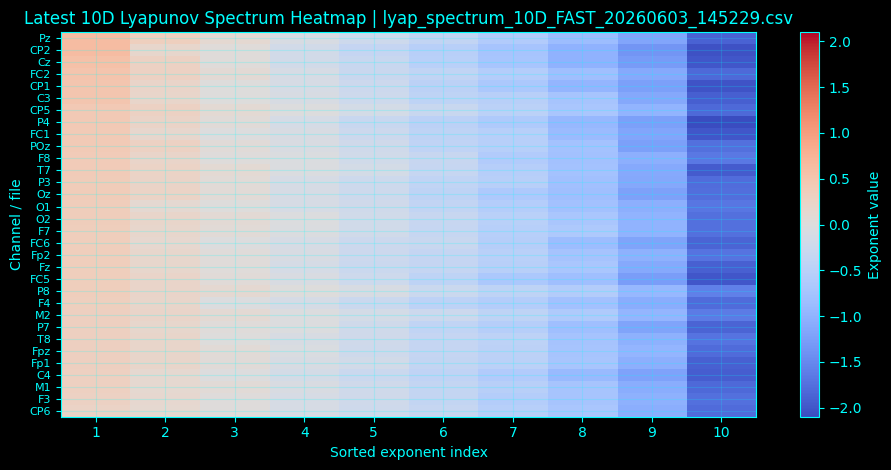

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/plots/01_latest_10d_sorted_spectrum_heatmap.png


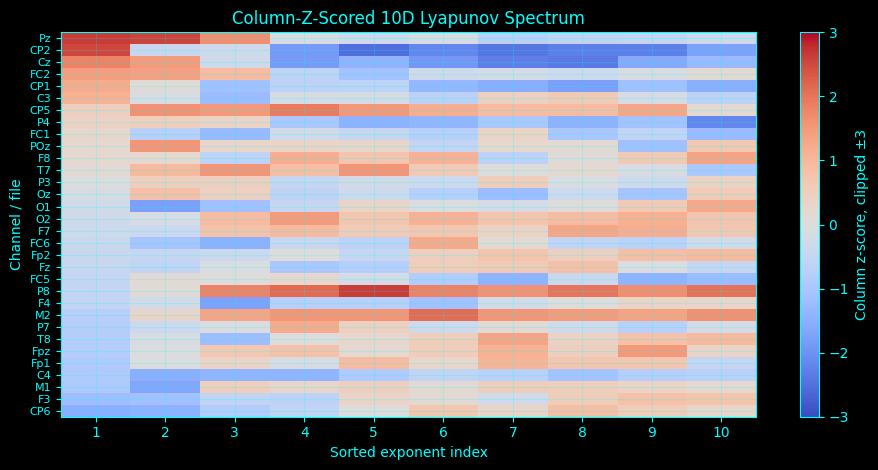

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/plots/02_latest_10d_column_zscore_heatmap.png


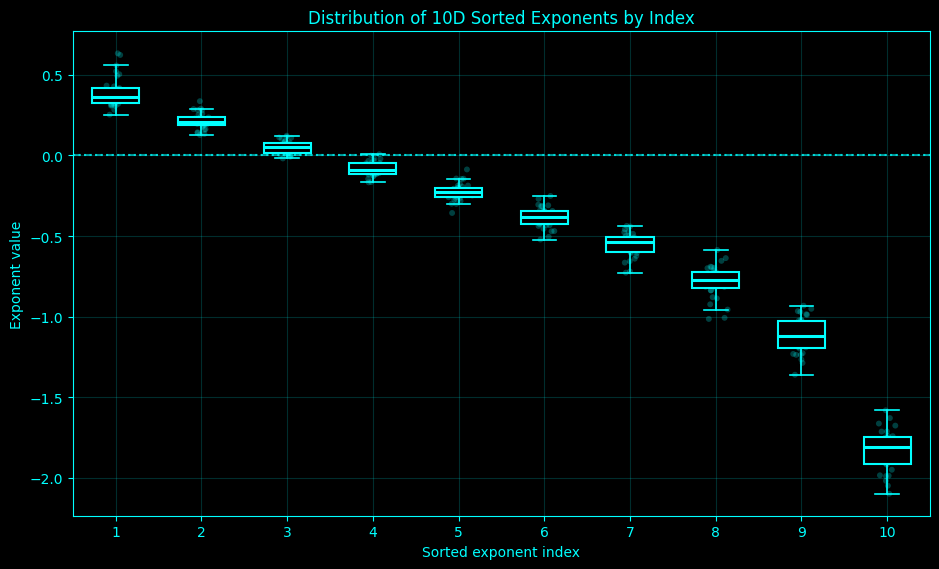

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/plots/03_latest_10d_exponent_distributions.png


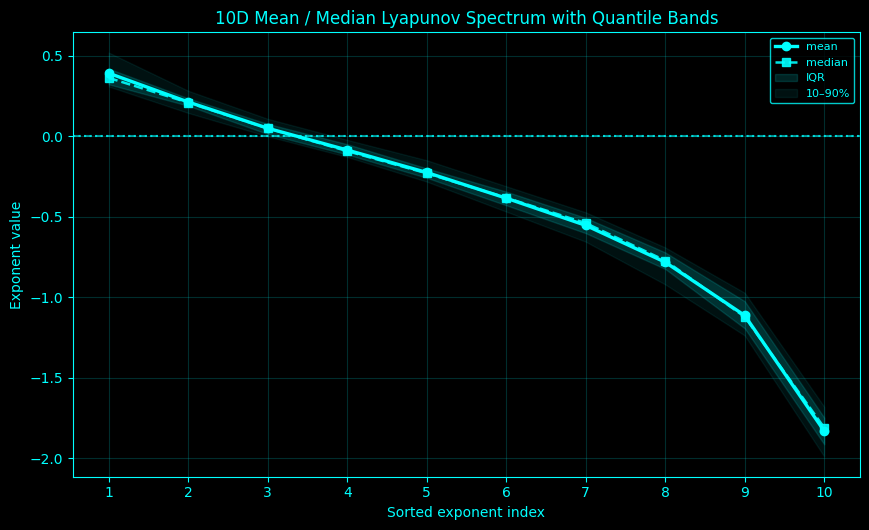

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/plots/04_latest_10d_mean_median_quantile_spectrum.png


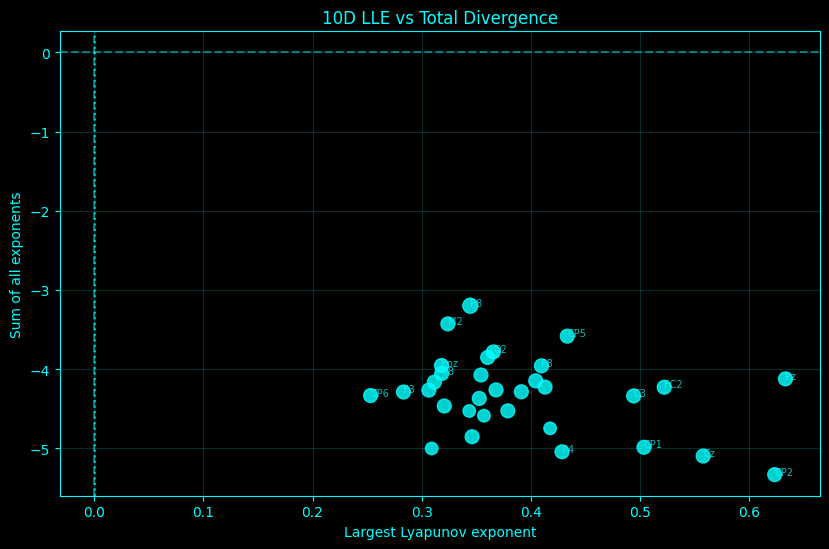

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/plots/05_latest_10d_lle_vs_divergence.png


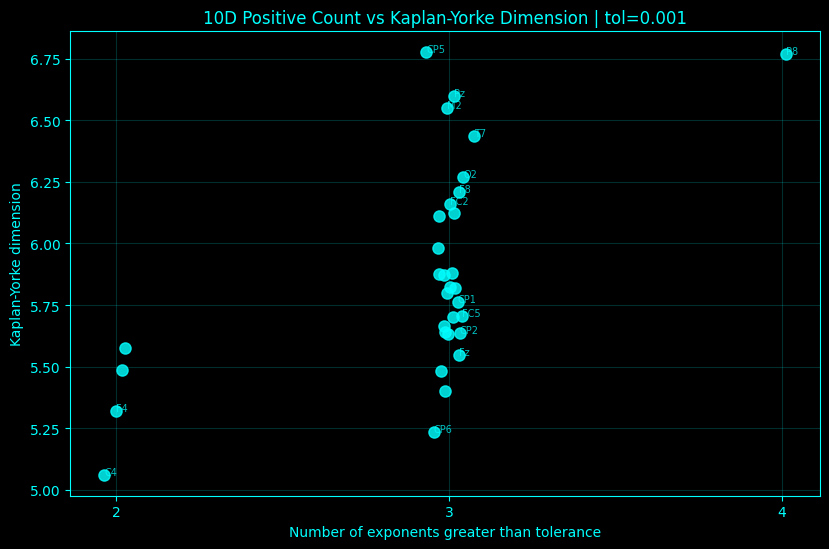

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/plots/06_latest_10d_positive_count_vs_ky.png


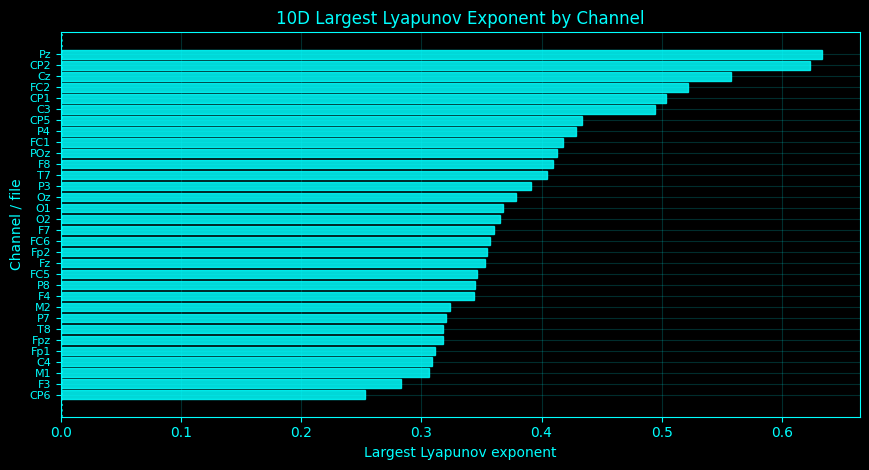

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/plots/07_latest_10d_lle_by_channel.png


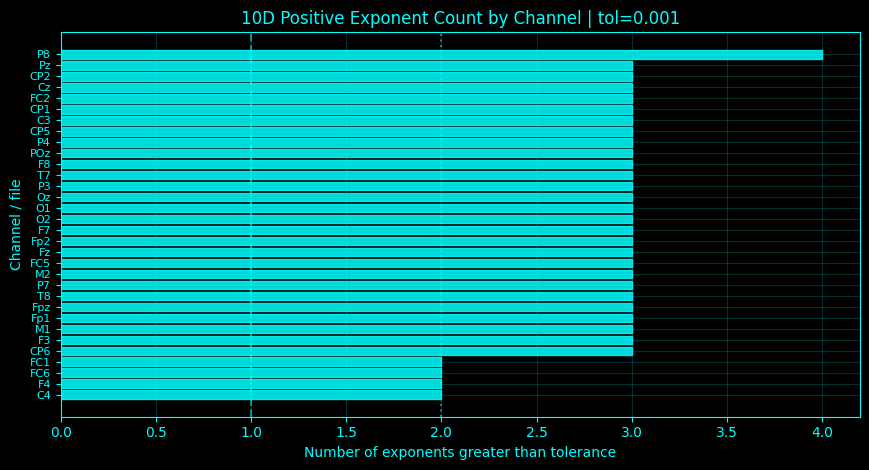

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/plots/08_latest_10d_positive_count_by_channel.png


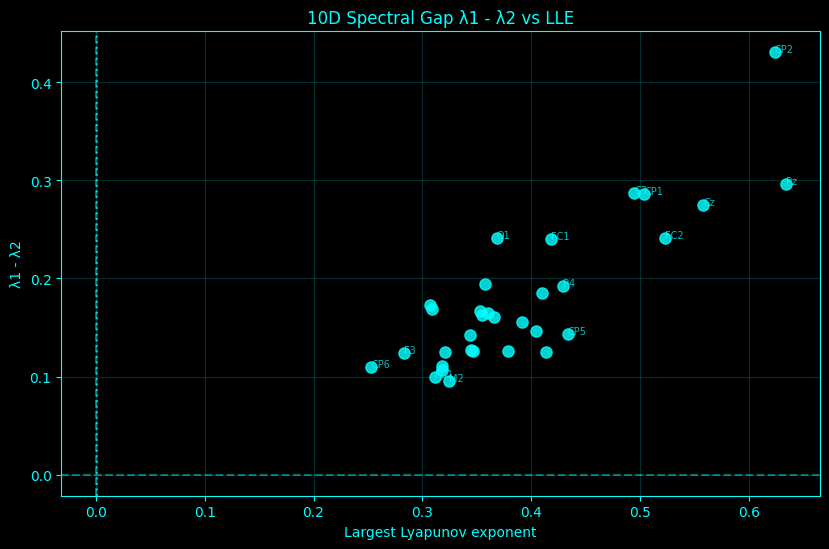

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/plots/09_latest_10d_spectral_gap_vs_lle.png


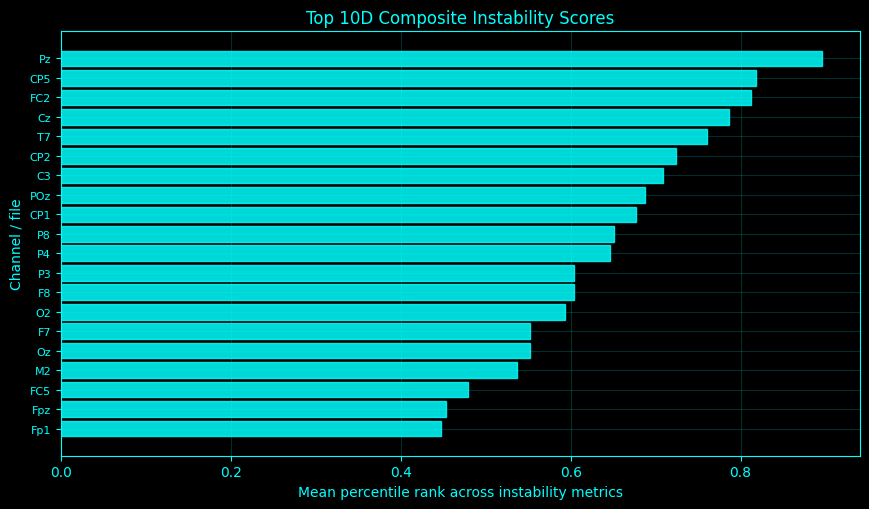

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/plots/10_latest_10d_composite_instability_scores.png

Done.
Input CSV: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D_fast/lyap_spectrum_10D_FAST_20260603_145229.csv
Rows plotted: 32
Plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/plots
Clean metrics CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/latest_10d_lyapunov_clean_metrics.csv
Composite score CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/latest_10d_composite_instability_scores.csv
Summary statistics CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/latest_10d_summary_statistics.csv


In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

# Search both regular and fast result directories
candidate_result_dirs = [
    os.path.join(base_dir, "lyapunov_results_10D"),
    os.path.join(base_dir, "lyapunov_results_10D_fast"),
]

results_dir = os.path.join(base_dir, "results", "latest_10d_lyapunov_file_analysis")
plots_dir = os.path.join(results_dir, "plots")

os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

TARGET_D = 10
POSITIVE_TOL = 1e-3
Z_CLIP = 3.0
RANDOM_SEED = 42

ACCENT = "cyan"
BG = "black"

CYAN_CMAP = LinearSegmentedColormap.from_list(
    "black_to_cyan",
    ["black", "#003333", "#008888", "cyan"]
)

DIVERGING_CMAP = plt.get_cmap("coolwarm").copy()
DIVERGING_CMAP.set_bad(color=BG)

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=220):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)


def compact_height(n_rows, per_row=0.15, min_h=4.8, max_h=7.2):
    return float(min(max_h, max(min_h, per_row * max(n_rows, 1))))


def set_compact_yticks(ax, labels, max_labels=36, fontsize=8):
    labels = list(labels)
    n = len(labels)

    if n == 0:
        return

    if n <= max_labels:
        ticks = np.arange(n)
        shown = labels
    else:
        step = int(np.ceil(n / max_labels))
        ticks = np.arange(0, n, step)
        shown = [labels[i] for i in ticks]

    ax.set_yticks(ticks)
    ax.set_yticklabels(shown, fontsize=fontsize)


def compact_barh(ax, labels, values, max_labels=36):
    labels = list(labels)
    values = np.asarray(values, dtype=float)
    y = np.arange(len(labels))

    ax.barh(
        y,
        values,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.85
    )

    set_compact_yticks(ax, labels, max_labels=max_labels, fontsize=8)


def annotate_extremes(ax, df, x_col, y_col, label_col="channel", top_n=8):
    parts = []

    for col in [x_col, y_col]:
        finite_df = df[np.isfinite(df[col])].copy()

        if len(finite_df) == 0:
            continue

        parts.append(finite_df.sort_values(col, ascending=False).head(top_n))
        parts.append(finite_df.sort_values(col, ascending=True).head(max(2, top_n // 3)))

    if len(parts) == 0:
        return

    label_df = pd.concat(parts).drop_duplicates()

    for _, row in label_df.iterrows():
        if np.isfinite(row[x_col]) and np.isfinite(row[y_col]):
            ax.text(
                row[x_col],
                row[y_col],
                str(row[label_col]),
                color=ACCENT,
                fontsize=7,
                alpha=0.75
            )


# -------------------------------------------------------
# FILE HELPERS
# -------------------------------------------------------
def csv_has_exponent_columns(path):
    try:
        cols = pd.read_csv(path, nrows=0).columns
    except Exception:
        return False

    return any(re.match(r"^Exp\d+$", c) for c in cols)


def find_latest_usable_10d_csv():
    candidates = []

    for d in candidate_result_dirs:
        if not os.path.isdir(d):
            continue

        patterns = [
            os.path.join(d, "lyap_spectrum_10D_*.csv"),
            os.path.join(d, "lyap_spectrum_10D_FAST_*.csv"),
        ]

        for pattern in patterns:
            candidates.extend(glob.glob(pattern))

    bad_tokens = [
        "summary",
        "checkpoint",
        "composite",
        "score",
        "matrix",
        "zscore",
        "stability",
        "outlier",
    ]

    usable = []

    for path in sorted(set(candidates)):
        name = os.path.basename(path).lower()

        if any(tok in name for tok in bad_tokens):
            continue

        if csv_has_exponent_columns(path):
            usable.append(path)

    usable = sorted(usable, key=lambda p: os.path.getmtime(p), reverse=True)

    if len(usable) == 0:
        raise FileNotFoundError(
            "No usable 10D Lyapunov spectrum CSV found. "
            "Expected a file with Exp1, Exp2, ... columns."
        )

    return usable[0]


CSV_PATH = find_latest_usable_10d_csv()
print("Latest usable 10D Lyapunov CSV:", CSV_PATH, flush=True)

df = pd.read_csv(CSV_PATH)

# -------------------------------------------------------
# BASIC HELPERS
# -------------------------------------------------------
def infer_channel_from_stem(stem):
    stem = str(stem)

    if "dembedded_" in stem:
        return stem.split("dembedded_", 1)[1]

    if "_" in stem:
        return stem.split("_")[-1]

    return stem


def nan_safe_sort_desc(row_values, target_len=None):
    row_values = np.asarray(row_values, dtype=float)
    finite = row_values[np.isfinite(row_values)]
    finite = np.sort(finite)[::-1]

    if target_len is None:
        target_len = len(row_values)

    out = np.full(target_len, np.nan, dtype=float)
    n = min(len(finite), target_len)
    out[:n] = finite[:n]

    return out


def ky_dim_row(lam):
    lam = np.asarray(lam, dtype=float)
    lam = lam[np.isfinite(lam)]

    if len(lam) == 0:
        return np.nan

    cs = np.cumsum(lam)
    valid = np.where(cs >= 0)[0]

    if len(valid) == 0:
        return 0.0

    j = valid[-1]

    if j == len(lam) - 1:
        return float(len(lam))

    denom = lam[j + 1]

    if not np.isfinite(denom) or denom == 0:
        return float(j + 1)

    return float((j + 1) + cs[j] / abs(denom))


def column_zscore(Z):
    Z = np.asarray(Z, dtype=float)
    mu = np.nanmean(Z, axis=0, keepdims=True)
    sd = np.nanstd(Z, axis=0, keepdims=True) + 1e-12
    return (Z - mu) / sd


# -------------------------------------------------------
# CLEAN DATA
# -------------------------------------------------------
if "status" in df.columns:
    df_ok = df[df["status"].astype(str).str.lower() == "ok"].copy()
else:
    df_ok = df.copy()
    df_ok["status"] = "ok"

if len(df_ok) == 0:
    raise ValueError("No successful rows found in selected CSV.")

exp_cols = [f"Exp{i}" for i in range(1, TARGET_D + 1)]
exp_cols = [c for c in exp_cols if c in df_ok.columns]

if len(exp_cols) == 0:
    raise ValueError("No Exp1...Exp10 columns found.")

print("Using exponent columns:", exp_cols, flush=True)

for c in exp_cols:
    df_ok[c] = pd.to_numeric(df_ok[c], errors="coerce")

E_raw = df_ok[exp_cols].to_numpy(dtype=float)

valid_rows = np.isfinite(E_raw).any(axis=1)
df_ok = df_ok.loc[valid_rows].copy().reset_index(drop=True)
E_raw = E_raw[valid_rows]

if len(df_ok) == 0:
    raise ValueError("No rows with finite exponents after cleaning.")

# Re-sort safely in case the file was not sorted or contains NaNs
E_sorted = np.vstack([
    nan_safe_sort_desc(row, target_len=len(exp_cols))
    for row in E_raw
])

sorted_cols = [f"SortedExp{i + 1}" for i in range(E_sorted.shape[1])]

for i, c in enumerate(sorted_cols):
    df_ok[c] = E_sorted[:, i]

if "stem" not in df_ok.columns:
    if "file" in df_ok.columns:
        df_ok["stem"] = df_ok["file"].astype(str).str.replace(".npy", "", regex=False)
    else:
        df_ok["stem"] = [f"row_{i}" for i in range(len(df_ok))]

if "channel" not in df_ok.columns:
    df_ok["channel"] = df_ok["stem"].apply(infer_channel_from_stem)

# -------------------------------------------------------
# COMPUTE / RECOMPUTE METRICS
# -------------------------------------------------------
df_ok["LLE"] = np.array([
    np.nanmax(row) if np.isfinite(row).any() else np.nan
    for row in E_sorted
], dtype=float)

df_ok["lambda2"] = E_sorted[:, 1] if E_sorted.shape[1] >= 2 else np.nan
df_ok["lambda3"] = E_sorted[:, 2] if E_sorted.shape[1] >= 3 else np.nan

df_ok["n_positive_strict"] = np.array([
    int(np.sum(row[np.isfinite(row)] > 0.0))
    for row in E_sorted
])

df_ok["n_positive_tol"] = np.array([
    int(np.sum(row[np.isfinite(row)] > POSITIVE_TOL))
    for row in E_sorted
])

df_ok["sum_positive_strict"] = np.array([
    float(np.sum(row[np.isfinite(row) & (row > 0.0)]))
    for row in E_sorted
])

df_ok["sum_positive_tol"] = np.array([
    float(np.sum(row[np.isfinite(row) & (row > POSITIVE_TOL)]))
    for row in E_sorted
])

df_ok["divergence_sum"] = np.array([
    float(np.sum(row[np.isfinite(row)]))
    for row in E_sorted
])

df_ok["most_negative"] = np.array([
    np.nanmin(row) if np.isfinite(row).any() else np.nan
    for row in E_sorted
], dtype=float)

df_ok["spectrum_width"] = df_ok["LLE"] - df_ok["most_negative"]

df_ok["lambda1_lambda2_gap"] = df_ok["LLE"] - df_ok["lambda2"]

df_ok["KY_dimension"] = np.array([
    ky_dim_row(row)
    for row in E_sorted
], dtype=float)

df_ok["positive_mass_fraction"] = df_ok["sum_positive_tol"] / (
    np.abs(df_ok["divergence_sum"]) + df_ok["sum_positive_tol"] + 1e-12
)

# Stable plot labels
channel_counts = df_ok["channel"].value_counts()

if (channel_counts > 1).any():
    df_ok["plot_label"] = df_ok["channel"].astype(str) + " | " + df_ok["stem"].astype(str)
else:
    df_ok["plot_label"] = df_ok["channel"].astype(str)

# -------------------------------------------------------
# SAVE CLEAN ANALYSIS TABLE
# -------------------------------------------------------
out_clean_csv = os.path.join(results_dir, "latest_10d_lyapunov_clean_metrics.csv")
df_ok.to_csv(out_clean_csv, index=False)

print("\nSaved clean metrics CSV:", out_clean_csv)
print("\nRows used:", len(df_ok))

print("\nTop rows by LLE:")
print(
    df_ok
    .sort_values("LLE", ascending=False)
    [["channel", "stem", "LLE", "lambda2", "n_positive_tol", "sum_positive_tol", "divergence_sum", "KY_dimension"]]
    .head(12)
    .to_string(index=False)
)

# -------------------------------------------------------
# PLOT 1: COMPACT SORTED SPECTRUM HEATMAP
# -------------------------------------------------------
heat_df = df_ok.sort_values("LLE", ascending=True)
heat_matrix = heat_df[sorted_cols].to_numpy(dtype=float)

fig, ax = plt.subplots(
    figsize=(9.5, compact_height(len(heat_df))),
    facecolor=BG
)
style_ax(ax)

v = np.nanmax(np.abs(heat_matrix)) if np.isfinite(heat_matrix).any() else 1.0
M = np.ma.masked_invalid(heat_matrix)

im = ax.imshow(
    M,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap=DIVERGING_CMAP,
    vmin=-v,
    vmax=v
)

ax.set_title(f"Latest 10D Lyapunov Spectrum Heatmap | {os.path.basename(CSV_PATH)}")
ax.set_xlabel("Sorted exponent index")
ax.set_ylabel("Channel / file")

ax.set_xticks(np.arange(len(sorted_cols)))
ax.set_xticklabels([str(i + 1) for i in range(len(sorted_cols))])

set_compact_yticks(ax, heat_df["plot_label"].values, max_labels=36, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Exponent value")
style_colorbar(cbar)

plot_path = os.path.join(plots_dir, "01_latest_10d_sorted_spectrum_heatmap.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 2: COLUMN-Z-SCORED SPECTRUM HEATMAP
# -------------------------------------------------------
Zz = column_zscore(heat_matrix)
Zz_clip = np.clip(Zz, -Z_CLIP, Z_CLIP)
M = np.ma.masked_invalid(Zz_clip)

fig, ax = plt.subplots(
    figsize=(9.5, compact_height(len(heat_df))),
    facecolor=BG
)
style_ax(ax)

im = ax.imshow(
    M,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap=DIVERGING_CMAP,
    vmin=-Z_CLIP,
    vmax=Z_CLIP
)

ax.set_title("Column-Z-Scored 10D Lyapunov Spectrum")
ax.set_xlabel("Sorted exponent index")
ax.set_ylabel("Channel / file")

ax.set_xticks(np.arange(len(sorted_cols)))
ax.set_xticklabels([str(i + 1) for i in range(len(sorted_cols))])

set_compact_yticks(ax, heat_df["plot_label"].values, max_labels=36, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f"Column z-score, clipped ±{Z_CLIP:g}")
style_colorbar(cbar)

plot_path = os.path.join(plots_dir, "02_latest_10d_column_zscore_heatmap.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 3: ALL EXPONENT DISTRIBUTIONS BY INDEX
# -------------------------------------------------------
data_by_index = [
    df_ok[c].dropna().to_numpy(dtype=float)
    for c in sorted_cols
]

fig, ax = plt.subplots(figsize=(9.5, 5.8), facecolor=BG)
style_ax(ax)

bp = ax.boxplot(
    data_by_index,
    positions=np.arange(len(sorted_cols)),
    widths=0.55,
    patch_artist=True,
    showfliers=False
)

for box in bp["boxes"]:
    box.set(facecolor=BG, edgecolor=ACCENT, linewidth=1.5)
for whisker in bp["whiskers"]:
    whisker.set(color=ACCENT, linewidth=1.2)
for cap in bp["caps"]:
    cap.set(color=ACCENT, linewidth=1.2)
for median in bp["medians"]:
    median.set(color=ACCENT, linewidth=2.2)

rng = np.random.default_rng(RANDOM_SEED)

for i, vals in enumerate(data_by_index):
    if len(vals) == 0:
        continue

    jitter = rng.normal(0, 0.055, size=len(vals))

    ax.scatter(
        np.full(len(vals), i) + jitter,
        vals,
        color=ACCENT,
        alpha=0.25,
        s=18,
        edgecolor="none"
    )

ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.55)
ax.axhline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)

ax.set_xticks(np.arange(len(sorted_cols)))
ax.set_xticklabels([str(i + 1) for i in range(len(sorted_cols))])

ax.set_title("Distribution of 10D Sorted Exponents by Index")
ax.set_xlabel("Sorted exponent index")
ax.set_ylabel("Exponent value")

plot_path = os.path.join(plots_dir, "03_latest_10d_exponent_distributions.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 4: MEAN SPECTRUM WITH QUANTILE BAND
# -------------------------------------------------------
x = np.arange(1, len(sorted_cols) + 1)

q10 = np.nanpercentile(heat_matrix, 10, axis=0)
q25 = np.nanpercentile(heat_matrix, 25, axis=0)
median = np.nanpercentile(heat_matrix, 50, axis=0)
q75 = np.nanpercentile(heat_matrix, 75, axis=0)
q90 = np.nanpercentile(heat_matrix, 90, axis=0)
mean_spec = np.nanmean(heat_matrix, axis=0)

fig, ax = plt.subplots(figsize=(8.8, 5.4), facecolor=BG)
style_ax(ax)

ax.plot(
    x,
    mean_spec,
    color=ACCENT,
    marker="o",
    linewidth=2.4,
    label="mean"
)

ax.plot(
    x,
    median,
    color=ACCENT,
    marker="s",
    linestyle="--",
    linewidth=1.8,
    alpha=0.9,
    label="median"
)

ax.fill_between(
    x,
    q25,
    q75,
    color=ACCENT,
    alpha=0.14,
    label="IQR"
)

ax.fill_between(
    x,
    q10,
    q90,
    color=ACCENT,
    alpha=0.07,
    label="10–90%"
)

ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.55)
ax.axhline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)

ax.set_title("10D Mean / Median Lyapunov Spectrum with Quantile Bands")
ax.set_xlabel("Sorted exponent index")
ax.set_ylabel("Exponent value")
ax.set_xticks(x)

leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, "04_latest_10d_mean_median_quantile_spectrum.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 5: LLE VS DIVERGENCE
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.4, 5.6), facecolor=BG)
style_ax(ax)

sizes = 45 + 18 * df_ok["n_positive_tol"].to_numpy(dtype=float)

ax.scatter(
    df_ok["LLE"],
    df_ok["divergence_sum"],
    color=ACCENT,
    edgecolor=ACCENT,
    s=sizes,
    alpha=0.82
)

annotate_extremes(
    ax,
    df_ok,
    x_col="LLE",
    y_col="divergence_sum",
    label_col="channel",
    top_n=8
)

ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.45)
ax.axvline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)
ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.45)

ax.set_title("10D LLE vs Total Divergence")
ax.set_xlabel("Largest Lyapunov exponent")
ax.set_ylabel("Sum of all exponents")

plot_path = os.path.join(plots_dir, "05_latest_10d_lle_vs_divergence.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 6: POSITIVE COUNT VS KY DIMENSION
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.4, 5.6), facecolor=BG)
style_ax(ax)

rng = np.random.default_rng(RANDOM_SEED)
npos_jitter = df_ok["n_positive_tol"].astype(float).to_numpy() + rng.normal(
    0,
    0.035,
    size=len(df_ok)
)

ax.scatter(
    npos_jitter,
    df_ok["KY_dimension"],
    color=ACCENT,
    edgecolor=ACCENT,
    s=65,
    alpha=0.82
)

plot_df_tmp = df_ok.copy()
plot_df_tmp["npos_jitter"] = npos_jitter

annotate_extremes(
    ax,
    plot_df_tmp,
    x_col="npos_jitter",
    y_col="KY_dimension",
    label_col="channel",
    top_n=8
)

ax.set_xticks(sorted(df_ok["n_positive_tol"].dropna().astype(int).unique()))

ax.set_title(f"10D Positive Count vs Kaplan-Yorke Dimension | tol={POSITIVE_TOL:g}")
ax.set_xlabel("Number of exponents greater than tolerance")
ax.set_ylabel("Kaplan-Yorke dimension")

plot_path = os.path.join(plots_dir, "06_latest_10d_positive_count_vs_ky.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 7: LLE BY CHANNEL
# -------------------------------------------------------
plot_df = df_ok.sort_values("LLE", ascending=True)

fig, ax = plt.subplots(
    figsize=(8.8, compact_height(len(plot_df))),
    facecolor=BG
)
style_ax(ax)

compact_barh(ax, plot_df["plot_label"], plot_df["LLE"])

ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.55)
ax.axvline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)

ax.set_title("10D Largest Lyapunov Exponent by Channel")
ax.set_xlabel("Largest Lyapunov exponent")
ax.set_ylabel("Channel / file")

plot_path = os.path.join(plots_dir, "07_latest_10d_lle_by_channel.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 8: POSITIVE EXPONENT COUNT BY CHANNEL
# -------------------------------------------------------
plot_df = df_ok.sort_values(["n_positive_tol", "LLE"], ascending=True)

fig, ax = plt.subplots(
    figsize=(8.8, compact_height(len(plot_df))),
    facecolor=BG
)
style_ax(ax)

compact_barh(ax, plot_df["plot_label"], plot_df["n_positive_tol"])

ax.axvline(1, color=ACCENT, linestyle="--", alpha=0.55)
ax.axvline(2, color=ACCENT, linestyle=":", alpha=0.55)

ax.set_title(f"10D Positive Exponent Count by Channel | tol={POSITIVE_TOL:g}")
ax.set_xlabel("Number of exponents greater than tolerance")
ax.set_ylabel("Channel / file")

plot_path = os.path.join(plots_dir, "08_latest_10d_positive_count_by_channel.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 9: SPECTRAL GAP VS LLE
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.4, 5.6), facecolor=BG)
style_ax(ax)

ax.scatter(
    df_ok["LLE"],
    df_ok["lambda1_lambda2_gap"],
    color=ACCENT,
    edgecolor=ACCENT,
    s=65,
    alpha=0.82
)

annotate_extremes(
    ax,
    df_ok,
    x_col="LLE",
    y_col="lambda1_lambda2_gap",
    label_col="channel",
    top_n=8
)

ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.45)
ax.axvline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)
ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.45)

ax.set_title("10D Spectral Gap λ1 - λ2 vs LLE")
ax.set_xlabel("Largest Lyapunov exponent")
ax.set_ylabel("λ1 - λ2")

plot_path = os.path.join(plots_dir, "09_latest_10d_spectral_gap_vs_lle.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# PLOT 10: COMPOSITE INSTABILITY SCORE
# -------------------------------------------------------
score_df = df_ok.copy()

score_cols = [
    "LLE",
    "sum_positive_tol",
    "n_positive_tol",
    "KY_dimension",
    "spectrum_width",
    "positive_mass_fraction",
]

rank_cols = []

for col in score_cols:
    rank_col = f"{col}_percentile"

    if score_df[col].notna().sum() <= 1:
        score_df[rank_col] = 0.5
    else:
        score_df[rank_col] = score_df[col].rank(pct=True)

    rank_cols.append(rank_col)

score_df["composite_instability_score"] = score_df[rank_cols].mean(axis=1)

score_csv = os.path.join(results_dir, "latest_10d_composite_instability_scores.csv")
score_df.to_csv(score_csv, index=False)

plot_df = score_df.sort_values("composite_instability_score", ascending=True).tail(20)

fig, ax = plt.subplots(
    figsize=(8.8, compact_height(len(plot_df), per_row=0.24, min_h=5.2, max_h=7.5)),
    facecolor=BG
)
style_ax(ax)

compact_barh(
    ax,
    plot_df["plot_label"],
    plot_df["composite_instability_score"],
    max_labels=20
)

ax.set_title("Top 10D Composite Instability Scores")
ax.set_xlabel("Mean percentile rank across instability metrics")
ax.set_ylabel("Channel / file")

plot_path = os.path.join(plots_dir, "10_latest_10d_composite_instability_scores.png")
save_show_close(fig, plot_path)

# -------------------------------------------------------
# SAVE SUMMARY VALUES
# -------------------------------------------------------
summary_csv = os.path.join(results_dir, "latest_10d_summary_statistics.csv")

summary_cols = [
    "LLE",
    "lambda2",
    "lambda3",
    "n_positive_tol",
    "sum_positive_tol",
    "divergence_sum",
    "KY_dimension",
    "spectrum_width",
    "lambda1_lambda2_gap",
    "positive_mass_fraction",
]

df_ok[summary_cols].describe().T.to_csv(summary_csv)

print("\nDone.")
print("Input CSV:", CSV_PATH)
print("Rows plotted:", len(df_ok))
print("Plots saved to:", plots_dir)
print("Clean metrics CSV:", out_clean_csv)
print("Composite score CSV:", score_csv)
print("Summary statistics CSV:", summary_csv)

### False Nearest Neighbors and correlation dimension

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block provides a reproducible workflow for estimating the correlation dimension <code>D₂</code> across embedding dimensions for a single EEG channel
            (<code>C3</code>). It automatically locates or extracts the embedded trajectory data, loads embeddings from dimensions <code>4</code> through <code>10</code>,
            standardizes each coordinate set, computes correlation-sum curves with a Theiler exclusion window, and then fits <code>D₂</code> using one common scaling
            window that is valid across all available embeddings. The key intent is to make cross-dimension comparison principled and reproducible rather than relying on
            hand-picked fit intervals.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            The script is based on the Grassberger–Procaccia scaling relation for the correlation sum <code>C(r)</code>, which for a valid scaling region behaves as:
        </p>
        \[
            C(r)\propto r^{D_2}
        \]
        <p>
            Taking logarithms gives an approximately linear model:
        </p>
        \[
            \log C(r)\approx D_2 \log r + b
        \]
        <p>
            so the slope of <code>log C(r)</code> versus <code>log r</code> estimates the correlation dimension <code>D₂</code>. For a reconstructed point cloud
            <code>{x_i}_{i=1}^N</code>, the correlation sum is the fraction of eligible point pairs with separation below radius <code>r</code>:
        </p>
        \[
            C(r)=\frac{1}{N_{\mathrm{pairs}}}\sum_{i<j}\mathbf{1}\big(\|x_i-x_j\|<r\big)
        \]
        <p>
            The code excludes temporally adjacent pairs using a Theiler window so that short-lag serial correlations do not artificially inflate the small-scale
            geometry. This makes the estimated scaling behavior more representative of the attractor rather than of trivial time adjacency.
        </p>
        <h2>Data Model and Preprocessing</h2>
        <p>
            The script expects one NumPy array per embedding dimension, named like:
            <ul>
                <li><code>4dembedded_C3.npy</code>,</li>
                <li><code>5dembedded_C3.npy</code>,</li>
                <li>...,</li>
                <li><code>10dembedded_C3.npy</code>.</li>
            </ul>
            Each file should contain an embedding matrix of shape <code>(N, m)</code>, where rows are trajectory samples and columns are embedding coordinates. Before any
            distance calculation, each coordinate is standardized to zero mean and unit variance using <code>standardize_cols</code>. This prevents one coordinate from
            dominating Euclidean distances purely because of scale and ensures more balanced geometric estimation across dimensions.
        </p>
        <h2>Why Automatic Extraction and File Checks Matter</h2>
        <p>
            If the embedding directory is missing or empty, the block automatically extracts the archive <code>embedded_data_4to10.zip</code> into the expected folder.
            This removes manual setup friction and ensures the computation can recover gracefully from a missing extracted dataset. The code also verifies that each loaded
            array has the expected number of columns for its embedding dimension, which helps catch mismatched or corrupted files early.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Check</b> whether the embedding directory exists and unzip the archive if needed.</li>
                <li><b>Load</b> each available embedding for <code>m = 4,...,10</code> and standardize its columns.</li>
                <li><b>Subsample</b> to at most <code>n_points = 3000</code> points for computational tractability.</li>
                <li><b>Choose</b> an adaptive radius range from the median <code>k</code>-nearest-neighbor distance.</li>
                <li><b>Compute</b> the correlation-sum curve <code>C(r)</code> with a full distance-matrix method and Theiler exclusion.</li>
                <li><b>Estimate</b> local slopes <code>d(logC)/d(logr)</code> for each embedding dimension.</li>
                <li><b>Scan</b> candidate windows and select one common interval that satisfies all validity constraints for every available <code>m</code>.</li>
                <li><b>Fit</b> a straight line in that shared window to obtain <code>D₂</code> for each embedding dimension.</li>
                <li><b>Plot</b> both the log-log correlation-sum curves and the local-slope curves with the common fit window highlighted.</li>
            </ol>
            The output is therefore not just a single estimate, but a dimension-by-dimension consistency analysis under one locked scaling regime.
        </p>
        <h2>Window Selection and Interpretability</h2>
        <p>
            A central feature of the script is the automatic selection of one common fit window for all embedding dimensions. Candidate windows are accepted only if the
            median correlation sum stays inside a prescribed intermediate range (<code>C_MIN</code> to <code>C_MAX</code>) and if too many values are not pinned to the
            numerical floor. Among valid candidates, the script prefers the window with the smallest summed standard deviation of local slopes across dimensions. This
            encourages selection of the flattest and most stable shared scaling region rather than the visually nicest region for only one embedding.
        </p>
        <h2>Axis Semantics</h2>
        <p>
            <ul>
                <li><b>x-axis in the first plot:</b> <code>log r</code>, the logarithm of the correlation radius.</li>
                <li><b>y-axis in the first plot:</b> <code>log C(r)</code>, the logarithm of the correlation sum.</li>
                <li><b>x-axis in the second plot:</b> <code>log r</code> again, to align slope behavior with the same scale range.</li>
                <li><b>y-axis in the second plot:</b> local slope <code>d(logC)/d(logr)</code>, which approximates <code>D₂</code> pointwise.</li>
                <li><b>Shaded region:</b> the common window used for every linear fit across embedding dimensions.</li>
            </ul>
            The fitted slope inside the shaded region is the reported estimate of <code>D₂</code> for that embedding dimension.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This view is most useful for:
            <ul>
                <li>Checking whether <code>D₂</code> stabilizes as embedding dimension increases,</li>
                <li>Verifying that a plausible scaling region exists simultaneously across multiple embeddings,</li>
                <li>Detecting floor effects, saturation effects, or unstable local-slope behavior,</li>
                <li>Comparing whether the reconstructed attractor geometry is being consistently resolved as <code>m</code> grows.</li>
            </ul>
            If the estimated <code>D₂</code> values plateau for larger <code>m</code>, that supports the interpretation that the attractor dimension has been adequately
            captured. If they drift strongly, the embedding or scaling assumptions may still be unreliable.
        </p>
        <h2>Reproducibility Tip</h2>
        <p>
            The script fixes the random seed during subsampling, uses the same radius-grid length and Theiler exclusion across all dimensions, and prints the exact locked
            <code>u</code>-window and final <code>D₂</code> summary. Because the same automatically selected window is used for every fit, the resulting
            <code>D₂</code>-versus-<code>m</code> comparison is auditable and can be rerun without manual intervention.
        </p>
    </div>
</div>

Channels to analyze: ['C3']

[1/1] Processing channel C3
  OK | dims=[4, 5, 6, 7, 8, 9, 10] | D2=2.791 to 2.929 | plateau median m≥5=2.883 | tail Δ=0.050 | strict_window=True | u=[0.133, 0.646]

Saved D2 summary: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/d2_common_window_summary_20260603_151003.csv
Saved channel summary: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/d2_channel_saturation_summary_20260603_151003.csv
Saved window scan diagnostics: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/d2_window_scan_diagnostics_20260603_151003.csv
Saved curve points: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/d2_curve_points_20260603_151003.csv
Saved top-window sensitivity: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/d2_top_window_sensitivity_20260603_151003.csv
Elapsed: 0.05 minut

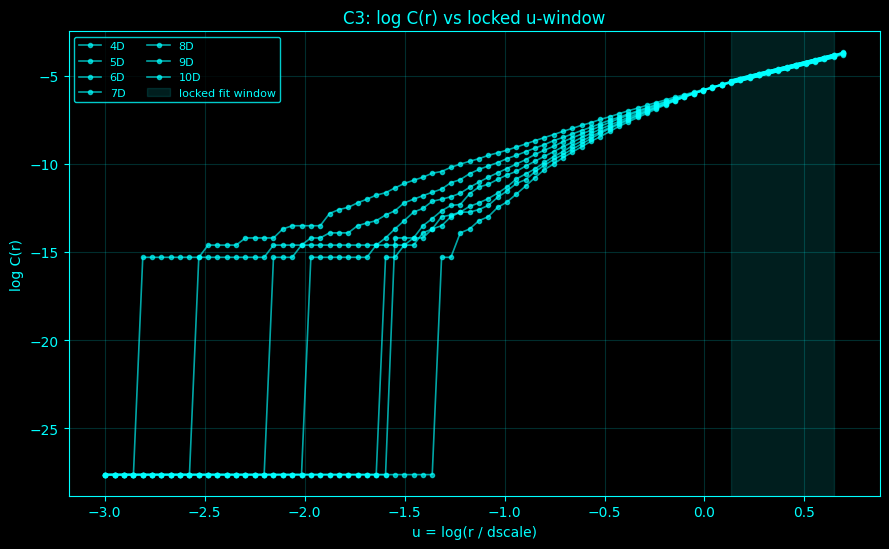

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/plots/per_channel/C3_01_logC_vs_u_overlay.png


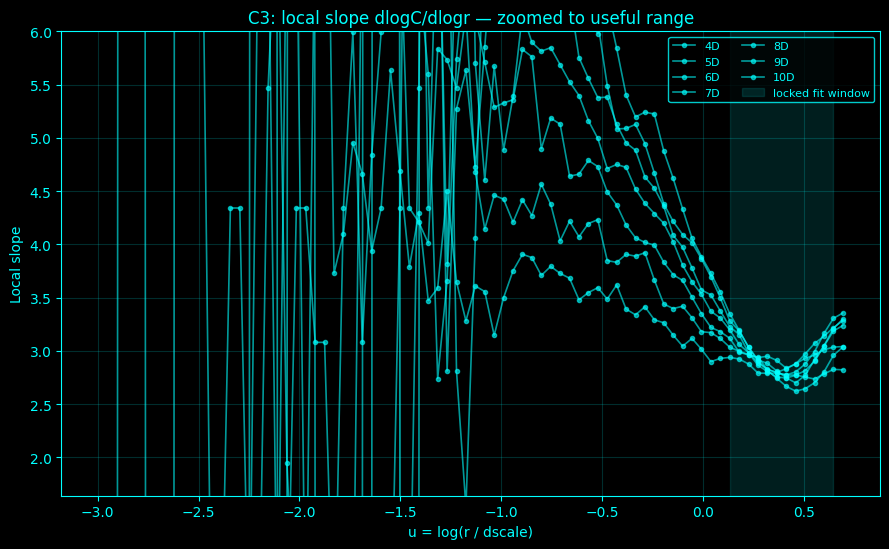

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/plots/per_channel/C3_02_local_slope_zoomed.png


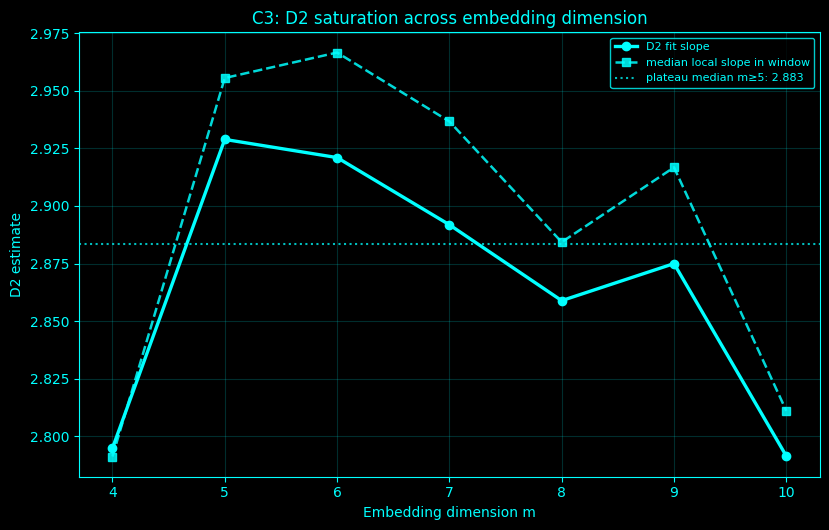

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/plots/per_channel/C3_03_D2_vs_m_saturation.png


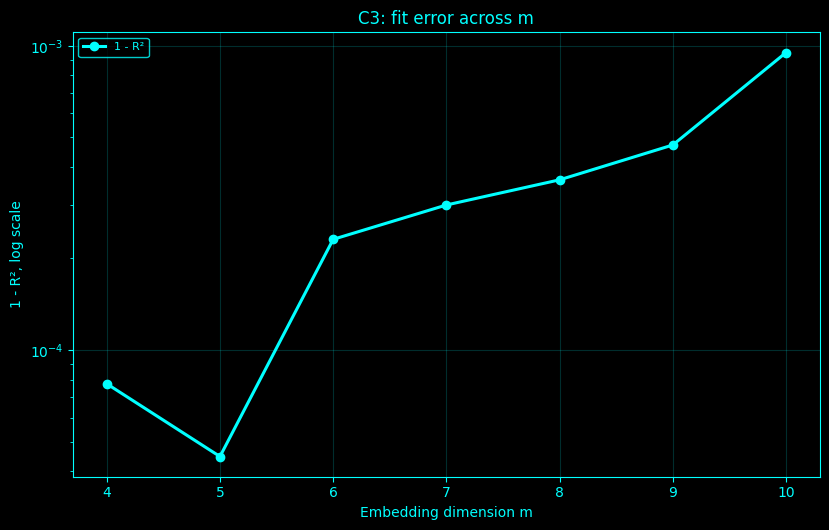

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/plots/per_channel/C3_04_one_minus_r2_by_m.png


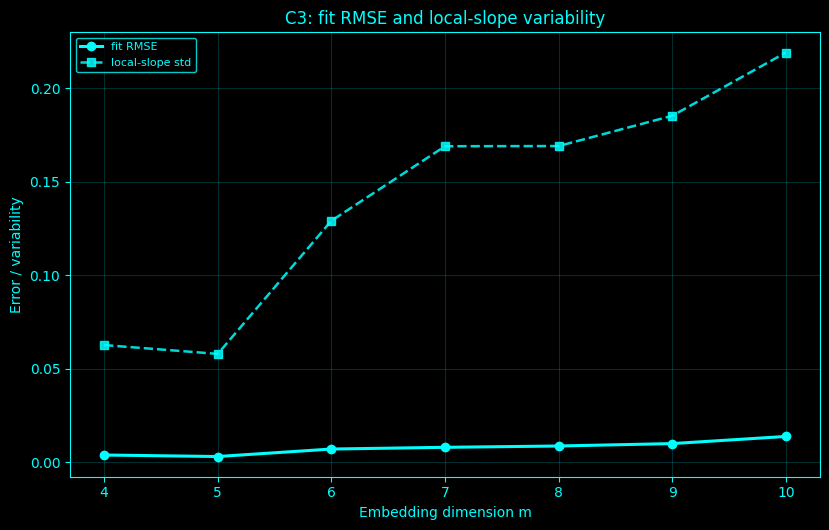

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/plots/per_channel/C3_05_rmse_and_slope_std_by_m.png


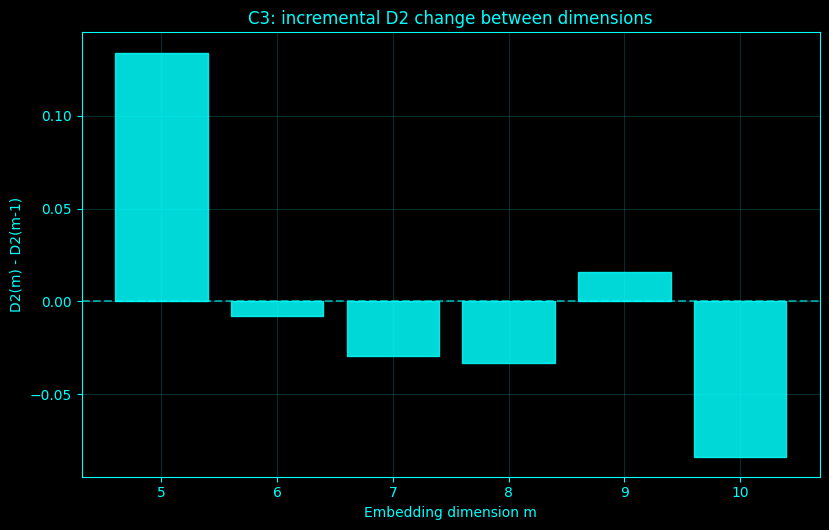

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/plots/per_channel/C3_06_D2_increment_by_m.png


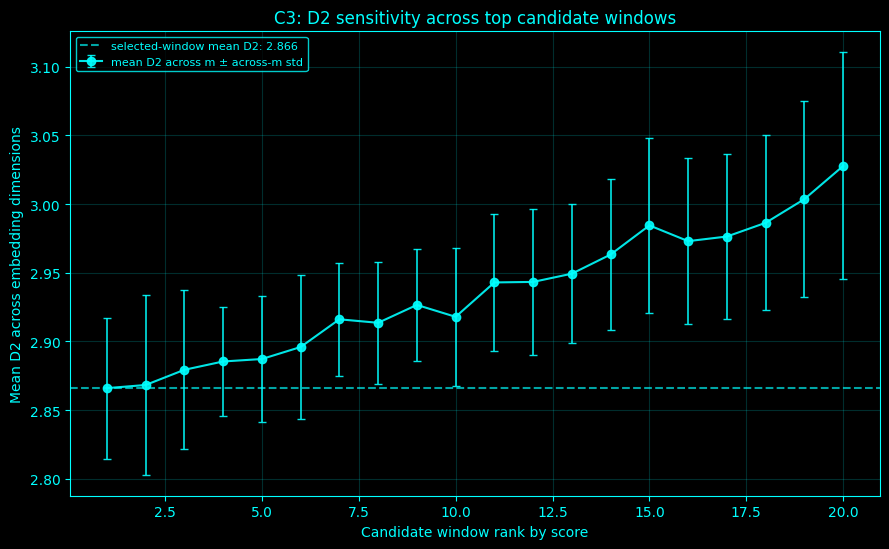

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/plots/window_sensitivity/C3_01_top_window_D2_sensitivity.png


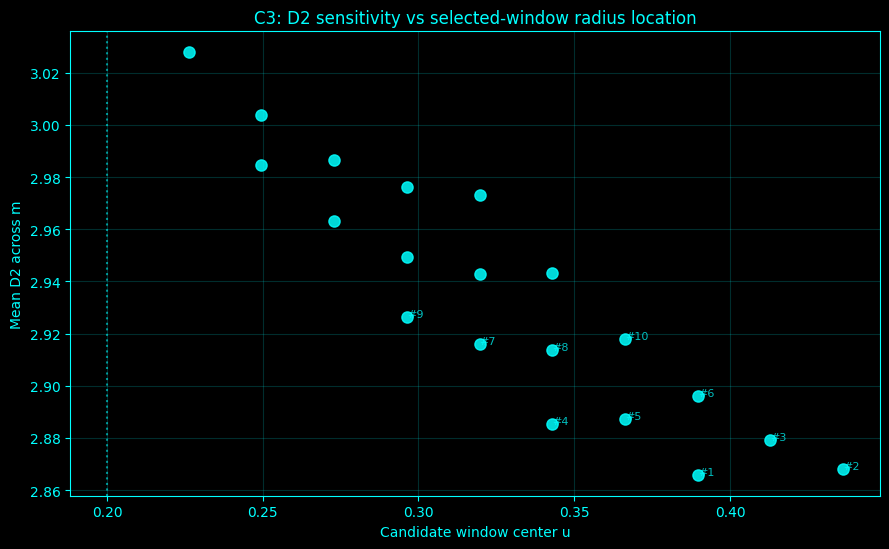

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/plots/window_sensitivity/C3_02_D2_vs_window_u_mid.png


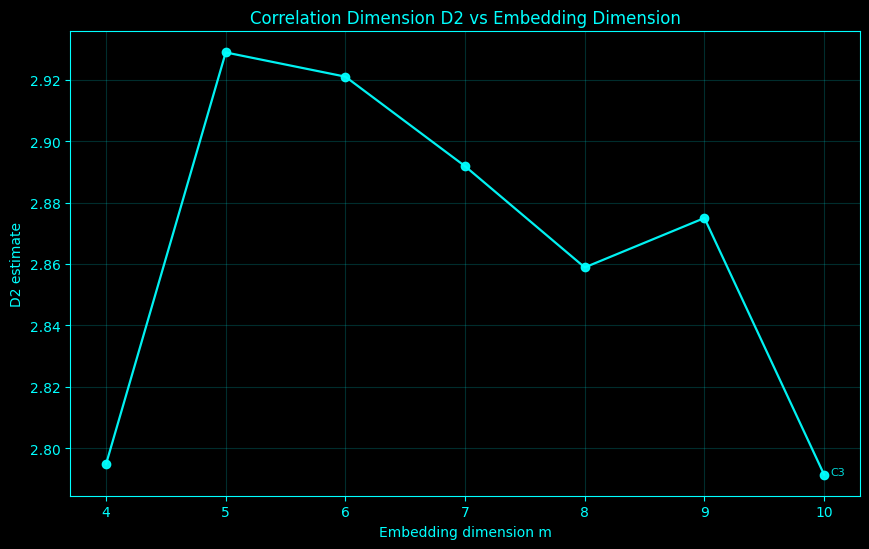

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/plots/01_D2_vs_embedding_dimension_all_channels.png


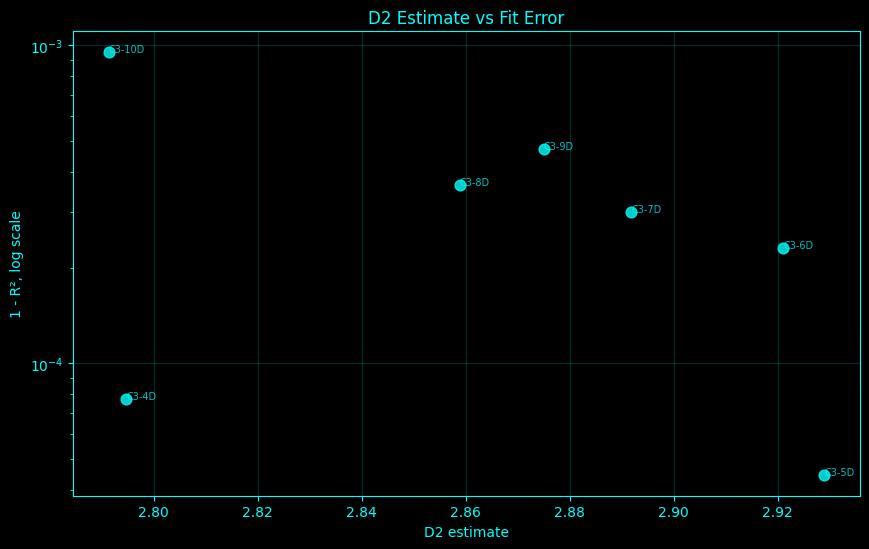

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/plots/03_D2_vs_one_minus_r2.png


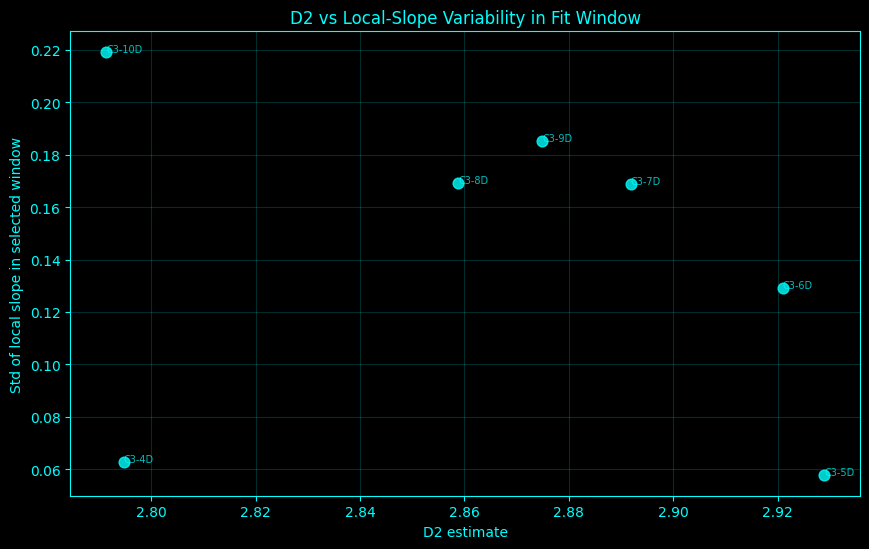

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/plots/04_D2_vs_local_slope_std.png


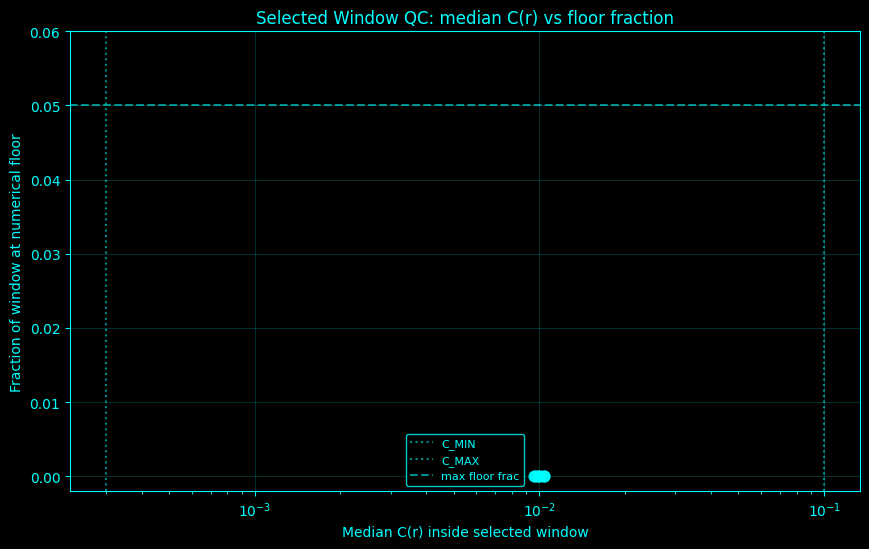

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/plots/05_window_C_QC_fixed_ylim.png


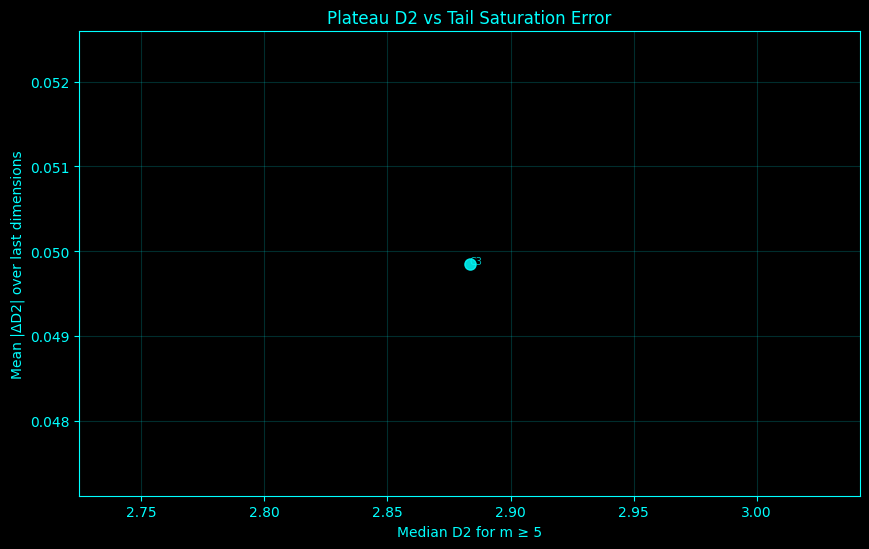

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/plots/06_plateau_D2_vs_tail_delta.png

Done.
Results directory: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed
Plots directory: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/plots
D2 summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/d2_common_window_summary_20260603_151003.csv
Channel summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/d2_channel_saturation_summary_20260603_151003.csv
Window scan CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/d2_window_scan_diagnostics_20260603_151003.csv
Curve points CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/correlation_dimension_d2_fixed/d2_curve_points_20260603_151003.csv
Top-window sensitivity CSV: /home/a/proj

In [1]:
import os
import re
import glob
import time
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.neighbors import NearestNeighbors

# =======================================================
# COMPLETE FIXED / EXPANDED CORRELATION DIMENSION D2 BLOCK
# =======================================================

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

zip_path = os.path.join(base_dir, "embedded_data_4to10.zip")
emb_dir = os.path.join(base_dir, "embedding_data", "embeddings_4to10")

results_dir = os.path.join(base_dir, "results", "correlation_dimension_d2_fixed")
plots_dir = os.path.join(results_dir, "plots")
per_channel_plots_dir = os.path.join(plots_dir, "per_channel")
window_plots_dir = os.path.join(plots_dir, "window_sensitivity")

os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(per_channel_plots_dir, exist_ok=True)
os.makedirs(window_plots_dir, exist_ok=True)

run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")

OUT_D2_SUMMARY_CSV = os.path.join(results_dir, f"d2_common_window_summary_{run_tag}.csv")
OUT_CHANNEL_SUMMARY_CSV = os.path.join(results_dir, f"d2_channel_saturation_summary_{run_tag}.csv")
OUT_WINDOW_SCAN_CSV = os.path.join(results_dir, f"d2_window_scan_diagnostics_{run_tag}.csv")
OUT_CURVES_CSV = os.path.join(results_dir, f"d2_curve_points_{run_tag}.csv")
OUT_TOP_WINDOWS_CSV = os.path.join(results_dir, f"d2_top_window_sensitivity_{run_tag}.csv")

MS = list(range(4, 11))

# Use ["C3"] for one channel.
# Use None for every available EEG channel.
CHANNELS = ["C3"]

THEILER = 20
N_POINTS = 3000
N_R = 80
K_SCALE = 10

RANDOM_SEED = 0
STANDARDIZE = True

C_FLOOR = 1e-12

C_MIN = 3e-4
C_MAX = 1e-1
MAX_FLOOR_FRAC = 0.05

RELAXED_C_MIN = 1e-5
RELAXED_C_MAX = 5e-1
RELAXED_MAX_FLOOR_FRAC = 0.15

MIN_WIN_LEN = 12
MAX_WIN_LEN = 26

# These prevent the automatic window from drifting into bad regions.
# u = log(r / dscale). The old selected window was around u > 0, which can be okay,
# but this limits it from going too far into very large-radius geometry.
U_MIN_ALLOWED = -1.35
U_MAX_ALLOWED = 0.75

# Soft penalty: prefer not-too-large radii when other window scores are comparable.
U_PREFERRED_MAX = 0.20
U_HIGH_RADIUS_WEIGHT = 0.035

# Avoid local-slope spike windows.
MAX_MEDIAN_ABS_LOCAL_SLOPE = 12.0
MAX_ABS_LOCAL_SLOPE_IN_WINDOW = 25.0

ALLOW_RELAXED_FALLBACK = True

PLATEAU_M_MIN = 5
TAIL_N_FOR_PLATEAU = 4

PLOT = True
PLOT_PER_CHANNEL = True
MAX_CHANNEL_DETAIL_PLOTS = 12
TOP_N_WINDOWS_TO_PLOT = 20

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=220):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)


def compact_height(n_rows, per_row=0.15, min_h=4.8, max_h=7.2):
    return float(min(max_h, max(min_h, per_row * max(n_rows, 1))))


def set_compact_yticks(ax, labels, max_labels=36, fontsize=8):
    labels = list(labels)
    n = len(labels)

    if n == 0:
        return

    if n <= max_labels:
        ticks = np.arange(n)
        shown = labels
    else:
        step = int(np.ceil(n / max_labels))
        ticks = np.arange(0, n, step)
        shown = [labels[i] for i in ticks]

    ax.set_yticks(ticks)
    ax.set_yticklabels(shown, fontsize=fontsize)


def compact_barh(ax, labels, values, max_labels=36):
    labels = list(labels)
    values = np.asarray(values, dtype=float)
    y = np.arange(len(labels))

    ax.barh(
        y,
        values,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.85
    )

    set_compact_yticks(ax, labels, max_labels=max_labels, fontsize=8)


if (not os.path.isdir(emb_dir)) or (len(glob.glob(os.path.join(emb_dir, "**", "*.npy"), recursive=True)) == 0):
    if not os.path.exists(zip_path):
        raise FileNotFoundError(
            f"Could not find embedding directory or zip:\n{emb_dir}\n{zip_path}"
        )

    os.makedirs(emb_dir, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(emb_dir)

    print("Unzipped embeddings into:", emb_dir, flush=True)


def parse_embedding_filename(path):
    name = os.path.basename(path)
    stem = os.path.splitext(name)[0]
    m = re.match(r"^(\d+)dembedded_(.+)$", stem)

    if m:
        return int(m.group(1)), m.group(2)

    return None, None


def discover_embedding_files(emb_dir):
    files = glob.glob(os.path.join(emb_dir, "**", "*.npy"), recursive=True)

    mapping = {}

    for fp in files:
        m, ch = parse_embedding_filename(fp)

        if m is None or ch is None:
            continue

        mapping.setdefault(ch, {})[m] = fp

    return mapping


embedding_map = discover_embedding_files(emb_dir)

if len(embedding_map) == 0:
    raise FileNotFoundError(f"No files like 4dembedded_C3.npy found in: {emb_dir}")

if CHANNELS is None:
    channels_to_analyze = sorted(embedding_map.keys())
else:
    channels_to_analyze = [ch for ch in CHANNELS if ch in embedding_map]

missing_channels = []

if CHANNELS is not None:
    missing_channels = [ch for ch in CHANNELS if ch not in embedding_map]

if len(missing_channels) > 0:
    print("Missing requested channels:", missing_channels, flush=True)

if len(channels_to_analyze) == 0:
    raise ValueError("No requested channels were found.")

print("Channels to analyze:", channels_to_analyze, flush=True)


def standardize_cols(X):
    X = np.asarray(X, dtype=float)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    sd[sd == 0] = 1.0
    return (X - mu) / (sd + 1e-12)


def uniform_subsample(X, n_points, seed=0):
    X = np.asarray(X, dtype=float)

    if n_points is None or len(X) <= n_points:
        return X

    rng = np.random.default_rng(seed)
    idx = np.sort(rng.choice(len(X), size=n_points, replace=False))

    return X[idx]


def choose_r_range_from_knn(X, k=10):
    X = np.asarray(X, dtype=float)

    if len(X) < 5:
        raise ValueError("Too few points for kNN radius scale.")

    k = min(max(2, k), len(X))

    nn = NearestNeighbors(n_neighbors=k).fit(X)
    dists, _ = nn.kneighbors(X)

    dscale = float(np.nanmedian(dists[:, -1]))

    if not np.isfinite(dscale) or dscale <= 0:
        raise ValueError(f"Invalid kNN distance scale: {dscale}")

    r_min = dscale * 0.05
    r_max = dscale * 2.0

    return r_min, r_max, dscale


def corr_sum_pdist_with_theiler(X, rs, theiler=0, c_floor=1e-12):
    from scipy.spatial.distance import pdist

    X = np.asarray(X, dtype=float)
    N = len(X)

    if N < 10:
        raise ValueError("Too few points for correlation sum.")

    dvec_all = pdist(X, metric="euclidean")
    iu, ju = np.triu_indices(N, k=1)

    if theiler > 0:
        ok = np.abs(iu - ju) > theiler
        dvec = dvec_all[ok]
    else:
        dvec = dvec_all

    dvec = dvec[np.isfinite(dvec)]
    dvec.sort()

    eligible_pairs = len(dvec)

    if eligible_pairs < 10:
        raise ValueError("Too few eligible pairs after Theiler exclusion.")

    counts = np.searchsorted(dvec, rs, side="right")
    Cs = counts.astype(float) / float(eligible_pairs)
    Cs = np.maximum(Cs, c_floor)

    return Cs, eligible_pairs


def window_ok(Cs, idx_lo, idx_hi, c_min, c_max, max_floor_frac):
    seg = np.asarray(Cs[idx_lo:idx_hi + 1], dtype=float)

    if len(seg) == 0:
        return False, np.nan, np.nan

    floor_frac = float(np.mean(seg <= C_FLOOR * 1.000001))
    medC = float(np.nanmedian(seg))

    ok = (
        (floor_frac <= max_floor_frac)
        and (c_min <= medC <= c_max)
        and np.all(np.isfinite(seg))
    )

    return ok, medC, floor_frac


def linear_fit_quality(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 3:
        return np.nan, np.nan, np.nan, np.nan, np.full_like(y, np.nan)

    x_fit = x[mask]
    y_fit = y[mask]

    coef = np.polyfit(x_fit, y_fit, 1)
    yhat_fit = np.polyval(coef, x_fit)

    ss_res = float(np.sum((y_fit - yhat_fit) ** 2))
    ss_tot = float(np.sum((y_fit - np.mean(y_fit)) ** 2))

    r2 = 1.0 - ss_res / (ss_tot + 1e-12)
    rmse = float(np.sqrt(np.mean((y_fit - yhat_fit) ** 2)))

    yhat_full = np.full_like(y, np.nan, dtype=float)
    yhat_full[mask] = yhat_fit

    return float(coef[0]), float(coef[1]), float(r2), rmse, yhat_full


def scan_common_windows(curves, min_win_len, max_win_len, strict=True):
    ms_avail = sorted(curves.keys())

    n_r = len(curves[ms_avail[0]]["u"])
    max_win_len = min(max_win_len, n_r)

    if strict:
        c_min = C_MIN
        c_max = C_MAX
        max_floor_frac = MAX_FLOOR_FRAC
    else:
        c_min = RELAXED_C_MIN
        c_max = RELAXED_C_MAX
        max_floor_frac = RELAXED_MAX_FLOOR_FRAC

    rows = []
    best = None

    common_u = curves[ms_avail[0]]["u"]

    for win_len in range(min_win_len, max_win_len + 1):
        for start in range(0, n_r - win_len + 1):
            end = start + win_len - 1

            u_lo = float(common_u[start])
            u_hi = float(common_u[end])
            u_mid = float(0.5 * (u_lo + u_hi))

            if u_lo < U_MIN_ALLOWED or u_hi > U_MAX_ALLOWED:
                continue

            ok_all = True

            slope_stds = []
            slope_means = []
            slope_medians = []
            slope_max_abs = []
            fit_r2s = []
            fit_rmses = []
            medCs = []
            floor_fracs = []

            for m in ms_avail:
                c = curves[m]

                ok, medC, floor_frac = window_ok(
                    c["Cs"],
                    start,
                    end,
                    c_min=c_min,
                    c_max=c_max,
                    max_floor_frac=max_floor_frac
                )

                if not ok:
                    ok_all = False
                    break

                slope_seg = c["slope"][start:end + 1]
                slope_seg = slope_seg[np.isfinite(slope_seg)]

                if len(slope_seg) < 3:
                    ok_all = False
                    break

                med_abs_slope = float(np.nanmedian(np.abs(slope_seg)))
                max_abs_slope = float(np.nanmax(np.abs(slope_seg)))

                if med_abs_slope > MAX_MEDIAN_ABS_LOCAL_SLOPE:
                    ok_all = False
                    break

                if max_abs_slope > MAX_ABS_LOCAL_SLOPE_IN_WINDOW:
                    ok_all = False
                    break

                slope_stds.append(float(np.nanstd(slope_seg)))
                slope_means.append(float(np.nanmean(slope_seg)))
                slope_medians.append(float(np.nanmedian(slope_seg)))
                slope_max_abs.append(max_abs_slope)

                fit_slope, fit_intercept, r2, rmse, _ = linear_fit_quality(
                    c["logr"][start:end + 1],
                    c["logC"][start:end + 1]
                )

                fit_r2s.append(r2)
                fit_rmses.append(rmse)
                medCs.append(medC)
                floor_fracs.append(floor_frac)

            if not ok_all:
                continue

            slope_stability = float(np.nanmean(slope_stds))
            across_m_slope_sd = float(np.nanstd(slope_means))
            across_m_slope_median_sd = float(np.nanstd(slope_medians))
            mean_r2 = float(np.nanmean(fit_r2s))
            min_r2 = float(np.nanmin(fit_r2s))
            mean_rmse = float(np.nanmean(fit_rmses))
            mean_medC = float(np.nanmean(medCs))
            min_medC = float(np.nanmin(medCs))
            max_medC = float(np.nanmax(medCs))
            max_floor = float(np.nanmax(floor_fracs))
            mean_max_abs_slope = float(np.nanmean(slope_max_abs))

            high_radius_penalty = U_HIGH_RADIUS_WEIGHT * max(0.0, u_mid - U_PREFERRED_MAX)

            score = (
                slope_stability
                + 0.50 * across_m_slope_sd
                + 0.25 * mean_rmse
                + 0.50 * max(0.0, 0.995 - mean_r2)
                + 0.25 * max(0.0, 0.990 - min_r2)
                + high_radius_penalty
            )

            row = {
                "strict": bool(strict),
                "start": int(start),
                "end": int(end),
                "win_len": int(win_len),
                "u_lo": u_lo,
                "u_hi": u_hi,
                "u_mid": u_mid,
                "score": float(score),
                "slope_stability_mean": slope_stability,
                "across_m_slope_sd": across_m_slope_sd,
                "across_m_slope_median_sd": across_m_slope_median_sd,
                "mean_fit_r2": mean_r2,
                "min_fit_r2": min_r2,
                "mean_fit_rmse": mean_rmse,
                "mean_median_C": mean_medC,
                "min_median_C": min_medC,
                "max_median_C": max_medC,
                "max_floor_frac": max_floor,
                "mean_max_abs_local_slope": mean_max_abs_slope,
                "high_radius_penalty": float(high_radius_penalty),
            }

            rows.append(row)

            if best is None or row["score"] < best["score"]:
                best = row

    scan_df = pd.DataFrame(rows)

    return best, scan_df


def compute_curves_for_channel(channel, m_to_path):
    curves = {}
    curve_rows = []

    for m in MS:
        if m not in m_to_path:
            print(f"{channel}: missing {m}D file; skipping dimension.", flush=True)
            continue

        fpath = m_to_path[m]
        fname = os.path.basename(fpath)

        Xfull = np.load(fpath, allow_pickle=True)
        Xfull = np.asarray(Xfull, dtype=float)
        Xfull = np.squeeze(Xfull)

        if Xfull.ndim != 2:
            raise ValueError(f"{fname}: expected 2D array, got {Xfull.shape}")

        if Xfull.shape[1] < m:
            raise ValueError(f"{fname}: expected at least {m} columns, got {Xfull.shape}")

        Xfull = Xfull[:, :m]

        finite_rows = np.all(np.isfinite(Xfull), axis=1)
        Xfull = Xfull[finite_rows]

        if STANDARDIZE:
            Xfull = standardize_cols(Xfull)

        X = uniform_subsample(Xfull, N_POINTS, seed=RANDOM_SEED)

        r_min, r_max, dscale = choose_r_range_from_knn(X, k=K_SCALE)

        rs = np.logspace(np.log10(r_min), np.log10(r_max), N_R)

        Cs, eligible_pairs = corr_sum_pdist_with_theiler(
            X,
            rs,
            theiler=THEILER,
            c_floor=C_FLOOR
        )

        logr = np.log(rs)
        u = np.log(rs / dscale)
        logC = np.log(Cs)
        slope = np.gradient(logC, logr)

        curves[m] = {
            "channel": channel,
            "m": m,
            "file": fname,
            "path": fpath,
            "N_original": int(len(Xfull)),
            "N_used": int(len(X)),
            "eligible_pairs": int(eligible_pairs),
            "dscale": float(dscale),
            "rs": rs,
            "u": u,
            "logr": logr,
            "Cs": Cs,
            "logC": logC,
            "slope": slope,
        }

        for idx in range(len(rs)):
            curve_rows.append({
                "channel": channel,
                "m": m,
                "file": fname,
                "r_index": idx,
                "r": float(rs[idx]),
                "u": float(u[idx]),
                "logr": float(logr[idx]),
                "C": float(Cs[idx]),
                "logC": float(logC[idx]),
                "local_slope": float(slope[idx]),
                "dscale": float(dscale),
                "N_original": int(len(Xfull)),
                "N_used": int(len(X)),
                "eligible_pairs": int(eligible_pairs),
            })

    return curves, curve_rows


def fit_channel_d2(channel, curves):
    if len(curves) == 0:
        raise ValueError(f"{channel}: no curves available.")

    if len(curves) < 2:
        raise ValueError(f"{channel}: need at least two embedding dimensions for D2-vs-m analysis.")

    best, scan_df_strict = scan_common_windows(
        curves,
        min_win_len=MIN_WIN_LEN,
        max_win_len=MAX_WIN_LEN,
        strict=True
    )

    scan_dfs = []

    if len(scan_df_strict) > 0:
        scan_dfs.append(scan_df_strict)

    window_strict = True

    if best is None and ALLOW_RELAXED_FALLBACK:
        print(f"{channel}: no strict window found; trying relaxed constraints.", flush=True)

        best, scan_df_relaxed = scan_common_windows(
            curves,
            min_win_len=MIN_WIN_LEN,
            max_win_len=MAX_WIN_LEN,
            strict=False
        )

        if len(scan_df_relaxed) > 0:
            scan_dfs.append(scan_df_relaxed)

        window_strict = False

    if len(scan_dfs) > 0:
        scan_df = pd.concat(scan_dfs, ignore_index=True)
    else:
        scan_df = pd.DataFrame()

    if best is None:
        raise RuntimeError(
            f"{channel}: no common window found. "
            "Try relaxing C_MIN/C_MAX, increasing N_POINTS, or changing U_MIN_ALLOWED/U_MAX_ALLOWED."
        )

    fit_lo = int(best["start"])
    fit_hi = int(best["end"])

    summary_rows = []

    for m in sorted(curves.keys()):
        c = curves[m]

        fit_slope, fit_intercept, r2, rmse, _ = linear_fit_quality(
            c["logr"][fit_lo:fit_hi + 1],
            c["logC"][fit_lo:fit_hi + 1]
        )

        ok_strict, medC_strict, floor_strict = window_ok(
            c["Cs"],
            fit_lo,
            fit_hi,
            c_min=C_MIN,
            c_max=C_MAX,
            max_floor_frac=MAX_FLOOR_FRAC
        )

        slope_seg = c["slope"][fit_lo:fit_hi + 1]

        summary_rows.append({
            "channel": channel,
            "m": m,
            "file": c["file"],
            "path": c["path"],
            "status": "ok",
            "window_strict": bool(window_strict),
            "fit_start_index": fit_lo,
            "fit_end_index": fit_hi,
            "fit_window_len": int(fit_hi - fit_lo + 1),
            "u_lo": float(c["u"][fit_lo]),
            "u_hi": float(c["u"][fit_hi]),
            "u_mid": float(0.5 * (c["u"][fit_lo] + c["u"][fit_hi])),
            "logr_lo": float(c["logr"][fit_lo]),
            "logr_hi": float(c["logr"][fit_hi]),
            "D2": float(fit_slope),
            "fit_intercept": float(fit_intercept),
            "fit_r2": float(r2),
            "fit_1_minus_r2": float(1.0 - r2),
            "fit_rmse": float(rmse),
            "window_median_C": float(medC_strict),
            "window_floor_frac": float(floor_strict),
            "local_slope_mean": float(np.nanmean(slope_seg)),
            "local_slope_median": float(np.nanmedian(slope_seg)),
            "local_slope_std": float(np.nanstd(slope_seg)),
            "local_slope_min": float(np.nanmin(slope_seg)),
            "local_slope_max": float(np.nanmax(slope_seg)),
            "N_original": c["N_original"],
            "N_used": c["N_used"],
            "eligible_pairs": c["eligible_pairs"],
            "dscale": c["dscale"],
            "scan_score": float(best["score"]),
            "scan_mean_fit_r2": float(best["mean_fit_r2"]),
            "scan_mean_fit_rmse": float(best["mean_fit_rmse"]),
            "scan_slope_stability_mean": float(best["slope_stability_mean"]),
        })

    summary_df = pd.DataFrame(summary_rows)

    summary_df = summary_df.sort_values("m").reset_index(drop=True)
    summary_df["D2_delta_from_prev_m"] = summary_df["D2"].diff()
    summary_df["D2_abs_delta_from_prev_m"] = summary_df["D2_delta_from_prev_m"].abs()

    return summary_df, scan_df, best


def summarize_top_windows(channel, curves, scan_df, n_top=20):
    if scan_df is None or len(scan_df) == 0:
        return pd.DataFrame()

    rows = []

    scan_use = scan_df.sort_values("score", ascending=True).head(n_top).copy()

    for rank, (_, win) in enumerate(scan_use.iterrows(), start=1):
        start = int(win["start"])
        end = int(win["end"])

        d2_vals = []
        r2_vals = []
        rmse_vals = []
        slope_std_vals = []

        for m in sorted(curves.keys()):
            c = curves[m]

            fit_slope, fit_intercept, r2, rmse, _ = linear_fit_quality(
                c["logr"][start:end + 1],
                c["logC"][start:end + 1]
            )

            slope_seg = c["slope"][start:end + 1]

            d2_vals.append(fit_slope)
            r2_vals.append(r2)
            rmse_vals.append(rmse)
            slope_std_vals.append(float(np.nanstd(slope_seg)))

            rows.append({
                "channel": channel,
                "window_rank": rank,
                "m": m,
                "start": start,
                "end": end,
                "win_len": int(win["win_len"]),
                "u_lo": float(win["u_lo"]),
                "u_hi": float(win["u_hi"]),
                "u_mid": float(win["u_mid"]),
                "window_score": float(win["score"]),
                "D2": float(fit_slope),
                "fit_r2": float(r2),
                "fit_rmse": float(rmse),
                "local_slope_std": float(np.nanstd(slope_seg)),
            })

        rows.append({
            "channel": channel,
            "window_rank": rank,
            "m": "all_mean",
            "start": start,
            "end": end,
            "win_len": int(win["win_len"]),
            "u_lo": float(win["u_lo"]),
            "u_hi": float(win["u_hi"]),
            "u_mid": float(win["u_mid"]),
            "window_score": float(win["score"]),
            "D2": float(np.nanmean(d2_vals)),
            "fit_r2": float(np.nanmean(r2_vals)),
            "fit_rmse": float(np.nanmean(rmse_vals)),
            "local_slope_std": float(np.nanmean(slope_std_vals)),
            "D2_across_m_std": float(np.nanstd(d2_vals)),
            "D2_across_m_min": float(np.nanmin(d2_vals)),
            "D2_across_m_max": float(np.nanmax(d2_vals)),
        })

    return pd.DataFrame(rows)


def channel_saturation_summary(summary_df):
    channel = summary_df["channel"].iloc[0]

    summary_df = summary_df.sort_values("m").copy()

    d2 = summary_df["D2"].to_numpy(dtype=float)
    mvals = summary_df["m"].to_numpy(dtype=float)

    if len(d2) >= 2:
        d2_range = float(np.nanmax(d2) - np.nanmin(d2))
        last_delta = float(d2[-1] - d2[-2])
        abs_last_delta = float(abs(last_delta))
    else:
        d2_range = np.nan
        last_delta = np.nan
        abs_last_delta = np.nan

    if len(d2) >= 3:
        tail_delta_mean = float(np.nanmean(np.abs(np.diff(d2[-3:]))))
    else:
        tail_delta_mean = np.nan

    if len(d2) >= TAIL_N_FOR_PLATEAU:
        tail_d2 = d2[-TAIL_N_FOR_PLATEAU:]
    else:
        tail_d2 = d2.copy()

    plateau_by_min_m = summary_df[summary_df["m"] >= PLATEAU_M_MIN]["D2"].to_numpy(dtype=float)

    if len(plateau_by_min_m) == 0:
        plateau_by_min_m = tail_d2.copy()

    plateau_median = float(np.nanmedian(plateau_by_min_m))
    plateau_mean = float(np.nanmean(plateau_by_min_m))
    plateau_std = float(np.nanstd(plateau_by_min_m))
    plateau_iqr = float(np.nanpercentile(plateau_by_min_m, 75) - np.nanpercentile(plateau_by_min_m, 25))

    tail_median = float(np.nanmedian(tail_d2))
    tail_mean = float(np.nanmean(tail_d2))
    tail_std = float(np.nanstd(tail_d2))

    if len(d2) >= 3:
        slope, intercept = np.polyfit(mvals, d2, 1)
    else:
        slope, intercept = np.nan, np.nan

    plateau_candidate = bool(
        np.isfinite(abs_last_delta)
        and abs_last_delta < 0.25
        and np.isfinite(tail_delta_mean)
        and tail_delta_mean < 0.35
        and np.isfinite(plateau_std)
        and plateau_std < 0.20
    )

    return {
        "channel": channel,
        "status": "ok",
        "n_dimensions": int(len(summary_df)),
        "m_min": int(np.nanmin(mvals)),
        "m_max": int(np.nanmax(mvals)),
        "D2_min": float(np.nanmin(d2)),
        "D2_max": float(np.nanmax(d2)),
        "D2_range": d2_range,
        "D2_last": float(d2[-1]),
        "D2_last_delta": last_delta,
        "D2_abs_last_delta": abs_last_delta,
        "D2_tail_abs_delta_mean": tail_delta_mean,
        "D2_vs_m_slope": float(slope),
        "D2_vs_m_intercept": float(intercept),
        "D2_plateau_m_min": int(PLATEAU_M_MIN),
        "D2_plateau_median_m_ge_min": plateau_median,
        "D2_plateau_mean_m_ge_min": plateau_mean,
        "D2_plateau_std_m_ge_min": plateau_std,
        "D2_plateau_iqr_m_ge_min": plateau_iqr,
        "D2_tail_median": tail_median,
        "D2_tail_mean": tail_mean,
        "D2_tail_std": tail_std,
        "mean_fit_r2": float(summary_df["fit_r2"].mean()),
        "mean_1_minus_r2": float(summary_df["fit_1_minus_r2"].mean()),
        "mean_fit_rmse": float(summary_df["fit_rmse"].mean()),
        "mean_local_slope_std": float(summary_df["local_slope_std"].mean()),
        "all_windows_strict": bool(summary_df["window_strict"].all()),
        "plateau_candidate": plateau_candidate,
    }


def plot_channel_detail(channel, curves, best, summary_df, scan_df, top_window_df):
    fit_lo = int(best["start"])
    fit_hi = int(best["end"])

    u0 = curves[sorted(curves.keys())[0]]["u"][fit_lo]
    u1 = curves[sorted(curves.keys())[0]]["u"][fit_hi]

    fig, ax = plt.subplots(figsize=(9.0, 5.6), facecolor=BG)
    style_ax(ax)

    for m in sorted(curves.keys()):
        c = curves[m]

        ax.plot(
            c["u"],
            c["logC"],
            marker="o",
            markersize=3,
            linewidth=1.2,
            alpha=0.65,
            color=ACCENT,
            label=f"{m}D"
        )

        row = summary_df[summary_df["m"] == m].iloc[0]
        fit_y = row["fit_intercept"] + row["D2"] * c["logr"]

        ax.plot(
            c["u"][fit_lo:fit_hi + 1],
            fit_y[fit_lo:fit_hi + 1],
            linewidth=2.4,
            color=ACCENT,
            alpha=0.95
        )

    ax.axvspan(u0, u1, color=ACCENT, alpha=0.12, label="locked fit window")

    ax.set_title(f"{channel}: log C(r) vs locked u-window")
    ax.set_xlabel("u = log(r / dscale)")
    ax.set_ylabel("log C(r)")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8, ncol=2)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    plot_path = os.path.join(per_channel_plots_dir, f"{channel}_01_logC_vs_u_overlay.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(9.0, 5.6), facecolor=BG)
    style_ax(ax)

    selected_slopes = []

    for m in sorted(curves.keys()):
        c = curves[m]

        ax.plot(
            c["u"],
            c["slope"],
            marker="o",
            markersize=3,
            linewidth=1.2,
            alpha=0.60,
            color=ACCENT,
            label=f"{m}D"
        )

        selected_slopes.extend(c["slope"][fit_lo:fit_hi + 1].tolist())

    selected_slopes = np.asarray(selected_slopes, dtype=float)
    selected_slopes = selected_slopes[np.isfinite(selected_slopes)]

    if len(selected_slopes) > 0:
        y_low = max(-2.0, float(np.nanpercentile(selected_slopes, 1) - 1.0))
        y_high = min(14.0, max(6.0, float(np.nanpercentile(selected_slopes, 99) + 2.0)))
        ax.set_ylim(y_low, y_high)
    else:
        ax.set_ylim(-1.0, 12.0)

    ax.axvspan(u0, u1, color=ACCENT, alpha=0.12, label="locked fit window")

    ax.set_title(f"{channel}: local slope dlogC/dlogr — zoomed to useful range")
    ax.set_xlabel("u = log(r / dscale)")
    ax.set_ylabel("Local slope")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8, ncol=2)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    plot_path = os.path.join(per_channel_plots_dir, f"{channel}_02_local_slope_zoomed.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(8.4, 5.4), facecolor=BG)
    style_ax(ax)

    ax.plot(
        summary_df["m"],
        summary_df["D2"],
        color=ACCENT,
        marker="o",
        linewidth=2.4,
        label="D2 fit slope"
    )

    ax.plot(
        summary_df["m"],
        summary_df["local_slope_median"],
        color=ACCENT,
        marker="s",
        linestyle="--",
        alpha=0.85,
        linewidth=1.8,
        label="median local slope in window"
    )

    plateau_val = float(summary_df[summary_df["m"] >= PLATEAU_M_MIN]["D2"].median())

    ax.axhline(
        plateau_val,
        color=ACCENT,
        linestyle=":",
        alpha=0.75,
        label=f"plateau median m≥{PLATEAU_M_MIN}: {plateau_val:.3f}"
    )

    ax.set_title(f"{channel}: D2 saturation across embedding dimension")
    ax.set_xlabel("Embedding dimension m")
    ax.set_ylabel("D2 estimate")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    plot_path = os.path.join(per_channel_plots_dir, f"{channel}_03_D2_vs_m_saturation.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(8.4, 5.4), facecolor=BG)
    style_ax(ax)

    ax.plot(
        summary_df["m"],
        summary_df["fit_1_minus_r2"],
        color=ACCENT,
        marker="o",
        linewidth=2.2,
        label="1 - R²"
    )

    ax.set_yscale("log")

    ax.set_title(f"{channel}: fit error across m")
    ax.set_xlabel("Embedding dimension m")
    ax.set_ylabel("1 - R², log scale")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    plot_path = os.path.join(per_channel_plots_dir, f"{channel}_04_one_minus_r2_by_m.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(8.4, 5.4), facecolor=BG)
    style_ax(ax)

    ax.plot(
        summary_df["m"],
        summary_df["fit_rmse"],
        color=ACCENT,
        marker="o",
        linewidth=2.2,
        label="fit RMSE"
    )

    ax.plot(
        summary_df["m"],
        summary_df["local_slope_std"],
        color=ACCENT,
        marker="s",
        linestyle="--",
        linewidth=1.8,
        alpha=0.85,
        label="local-slope std"
    )

    ax.set_title(f"{channel}: fit RMSE and local-slope variability")
    ax.set_xlabel("Embedding dimension m")
    ax.set_ylabel("Error / variability")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    plot_path = os.path.join(per_channel_plots_dir, f"{channel}_05_rmse_and_slope_std_by_m.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(8.4, 5.4), facecolor=BG)
    style_ax(ax)

    delta_df = summary_df.dropna(subset=["D2_delta_from_prev_m"])

    ax.bar(
        delta_df["m"],
        delta_df["D2_delta_from_prev_m"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.85
    )

    ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.55)

    ax.set_title(f"{channel}: incremental D2 change between dimensions")
    ax.set_xlabel("Embedding dimension m")
    ax.set_ylabel("D2(m) - D2(m-1)")

    plot_path = os.path.join(per_channel_plots_dir, f"{channel}_06_D2_increment_by_m.png")
    save_show_close(fig, plot_path)

    if top_window_df is not None and len(top_window_df) > 0:
        tw_mean = top_window_df[top_window_df["m"].astype(str) == "all_mean"].copy()

        if len(tw_mean) > 0:
            tw_mean = tw_mean.sort_values("window_rank")

            fig, ax = plt.subplots(figsize=(9.0, 5.6), facecolor=BG)
            style_ax(ax)

            yerr = tw_mean["D2_across_m_std"].fillna(0).to_numpy(dtype=float)

            ax.errorbar(
                tw_mean["window_rank"],
                tw_mean["D2"],
                yerr=yerr,
                fmt="o-",
                color=ACCENT,
                ecolor=ACCENT,
                elinewidth=1.2,
                capsize=3,
                alpha=0.9,
                label="mean D2 across m ± across-m std"
            )

            selected_mean_d2 = float(summary_df["D2"].mean())

            ax.axhline(
                selected_mean_d2,
                color=ACCENT,
                linestyle="--",
                alpha=0.65,
                label=f"selected-window mean D2: {selected_mean_d2:.3f}"
            )

            ax.set_title(f"{channel}: D2 sensitivity across top candidate windows")
            ax.set_xlabel("Candidate window rank by score")
            ax.set_ylabel("Mean D2 across embedding dimensions")

            leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
            for text in leg.get_texts():
                text.set_color(ACCENT)

            plot_path = os.path.join(window_plots_dir, f"{channel}_01_top_window_D2_sensitivity.png")
            save_show_close(fig, plot_path)

            fig, ax = plt.subplots(figsize=(9.0, 5.6), facecolor=BG)
            style_ax(ax)

            ax.scatter(
                tw_mean["u_mid"],
                tw_mean["D2"],
                color=ACCENT,
                edgecolor=ACCENT,
                s=65,
                alpha=0.85
            )

            for _, row in tw_mean.head(10).iterrows():
                ax.text(
                    row["u_mid"],
                    row["D2"],
                    f"#{int(row['window_rank'])}",
                    color=ACCENT,
                    fontsize=8,
                    alpha=0.75
                )

            ax.axvline(U_PREFERRED_MAX, color=ACCENT, linestyle=":", alpha=0.55)

            ax.set_title(f"{channel}: D2 sensitivity vs selected-window radius location")
            ax.set_xlabel("Candidate window center u")
            ax.set_ylabel("Mean D2 across m")

            plot_path = os.path.join(window_plots_dir, f"{channel}_02_D2_vs_window_u_mid.png")
            save_show_close(fig, plot_path)


all_summary_rows = []
all_scan_rows = []
all_curve_rows = []
all_top_window_rows = []
channel_summary_rows = []
channel_curve_store = {}
channel_best_store = {}
channel_scan_store = {}
channel_top_window_store = {}

start_time = time.time()

for idx, channel in enumerate(channels_to_analyze, start=1):
    print(f"\n[{idx}/{len(channels_to_analyze)}] Processing channel {channel}", flush=True)

    try:
        curves, curve_rows = compute_curves_for_channel(channel, embedding_map[channel])

        if len(curves) == 0:
            raise ValueError("No curves computed.")

        summary_df, scan_df, best = fit_channel_d2(channel, curves)

        scan_df["channel"] = channel

        top_window_df = summarize_top_windows(
            channel,
            curves,
            scan_df,
            n_top=TOP_N_WINDOWS_TO_PLOT
        )

        all_summary_rows.extend(summary_df.to_dict("records"))
        all_scan_rows.extend(scan_df.to_dict("records"))
        all_curve_rows.extend(curve_rows)

        if len(top_window_df) > 0:
            all_top_window_rows.extend(top_window_df.to_dict("records"))

        channel_summary_rows.append(channel_saturation_summary(summary_df))

        channel_curve_store[channel] = curves
        channel_best_store[channel] = best
        channel_scan_store[channel] = scan_df
        channel_top_window_store[channel] = top_window_df

        ch_sum = channel_saturation_summary(summary_df)

        print(
            f"  OK | dims={summary_df['m'].tolist()} | "
            f"D2={summary_df['D2'].min():.3f} to {summary_df['D2'].max():.3f} | "
            f"plateau median m≥{PLATEAU_M_MIN}={ch_sum['D2_plateau_median_m_ge_min']:.3f} | "
            f"tail Δ={ch_sum['D2_tail_abs_delta_mean']:.3f} | "
            f"strict_window={summary_df['window_strict'].all()} | "
            f"u=[{summary_df['u_lo'].iloc[0]:.3f}, {summary_df['u_hi'].iloc[0]:.3f}]",
            flush=True
        )

    except Exception as e:
        print(f"  ERROR for channel {channel}: {type(e).__name__}: {e}", flush=True)

        channel_summary_rows.append({
            "channel": channel,
            "status": "error",
            "error": f"{type(e).__name__}: {e}",
        })

elapsed = time.time() - start_time

d2_summary = pd.DataFrame(all_summary_rows)
window_scan = pd.DataFrame(all_scan_rows)
curve_points = pd.DataFrame(all_curve_rows)
top_windows = pd.DataFrame(all_top_window_rows)
channel_summary = pd.DataFrame(channel_summary_rows)

d2_summary.to_csv(OUT_D2_SUMMARY_CSV, index=False)
window_scan.to_csv(OUT_WINDOW_SCAN_CSV, index=False)
curve_points.to_csv(OUT_CURVES_CSV, index=False)
channel_summary.to_csv(OUT_CHANNEL_SUMMARY_CSV, index=False)

if len(top_windows) > 0:
    top_windows.to_csv(OUT_TOP_WINDOWS_CSV, index=False)
else:
    pd.DataFrame().to_csv(OUT_TOP_WINDOWS_CSV, index=False)

print("\nSaved D2 summary:", OUT_D2_SUMMARY_CSV)
print("Saved channel summary:", OUT_CHANNEL_SUMMARY_CSV)
print("Saved window scan diagnostics:", OUT_WINDOW_SCAN_CSV)
print("Saved curve points:", OUT_CURVES_CSV)
print("Saved top-window sensitivity:", OUT_TOP_WINDOWS_CSV)
print(f"Elapsed: {elapsed/60:.2f} minutes")

if len(d2_summary) == 0:
    raise ValueError("No successful D2 fits. Check printed errors and output CSVs.")

print("\nD2 summary:")
print(
    d2_summary[
        [
            "channel",
            "m",
            "D2",
            "fit_r2",
            "fit_1_minus_r2",
            "fit_rmse",
            "window_median_C",
            "window_floor_frac",
            "local_slope_std",
            "u_lo",
            "u_hi",
            "window_strict",
        ]
    ].to_string(index=False)
)

print("\nChannel saturation summary:")
print(channel_summary.to_string(index=False))

if PLOT:
    if PLOT_PER_CHANNEL:
        channels_with_curves = list(channel_curve_store.keys())[:MAX_CHANNEL_DETAIL_PLOTS]

        for channel in channels_with_curves:
            plot_channel_detail(
                channel,
                channel_curve_store[channel],
                channel_best_store[channel],
                d2_summary[d2_summary["channel"] == channel].copy(),
                channel_scan_store[channel],
                channel_top_window_store[channel]
            )

    fig, ax = plt.subplots(figsize=(8.8, 5.6), facecolor=BG)
    style_ax(ax)

    for channel, sub in d2_summary.groupby("channel"):
        sub = sub.sort_values("m")

        ax.plot(
            sub["m"],
            sub["D2"],
            color=ACCENT,
            alpha=0.35 if len(channels_to_analyze) > 1 else 0.95,
            marker="o",
            linewidth=1.6
        )

        if len(channels_to_analyze) <= 12:
            ax.text(
                sub["m"].iloc[-1] + 0.05,
                sub["D2"].iloc[-1],
                channel,
                color=ACCENT,
                fontsize=8,
                alpha=0.85
            )

    mean_by_m = (
        d2_summary
        .groupby("m")["D2"]
        .mean()
        .reset_index()
        .sort_values("m")
    )

    if len(channels_to_analyze) > 1:
        ax.plot(
            mean_by_m["m"],
            mean_by_m["D2"],
            color=ACCENT,
            marker="s",
            linewidth=3.0,
            label="mean across channels"
        )

        leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)

        for text in leg.get_texts():
            text.set_color(ACCENT)

    ax.set_title("Correlation Dimension D2 vs Embedding Dimension")
    ax.set_xlabel("Embedding dimension m")
    ax.set_ylabel("D2 estimate")

    plot_path = os.path.join(plots_dir, "01_D2_vs_embedding_dimension_all_channels.png")
    save_show_close(fig, plot_path)

    if d2_summary["channel"].nunique() > 1:
        d2_pivot = d2_summary.pivot_table(
            index="channel",
            columns="m",
            values="D2",
            aggfunc="mean"
        )

        d2_pivot = d2_pivot.loc[d2_pivot.mean(axis=1).sort_values().index]

        fig, ax = plt.subplots(
            figsize=(9.2, compact_height(len(d2_pivot), per_row=0.13)),
            facecolor=BG
        )
        style_ax(ax)

        im = ax.imshow(
            d2_pivot.to_numpy(dtype=float),
            aspect="auto",
            origin="lower",
            interpolation="nearest"
        )

        ax.set_title("Channel × Embedding Dimension: D2")
        ax.set_xlabel("Embedding dimension m")
        ax.set_ylabel("Channel")

        ax.set_xticks(np.arange(len(d2_pivot.columns)))
        ax.set_xticklabels([str(int(c)) for c in d2_pivot.columns])

        set_compact_yticks(ax, d2_pivot.index.values, max_labels=36, fontsize=8)

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("D2 estimate")
        style_colorbar(cbar)

        plot_path = os.path.join(plots_dir, "02_channel_by_m_D2_heatmap.png")
        save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(8.8, 5.6), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        d2_summary["D2"],
        d2_summary["fit_1_minus_r2"],
        color=ACCENT,
        edgecolor=ACCENT,
        s=60,
        alpha=0.8
    )

    ax.set_yscale("log")

    for _, row in d2_summary.sort_values("fit_1_minus_r2", ascending=False).head(8).iterrows():
        ax.text(
            row["D2"],
            row["fit_1_minus_r2"],
            f"{row['channel']}-{int(row['m'])}D",
            color=ACCENT,
            fontsize=7,
            alpha=0.75
        )

    ax.set_title("D2 Estimate vs Fit Error")
    ax.set_xlabel("D2 estimate")
    ax.set_ylabel("1 - R², log scale")

    plot_path = os.path.join(plots_dir, "03_D2_vs_one_minus_r2.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(8.8, 5.6), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        d2_summary["D2"],
        d2_summary["local_slope_std"],
        color=ACCENT,
        edgecolor=ACCENT,
        s=60,
        alpha=0.8
    )

    for _, row in d2_summary.sort_values("local_slope_std", ascending=False).head(8).iterrows():
        ax.text(
            row["D2"],
            row["local_slope_std"],
            f"{row['channel']}-{int(row['m'])}D",
            color=ACCENT,
            fontsize=7,
            alpha=0.75
        )

    ax.set_title("D2 vs Local-Slope Variability in Fit Window")
    ax.set_xlabel("D2 estimate")
    ax.set_ylabel("Std of local slope in selected window")

    plot_path = os.path.join(plots_dir, "04_D2_vs_local_slope_std.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(8.8, 5.6), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        d2_summary["window_median_C"],
        d2_summary["window_floor_frac"],
        color=ACCENT,
        edgecolor=ACCENT,
        s=60,
        alpha=0.8
    )

    ax.axvline(C_MIN, color=ACCENT, linestyle=":", alpha=0.55, label="C_MIN")
    ax.axvline(C_MAX, color=ACCENT, linestyle=":", alpha=0.55, label="C_MAX")
    ax.axhline(MAX_FLOOR_FRAC, color=ACCENT, linestyle="--", alpha=0.55, label="max floor frac")

    ax.set_xscale("log")
    ax.set_ylim(-0.002, max(0.01, MAX_FLOOR_FRAC * 1.2))

    ax.set_title("Selected Window QC: median C(r) vs floor fraction")
    ax.set_xlabel("Median C(r) inside selected window")
    ax.set_ylabel("Fraction of window at numerical floor")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    plot_path = os.path.join(plots_dir, "05_window_C_QC_fixed_ylim.png")
    save_show_close(fig, plot_path)

    ok_channel_summary = channel_summary[
        channel_summary.get("D2_last", pd.Series(dtype=float)).notna()
    ].copy()

    if len(ok_channel_summary) > 0:
        fig, ax = plt.subplots(figsize=(8.8, 5.6), facecolor=BG)
        style_ax(ax)

        ax.scatter(
            ok_channel_summary["D2_plateau_median_m_ge_min"],
            ok_channel_summary["D2_tail_abs_delta_mean"],
            color=ACCENT,
            edgecolor=ACCENT,
            s=65,
            alpha=0.85
        )

        for _, row in ok_channel_summary.sort_values("D2_tail_abs_delta_mean", ascending=False).head(8).iterrows():
            ax.text(
                row["D2_plateau_median_m_ge_min"],
                row["D2_tail_abs_delta_mean"],
                str(row["channel"]),
                color=ACCENT,
                fontsize=7,
                alpha=0.75
            )

        ax.set_title("Plateau D2 vs Tail Saturation Error")
        ax.set_xlabel(f"Median D2 for m ≥ {PLATEAU_M_MIN}")
        ax.set_ylabel("Mean |ΔD2| over last dimensions")

        plot_path = os.path.join(plots_dir, "06_plateau_D2_vs_tail_delta.png")
        save_show_close(fig, plot_path)

    if len(ok_channel_summary) > 1:
        plot_df = ok_channel_summary.sort_values("D2_tail_abs_delta_mean", ascending=False)

        fig, ax = plt.subplots(
            figsize=(8.8, compact_height(len(plot_df))),
            facecolor=BG
        )
        style_ax(ax)

        compact_barh(
            ax,
            plot_df["channel"],
            plot_df["D2_tail_abs_delta_mean"]
        )

        ax.set_title("D2 Tail Change: Saturation Diagnostic by Channel")
        ax.set_xlabel("Mean |ΔD2| over last dimensions")
        ax.set_ylabel("Channel")

        plot_path = os.path.join(plots_dir, "07_channel_D2_tail_delta_saturation.png")
        save_show_close(fig, plot_path)

print("\nDone.")
print("Results directory:", results_dir)
print("Plots directory:", plots_dir)
print("D2 summary CSV:", OUT_D2_SUMMARY_CSV)
print("Channel summary CSV:", OUT_CHANNEL_SUMMARY_CSV)
print("Window scan CSV:", OUT_WINDOW_SCAN_CSV)
print("Curve points CSV:", OUT_CURVES_CSV)
print("Top-window sensitivity CSV:", OUT_TOP_WINDOWS_CSV)

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block provides a reproducible Grassberger–Procaccia workflow for estimating the correlation dimension <code>D₂</code> across embedding dimensions
            for a single channel (<code>Fp2</code>). It automatically checks for extracted embedding files, unzips the archive if needed, loads embeddings from
            dimensions <code>4</code> through <code>10</code>, standardizes the coordinates, computes correlation-sum curves <code>C(r)</code> with a Theiler
            exclusion window, and estimates <code>D₂</code> from an automatically selected scaling region. The key intent is to evaluate how the estimated
            attractor dimension behaves as embedding dimension increases while minimizing manual window selection.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            The method relies on the correlation sum <code>C(r)</code>, which measures the fraction of point pairs whose separation is smaller than a radius
            <code>r</code>. In a valid scaling region, the correlation sum obeys the Grassberger–Procaccia relation:
        </p>
        \[
            C(r)\propto r^{D_2}
        \]
        <p>
            Taking logarithms yields an approximately linear model:
        </p>
        \[
            \log C(r)\approx D_2 \log r + b
        \]
        <p>
            so the slope of <code>log C(r)</code> versus <code>log r</code> estimates the correlation dimension <code>D₂</code>. The script also computes the local
            slope
            <code>d(\log C)/d(\log r)</code>, which serves as a diagnostic for whether a plateau-like scaling regime is present. A stable local slope indicates that
            the apparent dimension is not changing rapidly with scale and is therefore more suitable for fitting.
        </p>
        <h2>Data Model and Time-Order Preservation</h2>
        <p>
            The script expects one NumPy file per embedding dimension, with names such as:
            <ul>
                <li><code>4dembedded_Fp2.npy</code>,</li>
                <li><code>5dembedded_Fp2.npy</code>,</li>
                <li>...,</li>
                <li><code>10dembedded_Fp2.npy</code>.</li>
            </ul>
            Each file should contain an array of shape <code>(N, m)</code>, where rows are time-ordered embedded samples and columns are embedding coordinates.
            This time order is essential because the Theiler window excludes pairs that are too close in index and therefore too close in time. Even when the
            data are subsampled, the selected indices are sorted before extraction so that temporal ordering is preserved.
        </p>
        <h2>Why Automatic Extraction and Standardization Matter</h2>
        <p>
            If the embedding directory is empty or missing, the code automatically extracts <code>embedded_data_4to10.zip</code> into the expected location. This
            makes the workflow robust to missing pre-extracted files. After loading, each embedding is standardized columnwise using a z-score transformation so
            that all coordinates contribute comparably to Euclidean distance calculations. Without this step, one high-variance coordinate could dominate the
            geometry and distort the estimated correlation sum.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Check</b> whether the embedding directory exists and unzip the archive if needed.</li>
                <li><b>Load</b> each available embedding for <code>m = 4,...,10</code> and verify its shape.</li>
                <li><b>Standardize</b> each embedding columnwise using <code>standardize_cols</code>.</li>
                <li><b>Subsample</b> to at most <code>n_points = 6000</code> samples while preserving time order.</li>
                <li><b>Choose</b> an adaptive radius range from the median distance to the <code>k</code>-th nearest neighbor.</li>
                <li><b>Compute</b> the correlation-sum curve with radius-neighbor counts and Theiler exclusion.</li>
                <li><b>Estimate</b> the local slope <code>d(logC)/d(logr)</code>.</li>
                <li><b>Pick</b> the flattest candidate window in the middle portion of scales and refine it to avoid spike-dominated regions.</li>
                <li><b>Fit</b> a straight line in the final window to estimate <code>D₂</code>.</li>
                <li><b>Plot</b> the raw scaling curve, the local slope, and the fitted scaling region for each embedding dimension.</li>
            </ol>
            The output is therefore both numerical and diagnostic: the user sees the estimated dimension as well as the evidence supporting the chosen fit window.
        </p>
        <h2>Radius Selection, Window Choice, and Guardrails</h2>
        <p>
            The radius grid is chosen adaptively from the median distance to the <code>k</code>-th nearest neighbor, producing a characteristic scale
            <code>dscale</code> and then a logarithmically spaced range from <code>0.05 dscale</code> to <code>2.0 dscale</code>. This avoids using radii that are
            too small to populate the correlation sum or too large to preserve local geometry. The fit window is selected from the middle fraction of the scale
            range, where scaling behavior is usually more reliable, by minimizing the standard deviation of the local slope. A second refinement step then shrinks
            the window inward if too many slope values look like spikes or numerical artifacts, preventing unstable regions from contaminating the final fit.
        </p>
        <h2>Axis Semantics</h2>
        <p>
            <ul>
                <li><b>x-axis in the scaling plots:</b> <code>log r</code>, the logarithm of the neighborhood radius.</li>
                <li><b>y-axis in the first and third plots:</b> <code>log C(r)</code>, the logarithm of the correlation sum.</li>
                <li><b>y-axis in the second plot:</b> local slope <code>d(logC)/d(logr)</code>, which approximates the scale-dependent dimension.</li>
                <li><b>Shaded region:</b> the final fit window used to estimate <code>D₂</code>.</li>
                <li><b>Fit line:</b> the least-squares linear model whose slope is reported as <code>D₂</code>.</li>
            </ul>
            Together, these plots show both the global scaling curve and the local slope behavior that justifies the fitted dimension estimate.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This view is most useful for:
            <ul>
                <li>Checking whether <code>D₂</code> stabilizes as embedding dimension increases,</li>
                <li>Identifying whether the apparent scaling region is flat enough to support a meaningful fit,</li>
                <li>Detecting spike-like slope artifacts caused by poor sampling, saturation, or numerical edge effects,</li>
                <li>Comparing how attractor-complexity estimates change with embedding dimension under a fixed Theiler exclusion.</li>
            </ul>
            If the estimated <code>D₂</code> values plateau across higher <code>m</code>, that suggests the reconstructed attractor dimension is being captured
            consistently. If they vary strongly or the windows become unstable, the geometry may still be under-resolved or overly sensitive to parameter choice.
        </p>
        <h2>Reproducibility Tip</h2>
        <p>
            The script fixes the random number generator for subsampling, uses the same radius-grid resolution and Theiler window across all embedding dimensions,
            and prints the exact fit indices and <code>log r</code> interval used for each estimate. This makes the <code>D₂</code>-versus-<code>m</code> results
            traceable and easy to rerun without manual intervention.
        </p>
    </div>
</div>

Channels to analyze: ['Fp2']

[1/1] Processing channel Fp2
  OK | dims=[4, 5, 6, 7, 8, 9, 10] | D2=2.947 to 3.810 | plateau median m≥5=3.564 | tail Δ=0.090 | strict_window=True | u=[0.180, 0.693]

Saved D2 summary: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/gp_d2_common_window_summary_20260603_151300.csv
Saved channel summary: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/gp_d2_channel_plateau_summary_20260603_151300.csv
Saved curve points: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/gp_d2_curve_points_20260603_151300.csv
Saved window scan: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/gp_d2_window_scan_20260603_151300.csv
Saved top-window sensitivity: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/gp_d2_top_window_sensitivity_2026

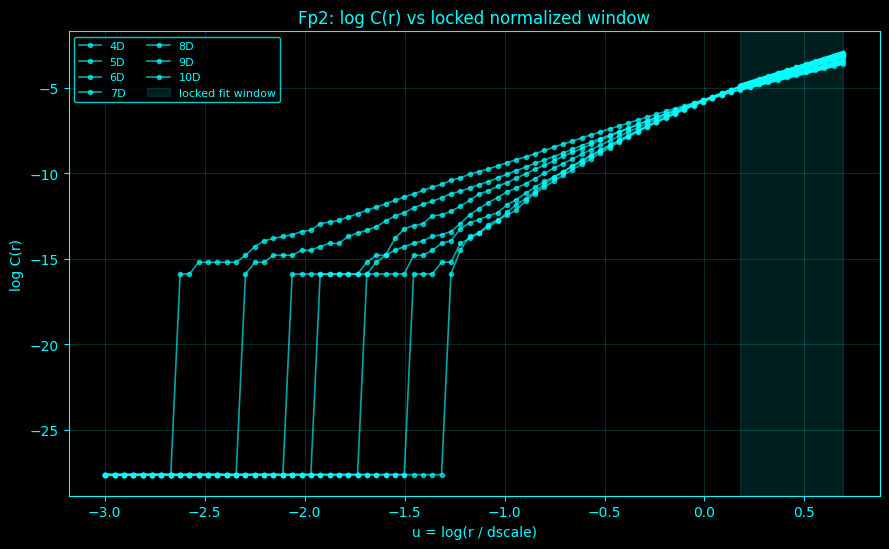

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots/per_channel/Fp2_01_logC_vs_u_overlay.png


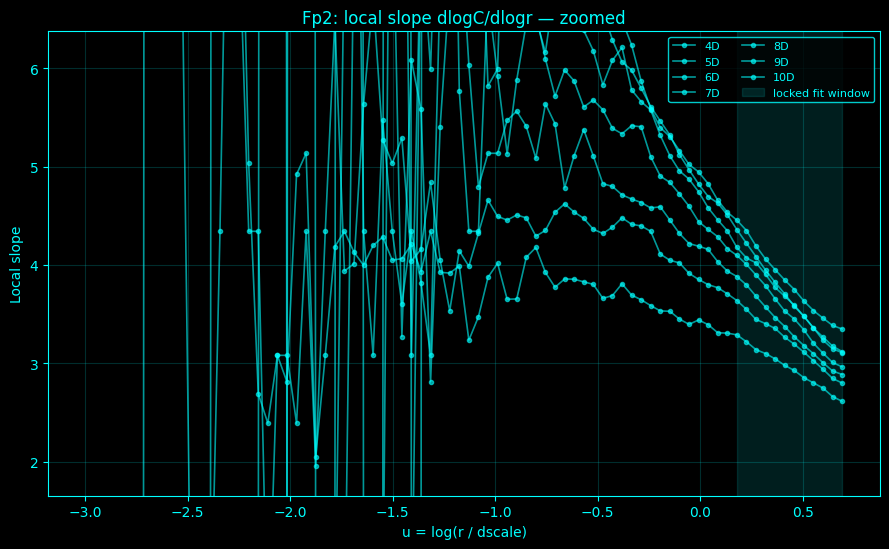

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots/per_channel/Fp2_02_local_slope_zoomed.png


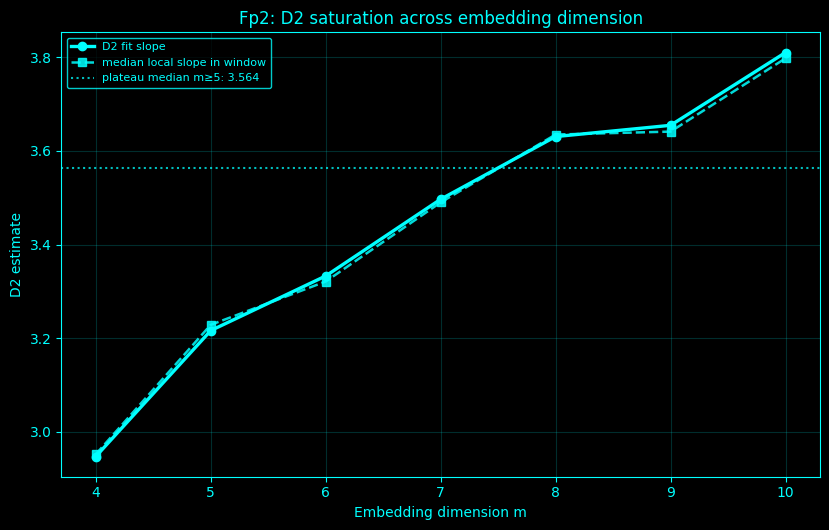

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots/per_channel/Fp2_03_D2_vs_m_saturation.png


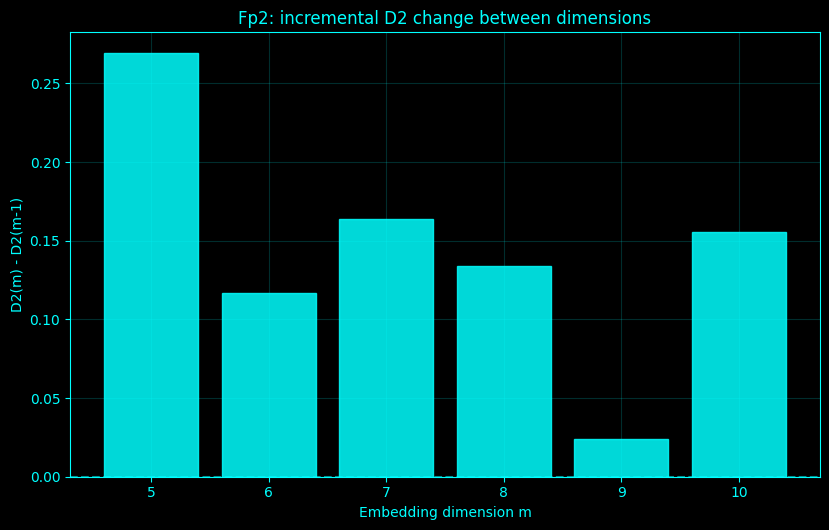

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots/per_channel/Fp2_04_D2_increment_by_m.png


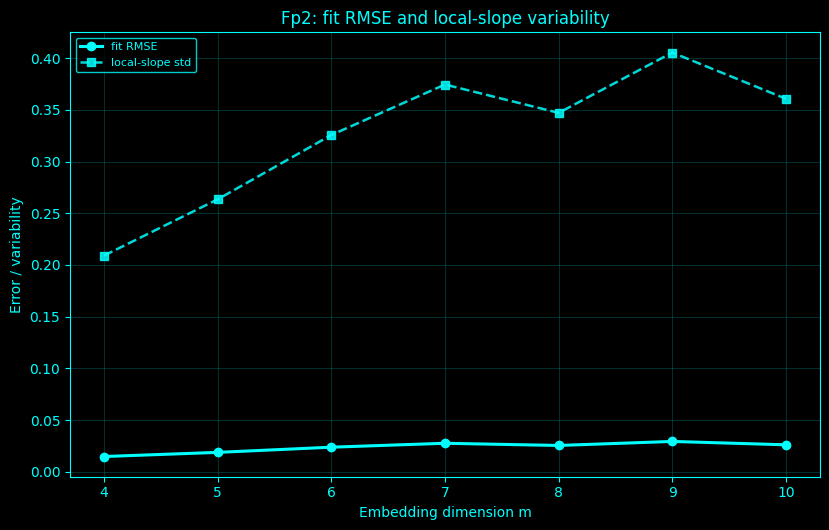

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots/per_channel/Fp2_05_rmse_and_slope_std_by_m.png


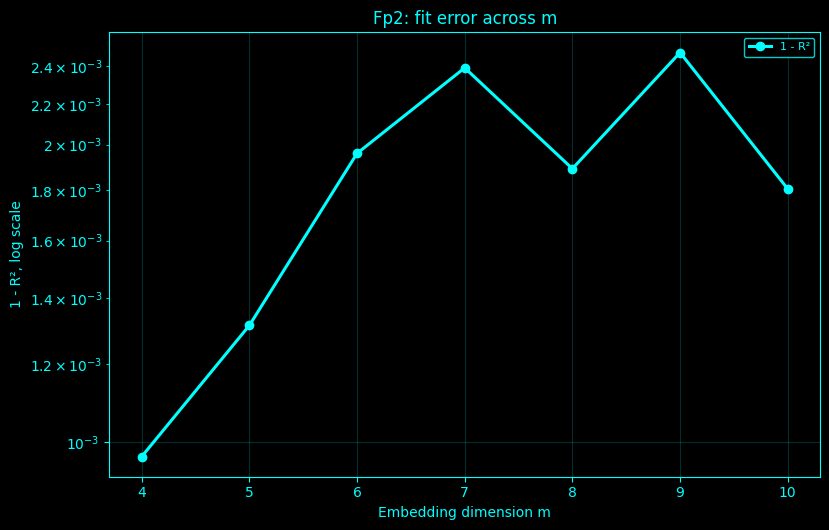

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots/per_channel/Fp2_06_one_minus_r2_by_m.png


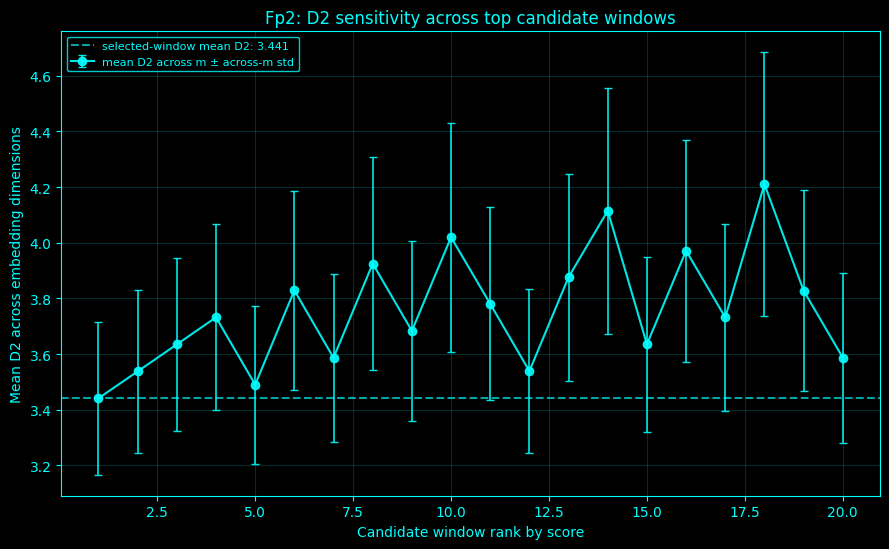

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots/window_sensitivity/Fp2_01_top_window_D2_sensitivity.png


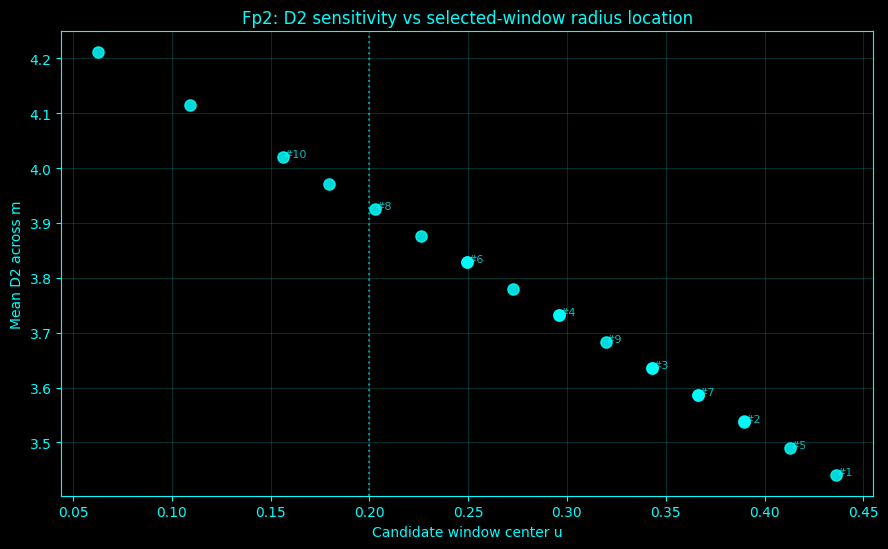

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots/window_sensitivity/Fp2_02_D2_vs_window_u_mid.png


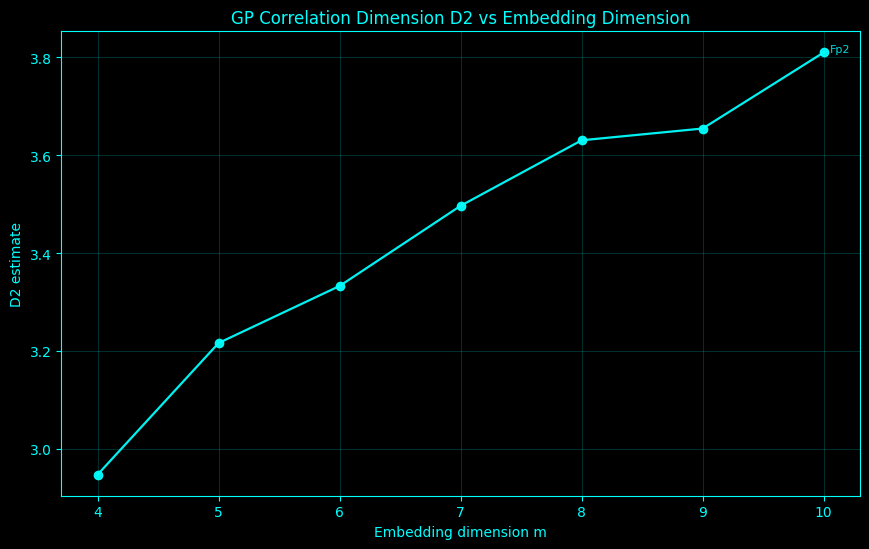

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots/01_global_D2_vs_embedding_dimension.png


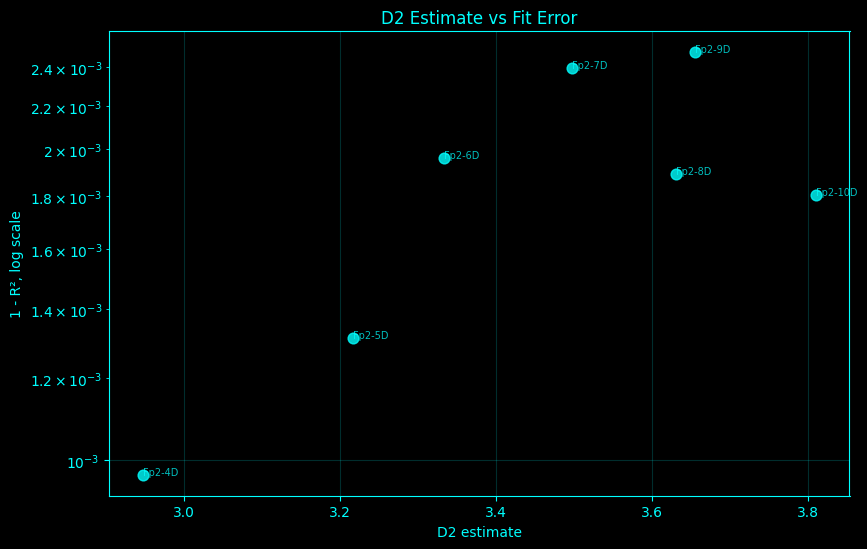

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots/02_global_D2_vs_one_minus_r2.png


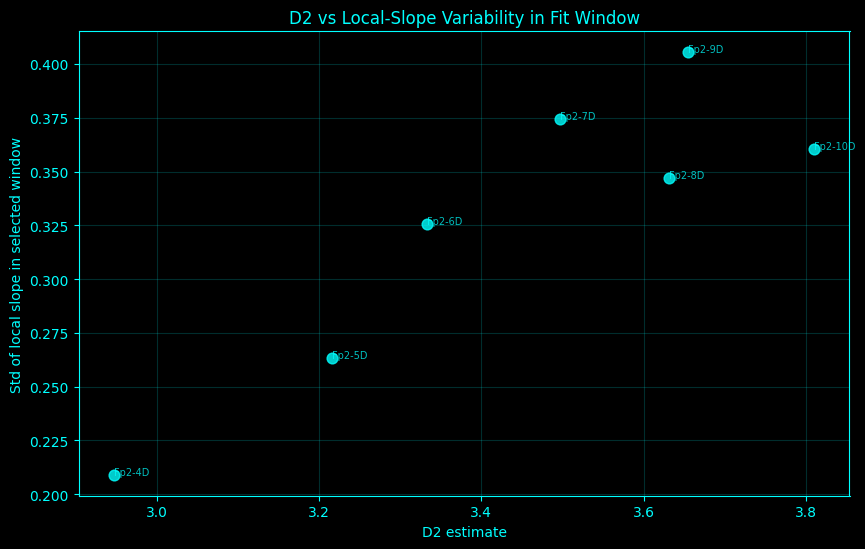

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots/03_global_D2_vs_local_slope_std.png


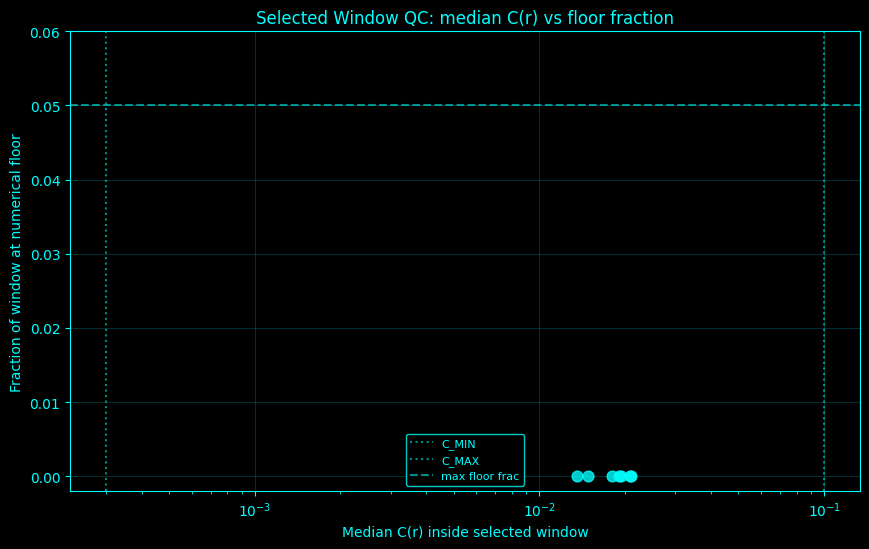

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots/04_global_window_C_QC_fixed_ylim.png


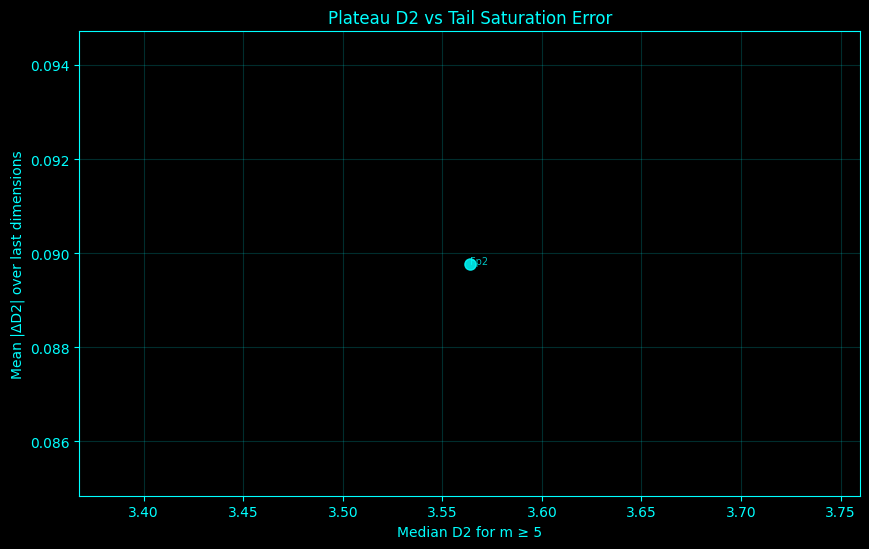

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots/05_global_plateau_D2_vs_tail_delta.png

Done.
Results directory: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded
Plots directory: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots
Per-channel plots: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots/per_channel
Window sensitivity plots: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/plots/window_sensitivity
D2 summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/gp_d2_common_window_summary_20260603_151300.csv
Channel plateau summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/gp_correlation_dimension_fixed_expanded/gp_d2_channel_plateau_summary_20260603_

In [1]:
import os
import re
import glob
import time
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import pdist

# ============================================================
# COMPLETE FIXED / EXPANDED GP CORRELATION DIMENSION D2 BLOCK
# ============================================================

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

zip_path = os.path.join(base_dir, "embedded_data_4to10.zip")
emb_dir = os.path.join(base_dir, "embedding_data", "embeddings_4to10")

results_dir = os.path.join(base_dir, "results", "gp_correlation_dimension_fixed_expanded")
plots_dir = os.path.join(results_dir, "plots")
per_channel_plots_dir = os.path.join(plots_dir, "per_channel")
window_plots_dir = os.path.join(plots_dir, "window_sensitivity")

os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(per_channel_plots_dir, exist_ok=True)
os.makedirs(window_plots_dir, exist_ok=True)

run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")

OUT_D2_SUMMARY_CSV = os.path.join(results_dir, f"gp_d2_common_window_summary_{run_tag}.csv")
OUT_CHANNEL_SUMMARY_CSV = os.path.join(results_dir, f"gp_d2_channel_plateau_summary_{run_tag}.csv")
OUT_CURVE_POINTS_CSV = os.path.join(results_dir, f"gp_d2_curve_points_{run_tag}.csv")
OUT_WINDOW_SCAN_CSV = os.path.join(results_dir, f"gp_d2_window_scan_{run_tag}.csv")
OUT_TOP_WINDOWS_CSV = os.path.join(results_dir, f"gp_d2_top_window_sensitivity_{run_tag}.csv")

# ------------------------------------------------------------
# Analysis config
# ------------------------------------------------------------
CHANNELS = ["Fp2"]       # Use ["Fp2"] for one channel, or None for all available channels.
MS = list(range(4, 11))  # Embedding dimensions 4D through 10D

THEILER = 20             # Exclude pairs within +/- THEILER original time samples
N_POINTS = 4000          # Safer/faster than 6000. Increase to 6000 later if memory is fine.
N_R = 80                 # Radius grid resolution
K_SCALE = 10             # kNN scale for radius normalization

RANDOM_SEED = 0
STANDARDIZE = True

# Correlation-sum numerical floor
C_FLOOR = 1e-12

# Strict window constraints
C_MIN = 3e-4
C_MAX = 1e-1
MAX_FLOOR_FRAC = 0.05

# Relaxed fallback if strict window fails
ALLOW_RELAXED_FALLBACK = True
RELAXED_C_MIN = 1e-5
RELAXED_C_MAX = 5e-1
RELAXED_MAX_FLOOR_FRAC = 0.15

# Window search controls
MIN_WIN_LEN = 12
MAX_WIN_LEN = 26

# u = log(r / dscale). This keeps the window from drifting too far into
# numerical-floor or large-radius saturation regions.
U_MIN_ALLOWED = -1.35
U_MAX_ALLOWED = 0.75

# Soft preference against overly large-radius windows.
U_PREFERRED_MAX = 0.20
U_HIGH_RADIUS_WEIGHT = 0.035

# Spike guards for local-slope window selection
MAX_MEDIAN_ABS_LOCAL_SLOPE = 12.0
MAX_ABS_LOCAL_SLOPE_IN_WINDOW = 25.0

# Plateau summary controls
PLATEAU_M_MIN = 5
TAIL_N_FOR_PLATEAU = 4

# Window sensitivity
TOP_N_WINDOWS_TO_ANALYZE = 20

# Plot controls
PLOT = True
PLOT_PER_CHANNEL = True
MAX_CHANNEL_DETAIL_PLOTS = 12

# ------------------------------------------------------------
# Plot style
# ------------------------------------------------------------
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})


def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=220):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)


def compact_height(n_rows, per_row=0.15, min_h=4.8, max_h=7.2):
    return float(min(max_h, max(min_h, per_row * max(n_rows, 1))))


def set_compact_yticks(ax, labels, max_labels=36, fontsize=8):
    labels = list(labels)
    n = len(labels)

    if n == 0:
        return

    if n <= max_labels:
        ticks = np.arange(n)
        shown = labels
    else:
        step = int(np.ceil(n / max_labels))
        ticks = np.arange(0, n, step)
        shown = [labels[i] for i in ticks]

    ax.set_yticks(ticks)
    ax.set_yticklabels(shown, fontsize=fontsize)


def compact_barh(ax, labels, values, max_labels=36):
    labels = list(labels)
    values = np.asarray(values, dtype=float)
    y = np.arange(len(labels))

    ax.barh(
        y,
        values,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.85
    )

    set_compact_yticks(ax, labels, max_labels=max_labels, fontsize=8)


# ------------------------------------------------------------
# Unzip embeddings if needed
# ------------------------------------------------------------
if (not os.path.isdir(emb_dir)) or (len(glob.glob(os.path.join(emb_dir, "**", "*.npy"), recursive=True)) == 0):
    if not os.path.exists(zip_path):
        raise FileNotFoundError(
            f"Could not find embedding directory or zip:\n{emb_dir}\n{zip_path}"
        )

    os.makedirs(emb_dir, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(emb_dir)

    print("Unzipped into:", emb_dir, flush=True)


# ------------------------------------------------------------
# File discovery
# ------------------------------------------------------------
def parse_embedding_filename(path):
    name = os.path.basename(path)
    stem = os.path.splitext(name)[0]
    m = re.match(r"^(\d+)dembedded_(.+)$", stem)

    if m:
        return int(m.group(1)), m.group(2)

    return None, None


def discover_embedding_files(emb_dir):
    files = glob.glob(os.path.join(emb_dir, "**", "*.npy"), recursive=True)
    mapping = {}

    for fp in files:
        m, ch = parse_embedding_filename(fp)

        if m is None or ch is None:
            continue

        mapping.setdefault(ch, {})[m] = fp

    return mapping


embedding_map = discover_embedding_files(emb_dir)

if len(embedding_map) == 0:
    raise FileNotFoundError(f"No files like 4dembedded_Fp2.npy found in: {emb_dir}")

if CHANNELS is None:
    channels_to_analyze = sorted(embedding_map.keys())
else:
    channels_to_analyze = [ch for ch in CHANNELS if ch in embedding_map]

missing_channels = []

if CHANNELS is not None:
    missing_channels = [ch for ch in CHANNELS if ch not in embedding_map]

if len(missing_channels) > 0:
    print("Missing requested channels:", missing_channels, flush=True)

if len(channels_to_analyze) == 0:
    raise ValueError("No requested channels were found.")

print("Channels to analyze:", channels_to_analyze, flush=True)


# ------------------------------------------------------------
# Core numerical helpers
# ------------------------------------------------------------
def standardize_cols(X):
    X = np.asarray(X, dtype=float)

    if X.ndim == 1:
        X = X.reshape(-1, 1)

    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    sd[sd == 0] = 1.0

    return (X - mu) / (sd + 1e-12)


def uniform_subsample_keep_original_indices(X, n_points, seed=0):
    """
    Subsamples while keeping time order and preserving original time indices.

    This fixes a subtle Theiler problem:
    if you randomly subsample and then use the subsampled row number as time,
    Theiler exclusion no longer reflects original temporal distance.
    """
    X = np.asarray(X, dtype=float)
    original_idx = np.arange(len(X), dtype=int)

    if n_points is None or len(X) <= n_points:
        return X, original_idx

    rng = np.random.default_rng(seed)
    idx = np.sort(rng.choice(len(X), size=n_points, replace=False))

    return X[idx], original_idx[idx]


def choose_r_range_from_knn(X, k=10):
    X = np.asarray(X, dtype=float)

    if len(X) < 5:
        raise ValueError("Too few points for kNN radius scale.")

    k = min(max(2, k), len(X))

    nn = NearestNeighbors(n_neighbors=k, algorithm="auto").fit(X)
    dists, _ = nn.kneighbors(X)

    dscale = float(np.nanmedian(dists[:, -1]))

    if not np.isfinite(dscale) or dscale <= 0:
        raise ValueError(f"Invalid kNN distance scale: {dscale}")

    r_min = dscale * 0.05
    r_max = dscale * 2.0

    return r_min, r_max, dscale


def gp_corr_sum_pdist_with_theiler(X, original_time_idx, rs, theiler=0, c_floor=1e-12):
    """
    Fast exact correlation sum using all upper-triangle pair distances.

    Theiler exclusion uses original_time_idx, not subsampled row index.
    This is important when the data were randomly subsampled but kept in time order.
    """
    X = np.asarray(X, dtype=float)
    original_time_idx = np.asarray(original_time_idx, dtype=int)
    N = len(X)

    if N < 10:
        raise ValueError("Too few points for correlation sum.")

    if len(original_time_idx) != N:
        raise ValueError("original_time_idx must have same length as X.")

    dvec_all = pdist(X, metric="euclidean")

    iu, ju = np.triu_indices(N, k=1)

    if theiler > 0:
        ok = np.abs(original_time_idx[iu] - original_time_idx[ju]) > theiler
        dvec = dvec_all[ok]
    else:
        dvec = dvec_all

    dvec = dvec[np.isfinite(dvec)]
    dvec.sort()

    eligible_pairs = len(dvec)

    if eligible_pairs < 10:
        raise ValueError("Too few eligible pairs after Theiler exclusion.")

    counts = np.searchsorted(dvec, rs, side="right")
    Cs = counts.astype(float) / float(eligible_pairs)
    Cs = np.maximum(Cs, c_floor)

    return Cs, eligible_pairs


def window_ok(Cs, idx_lo, idx_hi, c_min, c_max, max_floor_frac):
    seg = np.asarray(Cs[idx_lo:idx_hi + 1], dtype=float)

    if len(seg) == 0:
        return False, np.nan, np.nan

    floor_frac = float(np.mean(seg <= C_FLOOR * 1.000001))
    medC = float(np.nanmedian(seg))

    ok = (
        (floor_frac <= max_floor_frac)
        and (c_min <= medC <= c_max)
        and np.all(np.isfinite(seg))
    )

    return ok, medC, floor_frac


def linear_fit_quality(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 3:
        return np.nan, np.nan, np.nan, np.nan, np.full_like(y, np.nan)

    x_fit = x[mask]
    y_fit = y[mask]

    coef = np.polyfit(x_fit, y_fit, 1)
    yhat_fit = np.polyval(coef, x_fit)

    ss_res = float(np.sum((y_fit - yhat_fit) ** 2))
    ss_tot = float(np.sum((y_fit - np.mean(y_fit)) ** 2))

    r2 = 1.0 - ss_res / (ss_tot + 1e-12)
    rmse = float(np.sqrt(np.mean((y_fit - yhat_fit) ** 2)))

    yhat_full = np.full_like(y, np.nan, dtype=float)
    yhat_full[mask] = yhat_fit

    return float(coef[0]), float(coef[1]), float(r2), rmse, yhat_full


def scan_common_windows(curves, min_win_len, max_win_len, strict=True):
    """
    Searches for one common scale window shared across all available embedding dimensions.

    This is a major fix over choosing separate windows per m, because separate windows can
    artificially create a flat D2-vs-m curve.
    """
    ms_avail = sorted(curves.keys())

    if len(ms_avail) < 2:
        raise ValueError("Need at least two embedding dimensions to scan common windows.")

    n_r = len(curves[ms_avail[0]]["u"])
    max_win_len = min(max_win_len, n_r)

    if strict:
        c_min = C_MIN
        c_max = C_MAX
        max_floor_frac = MAX_FLOOR_FRAC
    else:
        c_min = RELAXED_C_MIN
        c_max = RELAXED_C_MAX
        max_floor_frac = RELAXED_MAX_FLOOR_FRAC

    rows = []
    best = None

    common_u = curves[ms_avail[0]]["u"]

    for win_len in range(min_win_len, max_win_len + 1):
        for start in range(0, n_r - win_len + 1):
            end = start + win_len - 1

            u_lo = float(common_u[start])
            u_hi = float(common_u[end])
            u_mid = float(0.5 * (u_lo + u_hi))

            if u_lo < U_MIN_ALLOWED or u_hi > U_MAX_ALLOWED:
                continue

            ok_all = True

            slope_stds = []
            slope_means = []
            slope_medians = []
            slope_max_abs = []
            fit_r2s = []
            fit_rmses = []
            medCs = []
            floor_fracs = []

            for m in ms_avail:
                c = curves[m]

                ok, medC, floor_frac = window_ok(
                    c["Cs"],
                    start,
                    end,
                    c_min=c_min,
                    c_max=c_max,
                    max_floor_frac=max_floor_frac
                )

                if not ok:
                    ok_all = False
                    break

                slope_seg = c["slope"][start:end + 1]
                slope_seg = slope_seg[np.isfinite(slope_seg)]

                if len(slope_seg) < 3:
                    ok_all = False
                    break

                med_abs_slope = float(np.nanmedian(np.abs(slope_seg)))
                max_abs_slope = float(np.nanmax(np.abs(slope_seg)))

                if med_abs_slope > MAX_MEDIAN_ABS_LOCAL_SLOPE:
                    ok_all = False
                    break

                if max_abs_slope > MAX_ABS_LOCAL_SLOPE_IN_WINDOW:
                    ok_all = False
                    break

                slope_stds.append(float(np.nanstd(slope_seg)))
                slope_means.append(float(np.nanmean(slope_seg)))
                slope_medians.append(float(np.nanmedian(slope_seg)))
                slope_max_abs.append(max_abs_slope)

                fit_slope, fit_intercept, r2, rmse, _ = linear_fit_quality(
                    c["logr"][start:end + 1],
                    c["logC"][start:end + 1]
                )

                fit_r2s.append(r2)
                fit_rmses.append(rmse)
                medCs.append(medC)
                floor_fracs.append(floor_frac)

            if not ok_all:
                continue

            slope_stability = float(np.nanmean(slope_stds))
            across_m_slope_sd = float(np.nanstd(slope_means))
            across_m_slope_median_sd = float(np.nanstd(slope_medians))
            mean_r2 = float(np.nanmean(fit_r2s))
            min_r2 = float(np.nanmin(fit_r2s))
            mean_rmse = float(np.nanmean(fit_rmses))
            mean_medC = float(np.nanmean(medCs))
            min_medC = float(np.nanmin(medCs))
            max_medC = float(np.nanmax(medCs))
            max_floor = float(np.nanmax(floor_fracs))
            mean_max_abs_slope = float(np.nanmean(slope_max_abs))

            high_radius_penalty = U_HIGH_RADIUS_WEIGHT * max(0.0, u_mid - U_PREFERRED_MAX)

            score = (
                slope_stability
                + 0.50 * across_m_slope_sd
                + 0.25 * mean_rmse
                + 0.50 * max(0.0, 0.995 - mean_r2)
                + 0.25 * max(0.0, 0.990 - min_r2)
                + high_radius_penalty
            )

            row = {
                "strict": bool(strict),
                "start": int(start),
                "end": int(end),
                "win_len": int(win_len),
                "u_lo": u_lo,
                "u_hi": u_hi,
                "u_mid": u_mid,
                "score": float(score),
                "slope_stability_mean": slope_stability,
                "across_m_slope_sd": across_m_slope_sd,
                "across_m_slope_median_sd": across_m_slope_median_sd,
                "mean_fit_r2": mean_r2,
                "min_fit_r2": min_r2,
                "mean_fit_rmse": mean_rmse,
                "mean_median_C": mean_medC,
                "min_median_C": min_medC,
                "max_median_C": max_medC,
                "max_floor_frac": max_floor,
                "mean_max_abs_local_slope": mean_max_abs_slope,
                "high_radius_penalty": float(high_radius_penalty),
            }

            rows.append(row)

            if best is None or row["score"] < best["score"]:
                best = row

    scan_df = pd.DataFrame(rows)

    return best, scan_df


def compute_curves_for_channel(channel, m_to_path):
    curves = {}
    curve_rows = []

    for m in MS:
        if m not in m_to_path:
            print(f"{channel}: missing {m}D file; skipping dimension.", flush=True)
            continue

        fpath = m_to_path[m]
        fname = os.path.basename(fpath)

        Xfull = np.load(fpath, allow_pickle=True)
        Xfull = np.asarray(Xfull, dtype=float)
        Xfull = np.squeeze(Xfull)

        if Xfull.ndim != 2:
            raise ValueError(f"{fname}: expected 2D array, got {Xfull.shape}")

        if Xfull.shape[1] < m:
            raise ValueError(f"{fname}: expected at least {m} columns, got {Xfull.shape}")

        Xfull = Xfull[:, :m]

        finite_rows = np.all(np.isfinite(Xfull), axis=1)
        Xfull = Xfull[finite_rows]

        if STANDARDIZE:
            Xfull = standardize_cols(Xfull)

        X, original_time_idx = uniform_subsample_keep_original_indices(
            Xfull,
            n_points=N_POINTS,
            seed=RANDOM_SEED
        )

        r_min, r_max, dscale = choose_r_range_from_knn(X, k=K_SCALE)

        rs = np.logspace(np.log10(r_min), np.log10(r_max), N_R)

        Cs, eligible_pairs = gp_corr_sum_pdist_with_theiler(
            X,
            original_time_idx=original_time_idx,
            rs=rs,
            theiler=THEILER,
            c_floor=C_FLOOR
        )

        logr = np.log(rs)
        u = np.log(rs / dscale)
        logC = np.log(Cs)
        slope = np.gradient(logC, logr)

        curves[m] = {
            "channel": channel,
            "m": m,
            "file": fname,
            "path": fpath,
            "N_original": int(len(Xfull)),
            "N_used": int(len(X)),
            "eligible_pairs": int(eligible_pairs),
            "dscale": float(dscale),
            "rs": rs,
            "u": u,
            "logr": logr,
            "Cs": Cs,
            "logC": logC,
            "slope": slope,
        }

        for idx in range(len(rs)):
            curve_rows.append({
                "channel": channel,
                "m": m,
                "file": fname,
                "r_index": idx,
                "r": float(rs[idx]),
                "u": float(u[idx]),
                "logr": float(logr[idx]),
                "C": float(Cs[idx]),
                "logC": float(logC[idx]),
                "local_slope": float(slope[idx]),
                "dscale": float(dscale),
                "N_original": int(len(Xfull)),
                "N_used": int(len(X)),
                "eligible_pairs": int(eligible_pairs),
            })

    return curves, curve_rows


def fit_channel_d2(channel, curves):
    if len(curves) == 0:
        raise ValueError(f"{channel}: no curves available.")

    if len(curves) < 2:
        raise ValueError(f"{channel}: need at least two embedding dimensions for D2-vs-m analysis.")

    best, scan_df_strict = scan_common_windows(
        curves,
        min_win_len=MIN_WIN_LEN,
        max_win_len=MAX_WIN_LEN,
        strict=True
    )

    scan_dfs = []

    if len(scan_df_strict) > 0:
        scan_dfs.append(scan_df_strict)

    window_strict = True

    if best is None and ALLOW_RELAXED_FALLBACK:
        print(f"{channel}: no strict window found; trying relaxed constraints.", flush=True)

        best, scan_df_relaxed = scan_common_windows(
            curves,
            min_win_len=MIN_WIN_LEN,
            max_win_len=MAX_WIN_LEN,
            strict=False
        )

        if len(scan_df_relaxed) > 0:
            scan_dfs.append(scan_df_relaxed)

        window_strict = False

    if len(scan_dfs) > 0:
        scan_df = pd.concat(scan_dfs, ignore_index=True)
    else:
        scan_df = pd.DataFrame()

    if best is None:
        raise RuntimeError(
            f"{channel}: no common window found. "
            "Try increasing N_POINTS, changing C_MIN/C_MAX, or adjusting U_MIN_ALLOWED/U_MAX_ALLOWED."
        )

    fit_lo = int(best["start"])
    fit_hi = int(best["end"])

    summary_rows = []

    for m in sorted(curves.keys()):
        c = curves[m]

        fit_slope, fit_intercept, r2, rmse, _ = linear_fit_quality(
            c["logr"][fit_lo:fit_hi + 1],
            c["logC"][fit_lo:fit_hi + 1]
        )

        ok_strict, medC_strict, floor_strict = window_ok(
            c["Cs"],
            fit_lo,
            fit_hi,
            c_min=C_MIN,
            c_max=C_MAX,
            max_floor_frac=MAX_FLOOR_FRAC
        )

        slope_seg = c["slope"][fit_lo:fit_hi + 1]

        summary_rows.append({
            "channel": channel,
            "m": m,
            "file": c["file"],
            "path": c["path"],
            "status": "ok",
            "window_strict": bool(window_strict),
            "fit_start_index": fit_lo,
            "fit_end_index": fit_hi,
            "fit_window_len": int(fit_hi - fit_lo + 1),
            "u_lo": float(c["u"][fit_lo]),
            "u_hi": float(c["u"][fit_hi]),
            "u_mid": float(0.5 * (c["u"][fit_lo] + c["u"][fit_hi])),
            "logr_lo": float(c["logr"][fit_lo]),
            "logr_hi": float(c["logr"][fit_hi]),
            "D2": float(fit_slope),
            "fit_intercept": float(fit_intercept),
            "fit_r2": float(r2),
            "fit_1_minus_r2": float(max(1e-16, 1.0 - r2)),
            "fit_rmse": float(rmse),
            "window_median_C": float(medC_strict),
            "window_floor_frac": float(floor_strict),
            "local_slope_mean": float(np.nanmean(slope_seg)),
            "local_slope_median": float(np.nanmedian(slope_seg)),
            "local_slope_std": float(np.nanstd(slope_seg)),
            "local_slope_min": float(np.nanmin(slope_seg)),
            "local_slope_max": float(np.nanmax(slope_seg)),
            "N_original": c["N_original"],
            "N_used": c["N_used"],
            "eligible_pairs": c["eligible_pairs"],
            "dscale": c["dscale"],
            "scan_score": float(best["score"]),
            "scan_mean_fit_r2": float(best["mean_fit_r2"]),
            "scan_mean_fit_rmse": float(best["mean_fit_rmse"]),
            "scan_slope_stability_mean": float(best["slope_stability_mean"]),
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_df = summary_df.sort_values("m").reset_index(drop=True)
    summary_df["D2_delta_from_prev_m"] = summary_df["D2"].diff()
    summary_df["D2_abs_delta_from_prev_m"] = summary_df["D2_delta_from_prev_m"].abs()

    return summary_df, scan_df, best


def summarize_top_windows(channel, curves, scan_df, n_top=20):
    if scan_df is None or len(scan_df) == 0:
        return pd.DataFrame()

    rows = []
    scan_use = scan_df.sort_values("score", ascending=True).head(n_top).copy()

    for rank, (_, win) in enumerate(scan_use.iterrows(), start=1):
        start = int(win["start"])
        end = int(win["end"])

        d2_vals = []
        r2_vals = []
        rmse_vals = []
        slope_std_vals = []

        for m in sorted(curves.keys()):
            c = curves[m]

            fit_slope, fit_intercept, r2, rmse, _ = linear_fit_quality(
                c["logr"][start:end + 1],
                c["logC"][start:end + 1]
            )

            slope_seg = c["slope"][start:end + 1]

            d2_vals.append(fit_slope)
            r2_vals.append(r2)
            rmse_vals.append(rmse)
            slope_std_vals.append(float(np.nanstd(slope_seg)))

            rows.append({
                "channel": channel,
                "window_rank": rank,
                "m": m,
                "start": start,
                "end": end,
                "win_len": int(win["win_len"]),
                "u_lo": float(win["u_lo"]),
                "u_hi": float(win["u_hi"]),
                "u_mid": float(win["u_mid"]),
                "window_score": float(win["score"]),
                "D2": float(fit_slope),
                "fit_r2": float(r2),
                "fit_1_minus_r2": float(max(1e-16, 1.0 - r2)),
                "fit_rmse": float(rmse),
                "local_slope_std": float(np.nanstd(slope_seg)),
            })

        rows.append({
            "channel": channel,
            "window_rank": rank,
            "m": "all_mean",
            "start": start,
            "end": end,
            "win_len": int(win["win_len"]),
            "u_lo": float(win["u_lo"]),
            "u_hi": float(win["u_hi"]),
            "u_mid": float(win["u_mid"]),
            "window_score": float(win["score"]),
            "D2": float(np.nanmean(d2_vals)),
            "fit_r2": float(np.nanmean(r2_vals)),
            "fit_1_minus_r2": float(max(1e-16, 1.0 - np.nanmean(r2_vals))),
            "fit_rmse": float(np.nanmean(rmse_vals)),
            "local_slope_std": float(np.nanmean(slope_std_vals)),
            "D2_across_m_std": float(np.nanstd(d2_vals)),
            "D2_across_m_min": float(np.nanmin(d2_vals)),
            "D2_across_m_max": float(np.nanmax(d2_vals)),
        })

    return pd.DataFrame(rows)


def channel_plateau_summary(summary_df):
    channel = summary_df["channel"].iloc[0]
    summary_df = summary_df.sort_values("m").copy()

    d2 = summary_df["D2"].to_numpy(dtype=float)
    mvals = summary_df["m"].to_numpy(dtype=float)

    if len(d2) >= 2:
        d2_range = float(np.nanmax(d2) - np.nanmin(d2))
        last_delta = float(d2[-1] - d2[-2])
        abs_last_delta = float(abs(last_delta))
    else:
        d2_range = np.nan
        last_delta = np.nan
        abs_last_delta = np.nan

    if len(d2) >= 3:
        tail_delta_mean = float(np.nanmean(np.abs(np.diff(d2[-3:]))))
    else:
        tail_delta_mean = np.nan

    if len(d2) >= TAIL_N_FOR_PLATEAU:
        tail_d2 = d2[-TAIL_N_FOR_PLATEAU:]
    else:
        tail_d2 = d2.copy()

    plateau_vals = summary_df[summary_df["m"] >= PLATEAU_M_MIN]["D2"].to_numpy(dtype=float)

    if len(plateau_vals) == 0:
        plateau_vals = tail_d2.copy()

    plateau_median = float(np.nanmedian(plateau_vals))
    plateau_mean = float(np.nanmean(plateau_vals))
    plateau_std = float(np.nanstd(plateau_vals))
    plateau_iqr = float(np.nanpercentile(plateau_vals, 75) - np.nanpercentile(plateau_vals, 25))

    tail_median = float(np.nanmedian(tail_d2))
    tail_mean = float(np.nanmean(tail_d2))
    tail_std = float(np.nanstd(tail_d2))

    if len(d2) >= 3:
        slope, intercept = np.polyfit(mvals, d2, 1)
    else:
        slope, intercept = np.nan, np.nan

    plateau_candidate = bool(
        np.isfinite(abs_last_delta)
        and abs_last_delta < 0.25
        and np.isfinite(tail_delta_mean)
        and tail_delta_mean < 0.35
        and np.isfinite(plateau_std)
        and plateau_std < 0.20
    )

    return {
        "channel": channel,
        "status": "ok",
        "n_dimensions": int(len(summary_df)),
        "m_min": int(np.nanmin(mvals)),
        "m_max": int(np.nanmax(mvals)),
        "D2_min": float(np.nanmin(d2)),
        "D2_max": float(np.nanmax(d2)),
        "D2_range": d2_range,
        "D2_last": float(d2[-1]),
        "D2_last_delta": last_delta,
        "D2_abs_last_delta": abs_last_delta,
        "D2_tail_abs_delta_mean": tail_delta_mean,
        "D2_vs_m_slope": float(slope),
        "D2_vs_m_intercept": float(intercept),
        "D2_plateau_m_min": int(PLATEAU_M_MIN),
        "D2_plateau_median_m_ge_min": plateau_median,
        "D2_plateau_mean_m_ge_min": plateau_mean,
        "D2_plateau_std_m_ge_min": plateau_std,
        "D2_plateau_iqr_m_ge_min": plateau_iqr,
        "D2_tail_median": tail_median,
        "D2_tail_mean": tail_mean,
        "D2_tail_std": tail_std,
        "mean_fit_r2": float(summary_df["fit_r2"].mean()),
        "mean_1_minus_r2": float(summary_df["fit_1_minus_r2"].mean()),
        "mean_fit_rmse": float(summary_df["fit_rmse"].mean()),
        "mean_local_slope_std": float(summary_df["local_slope_std"].mean()),
        "all_windows_strict": bool(summary_df["window_strict"].all()),
        "plateau_candidate": plateau_candidate,
    }


# ------------------------------------------------------------
# Plotting helpers
# ------------------------------------------------------------
def plot_channel_detail(channel, curves, best, summary_df, top_window_df):
    fit_lo = int(best["start"])
    fit_hi = int(best["end"])

    ref_m = sorted(curves.keys())[0]
    u0 = curves[ref_m]["u"][fit_lo]
    u1 = curves[ref_m]["u"][fit_hi]

    # --------------------------------------------------------
    # Plot 1: log C(r) overlay
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9.0, 5.6), facecolor=BG)
    style_ax(ax)

    for m in sorted(curves.keys()):
        c = curves[m]

        ax.plot(
            c["u"],
            c["logC"],
            marker="o",
            markersize=3,
            linewidth=1.2,
            alpha=0.65,
            color=ACCENT,
            label=f"{m}D"
        )

        row = summary_df[summary_df["m"] == m].iloc[0]
        fit_y = row["fit_intercept"] + row["D2"] * c["logr"]

        ax.plot(
            c["u"][fit_lo:fit_hi + 1],
            fit_y[fit_lo:fit_hi + 1],
            linewidth=2.4,
            color=ACCENT,
            alpha=0.95
        )

    ax.axvspan(u0, u1, color=ACCENT, alpha=0.12, label="locked fit window")

    ax.set_title(f"{channel}: log C(r) vs locked normalized window")
    ax.set_xlabel("u = log(r / dscale)")
    ax.set_ylabel("log C(r)")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8, ncol=2)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    plot_path = os.path.join(per_channel_plots_dir, f"{channel}_01_logC_vs_u_overlay.png")
    save_show_close(fig, plot_path)

    # --------------------------------------------------------
    # Plot 2: local slope zoomed
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9.0, 5.6), facecolor=BG)
    style_ax(ax)

    selected_slopes = []

    for m in sorted(curves.keys()):
        c = curves[m]

        ax.plot(
            c["u"],
            c["slope"],
            marker="o",
            markersize=3,
            linewidth=1.2,
            alpha=0.60,
            color=ACCENT,
            label=f"{m}D"
        )

        selected_slopes.extend(c["slope"][fit_lo:fit_hi + 1].tolist())

    selected_slopes = np.asarray(selected_slopes, dtype=float)
    selected_slopes = selected_slopes[np.isfinite(selected_slopes)]

    if len(selected_slopes) > 0:
        y_low = max(-2.0, float(np.nanpercentile(selected_slopes, 1) - 1.0))
        y_high = min(14.0, max(6.0, float(np.nanpercentile(selected_slopes, 99) + 2.0)))
        ax.set_ylim(y_low, y_high)
    else:
        ax.set_ylim(-1.0, 12.0)

    ax.axvspan(u0, u1, color=ACCENT, alpha=0.12, label="locked fit window")

    ax.set_title(f"{channel}: local slope dlogC/dlogr — zoomed")
    ax.set_xlabel("u = log(r / dscale)")
    ax.set_ylabel("Local slope")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8, ncol=2)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    plot_path = os.path.join(per_channel_plots_dir, f"{channel}_02_local_slope_zoomed.png")
    save_show_close(fig, plot_path)

    # --------------------------------------------------------
    # Plot 3: D2 saturation
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8.4, 5.4), facecolor=BG)
    style_ax(ax)

    ax.plot(
        summary_df["m"],
        summary_df["D2"],
        color=ACCENT,
        marker="o",
        linewidth=2.4,
        label="D2 fit slope"
    )

    ax.plot(
        summary_df["m"],
        summary_df["local_slope_median"],
        color=ACCENT,
        marker="s",
        linestyle="--",
        alpha=0.85,
        linewidth=1.8,
        label="median local slope in window"
    )

    plateau_vals = summary_df[summary_df["m"] >= PLATEAU_M_MIN]["D2"]

    if len(plateau_vals) > 0:
        plateau_val = float(plateau_vals.median())
        ax.axhline(
            plateau_val,
            color=ACCENT,
            linestyle=":",
            alpha=0.75,
            label=f"plateau median m≥{PLATEAU_M_MIN}: {plateau_val:.3f}"
        )

    ax.set_title(f"{channel}: D2 saturation across embedding dimension")
    ax.set_xlabel("Embedding dimension m")
    ax.set_ylabel("D2 estimate")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    plot_path = os.path.join(per_channel_plots_dir, f"{channel}_03_D2_vs_m_saturation.png")
    save_show_close(fig, plot_path)

    # --------------------------------------------------------
    # Plot 4: D2 increments
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8.4, 5.4), facecolor=BG)
    style_ax(ax)

    delta_df = summary_df.dropna(subset=["D2_delta_from_prev_m"])

    ax.bar(
        delta_df["m"],
        delta_df["D2_delta_from_prev_m"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.85
    )

    ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.55)

    ax.set_title(f"{channel}: incremental D2 change between dimensions")
    ax.set_xlabel("Embedding dimension m")
    ax.set_ylabel("D2(m) - D2(m-1)")

    plot_path = os.path.join(per_channel_plots_dir, f"{channel}_04_D2_increment_by_m.png")
    save_show_close(fig, plot_path)

    # --------------------------------------------------------
    # Plot 5: fit error and slope variability
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8.4, 5.4), facecolor=BG)
    style_ax(ax)

    ax.plot(
        summary_df["m"],
        summary_df["fit_rmse"],
        color=ACCENT,
        marker="o",
        linewidth=2.2,
        label="fit RMSE"
    )

    ax.plot(
        summary_df["m"],
        summary_df["local_slope_std"],
        color=ACCENT,
        marker="s",
        linestyle="--",
        linewidth=1.8,
        alpha=0.85,
        label="local-slope std"
    )

    ax.set_title(f"{channel}: fit RMSE and local-slope variability")
    ax.set_xlabel("Embedding dimension m")
    ax.set_ylabel("Error / variability")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    plot_path = os.path.join(per_channel_plots_dir, f"{channel}_05_rmse_and_slope_std_by_m.png")
    save_show_close(fig, plot_path)

    # --------------------------------------------------------
    # Plot 6: 1 - R² log scale
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8.4, 5.4), facecolor=BG)
    style_ax(ax)

    ax.plot(
        summary_df["m"],
        summary_df["fit_1_minus_r2"],
        color=ACCENT,
        marker="o",
        linewidth=2.2,
        label="1 - R²"
    )

    ax.set_yscale("log")

    ax.set_title(f"{channel}: fit error across m")
    ax.set_xlabel("Embedding dimension m")
    ax.set_ylabel("1 - R², log scale")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    plot_path = os.path.join(per_channel_plots_dir, f"{channel}_06_one_minus_r2_by_m.png")
    save_show_close(fig, plot_path)

    # --------------------------------------------------------
    # Plot 7: window sensitivity
    # --------------------------------------------------------
    if top_window_df is not None and len(top_window_df) > 0:
        tw_mean = top_window_df[top_window_df["m"].astype(str) == "all_mean"].copy()

        if len(tw_mean) > 0:
            tw_mean = tw_mean.sort_values("window_rank")

            fig, ax = plt.subplots(figsize=(9.0, 5.6), facecolor=BG)
            style_ax(ax)

            yerr = tw_mean["D2_across_m_std"].fillna(0).to_numpy(dtype=float)

            ax.errorbar(
                tw_mean["window_rank"],
                tw_mean["D2"],
                yerr=yerr,
                fmt="o-",
                color=ACCENT,
                ecolor=ACCENT,
                elinewidth=1.2,
                capsize=3,
                alpha=0.9,
                label="mean D2 across m ± across-m std"
            )

            selected_mean_d2 = float(summary_df["D2"].mean())

            ax.axhline(
                selected_mean_d2,
                color=ACCENT,
                linestyle="--",
                alpha=0.65,
                label=f"selected-window mean D2: {selected_mean_d2:.3f}"
            )

            ax.set_title(f"{channel}: D2 sensitivity across top candidate windows")
            ax.set_xlabel("Candidate window rank by score")
            ax.set_ylabel("Mean D2 across embedding dimensions")

            leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
            for text in leg.get_texts():
                text.set_color(ACCENT)

            plot_path = os.path.join(window_plots_dir, f"{channel}_01_top_window_D2_sensitivity.png")
            save_show_close(fig, plot_path)

            fig, ax = plt.subplots(figsize=(9.0, 5.6), facecolor=BG)
            style_ax(ax)

            ax.scatter(
                tw_mean["u_mid"],
                tw_mean["D2"],
                color=ACCENT,
                edgecolor=ACCENT,
                s=65,
                alpha=0.85
            )

            for _, row in tw_mean.head(10).iterrows():
                ax.text(
                    row["u_mid"],
                    row["D2"],
                    f"#{int(row['window_rank'])}",
                    color=ACCENT,
                    fontsize=8,
                    alpha=0.75
                )

            ax.axvline(U_PREFERRED_MAX, color=ACCENT, linestyle=":", alpha=0.55)

            ax.set_title(f"{channel}: D2 sensitivity vs selected-window radius location")
            ax.set_xlabel("Candidate window center u")
            ax.set_ylabel("Mean D2 across m")

            plot_path = os.path.join(window_plots_dir, f"{channel}_02_D2_vs_window_u_mid.png")
            save_show_close(fig, plot_path)


# ------------------------------------------------------------
# Run analysis
# ------------------------------------------------------------
all_summary_rows = []
all_curve_rows = []
all_scan_rows = []
all_top_window_rows = []
channel_summary_rows = []

channel_curve_store = {}
channel_best_store = {}
channel_summary_store = {}
channel_top_window_store = {}

start_time = time.time()

for idx, channel in enumerate(channels_to_analyze, start=1):
    print(f"\n[{idx}/{len(channels_to_analyze)}] Processing channel {channel}", flush=True)

    try:
        curves, curve_rows = compute_curves_for_channel(channel, embedding_map[channel])

        if len(curves) == 0:
            raise ValueError("No curves computed.")

        summary_df, scan_df, best = fit_channel_d2(channel, curves)
        scan_df["channel"] = channel

        top_window_df = summarize_top_windows(
            channel,
            curves,
            scan_df,
            n_top=TOP_N_WINDOWS_TO_ANALYZE
        )

        all_summary_rows.extend(summary_df.to_dict("records"))
        all_curve_rows.extend(curve_rows)
        all_scan_rows.extend(scan_df.to_dict("records"))

        if len(top_window_df) > 0:
            all_top_window_rows.extend(top_window_df.to_dict("records"))

        ch_summary = channel_plateau_summary(summary_df)
        channel_summary_rows.append(ch_summary)

        channel_curve_store[channel] = curves
        channel_best_store[channel] = best
        channel_summary_store[channel] = summary_df
        channel_top_window_store[channel] = top_window_df

        print(
            f"  OK | dims={summary_df['m'].tolist()} | "
            f"D2={summary_df['D2'].min():.3f} to {summary_df['D2'].max():.3f} | "
            f"plateau median m≥{PLATEAU_M_MIN}={ch_summary['D2_plateau_median_m_ge_min']:.3f} | "
            f"tail Δ={ch_summary['D2_tail_abs_delta_mean']:.3f} | "
            f"strict_window={summary_df['window_strict'].all()} | "
            f"u=[{summary_df['u_lo'].iloc[0]:.3f}, {summary_df['u_hi'].iloc[0]:.3f}]",
            flush=True
        )

    except Exception as e:
        print(f"  ERROR for channel {channel}: {type(e).__name__}: {e}", flush=True)

        channel_summary_rows.append({
            "channel": channel,
            "status": "error",
            "error": f"{type(e).__name__}: {e}",
        })

elapsed = time.time() - start_time

d2_summary = pd.DataFrame(all_summary_rows)
curve_points = pd.DataFrame(all_curve_rows)
window_scan = pd.DataFrame(all_scan_rows)
top_windows = pd.DataFrame(all_top_window_rows)
channel_summary = pd.DataFrame(channel_summary_rows)

d2_summary.to_csv(OUT_D2_SUMMARY_CSV, index=False)
curve_points.to_csv(OUT_CURVE_POINTS_CSV, index=False)
window_scan.to_csv(OUT_WINDOW_SCAN_CSV, index=False)
top_windows.to_csv(OUT_TOP_WINDOWS_CSV, index=False)
channel_summary.to_csv(OUT_CHANNEL_SUMMARY_CSV, index=False)

print("\nSaved D2 summary:", OUT_D2_SUMMARY_CSV)
print("Saved channel summary:", OUT_CHANNEL_SUMMARY_CSV)
print("Saved curve points:", OUT_CURVE_POINTS_CSV)
print("Saved window scan:", OUT_WINDOW_SCAN_CSV)
print("Saved top-window sensitivity:", OUT_TOP_WINDOWS_CSV)
print(f"Elapsed: {elapsed / 60:.2f} minutes")

if len(d2_summary) == 0:
    raise ValueError("No successful D2 fits. Check printed errors and output CSVs.")

print("\nD2 summary:")
print(
    d2_summary[
        [
            "channel",
            "m",
            "D2",
            "fit_r2",
            "fit_1_minus_r2",
            "fit_rmse",
            "window_median_C",
            "window_floor_frac",
            "local_slope_std",
            "u_lo",
            "u_hi",
            "window_strict",
        ]
    ].to_string(index=False)
)

print("\nChannel plateau summary:")
print(channel_summary.to_string(index=False))


# ------------------------------------------------------------
# Make plots
# ------------------------------------------------------------
if PLOT:
    if PLOT_PER_CHANNEL:
        channels_with_curves = list(channel_curve_store.keys())[:MAX_CHANNEL_DETAIL_PLOTS]

        for channel in channels_with_curves:
            plot_channel_detail(
                channel,
                channel_curve_store[channel],
                channel_best_store[channel],
                channel_summary_store[channel],
                channel_top_window_store[channel]
            )

    # Global D2 vs m
    fig, ax = plt.subplots(figsize=(8.8, 5.6), facecolor=BG)
    style_ax(ax)

    for channel, sub in d2_summary.groupby("channel"):
        sub = sub.sort_values("m")

        ax.plot(
            sub["m"],
            sub["D2"],
            color=ACCENT,
            alpha=0.35 if len(channels_to_analyze) > 1 else 0.95,
            marker="o",
            linewidth=1.6
        )

        if len(channels_to_analyze) <= 12:
            ax.text(
                sub["m"].iloc[-1] + 0.05,
                sub["D2"].iloc[-1],
                channel,
                color=ACCENT,
                fontsize=8,
                alpha=0.85
            )

    mean_by_m = (
        d2_summary
        .groupby("m")["D2"]
        .mean()
        .reset_index()
        .sort_values("m")
    )

    if len(channels_to_analyze) > 1:
        ax.plot(
            mean_by_m["m"],
            mean_by_m["D2"],
            color=ACCENT,
            marker="s",
            linewidth=3.0,
            label="mean across channels"
        )

        leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
        for text in leg.get_texts():
            text.set_color(ACCENT)

    ax.set_title("GP Correlation Dimension D2 vs Embedding Dimension")
    ax.set_xlabel("Embedding dimension m")
    ax.set_ylabel("D2 estimate")

    plot_path = os.path.join(plots_dir, "01_global_D2_vs_embedding_dimension.png")
    save_show_close(fig, plot_path)

    # Global fit error
    fig, ax = plt.subplots(figsize=(8.8, 5.6), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        d2_summary["D2"],
        d2_summary["fit_1_minus_r2"],
        color=ACCENT,
        edgecolor=ACCENT,
        s=60,
        alpha=0.8
    )

    ax.set_yscale("log")

    for _, row in d2_summary.sort_values("fit_1_minus_r2", ascending=False).head(8).iterrows():
        ax.text(
            row["D2"],
            row["fit_1_minus_r2"],
            f"{row['channel']}-{int(row['m'])}D",
            color=ACCENT,
            fontsize=7,
            alpha=0.75
        )

    ax.set_title("D2 Estimate vs Fit Error")
    ax.set_xlabel("D2 estimate")
    ax.set_ylabel("1 - R², log scale")

    plot_path = os.path.join(plots_dir, "02_global_D2_vs_one_minus_r2.png")
    save_show_close(fig, plot_path)

    # Global slope variability
    fig, ax = plt.subplots(figsize=(8.8, 5.6), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        d2_summary["D2"],
        d2_summary["local_slope_std"],
        color=ACCENT,
        edgecolor=ACCENT,
        s=60,
        alpha=0.8
    )

    for _, row in d2_summary.sort_values("local_slope_std", ascending=False).head(8).iterrows():
        ax.text(
            row["D2"],
            row["local_slope_std"],
            f"{row['channel']}-{int(row['m'])}D",
            color=ACCENT,
            fontsize=7,
            alpha=0.75
        )

    ax.set_title("D2 vs Local-Slope Variability in Fit Window")
    ax.set_xlabel("D2 estimate")
    ax.set_ylabel("Std of local slope in selected window")

    plot_path = os.path.join(plots_dir, "03_global_D2_vs_local_slope_std.png")
    save_show_close(fig, plot_path)

    # Window QC
    fig, ax = plt.subplots(figsize=(8.8, 5.6), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        d2_summary["window_median_C"],
        d2_summary["window_floor_frac"],
        color=ACCENT,
        edgecolor=ACCENT,
        s=60,
        alpha=0.8
    )

    ax.axvline(C_MIN, color=ACCENT, linestyle=":", alpha=0.55, label="C_MIN")
    ax.axvline(C_MAX, color=ACCENT, linestyle=":", alpha=0.55, label="C_MAX")
    ax.axhline(MAX_FLOOR_FRAC, color=ACCENT, linestyle="--", alpha=0.55, label="max floor frac")

    ax.set_xscale("log")
    ax.set_ylim(-0.002, max(0.01, MAX_FLOOR_FRAC * 1.2))

    ax.set_title("Selected Window QC: median C(r) vs floor fraction")
    ax.set_xlabel("Median C(r) inside selected window")
    ax.set_ylabel("Fraction of window at numerical floor")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    plot_path = os.path.join(plots_dir, "04_global_window_C_QC_fixed_ylim.png")
    save_show_close(fig, plot_path)

    # Plateau summary
    ok_channel_summary = channel_summary[
        channel_summary.get("D2_last", pd.Series(dtype=float)).notna()
    ].copy()

    if len(ok_channel_summary) > 0:
        fig, ax = plt.subplots(figsize=(8.8, 5.6), facecolor=BG)
        style_ax(ax)

        ax.scatter(
            ok_channel_summary["D2_plateau_median_m_ge_min"],
            ok_channel_summary["D2_tail_abs_delta_mean"],
            color=ACCENT,
            edgecolor=ACCENT,
            s=65,
            alpha=0.85
        )

        for _, row in ok_channel_summary.sort_values("D2_tail_abs_delta_mean", ascending=False).head(8).iterrows():
            ax.text(
                row["D2_plateau_median_m_ge_min"],
                row["D2_tail_abs_delta_mean"],
                str(row["channel"]),
                color=ACCENT,
                fontsize=7,
                alpha=0.75
            )

        ax.set_title("Plateau D2 vs Tail Saturation Error")
        ax.set_xlabel(f"Median D2 for m ≥ {PLATEAU_M_MIN}")
        ax.set_ylabel("Mean |ΔD2| over last dimensions")

        plot_path = os.path.join(plots_dir, "05_global_plateau_D2_vs_tail_delta.png")
        save_show_close(fig, plot_path)

    if len(ok_channel_summary) > 1:
        plot_df = ok_channel_summary.sort_values("D2_tail_abs_delta_mean", ascending=False)

        fig, ax = plt.subplots(
            figsize=(8.8, compact_height(len(plot_df))),
            facecolor=BG
        )
        style_ax(ax)

        compact_barh(
            ax,
            plot_df["channel"],
            plot_df["D2_tail_abs_delta_mean"]
        )

        ax.set_title("D2 Tail Change: Saturation Diagnostic by Channel")
        ax.set_xlabel("Mean |ΔD2| over last dimensions")
        ax.set_ylabel("Channel")

        plot_path = os.path.join(plots_dir, "06_global_channel_D2_tail_delta_saturation.png")
        save_show_close(fig, plot_path)

print("\nDone.")
print("Results directory:", results_dir)
print("Plots directory:", plots_dir)
print("Per-channel plots:", per_channel_plots_dir)
print("Window sensitivity plots:", window_plots_dir)
print("D2 summary CSV:", OUT_D2_SUMMARY_CSV)
print("Channel plateau summary CSV:", OUT_CHANNEL_SUMMARY_CSV)
print("Curve points CSV:", OUT_CURVE_POINTS_CSV)
print("Window scan CSV:", OUT_WINDOW_SCAN_CSV)
print("Top-window sensitivity CSV:", OUT_TOP_WINDOWS_CSV)

### Kaplan–Yorke Dimension Calculation from Lyapunov Exponents

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block provides a compact workflow for estimating the Kaplan–Yorke dimension <code>D<sub>KY</sub></code> from a set of Lyapunov exponents. It defines
            a helper function that takes an exponent spectrum, sorts it in descending order, finds the point where the cumulative sum changes sign, and then computes
            the corresponding fractional attractor dimension by linear interpolation. The key intent is to convert Lyapunov-spectrum output into a single interpretable
            dimensionality estimate for each system, channel, or file in <code>lyapunov_exponents</code>.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            The Kaplan–Yorke dimension, also called the Lyapunov dimension, is derived from the ordered Lyapunov exponents
            <code>\(\lambda_1 \ge \lambda_2 \ge \cdots \ge \lambda_n\)</code>. One first finds the largest index <code>j</code> such that the cumulative sum remains
            nonnegative:
        </p>
        \[
            \sum_{i=1}^{j}\lambda_i \ge 0
            \quad\text{but}\quad
            \sum_{i=1}^{j+1}\lambda_i < 0
        \]
        <p>
            The Kaplan–Yorke dimension is then defined by:
        </p>
        \[
            D_{KY} = j + \frac{\sum_{i=1}^{j}\lambda_i}{|\lambda_{j+1}|}
        \]
        <p>
            This formula gives a fractional dimension by interpolating between the last nonnegative cumulative sum and the next exponent that drives the sum below
            zero. Intuitively, it estimates how many expanding or weakly contracting directions are effectively sustained by the system dynamics.
        </p>
        <h2>Input Model and Spectrum Ordering</h2>
        <p>
            The function expects a one-dimensional iterable of Lyapunov exponents, such as <code>[λ₁, λ₂, λ₃]</code>. Because the Kaplan–Yorke formula assumes the
            exponents are ordered from largest to smallest, the code explicitly converts the input to a NumPy array and sorts it in descending order using
            <code>np.sort(lams)[::-1]</code>. This ensures the computation is valid even if the incoming exponent list is not already ordered correctly.
        </p>
        <h2>Why the Sign Change Matters</h2>
        <p>
            The cumulative sum of exponents reflects the net expansion or contraction of volume elements in tangent space. As long as the partial sum remains
            nonnegative, the system still effectively supports growth in those directions. Once the next exponent makes the sum negative, the added direction becomes
            too strongly contracting to sustain the previous effective dimension, so the code interpolates at that transition point to estimate a fractional value.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Convert</b> the input exponent list to a NumPy array of floats.</li>
                <li><b>Sort</b> the exponents in descending order.</li>
                <li><b>Accumulate</b> the running sum <code>s</code> from largest exponent to smallest.</li>
                <li><b>Check</b> after each addition whether the next cumulative sum becomes negative.</li>
                <li><b>Return</b> the interpolated Kaplan–Yorke dimension <code>j + s / |λ_j|</code> at the first sign change.</li>
                <li><b>Fallback</b> to the full dimension <code>len(lams)</code> if the cumulative sum never becomes negative.</li>
                <li><b>Apply</b> the function to every entry in <code>lyapunov_exponents</code> and print the result.</li>
            </ol>
            This makes the code suitable for batch evaluation when many channels, files, or systems each have their own Lyapunov spectrum.
        </p>
        <h2>Interpolation Logic and Edge Cases</h2>
        <p>
            Inside the loop, <code>s</code> stores the cumulative sum up to the previous exponent, while <code>s_next</code> includes the current exponent. If
            <code>s_next &lt; 0</code>, then the code knows the sign change occurred between the previous cumulative total and the current exponent. It therefore
            returns <code>j + s / abs(lams[j])</code>, which is exactly the linear interpolation form of the Kaplan–Yorke formula in zero-based indexing. If the sum
            never crosses below zero, the function returns the full number of exponents, meaning all available directions still contribute nonnegative cumulative
            expansion.
        </p>
        <h2>Axis Semantics</h2>
        <p>
            Although this block does not produce a plot, its conceptual axes are:
            <ul>
                <li><b>Input spectrum:</b> ordered Lyapunov exponents <code>λ₁, λ₂, ..., λ_n</code>.</li>
                <li><b>Cumulative quantity:</b> partial sums <code>\(\sum_{i=1}^{j}\lambda_i\)</code>.</li>
                <li><b>Output scalar:</b> the Kaplan–Yorke dimension <code>D<sub>KY</sub></code>.</li>
            </ul>
            The final printed value is therefore a scalar dimensional summary extracted from the ordered Lyapunov spectrum.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This view is most useful for:
            <ul>
                <li>Reducing a full Lyapunov spectrum to one interpretable attractor-dimension estimate,</li>
                <li>Comparing dynamical complexity across multiple channels or files,</li>
                <li>Checking whether systems with similar largest exponents differ in their overall effective dimensionality,</li>
                <li>Summarizing chaos-related structure when a full spectrum is available but a single metric is desired.</li>
            </ul>
            In practice, larger <code>D<sub>KY</sub></code> values usually indicate more complex or higher-dimensional effective dynamics, while lower values suggest
            stronger contraction and simpler attractor structure.
        </p>
        <h2>Reproducibility Tip</h2>
        <p>
            Because the function always converts to floating point, explicitly sorts the spectrum, and uses the same interpolation rule for every dictionary entry, the
            resulting <code>D<sub>KY</sub></code> values are deterministic for a given <code>lyapunov_exponents</code> input. Printing each key alongside its computed
            dimension also makes the batch results easy to trace back to the corresponding channel or system.
        </p>
    </div>
</div>

Loading Lyapunov spectrum CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/latest_10d_lyapunov_clean_metrics.csv
Using exponent columns: ['Exp1', 'Exp2', 'Exp3', 'Exp4', 'Exp5', 'Exp6', 'Exp7', 'Exp8', 'Exp9', 'Exp10']

Saved metrics CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_dimension_analysis/kaplan_yorke_metrics_20260603_151832.csv
Saved cumulative sums CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_dimension_analysis/kaplan_yorke_cumulative_sums_20260603_151832.csv
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_dimension_analysis/kaplan_yorke_summary_20260603_151832.csv

Top rows by Kaplan-Yorke dimension:
channel            stem  embedding_dimension      LLE  n_positive_tol  divergence_sum  KY_dimension    KY_status
    CP5 10dembedded_CP5                   10 0.433419               3       -3.584799      6.775876 interpolated
     P8

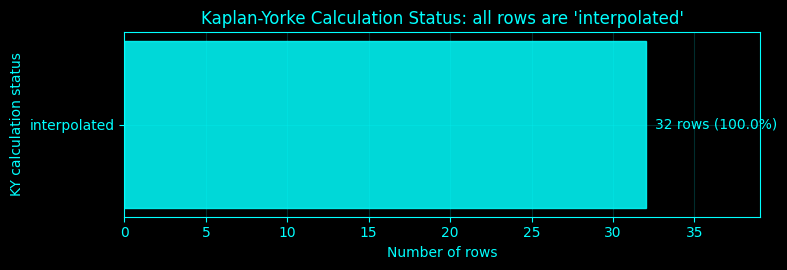

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_dimension_analysis/plots_fixed_full/01_fixed_KY_status_counts_horizontal.png


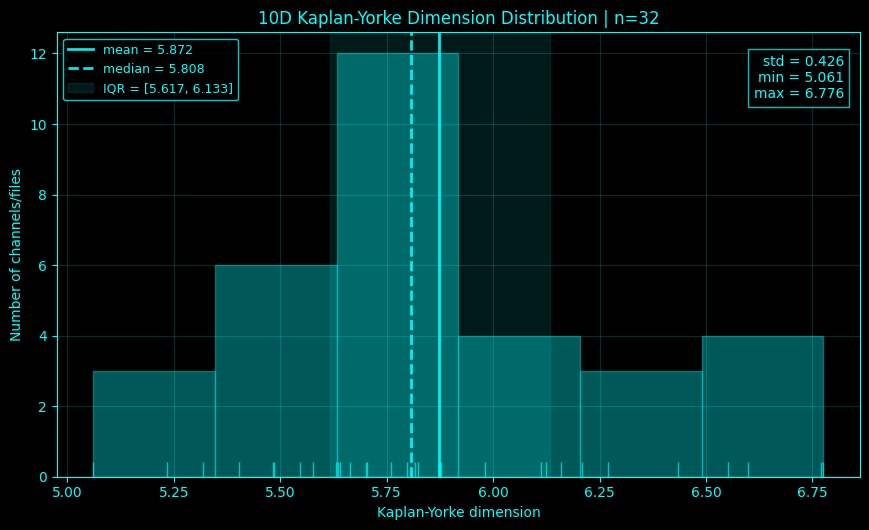

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_dimension_analysis/plots_fixed_full/02_fixed_KY_distribution_single_dimension_histogram.png


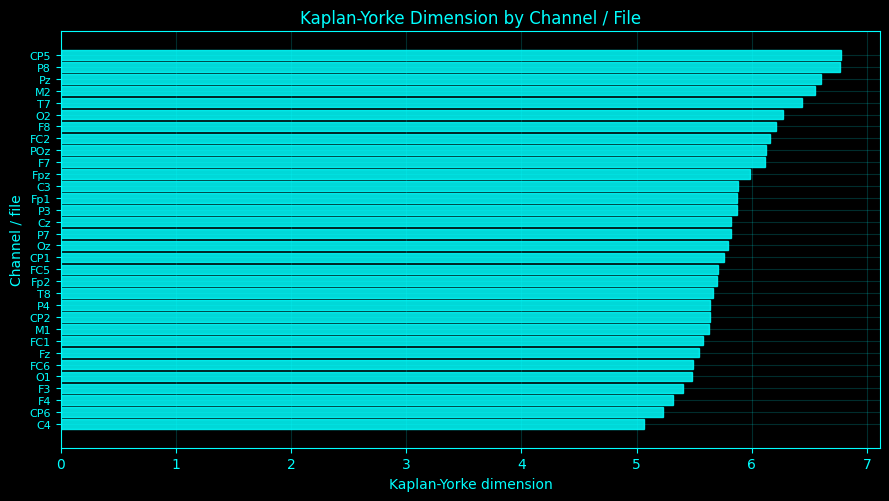

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_dimension_analysis/plots_fixed_full/03_KY_dimension_by_channel_file.png


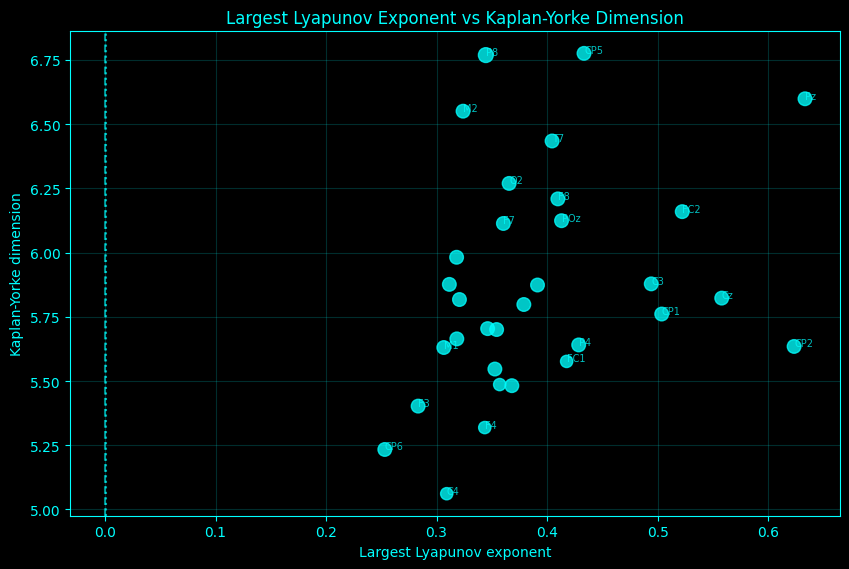

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_dimension_analysis/plots_fixed_full/04_LLE_vs_KY_dimension.png


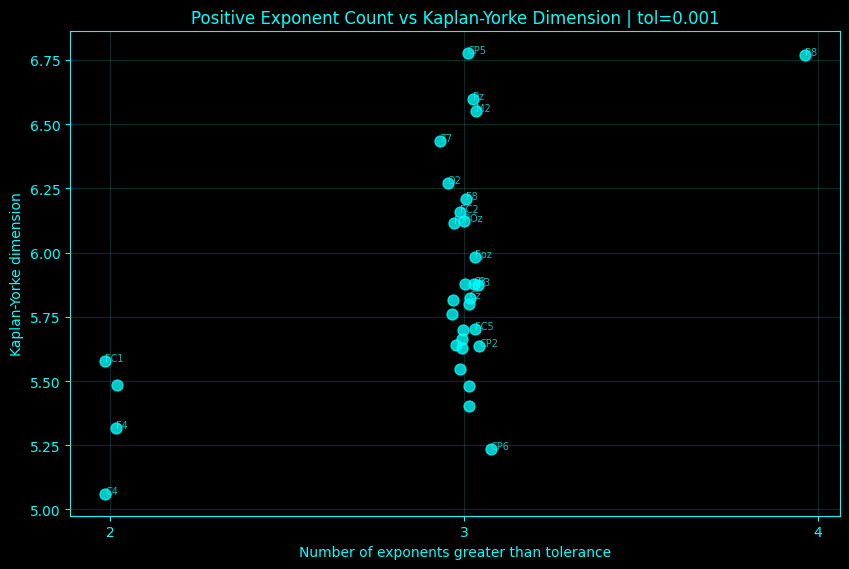

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_dimension_analysis/plots_fixed_full/05_positive_count_vs_KY_dimension.png


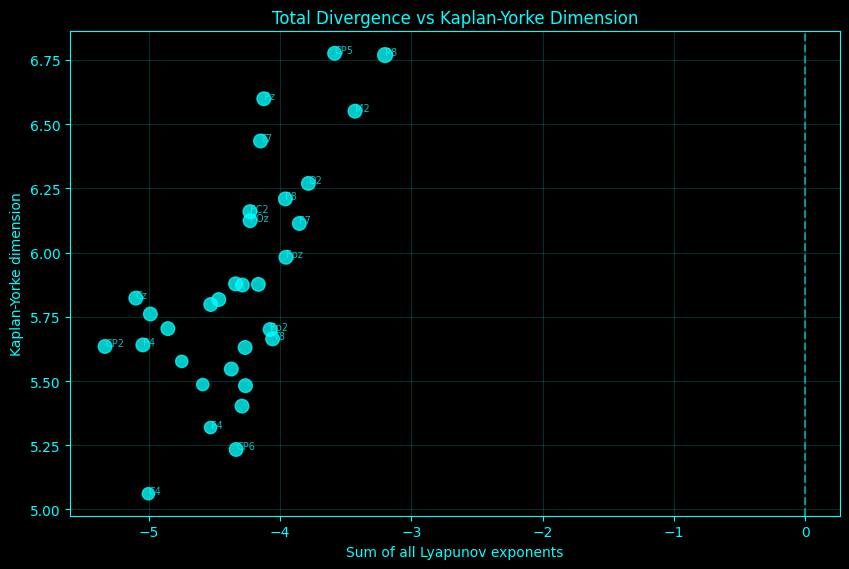

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_dimension_analysis/plots_fixed_full/06_divergence_vs_KY_dimension.png


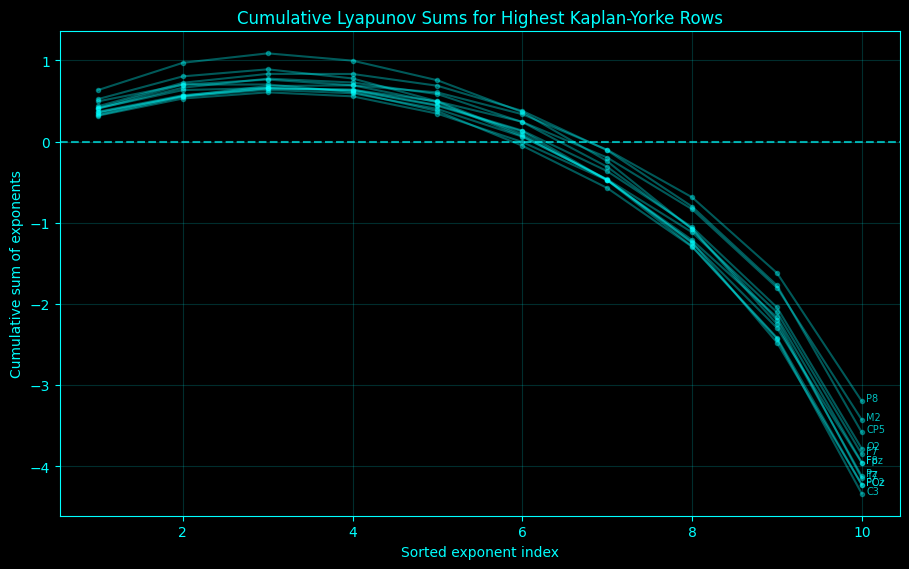

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_dimension_analysis/plots_fixed_full/08_cumulative_sums_top_KY_rows.png

Done.
Input CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/latest_10d_lyapunov_file_analysis/latest_10d_lyapunov_clean_metrics.csv
Metrics CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_dimension_analysis/kaplan_yorke_metrics_20260603_151832.csv
Summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_dimension_analysis/kaplan_yorke_summary_20260603_151832.csv
Cumulative sums CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_dimension_analysis/kaplan_yorke_cumulative_sums_20260603_151832.csv
Plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_dimension_analysis/plots_fixed_full
Available embedding dimensions: [10]
KY status counts:
KY_status
interpolated    32


In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# ============================================================
# COMPLETE KAPLAN-YORKE / LYAPUNOV DIMENSION ANALYSIS BLOCK
# fixed full version with better status + one-dimension plots
# ============================================================

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

# Set manually if needed. Otherwise leave as None.
CSV_PATH = None

search_dirs = [
    os.path.join(base_dir, "results", "lyapunov_custom"),
    os.path.join(base_dir, "lyapunov_results_10D"),
    os.path.join(base_dir, "lyapunov_results_10D_fast"),
    os.path.join(base_dir, "results"),
]

results_dir = os.path.join(base_dir, "results", "kaplan_yorke_dimension_analysis")
plots_dir = os.path.join(results_dir, "plots_fixed_full")

os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")

OUT_METRICS_CSV = os.path.join(results_dir, f"kaplan_yorke_metrics_{run_tag}.csv")
OUT_SUMMARY_CSV = os.path.join(results_dir, f"kaplan_yorke_summary_{run_tag}.csv")
OUT_CUMSUM_CSV = os.path.join(results_dir, f"kaplan_yorke_cumulative_sums_{run_tag}.csv")

POSITIVE_TOL = 1e-3
TOP_N_LABELS = 10
MAX_BAR_LABELS = 40

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=220):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)


def compact_height(n_rows, per_row=0.16, min_h=4.8, max_h=7.2):
    return float(min(max_h, max(min_h, per_row * max(n_rows, 1))))


def set_compact_yticks(ax, labels, max_labels=40, fontsize=8):
    labels = list(labels)
    n = len(labels)

    if n == 0:
        return

    if n <= max_labels:
        ticks = np.arange(n)
        shown = labels
    else:
        step = int(np.ceil(n / max_labels))
        ticks = np.arange(0, n, step)
        shown = [labels[i] for i in ticks]

    ax.set_yticks(ticks)
    ax.set_yticklabels(shown, fontsize=fontsize)


def compact_barh(ax, labels, values, max_labels=40):
    labels = list(labels)
    values = np.asarray(values, dtype=float)
    y = np.arange(len(labels))

    ax.barh(
        y,
        values,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.85
    )

    set_compact_yticks(ax, labels, max_labels=max_labels, fontsize=8)


def csv_has_lyapunov_columns(path):
    try:
        cols = pd.read_csv(path, nrows=0).columns
    except Exception:
        return False

    has_exp = any(re.match(r"^Exp\d+$", c) for c in cols)
    has_sorted = any(re.match(r"^SortedExp\d+$", c) for c in cols)

    return has_exp or has_sorted


def find_latest_usable_lyapunov_csv():
    candidates = []

    for d in search_dirs:
        if not os.path.exists(d):
            continue

        patterns = [
            os.path.join(d, "lyap_spectrum*.csv"),
            os.path.join(d, "**", "lyap_spectrum*.csv"),
            os.path.join(d, "*lyapunov*.csv"),
            os.path.join(d, "**", "*lyapunov*.csv"),
        ]

        for pattern in patterns:
            candidates.extend(glob.glob(pattern, recursive=True))

    bad_tokens = [
        "summary",
        "checkpoint",
        "composite",
        "score",
        "scores",
        "stability",
        "matrix",
        "zscore",
        "outlier",
        "curve",
        "window",
        "d2",
        "correlation",
        "kaplan_yorke",
        "cumulative",
    ]

    usable = []

    for path in sorted(set(candidates)):
        name = os.path.basename(path).lower()

        if any(tok in name for tok in bad_tokens):
            continue

        if csv_has_lyapunov_columns(path):
            usable.append(path)

    usable = sorted(usable, key=lambda p: os.path.getmtime(p), reverse=True)

    if len(usable) == 0:
        raise FileNotFoundError(
            "No usable Lyapunov spectrum CSV found. Expected columns like Exp1, Exp2, ..."
        )

    return usable[0]


def infer_channel_from_stem(stem):
    stem = str(stem)

    if "dembedded_" in stem:
        return stem.split("dembedded_", 1)[1]

    if "_" in stem:
        return stem.split("_")[-1]

    return stem


def infer_embedding_dim(row, exp_cols):
    for col in [
        "embedding_dimension",
        "target_dim",
        "state_dim",
        "inferred_embedding_dim_from_name",
    ]:
        if col in row.index and pd.notna(row[col]):
            try:
                return int(row[col])
            except Exception:
                pass

    for col in ["stem", "file"]:
        if col in row.index:
            text = str(row[col])

            m = re.search(r"(\d+)dembedded_", text)
            if m:
                return int(m.group(1))

            m = re.search(r"lyap_spectrum_(\d+)D", text)
            if m:
                return int(m.group(1))

    vals = pd.to_numeric(row[exp_cols], errors="coerce").to_numpy(dtype=float)
    return int(np.isfinite(vals).sum())


def nan_safe_sort_desc(values, target_len=None):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    finite = np.sort(finite)[::-1]

    if target_len is None:
        target_len = len(values)

    out = np.full(target_len, np.nan, dtype=float)
    n = min(len(finite), target_len)
    out[:n] = finite[:n]

    return out


def kaplan_yorke_dim_full(lams):
    lams = np.asarray(lams, dtype=float)
    lams = lams[np.isfinite(lams)]
    lams = np.sort(lams)[::-1]

    if len(lams) == 0:
        return np.nan, np.nan, np.nan, np.nan, "no_finite_exponents"

    csum = np.cumsum(lams)
    nonnegative = np.where(csum >= 0)[0]

    if len(nonnegative) == 0:
        return 0.0, 0, 0.0, float(lams[0]), "all_contracting_before_first"

    j_idx = int(nonnegative[-1])
    j_count = j_idx + 1
    partial_sum = float(csum[j_idx])

    if j_idx == len(lams) - 1:
        return float(len(lams)), int(len(lams)), partial_sum, np.nan, "full_dimension_noncontracting"

    next_lam = float(lams[j_idx + 1])

    if not np.isfinite(next_lam) or next_lam == 0:
        return float(j_count), int(j_count), partial_sum, next_lam, "zero_next_lambda"

    dky = float(j_count + partial_sum / abs(next_lam))

    return dky, int(j_count), partial_sum, next_lam, "interpolated"


def annotate_extremes(ax, df, x_col, y_col, label_col="channel", top_n=10):
    pieces = []

    for col in [x_col, y_col]:
        finite = df[np.isfinite(df[col])].copy()

        if len(finite) == 0:
            continue

        pieces.append(finite.sort_values(col, ascending=False).head(top_n))
        pieces.append(finite.sort_values(col, ascending=True).head(max(2, top_n // 3)))

    if len(pieces) == 0:
        return

    label_df = pd.concat(pieces).drop_duplicates()

    for _, row in label_df.iterrows():
        if np.isfinite(row[x_col]) and np.isfinite(row[y_col]):
            ax.text(
                row[x_col],
                row[y_col],
                str(row[label_col]),
                color=ACCENT,
                fontsize=7,
                alpha=0.75
            )


if CSV_PATH is None:
    CSV_PATH = find_latest_usable_lyapunov_csv()

print("Loading Lyapunov spectrum CSV:", CSV_PATH, flush=True)

df = pd.read_csv(CSV_PATH)

if "status" in df.columns:
    df_ok = df[df["status"].astype(str).str.lower() == "ok"].copy()
else:
    df_ok = df.copy()
    df_ok["status"] = "ok"

if len(df_ok) == 0:
    raise ValueError("No rows with status == ok found.")

raw_exp_cols = sorted(
    [c for c in df_ok.columns if re.match(r"^Exp\d+$", c)],
    key=lambda s: int(s.replace("Exp", ""))
)

sorted_exp_cols = sorted(
    [c for c in df_ok.columns if re.match(r"^SortedExp\d+$", c)],
    key=lambda s: int(s.replace("SortedExp", ""))
)

if len(raw_exp_cols) > 0:
    exp_cols = raw_exp_cols
elif len(sorted_exp_cols) > 0:
    exp_cols = sorted_exp_cols
else:
    raise ValueError("No exponent columns found. Expected Exp1, Exp2, ...")

print("Using exponent columns:", exp_cols, flush=True)

for c in exp_cols:
    df_ok[c] = pd.to_numeric(df_ok[c], errors="coerce")

E_raw = df_ok[exp_cols].to_numpy(dtype=float)

valid_rows = np.isfinite(E_raw).any(axis=1)
df_ok = df_ok.loc[valid_rows].copy().reset_index(drop=True)
E_raw = E_raw[valid_rows]

if len(df_ok) == 0:
    raise ValueError("No rows with finite Lyapunov exponents.")

E_sorted = np.vstack([
    nan_safe_sort_desc(row, target_len=len(exp_cols))
    for row in E_raw
])

n_exp = E_sorted.shape[1]
sorted_cols = [f"SortedLambda{i + 1}" for i in range(n_exp)]

if "stem" not in df_ok.columns:
    if "file" in df_ok.columns:
        df_ok["stem"] = df_ok["file"].astype(str).str.replace(".npy", "", regex=False)
    else:
        df_ok["stem"] = [f"row_{i}" for i in range(len(df_ok))]

if "channel" not in df_ok.columns:
    df_ok["channel"] = df_ok["stem"].apply(infer_channel_from_stem)

df_ok["embedding_dimension"] = [
    infer_embedding_dim(row, exp_cols)
    for _, row in df_ok.iterrows()
]

df_ok["embedding_dimension"] = pd.to_numeric(
    df_ok["embedding_dimension"],
    errors="coerce"
)

channel_counts = df_ok["channel"].value_counts()

if (channel_counts > 1).any():
    df_ok["plot_label"] = df_ok["channel"].astype(str) + " | " + df_ok["stem"].astype(str)
else:
    df_ok["plot_label"] = df_ok["channel"].astype(str)

records = []
cum_records = []

for idx, row in df_ok.iterrows():
    lams = E_sorted[idx]
    finite_lams = lams[np.isfinite(lams)]

    dky, j_count, partial_sum, next_lambda, ky_status = kaplan_yorke_dim_full(finite_lams)

    csum = np.cumsum(finite_lams)

    for k, val in enumerate(finite_lams, start=1):
        cum_records.append({
            "stem": row["stem"],
            "channel": row["channel"],
            "embedding_dimension": int(row["embedding_dimension"]) if pd.notna(row["embedding_dimension"]) else np.nan,
            "exponent_index": k,
            "lambda_value": float(val),
            "cumulative_sum": float(csum[k - 1]),
            "plot_label": row["plot_label"],
        })

    rec = {
        "stem": row["stem"],
        "channel": row["channel"],
        "plot_label": row["plot_label"],
        "embedding_dimension": int(row["embedding_dimension"]) if pd.notna(row["embedding_dimension"]) else np.nan,
        "finite_exponent_count": int(len(finite_lams)),
        "LLE": float(finite_lams[0]) if len(finite_lams) else np.nan,
        "lambda2": float(finite_lams[1]) if len(finite_lams) >= 2 else np.nan,
        "most_negative": float(finite_lams[-1]) if len(finite_lams) else np.nan,
        "n_positive_strict": int(np.sum(finite_lams > 0.0)),
        "n_positive_tol": int(np.sum(finite_lams > POSITIVE_TOL)),
        "sum_positive_strict": float(np.sum(finite_lams[finite_lams > 0.0])) if len(finite_lams) else np.nan,
        "sum_positive_tol": float(np.sum(finite_lams[finite_lams > POSITIVE_TOL])) if len(finite_lams) else np.nan,
        "divergence_sum": float(np.sum(finite_lams)) if len(finite_lams) else np.nan,
        "spectrum_width": float(finite_lams[0] - finite_lams[-1]) if len(finite_lams) else np.nan,
        "KY_dimension": dky,
        "KY_j_count": j_count,
        "KY_partial_sum_j": partial_sum,
        "KY_next_lambda": next_lambda,
        "KY_status": ky_status,
    }

    for k in range(n_exp):
        rec[f"SortedLambda{k + 1}"] = float(lams[k]) if np.isfinite(lams[k]) else np.nan

    records.append(rec)

metrics = pd.DataFrame(records)
cumsum_df = pd.DataFrame(cum_records)

metrics = metrics[np.isfinite(metrics["KY_dimension"])].copy()

if len(metrics) == 0:
    raise ValueError("No finite Kaplan-Yorke dimensions computed.")

metrics = metrics.sort_values(
    ["embedding_dimension", "KY_dimension"],
    ascending=[True, False]
).reset_index(drop=True)

metrics.to_csv(OUT_METRICS_CSV, index=False)
cumsum_df.to_csv(OUT_CUMSUM_CSV, index=False)

summary_records = []

for dim, sub in metrics.groupby("embedding_dimension", dropna=False):
    summary_records.append({
        "embedding_dimension": dim,
        "n_rows": len(sub),
        "KY_mean": float(sub["KY_dimension"].mean()),
        "KY_median": float(sub["KY_dimension"].median()),
        "KY_std": float(sub["KY_dimension"].std()),
        "KY_min": float(sub["KY_dimension"].min()),
        "KY_max": float(sub["KY_dimension"].max()),
        "LLE_mean": float(sub["LLE"].mean()),
        "LLE_median": float(sub["LLE"].median()),
        "positive_count_mean": float(sub["n_positive_tol"].mean()),
        "divergence_mean": float(sub["divergence_sum"].mean()),
        "fraction_full_dimension": float(np.mean(sub["KY_status"] == "full_dimension_noncontracting")),
    })

summary = pd.DataFrame(summary_records)
summary.to_csv(OUT_SUMMARY_CSV, index=False)

print("\nSaved metrics CSV:", OUT_METRICS_CSV)
print("Saved cumulative sums CSV:", OUT_CUMSUM_CSV)
print("Saved summary CSV:", OUT_SUMMARY_CSV)

print("\nTop rows by Kaplan-Yorke dimension:")
print(
    metrics[
        [
            "channel",
            "stem",
            "embedding_dimension",
            "LLE",
            "n_positive_tol",
            "divergence_sum",
            "KY_dimension",
            "KY_status",
        ]
    ]
    .sort_values("KY_dimension", ascending=False)
    .head(20)
    .to_string(index=False)
)

print("\nSummary by embedding dimension:")
print(summary.to_string(index=False))

available_dims = sorted(metrics["embedding_dimension"].dropna().astype(int).unique())

# ============================================================
# PLOT 1: FIXED KY STATUS COUNTS
# ============================================================

status_counts = metrics["KY_status"].astype(str).value_counts().sort_values()

fig_h = max(2.8, 0.55 * len(status_counts) + 1.8)
fig, ax = plt.subplots(figsize=(8.0, fig_h), facecolor=BG)
style_ax(ax)

y = np.arange(len(status_counts))

ax.barh(
    y,
    status_counts.values,
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.85,
    height=0.48
)

ax.set_yticks(y)
ax.set_yticklabels(status_counts.index)

xmax = max(status_counts.values) * 1.22
ax.set_xlim(0, xmax)

for yi, val in zip(y, status_counts.values):
    pct = 100.0 * val / len(metrics)
    ax.text(
        val + xmax * 0.015,
        yi,
        f"{val} rows ({pct:.1f}%)",
        va="center",
        ha="left",
        color=ACCENT,
        fontsize=10
    )

if len(status_counts) == 1:
    only_status = status_counts.index[0]
    ax.set_title(f"Kaplan-Yorke Calculation Status: all rows are '{only_status}'")
else:
    ax.set_title("Kaplan-Yorke Calculation Status Counts")

ax.set_xlabel("Number of rows")
ax.set_ylabel("KY calculation status")

plot_path = os.path.join(plots_dir, "01_fixed_KY_status_counts_horizontal.png")
save_show_close(fig, plot_path)

# ============================================================
# PLOT 2: FIXED KY DISTRIBUTION
# If only one embedding dimension exists, use histogram/rug instead of a useless boxplot.
# ============================================================

if len(available_dims) == 1:
    dim = available_dims[0]

    vals = metrics.loc[
        metrics["embedding_dimension"].astype(int) == dim,
        "KY_dimension"
    ].dropna().to_numpy(dtype=float)

    mean_val = float(np.nanmean(vals))
    median_val = float(np.nanmedian(vals))
    std_val = float(np.nanstd(vals))
    q25, q75 = np.nanpercentile(vals, [25, 75])
    vmin = float(np.nanmin(vals))
    vmax = float(np.nanmax(vals))

    fig, ax = plt.subplots(figsize=(8.8, 5.4), facecolor=BG)
    style_ax(ax)

    bins = min(14, max(6, int(np.sqrt(len(vals)))))

    ax.hist(
        vals,
        bins=bins,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.35
    )

    ymin, ymax = ax.get_ylim()
    rug_y = ymin + 0.015 * (ymax - ymin)

    ax.plot(
        vals,
        np.full_like(vals, rug_y),
        "|",
        color=ACCENT,
        markersize=12,
        alpha=0.65
    )

    ax.axvline(mean_val, color=ACCENT, linestyle="-", linewidth=2.0, alpha=0.9, label=f"mean = {mean_val:.3f}")
    ax.axvline(median_val, color=ACCENT, linestyle="--", linewidth=2.0, alpha=0.9, label=f"median = {median_val:.3f}")
    ax.axvspan(q25, q75, color=ACCENT, alpha=0.10, label=f"IQR = [{q25:.3f}, {q75:.3f}]")

    ax.set_title(f"{dim}D Kaplan-Yorke Dimension Distribution | n={len(vals)}")
    ax.set_xlabel("Kaplan-Yorke dimension")
    ax.set_ylabel("Number of channels/files")

    text = (
        f"std = {std_val:.3f}\n"
        f"min = {vmin:.3f}\n"
        f"max = {vmax:.3f}"
    )

    ax.text(
        0.98,
        0.95,
        text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        color=ACCENT,
        fontsize=10,
        bbox=dict(facecolor=BG, edgecolor=ACCENT, alpha=0.75)
    )

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=9)
    for t in leg.get_texts():
        t.set_color(ACCENT)

    plot_path = os.path.join(plots_dir, "02_fixed_KY_distribution_single_dimension_histogram.png")
    save_show_close(fig, plot_path)

else:
    box_data = [
        metrics.loc[
            metrics["embedding_dimension"].astype(int) == dim,
            "KY_dimension"
        ].dropna().to_numpy(dtype=float)
        for dim in available_dims
    ]

    fig, ax = plt.subplots(figsize=(9.4, 5.8), facecolor=BG)
    style_ax(ax)

    bp = ax.boxplot(
        box_data,
        positions=np.arange(len(available_dims)),
        widths=0.55,
        patch_artist=True,
        showfliers=False
    )

    for box in bp["boxes"]:
        box.set(facecolor=BG, edgecolor=ACCENT, linewidth=1.5)
    for whisker in bp["whiskers"]:
        whisker.set(color=ACCENT, linewidth=1.2)
    for cap in bp["caps"]:
        cap.set(color=ACCENT, linewidth=1.2)
    for median in bp["medians"]:
        median.set(color=ACCENT, linewidth=2.2)

    rng = np.random.default_rng(42)

    for i, vals in enumerate(box_data):
        if len(vals) == 0:
            continue

        jitter = rng.normal(0, 0.055, size=len(vals))

        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            color=ACCENT,
            alpha=0.25,
            s=18,
            edgecolor="none"
        )

    medians = [np.nanmedian(v) if len(v) else np.nan for v in box_data]

    ax.plot(
        np.arange(len(available_dims)),
        medians,
        color=ACCENT,
        linewidth=2.0,
        marker="o",
        alpha=0.9,
        label="median trend"
    )

    ax.set_xticks(np.arange(len(available_dims)))
    ax.set_xticklabels([str(d) for d in available_dims])

    ax.set_title("Kaplan-Yorke Dimension Distribution by Embedding Dimension")
    ax.set_xlabel("Embedding dimension")
    ax.set_ylabel("Kaplan-Yorke dimension")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=9)
    for t in leg.get_texts():
        t.set_color(ACCENT)

    plot_path = os.path.join(plots_dir, "02_fixed_KY_distribution_by_embedding_dimension.png")
    save_show_close(fig, plot_path)

# ============================================================
# PLOT 3: KY DIMENSION BY CHANNEL / FILE
# ============================================================

plot_df = metrics.sort_values("KY_dimension", ascending=True)

fig, ax = plt.subplots(
    figsize=(9.0, compact_height(len(plot_df))),
    facecolor=BG
)
style_ax(ax)

compact_barh(
    ax,
    plot_df["plot_label"],
    plot_df["KY_dimension"],
    max_labels=MAX_BAR_LABELS
)

ax.set_title("Kaplan-Yorke Dimension by Channel / File")
ax.set_xlabel("Kaplan-Yorke dimension")
ax.set_ylabel("Channel / file")

plot_path = os.path.join(plots_dir, "03_KY_dimension_by_channel_file.png")
save_show_close(fig, plot_path)

# ============================================================
# PLOT 4: LLE VS KY DIMENSION
# ============================================================

fig, ax = plt.subplots(figsize=(8.6, 5.8), facecolor=BG)
style_ax(ax)

sizes = 42 + 18 * metrics["n_positive_tol"].to_numpy(dtype=float)

ax.scatter(
    metrics["LLE"],
    metrics["KY_dimension"],
    color=ACCENT,
    edgecolor=ACCENT,
    s=sizes,
    alpha=0.78
)

annotate_extremes(
    ax,
    metrics,
    x_col="LLE",
    y_col="KY_dimension",
    label_col="channel",
    top_n=TOP_N_LABELS
)

ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.55)
ax.axvline(POSITIVE_TOL, color=ACCENT, linestyle=":", alpha=0.65)

ax.set_title("Largest Lyapunov Exponent vs Kaplan-Yorke Dimension")
ax.set_xlabel("Largest Lyapunov exponent")
ax.set_ylabel("Kaplan-Yorke dimension")

plot_path = os.path.join(plots_dir, "04_LLE_vs_KY_dimension.png")
save_show_close(fig, plot_path)

# ============================================================
# PLOT 5: POSITIVE COUNT VS KY DIMENSION
# ============================================================

fig, ax = plt.subplots(figsize=(8.6, 5.8), facecolor=BG)
style_ax(ax)

rng = np.random.default_rng(42)
x_jitter = metrics["n_positive_tol"].to_numpy(dtype=float) + rng.normal(0, 0.035, size=len(metrics))

ax.scatter(
    x_jitter,
    metrics["KY_dimension"],
    color=ACCENT,
    edgecolor=ACCENT,
    s=62,
    alpha=0.78
)

tmp = metrics.copy()
tmp["n_positive_jitter"] = x_jitter

annotate_extremes(
    ax,
    tmp,
    x_col="n_positive_jitter",
    y_col="KY_dimension",
    label_col="channel",
    top_n=TOP_N_LABELS
)

ax.set_xticks(sorted(metrics["n_positive_tol"].dropna().astype(int).unique()))

ax.set_title(f"Positive Exponent Count vs Kaplan-Yorke Dimension | tol={POSITIVE_TOL:g}")
ax.set_xlabel("Number of exponents greater than tolerance")
ax.set_ylabel("Kaplan-Yorke dimension")

plot_path = os.path.join(plots_dir, "05_positive_count_vs_KY_dimension.png")
save_show_close(fig, plot_path)

# ============================================================
# PLOT 6: DIVERGENCE VS KY DIMENSION
# ============================================================

fig, ax = plt.subplots(figsize=(8.6, 5.8), facecolor=BG)
style_ax(ax)

ax.scatter(
    metrics["divergence_sum"],
    metrics["KY_dimension"],
    color=ACCENT,
    edgecolor=ACCENT,
    s=sizes,
    alpha=0.78
)

annotate_extremes(
    ax,
    metrics,
    x_col="divergence_sum",
    y_col="KY_dimension",
    label_col="channel",
    top_n=TOP_N_LABELS
)

ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.55)

ax.set_title("Total Divergence vs Kaplan-Yorke Dimension")
ax.set_xlabel("Sum of all Lyapunov exponents")
ax.set_ylabel("Kaplan-Yorke dimension")

plot_path = os.path.join(plots_dir, "06_divergence_vs_KY_dimension.png")
save_show_close(fig, plot_path)

# ============================================================
# PLOT 7: CHANNEL × DIMENSION KY HEATMAP
# only useful if multiple embedding dimensions exist
# ============================================================

if len(available_dims) > 1:
    pivot = metrics.pivot_table(
        index="channel",
        columns="embedding_dimension",
        values="KY_dimension",
        aggfunc="mean"
    )

    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

    fig, ax = plt.subplots(
        figsize=(9.2, compact_height(len(pivot), per_row=0.13)),
        facecolor=BG
    )
    style_ax(ax)

    im = ax.imshow(
        pivot.to_numpy(dtype=float),
        aspect="auto",
        origin="lower",
        interpolation="nearest"
    )

    ax.set_title("Channel × Embedding Dimension Kaplan-Yorke Map")
    ax.set_xlabel("Embedding dimension")
    ax.set_ylabel("Channel")

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([str(int(c)) for c in pivot.columns])

    set_compact_yticks(ax, pivot.index.values, max_labels=MAX_BAR_LABELS, fontsize=8)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Kaplan-Yorke dimension")
    style_colorbar(cbar)

    plot_path = os.path.join(plots_dir, "07_channel_by_dimension_KY_heatmap.png")
    save_show_close(fig, plot_path)

# ============================================================
# PLOT 8: CUMULATIVE LYAPUNOV SUMS FOR HIGHEST KY ROWS
# ============================================================

top_labels = (
    metrics
    .sort_values("KY_dimension", ascending=False)
    .head(12)["plot_label"]
    .tolist()
)

fig, ax = plt.subplots(figsize=(9.2, 5.8), facecolor=BG)
style_ax(ax)

for label in top_labels:
    sub = cumsum_df[cumsum_df["plot_label"] == label].sort_values("exponent_index")

    if len(sub) == 0:
        continue

    ax.plot(
        sub["exponent_index"],
        sub["cumulative_sum"],
        color=ACCENT,
        alpha=0.35,
        linewidth=1.5,
        marker="o",
        markersize=3
    )

    ax.text(
        sub["exponent_index"].iloc[-1] + 0.05,
        sub["cumulative_sum"].iloc[-1],
        label.split(" | ")[0],
        color=ACCENT,
        fontsize=7,
        alpha=0.75
    )

ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.65)

ax.set_title("Cumulative Lyapunov Sums for Highest Kaplan-Yorke Rows")
ax.set_xlabel("Sorted exponent index")
ax.set_ylabel("Cumulative sum of exponents")

plot_path = os.path.join(plots_dir, "08_cumulative_sums_top_KY_rows.png")
save_show_close(fig, plot_path)

print("\nDone.")
print("Input CSV:", CSV_PATH)
print("Metrics CSV:", OUT_METRICS_CSV)
print("Summary CSV:", OUT_SUMMARY_CSV)
print("Cumulative sums CSV:", OUT_CUMSUM_CSV)
print("Plots saved to:", plots_dir)
print("Available embedding dimensions:", available_dims)
print("KY status counts:")
print(status_counts.to_string())

### Lyapunov spectrum estimation

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This block provides a diagnostics-only workflow for testing the robustness of the custom Lyapunov-spectrum estimates already computed elsewhere in the project. It deliberately avoids <code>nolds</code> and does not repeat the main Lyapunov/Kaplan–Yorke summary analysis. Instead, it focuses on new checks that were not covered by the previous code blocks: parameter sensitivity, time-window/bootstrap stability, local QR stretch behavior, and embedded-trajectory coordinate quality control.</p>
        <p>The code reads precomputed embedding files from <code>embedding_data/embeddings_4to10</code>, such as <code>10dembedded_C3.npy</code>, and uses the embedded trajectory directly. It then applies a custom local-linear Jacobian estimator with QR accumulation to recompute spectra only for robustness diagnostics, not as a replacement for the main saved Lyapunov-spectrum pipeline.</p>
        <h2>Why This Block Exists</h2>
        <p>Earlier blocks already computed the full Lyapunov spectra, Kaplan–Yorke dimension, number of positive exponents, exponent sums, divergence metrics, channel heatmaps, and stability-style summaries. This block is therefore narrowed to answer a different question:</p>
        <p><b>Are the Lyapunov results stable under reasonable changes in estimator settings, data window, and local QR behavior?</b></p>
        <p>This makes the block a validation and sensitivity layer rather than another primary Lyapunov-analysis block.</p>
        <h2>Mathematical Foundations</h2>
        <p>The estimator uses local linearization of the reconstructed trajectory. For each selected trajectory point, nearby neighbors are used to fit a local map:</p>
        \[
            X_{t+1} - X_{i+1} \approx J_i (X_t - X_i)
        \]
        <p>where <code>J_i</code> is the locally estimated Jacobian. The estimated Jacobians are accumulated through QR decomposition:</p>
        \[
            J_i Q_{i-1} = Q_i R_i
        \]
        <p>The diagonal entries of <code>R_i</code> provide local stretching/contraction factors. Accumulating their logarithms gives the Lyapunov exponents:</p>
        \[
            \lambda_k \approx \frac{1}{T}\sum_i \log |R_i(k,k)|
        \]
        <p>This is the same custom local-linear QR logic used in the main Lyapunov work, but here it is used specifically to probe sensitivity and diagnostic behavior.</p>
        <h2>Input Assumptions</h2>
        <p>The script expects embedded trajectory files named like:</p>
        <pre><code>10dembedded_C3.npy</code></pre>
        <p>inside:</p>
        <pre><code>/home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/embeddings_4to10</code></pre>
        <p>Each file is assumed to contain a 2D embedded trajectory of shape <code>(N, D)</code>. The block uses the first <code>STATE_DIM</code> columns, filters non-finite rows, optionally standardizes each coordinate, and optionally subsamples rows for speed.</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>The updated workflow is:</p>
        <ol>
            <li><b>Discover</b> the requested embedded-channel files, such as <code>10dembedded_C3.npy</code>.</li>
            <li><b>Load</b> the embedded trajectory directly instead of extracting a scalar observable.</li>
            <li><b>Standardize</b> the trajectory coordinates if enabled.</li>
            <li><b>Run parameter sensitivity scans</b> over <code>K_NEIGHBORS</code>, <code>STRIDE</code>, and <code>MAX_POINTS</code>.</li>
            <li><b>Run window/bootstrap stability checks</b> by recomputing spectra on different temporal segments.</li>
            <li><b>Run local QR stretch diagnostics</b> to inspect local expansion/contraction along the trajectory.</li>
            <li><b>Generate trajectory-coordinate QC plots</b> showing the embedded coordinates actually used.</li>
            <li><b>Save</b> diagnostic CSVs and plots to a timestamped results folder.</li>
        </ol>
        <h2>Important Change from the Old Version</h2>
        <p>The previous version used:</p>
        <pre><code>from nolds.measures import lyap_e</code></pre>
        <p>and then passed the first embedding coordinate into <code>lyap_e</code> as a scalar observable. That has been removed. The updated version uses no <code>nolds</code> dependency and works directly on the multivariate embedded trajectory.</p>
        <h2>New Diagnostics Added</h2>
        <h3>1. Parameter Sensitivity</h3>
        <p>The code recomputes Lyapunov spectra across combinations of:</p>
        <ul>
            <li><code>K_NEIGHBORS</code>: number of neighbors used in local Jacobian fitting,</li>
            <li><code>STRIDE</code>: spacing between QR accumulation steps,</li>
            <li><code>MAX_POINTS</code>: maximum number of trajectory rows used.</li>
        </ul>
        <p>This helps determine whether the largest Lyapunov exponent and related diagnostics are stable or highly parameter-dependent.</p>
        <h3>2. Window Bootstrap Stability</h3>
        <p>The code selects several temporal windows from the embedded trajectory and recomputes the spectrum for each segment. This checks whether the estimated dynamics are consistent over time or whether they depend strongly on the chosen data window.</p>
        <h3>3. Local QR Stretch Diagnostics</h3>
        <p>For each usable QR step, the code saves local stretch summaries such as:</p>
        <ul>
            <li><code>mean_log_stretch</code>,</li>
            <li><code>max_log_stretch</code>,</li>
            <li><code>min_log_stretch</code>,</li>
            <li><code>local_trace_log</code>.</li>
        </ul>
        <p>These reveal whether the spectrum is being driven by isolated bursts, smooth local expansion, or persistent contraction.</p>
        <h3>4. Embedded-Trajectory QC</h3>
        <p>The trajectory QC portion saves coordinate-level summary statistics and plots the first few embedded coordinates with offsets. This verifies that the data being passed into the diagnostic estimator look reasonable and are not flat, corrupted, or dominated by obvious artifacts.</p>
        <h2>Saved Output Structure</h2>
        <p>The updated block writes several diagnostic files into:</p>
        <pre><code>results/custom_lyapunov_new_diagnostics_only</code></pre>
        <p>including:</p>
        <ul>
            <li><b><code>parameter_sensitivity_scan_*.csv</code></b>: results from changing neighbors, stride, and point count.</li>
            <li><b><code>window_bootstrap_stability_*.csv</code></b>: spectra and summary metrics from different temporal windows.</li>
            <li><b><code>local_qr_stretch_diagnostics_*.csv</code></b>: per-step local QR stretch diagnostics.</li>
            <li><b><code>local_qr_stretch_summary_*.csv</code></b>: channel-level QR diagnostic summary.</li>
            <li><b><code>trajectory_coordinate_qc_*.csv</code></b>: coordinate-level QC statistics.</li>
            <li><b><code>plots/</code></b>: black-background cyan-styled diagnostic figures.</li>
        </ul>
        <h2>Practical Interpretation</h2>
        <p>This block should be used after the main Lyapunov analysis has already been run. Its purpose is not to produce another final spectrum table, but to answer whether the previous Lyapunov results appear robust. Stable results should show similar LLE and dimension estimates across parameter settings, reasonable agreement across bootstrap windows, and QR stretch diagnostics that are not dominated by a few extreme local events.</p>
        <h2>Reproducibility Tip</h2>
        <p>Because each diagnostic output is timestamped and saved separately, the sensitivity results can be compared against the existing baseline Lyapunov CSVs without overwriting the main analysis products. This keeps the validation layer auditable while avoiding repetition of the already-completed summary analyses.</p>
    </div>
</div>

Using KDTree: True
Channels to run: ['C3']
Loaded existing baseline markers from: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D_fast/lyap_spectrum_10D_FAST_20260603_145229.csv

Running parameter sensitivity scan only...
scan ok | C3 | N=6000 k=15 stride=10 | LLE=0.80209 DKY=8.5611 | 0.1s
scan ok | C3 | N=6000 k=15 stride=20 | LLE=0.8315 DKY=8.5763 | 0.0s
scan ok | C3 | N=6000 k=15 stride=40 | LLE=0.80701 DKY=8.5313 | 0.0s
scan ok | C3 | N=6000 k=20 stride=10 | LLE=0.50858 DKY=6.6877 | 0.1s
scan ok | C3 | N=6000 k=20 stride=20 | LLE=0.51982 DKY=6.7665 | 0.0s
scan ok | C3 | N=6000 k=20 stride=40 | LLE=0.51369 DKY=6.6967 | 0.0s
scan ok | C3 | N=6000 k=25 stride=10 | LLE=0.38619 DKY=5.2795 | 0.1s
scan ok | C3 | N=6000 k=25 stride=20 | LLE=0.36175 DKY=5.462 | 0.0s
scan ok | C3 | N=6000 k=25 stride=40 | LLE=0.41975 DKY=5.36 | 0.0s
scan ok | C3 | N=6000 k=35 stride=10 | LLE=0.17945 DKY=3.3899 | 0.1s
scan ok | C3 | N=6000 k=35 stride=20 | LLE=0.18584 DKY=3.7037 | 0.0s
s

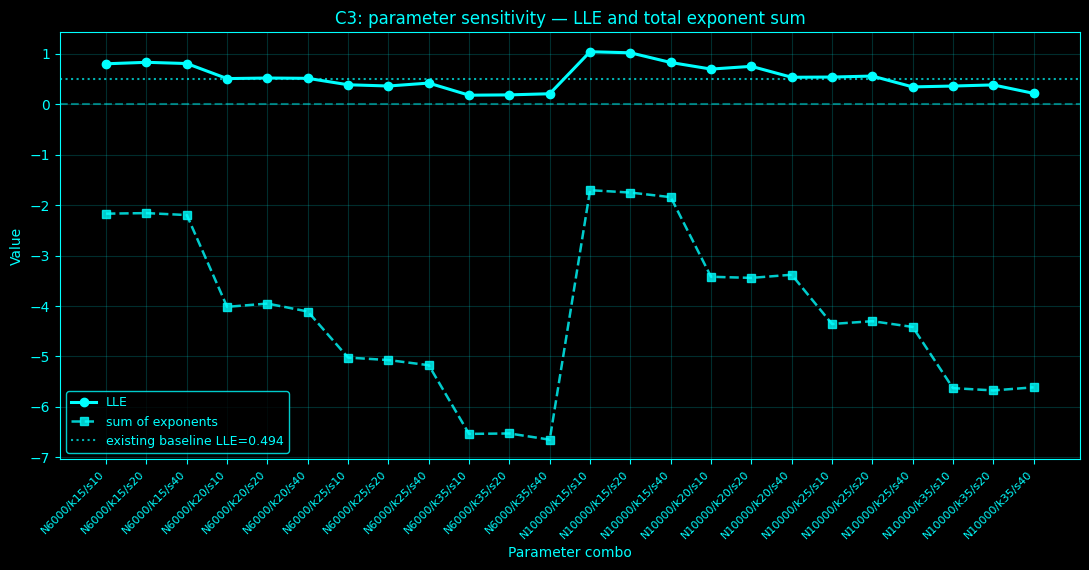

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/custom_lyapunov_new_diagnostics_only/plots/01_C3_parameter_sensitivity_LLE_sum.png


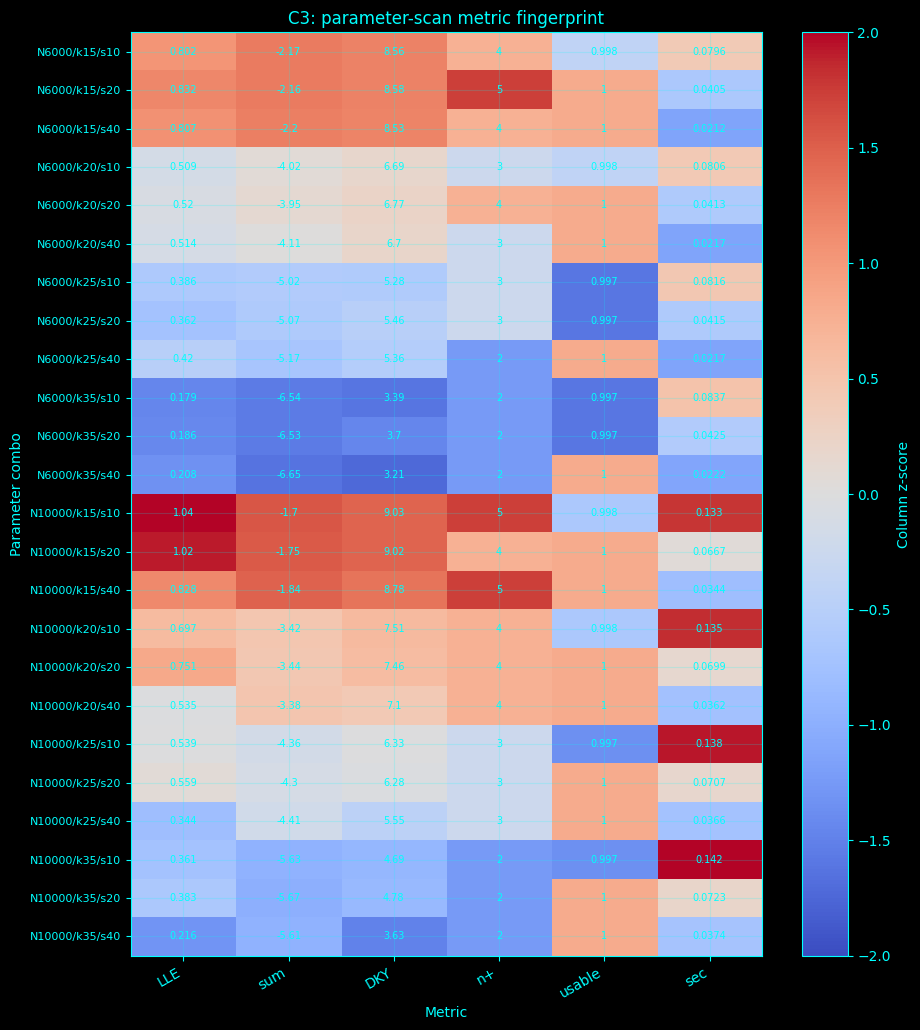

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/custom_lyapunov_new_diagnostics_only/plots/02_C3_parameter_metric_fingerprint.png


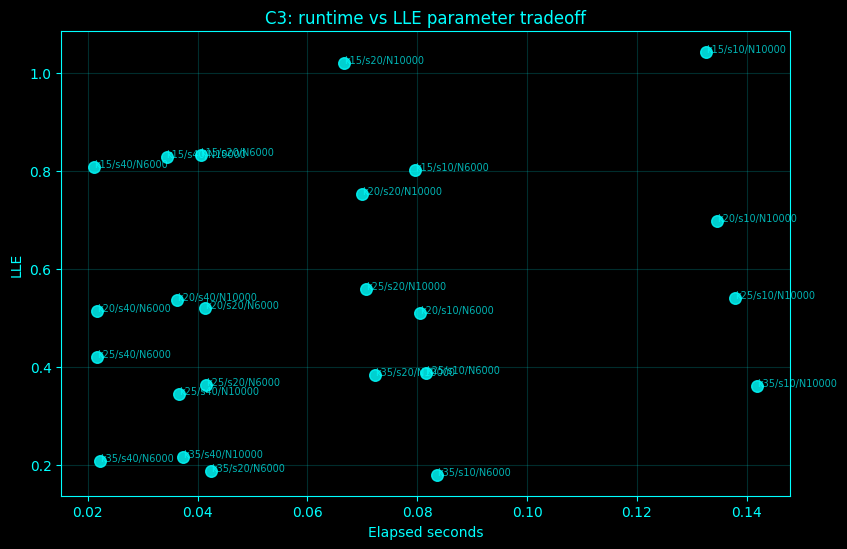

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/custom_lyapunov_new_diagnostics_only/plots/03_C3_runtime_vs_LLE_tradeoff.png


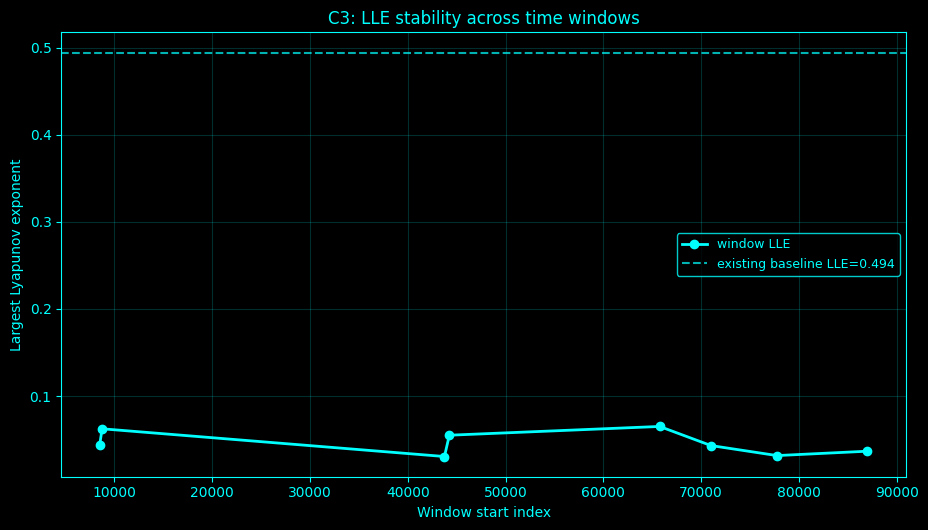

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/custom_lyapunov_new_diagnostics_only/plots/04_C3_window_bootstrap_LLE_timeline.png


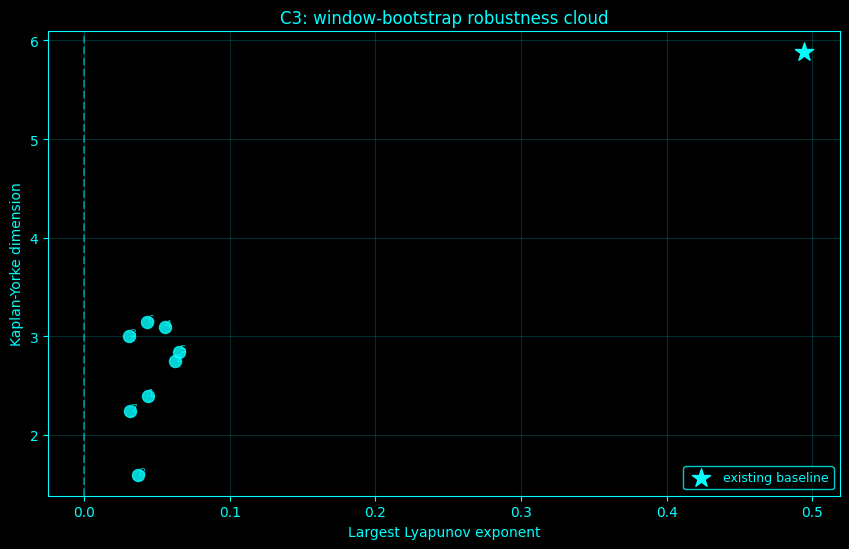

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/custom_lyapunov_new_diagnostics_only/plots/05_C3_bootstrap_LLE_vs_DKY_cloud.png


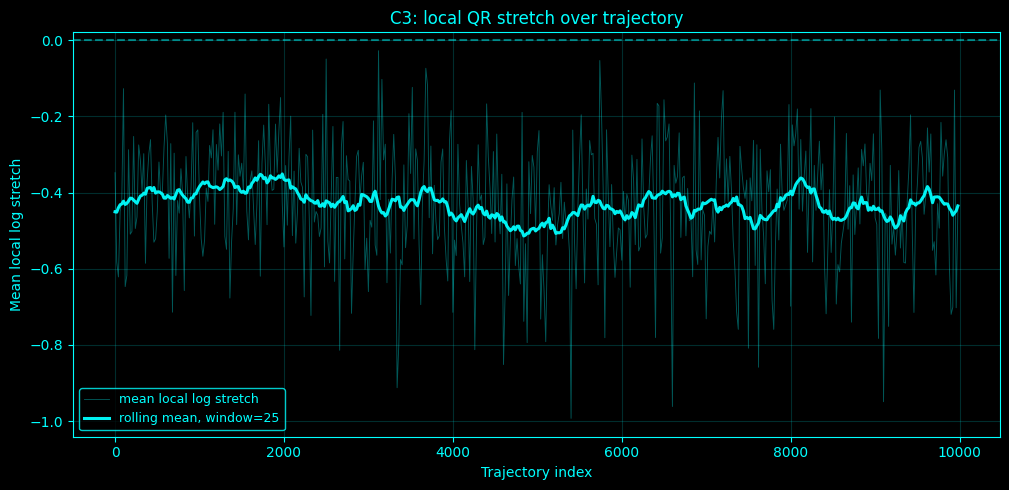

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/custom_lyapunov_new_diagnostics_only/plots/06_C3_local_QR_mean_stretch_timeline.png


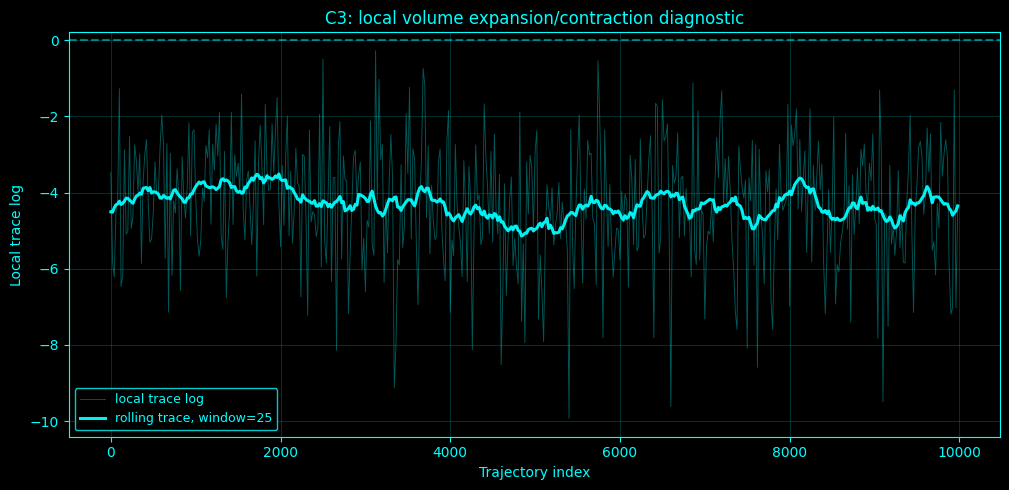

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/custom_lyapunov_new_diagnostics_only/plots/07_C3_local_QR_trace_timeline.png


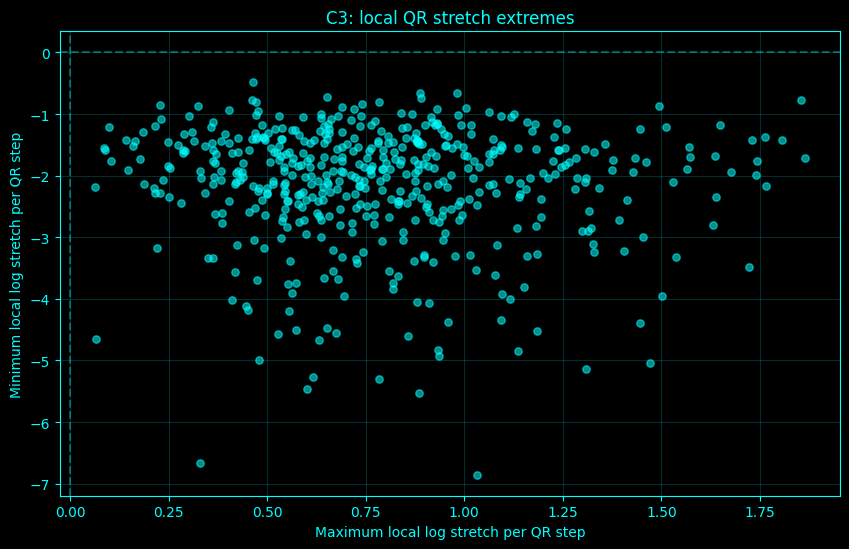

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/custom_lyapunov_new_diagnostics_only/plots/08_C3_local_QR_stretch_extremes.png


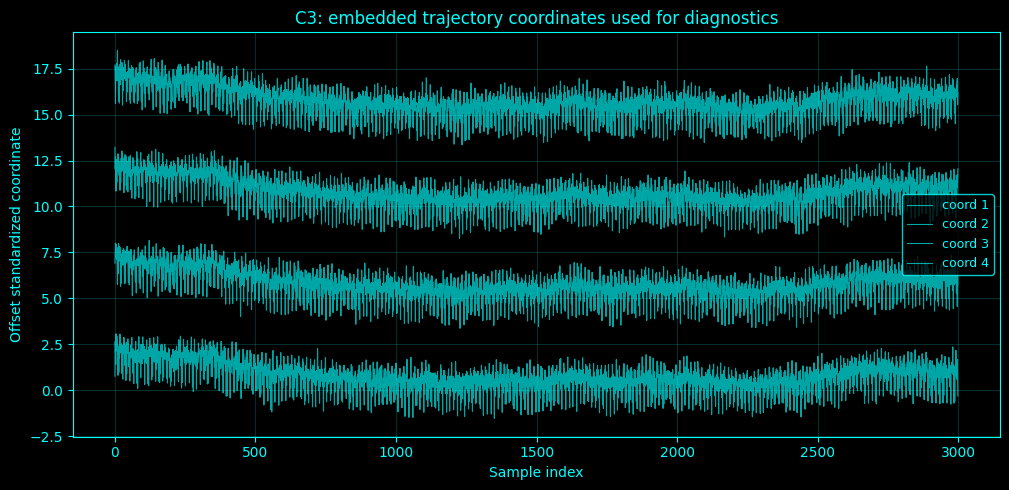

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/custom_lyapunov_new_diagnostics_only/plots/09_C3_embedded_trajectory_coordinate_QC.png

Done.
Parameter sensitivity CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/custom_lyapunov_new_diagnostics_only/parameter_sensitivity_scan_20260603_152605.csv
Window bootstrap CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/custom_lyapunov_new_diagnostics_only/window_bootstrap_stability_20260603_152605.csv
Local QR diagnostic CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/custom_lyapunov_new_diagnostics_only/local_qr_stretch_diagnostics_20260603_152605.csv
Local QR summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/custom_lyapunov_new_diagnostics_only/local_qr_stretch_summary_20260603_152605.csv
Trajectory QC CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/custom_lyapunov_new_diagnostics_only/trajectory_coordinate_qc_20260603_152605.csv
Plots saved to: /home/a/

In [1]:
import os
import re
import glob
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

warnings.filterwarnings("ignore", category=RuntimeWarning)

try:
    from scipy.spatial import cKDTree as KDTree
    HAVE_KDTREE = True
except Exception:
    KDTree = None
    HAVE_KDTREE = False

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
emb_dir = os.path.join(base_dir, "embedding_data", "embeddings_4to10")

results_dir = os.path.join(base_dir, "results", "custom_lyapunov_new_diagnostics_only")
plots_dir = os.path.join(results_dir, "plots")

os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

OUT_PARAM_SCAN_CSV = os.path.join(results_dir, f"parameter_sensitivity_scan_{timestamp}.csv")
OUT_BOOTSTRAP_CSV = os.path.join(results_dir, f"window_bootstrap_stability_{timestamp}.csv")
OUT_QR_DIAG_CSV = os.path.join(results_dir, f"local_qr_stretch_diagnostics_{timestamp}.csv")
OUT_QR_SUMMARY_CSV = os.path.join(results_dir, f"local_qr_stretch_summary_{timestamp}.csv")
OUT_TRAJ_QC_CSV = os.path.join(results_dir, f"trajectory_coordinate_qc_{timestamp}.csv")

# ============================================================
# CONFIG
# ============================================================

CHANNELS = ["C3"]
# CHANNELS = None  # uncomment to run all available 10D channels

EMB_DIM = 10
STATE_DIM = 10

THEILER = 10
DT = 1.0

STANDARDIZE_TRAJECTORY = True

# Parameter sensitivity scan.
RUN_PARAMETER_SCAN = True
SCAN_K_NEIGHBORS = [15, 20, 25, 35]
SCAN_STRIDES = [10, 20, 40]
SCAN_MAX_POINTS = [6000, 10000]

# Bootstrap / segment stability.
RUN_WINDOW_BOOTSTRAP = True
N_BOOT_WINDOWS = 8
BOOT_WINDOW_POINTS = 5000
BOOT_K_NEIGHBORS = 25
BOOT_STRIDE = 20
MIN_BOOT_START_GAP = 250

# Local QR stretch diagnostic.
RUN_LOCAL_QR_DIAG = True
QR_DIAG_MAX_POINTS = 10000
QR_DIAG_K_NEIGHBORS = 25
QR_DIAG_STRIDE = 20
QR_ROLLING_WINDOW = 25

# Trajectory-coordinate QC.
RUN_TRAJECTORY_QC = True
TRAJ_QC_MAX_POINTS = 10000
TRAJ_QC_SHOW_POINTS = 3000
TRAJ_QC_DIMS_TO_SHOW = 4

# Optional baseline markers loaded from your existing saved Lyapunov CSVs.
LOAD_EXISTING_BASELINE = True

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=220):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)


def infer_channel_from_path(path):
    stem = os.path.splitext(os.path.basename(path))[0]

    m = re.match(r"^(\d+)dembedded_(.+)$", stem)
    if m:
        return m.group(2)

    if "_" in stem:
        return stem.split("_")[-1]

    return stem


def infer_channel_from_stem(stem):
    stem = str(stem)

    if "dembedded_" in stem:
        return stem.split("dembedded_", 1)[1]

    if "_" in stem:
        return stem.split("_")[-1]

    return stem


def find_embedding_file(channel, emb_dim):
    fname = f"{emb_dim}dembedded_{channel}.npy"
    direct = os.path.join(emb_dir, fname)

    if os.path.exists(direct):
        return direct

    matches = glob.glob(os.path.join(emb_dir, "**", fname), recursive=True)

    if len(matches) > 0:
        return matches[0]

    return None


def discover_channels_for_emb_dim(emb_dim):
    pattern = os.path.join(emb_dir, "**", f"{emb_dim}dembedded_*.npy")
    files = sorted(glob.glob(pattern, recursive=True))
    channels = [infer_channel_from_path(fp) for fp in files]
    return channels, files


def standardize_X(X):
    X = np.asarray(X, dtype=float)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    sd[sd == 0] = 1.0
    return (X - mu) / (sd + 1e-12)


def uniform_subsample_rows(X, max_points):
    X = np.asarray(X, dtype=float)

    if max_points is None or X.shape[0] <= max_points:
        return X

    idx = np.linspace(0, X.shape[0] - 1, max_points).astype(int)
    return X[idx]


def load_embedding_trajectory(path, state_dim=10, max_points=None, standardize=True):
    X = np.load(path, allow_pickle=True)
    X = np.asarray(X, dtype=float)
    X = np.squeeze(X)

    if X.ndim != 2:
        raise ValueError(f"Expected 2D embedded trajectory, got shape {X.shape}")

    if X.shape[1] < state_dim:
        raise ValueError(f"Trajectory has only {X.shape[1]} columns, requested state_dim={state_dim}")

    X = X[:, :state_dim]

    finite_rows = np.all(np.isfinite(X), axis=1)
    X = X[finite_rows]

    X = uniform_subsample_rows(X, max_points=max_points)

    if standardize:
        X = standardize_X(X)

    return X


def kaplan_yorke_dim(lams):
    lams = np.asarray(lams, dtype=float)
    lams = lams[np.isfinite(lams)]
    lams = np.sort(lams)[::-1]

    if len(lams) == 0:
        return np.nan

    s = 0.0

    for j in range(len(lams)):
        s_next = s + lams[j]

        if s_next < 0:
            if abs(lams[j]) < 1e-15:
                return float(j)
            return float(j + s / abs(lams[j]))

        s = s_next

    return float(len(lams))


def spectrum_metrics(lams):
    lams = np.asarray(lams, dtype=float)
    finite = lams[np.isfinite(lams)]
    sorted_lams = np.sort(finite)[::-1]

    if len(sorted_lams) == 0:
        return {
            "LLE": np.nan,
            "lambda2": np.nan,
            "sum_les": np.nan,
            "n_positive": np.nan,
            "sum_positive": np.nan,
            "most_negative": np.nan,
            "spectrum_width": np.nan,
            "dky": np.nan,
        }

    pos = sorted_lams[sorted_lams > 0]

    return {
        "LLE": float(sorted_lams[0]),
        "lambda2": float(sorted_lams[1]) if len(sorted_lams) >= 2 else np.nan,
        "sum_les": float(np.sum(sorted_lams)),
        "n_positive": int(np.sum(sorted_lams > 0)),
        "sum_positive": float(np.sum(pos)) if len(pos) > 0 else 0.0,
        "most_negative": float(sorted_lams[-1]),
        "spectrum_width": float(sorted_lams[0] - sorted_lams[-1]),
        "dky": float(kaplan_yorke_dim(sorted_lams)),
    }


def neighbors_indices_fast(X, i, k, theiler, tree=None, extra=100):
    n = X.shape[0]

    if tree is not None:
        qk = min(n, k + extra)
        _, idx = tree.query(X[i], k=qk)
        idx = np.atleast_1d(idx)

        mask = (np.abs(idx - i) > theiler) & (idx >= 0) & (idx < n)
        idx = idx[mask]

        return idx[:k]

    diffs = X - X[i]
    d2 = np.einsum("ij,ij->i", diffs, diffs)

    lo = max(0, i - theiler)
    hi = min(n, i + theiler + 1)
    d2[lo:hi] = np.inf

    if k < len(d2):
        idx = np.argpartition(d2, k)[:k]
        idx = idx[np.argsort(d2[idx])]
    else:
        idx = np.argsort(d2)

    idx = idx[np.isfinite(d2[idx])]

    return idx[:k]


def lyapunov_spectrum_local_linear(
    X,
    k_neighbors=25,
    theiler=10,
    stride=20,
    dt=1.0,
    rcond=None,
    return_diag=False,
):
    X = np.asarray(X, dtype=float)

    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape {X.shape}")

    mask = np.all(np.isfinite(X), axis=1)
    X = X[mask]

    n, d = X.shape

    if n < max(50, d + 10):
        raise ValueError(f"Trajectory too short after cleaning: shape={X.shape}")

    X0 = X[:-1]
    X1 = X[1:]
    n0 = X0.shape[0]

    tree = KDTree(X0) if HAVE_KDTREE else None

    Q = np.eye(d)
    sums = np.zeros(d, dtype=float)
    used = 0

    candidate_indices = np.arange(0, n0 - 1, stride)

    min_required = max(d + 1, k_neighbors)

    diag_records = []

    for step_index, i in enumerate(candidate_indices):
        nbrs = neighbors_indices_fast(
            X0,
            i,
            k_neighbors,
            theiler,
            tree=tree,
            extra=100
        )

        nbrs = nbrs[nbrs < (n0 - 1)]

        if nbrs.size < min_required:
            continue

        nbrs = nbrs[:k_neighbors]

        A = X0[nbrs] - X0[i]
        B = X1[nbrs] - X1[i]

        try:
            JT, *_ = np.linalg.lstsq(A, B, rcond=rcond)
            J = JT.T
        except np.linalg.LinAlgError:
            continue

        Z = J @ Q
        Q, R = np.linalg.qr(Z)

        diag = np.abs(np.diag(R))
        diag[diag == 0] = np.finfo(float).tiny

        log_diag = np.log(diag)

        sums += log_diag
        used += 1

        if return_diag:
            row = {
                "candidate_step_index": int(step_index),
                "trajectory_index": int(i),
                "mean_log_stretch": float(np.mean(log_diag)),
                "max_log_stretch": float(np.max(log_diag)),
                "min_log_stretch": float(np.min(log_diag)),
                "local_trace_log": float(np.sum(log_diag)),
            }

            for j, val in enumerate(log_diag, start=1):
                row[f"log_stretch_dim{j}"] = float(val)

            diag_records.append(row)

    if used == 0:
        raise ValueError(
            "No usable QR steps. Try smaller THEILER, smaller K_NEIGHBORS, or smaller STRIDE."
        )

    exps = sums / (used * dt)
    exps = np.sort(exps)[::-1]

    diag_df = pd.DataFrame(diag_records)

    return exps, used, len(candidate_indices), diag_df


def csv_has_exp_columns(path):
    try:
        cols = pd.read_csv(path, nrows=0).columns
    except Exception:
        return False

    return any(re.match(r"^Exp\d+$", c) for c in cols)


def find_latest_existing_lyapunov_csv():
    search_dirs = [
        os.path.join(base_dir, "lyapunov_results_10D"),
        os.path.join(base_dir, "lyapunov_results_10D_fast"),
        os.path.join(base_dir, "results", "lyapunov_custom"),
        os.path.join(base_dir, "results"),
    ]

    candidates = []

    for d in search_dirs:
        if not os.path.isdir(d):
            continue

        candidates.extend(glob.glob(os.path.join(d, "**", "lyap_spectrum*.csv"), recursive=True))

    bad_tokens = [
        "summary",
        "checkpoint",
        "composite",
        "scores",
        "stability",
        "matrix",
        "zscore",
        "outlier",
        "kaplan",
        "d2",
        "correlation",
    ]

    usable = []

    for fp in sorted(set(candidates)):
        name = os.path.basename(fp).lower()

        if any(tok in name for tok in bad_tokens):
            continue

        if csv_has_exp_columns(fp):
            usable.append(fp)

    usable = sorted(usable, key=lambda p: os.path.getmtime(p), reverse=True)

    if len(usable) == 0:
        return None

    return usable[0]


def build_existing_baseline_lookup():
    csv_path = find_latest_existing_lyapunov_csv()

    if csv_path is None:
        return {}, None

    try:
        df = pd.read_csv(csv_path)
    except Exception:
        return {}, None

    if "status" in df.columns:
        df = df[df["status"].astype(str).str.lower() == "ok"].copy()

    exp_cols = sorted(
        [c for c in df.columns if re.match(r"^Exp\d+$", c)],
        key=lambda s: int(s.replace("Exp", ""))
    )

    if len(exp_cols) == 0 or len(df) == 0:
        return {}, csv_path

    if "channel" not in df.columns:
        if "stem" in df.columns:
            df["channel"] = df["stem"].apply(infer_channel_from_stem)
        elif "file" in df.columns:
            df["channel"] = df["file"].apply(infer_channel_from_stem)
        else:
            df["channel"] = [f"row_{i}" for i in range(len(df))]

    lookup = {}

    for _, row in df.iterrows():
        lams = pd.to_numeric(row[exp_cols], errors="coerce").to_numpy(dtype=float)
        lams = np.sort(lams[np.isfinite(lams)])[::-1]

        if len(lams) == 0:
            continue

        mets = spectrum_metrics(lams)

        ch = str(row["channel"])

        lookup[ch] = {
            "baseline_csv": csv_path,
            "baseline_LLE": mets["LLE"],
            "baseline_sum_les": mets["sum_les"],
            "baseline_dky": mets["dky"],
            "baseline_n_positive": mets["n_positive"],
        }

    return lookup, csv_path


if CHANNELS is None:
    discovered_channels, discovered_files = discover_channels_for_emb_dim(EMB_DIM)

    if len(discovered_channels) == 0:
        raise FileNotFoundError(f"No {EMB_DIM}D embedding files found in {emb_dir}")

    CHANNELS_TO_RUN = discovered_channels
else:
    CHANNELS_TO_RUN = list(CHANNELS)

baseline_lookup = {}
baseline_csv_path = None

if LOAD_EXISTING_BASELINE:
    baseline_lookup, baseline_csv_path = build_existing_baseline_lookup()

print("Using KDTree:", HAVE_KDTREE, flush=True)
print("Channels to run:", CHANNELS_TO_RUN, flush=True)

if baseline_csv_path is not None:
    print("Loaded existing baseline markers from:", baseline_csv_path, flush=True)
else:
    print("No existing baseline CSV loaded; plots will omit baseline markers.", flush=True)

# ============================================================
# PARAMETER SENSITIVITY SCAN
# ============================================================

scan_records = []

if RUN_PARAMETER_SCAN:
    print("\nRunning parameter sensitivity scan only...", flush=True)

    for channel in CHANNELS_TO_RUN:
        fpath = find_embedding_file(channel, EMB_DIM)

        if fpath is None:
            print(f"Missing file for {channel}, skipping parameter scan.", flush=True)
            continue

        for max_points in SCAN_MAX_POINTS:
            try:
                X_base = load_embedding_trajectory(
                    fpath,
                    state_dim=STATE_DIM,
                    max_points=max_points,
                    standardize=STANDARDIZE_TRAJECTORY
                )
            except Exception as e:
                scan_records.append({
                    "channel": channel,
                    "status": "error",
                    "error": f"load error: {type(e).__name__}: {e}",
                    "max_points": max_points,
                })
                continue

            for k_neighbors in SCAN_K_NEIGHBORS:
                for stride in SCAN_STRIDES:
                    try:
                        t0 = time.time()

                        lams, steps_used, candidate_steps, _ = lyapunov_spectrum_local_linear(
                            X_base,
                            k_neighbors=k_neighbors,
                            theiler=THEILER,
                            stride=stride,
                            dt=DT,
                            return_diag=False
                        )

                        elapsed = time.time() - t0
                        mets = spectrum_metrics(lams)

                        rec = {
                            "channel": channel,
                            "status": "ok",
                            "error": "",
                            "file": os.path.basename(fpath),
                            "path": fpath,
                            "emb_dim_file": EMB_DIM,
                            "state_dim_used": STATE_DIM,
                            "max_points": int(max_points),
                            "trajectory_rows_used": int(X_base.shape[0]),
                            "k_neighbors": int(k_neighbors),
                            "theiler": int(THEILER),
                            "stride": int(stride),
                            "dt": float(DT),
                            "steps_used": int(steps_used),
                            "candidate_steps": int(candidate_steps),
                            "usable_step_fraction": float(steps_used / max(candidate_steps, 1)),
                            "elapsed_sec": float(elapsed),
                        }

                        rec.update(mets)

                        for i, val in enumerate(lams, start=1):
                            rec[f"Lambda{i}"] = float(val)

                        if channel in baseline_lookup:
                            rec.update(baseline_lookup[channel])

                        scan_records.append(rec)

                        print(
                            f"scan ok | {channel} | N={max_points} k={k_neighbors} stride={stride} | "
                            f"LLE={mets['LLE']:.5g} DKY={mets['dky']:.5g} | {elapsed:.1f}s",
                            flush=True
                        )

                    except Exception as e:
                        scan_records.append({
                            "channel": channel,
                            "status": "error",
                            "error": f"{type(e).__name__}: {e}",
                            "file": os.path.basename(fpath),
                            "path": fpath,
                            "emb_dim_file": EMB_DIM,
                            "state_dim_used": STATE_DIM,
                            "max_points": int(max_points),
                            "k_neighbors": int(k_neighbors),
                            "theiler": int(THEILER),
                            "stride": int(stride),
                            "dt": float(DT),
                        })

                        print(
                            f"scan ERROR | {channel} | N={max_points} k={k_neighbors} stride={stride} | "
                            f"{type(e).__name__}: {e}",
                            flush=True
                        )

scan_df = pd.DataFrame(scan_records)
scan_df.to_csv(OUT_PARAM_SCAN_CSV, index=False)
print("\nSaved parameter sensitivity CSV:", OUT_PARAM_SCAN_CSV, flush=True)

# ============================================================
# WINDOW / SEGMENT BOOTSTRAP
# ============================================================

boot_records = []

if RUN_WINDOW_BOOTSTRAP:
    print("\nRunning window bootstrap stability only...", flush=True)

    rng = np.random.default_rng(42)

    for channel in CHANNELS_TO_RUN:
        fpath = find_embedding_file(channel, EMB_DIM)

        if fpath is None:
            print(f"Missing file for {channel}, skipping bootstrap.", flush=True)
            continue

        try:
            X_full = load_embedding_trajectory(
                fpath,
                state_dim=STATE_DIM,
                max_points=None,
                standardize=STANDARDIZE_TRAJECTORY
            )

            if X_full.shape[0] < BOOT_WINDOW_POINTS:
                print(f"{channel}: too short for bootstrap windows, skipping.", flush=True)
                continue

            max_start = X_full.shape[0] - BOOT_WINDOW_POINTS

            if max_start <= 0:
                starts = np.array([0])
            else:
                possible_starts = np.arange(0, max_start + 1, max(1, MIN_BOOT_START_GAP))
                n_pick = min(N_BOOT_WINDOWS, len(possible_starts))
                starts = np.sort(rng.choice(possible_starts, size=n_pick, replace=False))

            for bi, start in enumerate(starts, start=1):
                stop = int(start + BOOT_WINDOW_POINTS)
                X_seg = X_full[int(start):stop].copy()

                if STANDARDIZE_TRAJECTORY:
                    X_seg = standardize_X(X_seg)

                try:
                    t0 = time.time()

                    lams, steps_used, candidate_steps, _ = lyapunov_spectrum_local_linear(
                        X_seg,
                        k_neighbors=BOOT_K_NEIGHBORS,
                        theiler=THEILER,
                        stride=BOOT_STRIDE,
                        dt=DT,
                        return_diag=False
                    )

                    elapsed = time.time() - t0
                    mets = spectrum_metrics(lams)

                    rec = {
                        "channel": channel,
                        "status": "ok",
                        "error": "",
                        "bootstrap_index": int(bi),
                        "start_index": int(start),
                        "stop_index": int(stop),
                        "window_points": int(BOOT_WINDOW_POINTS),
                        "emb_dim_file": int(EMB_DIM),
                        "state_dim_used": int(STATE_DIM),
                        "k_neighbors": int(BOOT_K_NEIGHBORS),
                        "theiler": int(THEILER),
                        "stride": int(BOOT_STRIDE),
                        "steps_used": int(steps_used),
                        "candidate_steps": int(candidate_steps),
                        "usable_step_fraction": float(steps_used / max(candidate_steps, 1)),
                        "elapsed_sec": float(elapsed),
                    }

                    rec.update(mets)

                    for i, val in enumerate(lams, start=1):
                        rec[f"Lambda{i}"] = float(val)

                    if channel in baseline_lookup:
                        rec.update(baseline_lookup[channel])

                    boot_records.append(rec)

                    print(
                        f"boot ok | {channel} #{bi}/{len(starts)} | start={start} | "
                        f"LLE={mets['LLE']:.5g} DKY={mets['dky']:.5g}",
                        flush=True
                    )

                except Exception as e:
                    boot_records.append({
                        "channel": channel,
                        "status": "error",
                        "error": f"{type(e).__name__}: {e}",
                        "bootstrap_index": int(bi),
                        "start_index": int(start),
                        "stop_index": int(stop),
                        "window_points": int(BOOT_WINDOW_POINTS),
                        "emb_dim_file": int(EMB_DIM),
                        "state_dim_used": int(STATE_DIM),
                    })

                    print(
                        f"boot ERROR | {channel} #{bi} | {type(e).__name__}: {e}",
                        flush=True
                    )

        except Exception as e:
            print(f"bootstrap setup ERROR for {channel}: {type(e).__name__}: {e}", flush=True)

boot_df = pd.DataFrame(boot_records)
boot_df.to_csv(OUT_BOOTSTRAP_CSV, index=False)
print("Saved bootstrap CSV:", OUT_BOOTSTRAP_CSV, flush=True)

# ============================================================
# LOCAL QR STRETCH DIAGNOSTIC
# ============================================================

qr_diag_records = []
qr_summary_records = []

if RUN_LOCAL_QR_DIAG:
    print("\nRunning local QR stretch diagnostics only...", flush=True)

    for channel in CHANNELS_TO_RUN:
        fpath = find_embedding_file(channel, EMB_DIM)

        if fpath is None:
            print(f"Missing file for {channel}, skipping QR diagnostic.", flush=True)
            continue

        try:
            X = load_embedding_trajectory(
                fpath,
                state_dim=STATE_DIM,
                max_points=QR_DIAG_MAX_POINTS,
                standardize=STANDARDIZE_TRAJECTORY
            )

            t0 = time.time()

            lams, steps_used, candidate_steps, diag_df = lyapunov_spectrum_local_linear(
                X,
                k_neighbors=QR_DIAG_K_NEIGHBORS,
                theiler=THEILER,
                stride=QR_DIAG_STRIDE,
                dt=DT,
                return_diag=True
            )

            elapsed = time.time() - t0
            mets = spectrum_metrics(lams)

            if len(diag_df) > 0:
                diag_df.insert(0, "channel", channel)
                diag_df.insert(1, "emb_dim_file", EMB_DIM)
                diag_df.insert(2, "state_dim_used", STATE_DIM)
                diag_df.insert(3, "k_neighbors", QR_DIAG_K_NEIGHBORS)
                diag_df.insert(4, "theiler", THEILER)
                diag_df.insert(5, "stride", QR_DIAG_STRIDE)

                qr_diag_records.extend(diag_df.to_dict("records"))

            summary = {
                "channel": channel,
                "status": "ok",
                "error": "",
                "file": os.path.basename(fpath),
                "path": fpath,
                "trajectory_rows_used": int(X.shape[0]),
                "emb_dim_file": int(EMB_DIM),
                "state_dim_used": int(STATE_DIM),
                "k_neighbors": int(QR_DIAG_K_NEIGHBORS),
                "theiler": int(THEILER),
                "stride": int(QR_DIAG_STRIDE),
                "steps_used": int(steps_used),
                "candidate_steps": int(candidate_steps),
                "usable_step_fraction": float(steps_used / max(candidate_steps, 1)),
                "elapsed_sec": float(elapsed),
                "mean_local_trace_log": float(diag_df["local_trace_log"].mean()) if len(diag_df) else np.nan,
                "std_local_trace_log": float(diag_df["local_trace_log"].std()) if len(diag_df) else np.nan,
                "mean_max_log_stretch": float(diag_df["max_log_stretch"].mean()) if len(diag_df) else np.nan,
                "mean_min_log_stretch": float(diag_df["min_log_stretch"].mean()) if len(diag_df) else np.nan,
            }

            summary.update(mets)

            if channel in baseline_lookup:
                summary.update(baseline_lookup[channel])

            qr_summary_records.append(summary)

            print(
                f"QR diag ok | {channel} | steps={steps_used}/{candidate_steps} | "
                f"LLE={mets['LLE']:.5g} DKY={mets['dky']:.5g}",
                flush=True
            )

        except Exception as e:
            qr_summary_records.append({
                "channel": channel,
                "status": "error",
                "error": f"{type(e).__name__}: {e}",
            })

            print(f"QR diag ERROR | {channel} | {type(e).__name__}: {e}", flush=True)

qr_diag_df = pd.DataFrame(qr_diag_records)
qr_summary_df = pd.DataFrame(qr_summary_records)

qr_diag_df.to_csv(OUT_QR_DIAG_CSV, index=False)
qr_summary_df.to_csv(OUT_QR_SUMMARY_CSV, index=False)

print("Saved QR diagnostic CSV:", OUT_QR_DIAG_CSV, flush=True)
print("Saved QR diagnostic summary CSV:", OUT_QR_SUMMARY_CSV, flush=True)

# ============================================================
# TRAJECTORY COORDINATE QC STATS
# ============================================================

traj_qc_records = {}

if RUN_TRAJECTORY_QC:
    print("\nPreparing trajectory coordinate QC only...", flush=True)

    for channel in CHANNELS_TO_RUN:
        fpath = find_embedding_file(channel, EMB_DIM)

        if fpath is None:
            continue

        try:
            X = load_embedding_trajectory(
                fpath,
                state_dim=STATE_DIM,
                max_points=TRAJ_QC_MAX_POINTS,
                standardize=STANDARDIZE_TRAJECTORY
            )

            traj_qc_records[channel] = X

        except Exception as e:
            print(f"Trajectory QC ERROR | {channel} | {type(e).__name__}: {e}", flush=True)

traj_qc_summary = []

for channel, X in traj_qc_records.items():
    for d in range(X.shape[1]):
        x = X[:, d]

        traj_qc_summary.append({
            "channel": channel,
            "coordinate_index": d + 1,
            "n_samples": int(len(x)),
            "mean": float(np.nanmean(x)),
            "std": float(np.nanstd(x)),
            "min": float(np.nanmin(x)),
            "q01": float(np.nanpercentile(x, 1)),
            "q25": float(np.nanpercentile(x, 25)),
            "median": float(np.nanmedian(x)),
            "q75": float(np.nanpercentile(x, 75)),
            "q99": float(np.nanpercentile(x, 99)),
            "max": float(np.nanmax(x)),
        })

traj_qc_df = pd.DataFrame(traj_qc_summary)
traj_qc_df.to_csv(OUT_TRAJ_QC_CSV, index=False)

print("Saved trajectory QC CSV:", OUT_TRAJ_QC_CSV, flush=True)

# ============================================================
# PLOTS: ONLY NEW DIAGNOSTICS
# ============================================================

scan_ok = scan_df[scan_df["status"] == "ok"].copy() if len(scan_df) > 0 else pd.DataFrame()

if len(scan_ok) > 0:
    for channel, sub in scan_ok.groupby("channel"):
        sub = sub.sort_values(["max_points", "k_neighbors", "stride"]).copy()
        sub["combo_label"] = sub.apply(
            lambda r: f"N{int(r['max_points'])}/k{int(r['k_neighbors'])}/s{int(r['stride'])}",
            axis=1
        )

        x = np.arange(len(sub))

        fig, ax = plt.subplots(figsize=(11.0, 5.8), facecolor=BG)
        style_ax(ax)

        ax.plot(
            x,
            sub["LLE"],
            color=ACCENT,
            marker="o",
            linewidth=2.2,
            label="LLE"
        )

        ax.plot(
            x,
            sub["sum_les"],
            color=ACCENT,
            marker="s",
            linestyle="--",
            linewidth=1.8,
            alpha=0.8,
            label="sum of exponents"
        )

        if "baseline_LLE" in sub.columns and sub["baseline_LLE"].notna().any():
            baseline_lle = float(sub["baseline_LLE"].dropna().iloc[0])
            ax.axhline(
                baseline_lle,
                color=ACCENT,
                linestyle=":",
                alpha=0.7,
                label=f"existing baseline LLE={baseline_lle:.3g}"
            )

        ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.45)

        ax.set_xticks(x)
        ax.set_xticklabels(sub["combo_label"], rotation=45, ha="right", fontsize=8)

        ax.set_title(f"{channel}: parameter sensitivity — LLE and total exponent sum")
        ax.set_xlabel("Parameter combo")
        ax.set_ylabel("Value")

        leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=9)
        for t in leg.get_texts():
            t.set_color(ACCENT)

        plot_path = os.path.join(plots_dir, f"01_{channel}_parameter_sensitivity_LLE_sum.png")
        save_show_close(fig, plot_path)

        metric_cols = [
            "LLE",
            "sum_les",
            "dky",
            "n_positive",
            "usable_step_fraction",
            "elapsed_sec",
        ]

        table_vals = sub[metric_cols].to_numpy(dtype=float)

        row_labels = sub["combo_label"].tolist()
        col_labels = ["LLE", "sum", "DKY", "n+", "usable", "sec"]

        Z = table_vals.copy()
        mu = np.nanmean(Z, axis=0, keepdims=True)
        sd = np.nanstd(Z, axis=0, keepdims=True) + 1e-12
        Zz = (Z - mu) / sd

        fig, ax = plt.subplots(
            figsize=(9.4, max(5.2, 0.35 * len(row_labels) + 2.0)),
            facecolor=BG
        )
        style_ax(ax)

        im = ax.imshow(
            Zz,
            aspect="auto",
            interpolation="nearest",
            cmap="coolwarm",
            vmin=-2,
            vmax=2
        )

        ax.set_title(f"{channel}: parameter-scan metric fingerprint")
        ax.set_xlabel("Metric")
        ax.set_ylabel("Parameter combo")

        ax.set_xticks(np.arange(len(col_labels)))
        ax.set_xticklabels(col_labels, rotation=30, ha="right")

        ax.set_yticks(np.arange(len(row_labels)))
        ax.set_yticklabels(row_labels, fontsize=8)

        for i in range(table_vals.shape[0]):
            for j in range(table_vals.shape[1]):
                val = table_vals[i, j]

                if np.isfinite(val):
                    ax.text(
                        j,
                        i,
                        f"{val:.3g}",
                        ha="center",
                        va="center",
                        color=ACCENT,
                        fontsize=7
                    )

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Column z-score")
        style_colorbar(cbar)

        plot_path = os.path.join(plots_dir, f"02_{channel}_parameter_metric_fingerprint.png")
        save_show_close(fig, plot_path)

        fig, ax = plt.subplots(figsize=(8.6, 5.6), facecolor=BG)
        style_ax(ax)

        ax.scatter(
            sub["elapsed_sec"],
            sub["LLE"],
            color=ACCENT,
            edgecolor=ACCENT,
            s=70,
            alpha=0.82
        )

        for _, row in sub.iterrows():
            ax.text(
                row["elapsed_sec"],
                row["LLE"],
                f"k{int(row['k_neighbors'])}/s{int(row['stride'])}/N{int(row['max_points'])}",
                color=ACCENT,
                fontsize=7,
                alpha=0.7
            )

        ax.set_title(f"{channel}: runtime vs LLE parameter tradeoff")
        ax.set_xlabel("Elapsed seconds")
        ax.set_ylabel("LLE")

        plot_path = os.path.join(plots_dir, f"03_{channel}_runtime_vs_LLE_tradeoff.png")
        save_show_close(fig, plot_path)

boot_ok = boot_df[boot_df["status"] == "ok"].copy() if len(boot_df) > 0 else pd.DataFrame()

if len(boot_ok) > 0:
    for channel, sub in boot_ok.groupby("channel"):
        sub = sub.sort_values("start_index").copy()

        fig, ax = plt.subplots(figsize=(9.4, 5.4), facecolor=BG)
        style_ax(ax)

        ax.plot(
            sub["start_index"],
            sub["LLE"],
            color=ACCENT,
            marker="o",
            linewidth=2.0,
            label="window LLE"
        )

        if "baseline_LLE" in sub.columns and sub["baseline_LLE"].notna().any():
            baseline_lle = float(sub["baseline_LLE"].dropna().iloc[0])
            ax.axhline(
                baseline_lle,
                color=ACCENT,
                linestyle="--",
                alpha=0.7,
                label=f"existing baseline LLE={baseline_lle:.3g}"
            )

        ax.set_title(f"{channel}: LLE stability across time windows")
        ax.set_xlabel("Window start index")
        ax.set_ylabel("Largest Lyapunov exponent")

        leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=9)
        for t in leg.get_texts():
            t.set_color(ACCENT)

        plot_path = os.path.join(plots_dir, f"04_{channel}_window_bootstrap_LLE_timeline.png")
        save_show_close(fig, plot_path)

        fig, ax = plt.subplots(figsize=(8.6, 5.6), facecolor=BG)
        style_ax(ax)

        ax.scatter(
            sub["LLE"],
            sub["dky"],
            color=ACCENT,
            edgecolor=ACCENT,
            s=75,
            alpha=0.82
        )

        for _, row in sub.iterrows():
            ax.text(
                row["LLE"],
                row["dky"],
                str(int(row["bootstrap_index"])),
                color=ACCENT,
                fontsize=8,
                alpha=0.75
            )

        if "baseline_LLE" in sub.columns and sub["baseline_LLE"].notna().any():
            baseline_lle = float(sub["baseline_LLE"].dropna().iloc[0])
            baseline_dky = float(sub["baseline_dky"].dropna().iloc[0])

            ax.scatter(
                [baseline_lle],
                [baseline_dky],
                color=ACCENT,
                edgecolor=ACCENT,
                s=190,
                marker="*",
                alpha=1.0,
                label="existing baseline"
            )

        ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.45)

        ax.set_title(f"{channel}: window-bootstrap robustness cloud")
        ax.set_xlabel("Largest Lyapunov exponent")
        ax.set_ylabel("Kaplan-Yorke dimension")

        leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=9)
        for t in leg.get_texts():
            t.set_color(ACCENT)

        plot_path = os.path.join(plots_dir, f"05_{channel}_bootstrap_LLE_vs_DKY_cloud.png")
        save_show_close(fig, plot_path)

if len(qr_diag_df) > 0:
    for channel, sub in qr_diag_df.groupby("channel"):
        sub = sub.sort_values("trajectory_index").copy()

        for col in ["mean_log_stretch", "local_trace_log", "max_log_stretch", "min_log_stretch"]:
            sub[f"{col}_roll"] = sub[col].rolling(
                QR_ROLLING_WINDOW,
                min_periods=max(3, QR_ROLLING_WINDOW // 4),
                center=True
            ).mean()

        fig, ax = plt.subplots(figsize=(10.2, 5.0), facecolor=BG)
        style_ax(ax)

        ax.plot(
            sub["trajectory_index"],
            sub["mean_log_stretch"],
            color=ACCENT,
            linewidth=0.65,
            alpha=0.35,
            label="mean local log stretch"
        )

        ax.plot(
            sub["trajectory_index"],
            sub["mean_log_stretch_roll"],
            color=ACCENT,
            linewidth=2.2,
            alpha=0.95,
            label=f"rolling mean, window={QR_ROLLING_WINDOW}"
        )

        ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.45)

        ax.set_title(f"{channel}: local QR stretch over trajectory")
        ax.set_xlabel("Trajectory index")
        ax.set_ylabel("Mean local log stretch")

        leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=9)
        for t in leg.get_texts():
            t.set_color(ACCENT)

        plot_path = os.path.join(plots_dir, f"06_{channel}_local_QR_mean_stretch_timeline.png")
        save_show_close(fig, plot_path)

        fig, ax = plt.subplots(figsize=(10.2, 5.0), facecolor=BG)
        style_ax(ax)

        ax.plot(
            sub["trajectory_index"],
            sub["local_trace_log"],
            color=ACCENT,
            linewidth=0.65,
            alpha=0.35,
            label="local trace log"
        )

        ax.plot(
            sub["trajectory_index"],
            sub["local_trace_log_roll"],
            color=ACCENT,
            linewidth=2.2,
            alpha=0.95,
            label=f"rolling trace, window={QR_ROLLING_WINDOW}"
        )

        ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.45)

        ax.set_title(f"{channel}: local volume expansion/contraction diagnostic")
        ax.set_xlabel("Trajectory index")
        ax.set_ylabel("Local trace log")

        leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=9)
        for t in leg.get_texts():
            t.set_color(ACCENT)

        plot_path = os.path.join(plots_dir, f"07_{channel}_local_QR_trace_timeline.png")
        save_show_close(fig, plot_path)

        fig, ax = plt.subplots(figsize=(8.6, 5.6), facecolor=BG)
        style_ax(ax)

        ax.scatter(
            sub["max_log_stretch"],
            sub["min_log_stretch"],
            color=ACCENT,
            edgecolor=ACCENT,
            s=28,
            alpha=0.55
        )

        ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.35)
        ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.35)

        ax.set_title(f"{channel}: local QR stretch extremes")
        ax.set_xlabel("Maximum local log stretch per QR step")
        ax.set_ylabel("Minimum local log stretch per QR step")

        plot_path = os.path.join(plots_dir, f"08_{channel}_local_QR_stretch_extremes.png")
        save_show_close(fig, plot_path)

if len(traj_qc_records) > 0:
    for channel, X in traj_qc_records.items():
        n_show = min(TRAJ_QC_SHOW_POINTS, X.shape[0])
        dims_show = min(TRAJ_QC_DIMS_TO_SHOW, X.shape[1])

        fig, ax = plt.subplots(figsize=(10.2, 5.0), facecolor=BG)
        style_ax(ax)

        offset = 5.0

        for d in range(dims_show):
            ax.plot(
                np.arange(n_show),
                X[:n_show, d] + d * offset,
                color=ACCENT,
                linewidth=0.8,
                alpha=0.65,
                label=f"coord {d + 1}"
            )

        ax.set_title(f"{channel}: embedded trajectory coordinates used for diagnostics")
        ax.set_xlabel("Sample index")
        ax.set_ylabel("Offset standardized coordinate")

        leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=9)
        for t in leg.get_texts():
            t.set_color(ACCENT)

        plot_path = os.path.join(plots_dir, f"09_{channel}_embedded_trajectory_coordinate_QC.png")
        save_show_close(fig, plot_path)

print("\nDone.")
print("Parameter sensitivity CSV:", OUT_PARAM_SCAN_CSV)
print("Window bootstrap CSV:", OUT_BOOTSTRAP_CSV)
print("Local QR diagnostic CSV:", OUT_QR_DIAG_CSV)
print("Local QR summary CSV:", OUT_QR_SUMMARY_CSV)
print("Trajectory QC CSV:", OUT_TRAJ_QC_CSV)
print("Plots saved to:", plots_dir)

### Surrogate testing

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block provides a reproducible surrogate-data workflow for testing whether an EEG segment shows evidence of nonlinearity beyond what would be expected
            from a linear stochastic process. It loads a scalar time series from one channel (<code>C3</code>) over a specified no-stimulation interval, standardizes
            the signal, generates Iterative Amplitude Adjusted Fourier Transform (IAAFT) surrogates, computes a nonlinear discriminating statistic
            (<code>time-reversal asymmetry</code>) on both the observed data and the surrogates, performs a rank-based hypothesis test, and saves the numerical and
            visual outputs to disk. The key intent is to test whether the observed signal contains nonlinear temporal structure while preserving the original amplitude
            distribution and approximately preserving the original power spectrum under the null model.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            The surrogate test is built around the null hypothesis that the observed signal is adequately explained by a linear stochastic process with the same
            marginal amplitude distribution and approximately the same power spectrum as the original data. IAAFT surrogates are constructed to preserve:
            <ul>
                <li>the amplitude distribution of the original signal, and</li>
                <li>the Fourier magnitude spectrum approximately.</li>
            </ul>
            This makes them well suited for testing nonlinearity because any significant deviation of a nonlinear statistic in the original signal, relative to the
            surrogate ensemble, suggests structure that cannot be explained by a linearly filtered random process alone.
        </p>
        <h2>Time-Reversal Asymmetry Statistic</h2>
        <p>
            The nonlinear discriminating statistic used here is the time-reversal asymmetry (TRA), computed from the first differences of the signal. For a time series
            <code>x[t]</code>, let <code>\(\Delta x_t = x_{t+1} - x_t\)</code>. The statistic is:
        </p>
        \[
            T_{\mathrm{TRA}} = \mathrm{mean}\left[\left(\frac{\Delta x_t}{\sigma_{\Delta x}}\right)^3\right]
        \]
        <p>
            where <code>\(\sigma_{\Delta x}\)</code> is the standard deviation of the increments. For linear Gaussian processes, this statistic is expected to be near
            zero. A sufficiently extreme observed value relative to the surrogate distribution provides evidence against the linear-stochastic null.
        </p>
        <h2>Data Model and Segment Selection</h2>
        <p>
            The script expects a multichannel EEG array stored in <code>eeg_data_with_channels.npy</code>, where columns correspond to the listed channel names and rows
            correspond to time samples. It selects the channel index for <code>C3</code>, extracts the segment between
            <code>814.571</code> and <code>921.515</code> seconds at <code>1000 Hz</code>, and standardizes the resulting scalar time series to zero mean and unit
            variance. This standardization is recommended so that the discriminating statistic is not dominated by raw signal scale.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Load</b> the selected EEG channel and extract the target time segment.</li>
                <li><b>Standardize</b> the signal to zero mean and unit variance.</li>
                <li><b>Generate</b> <code>n_surr</code> IAAFT surrogates using iterative spectral and rank-order constraints.</li>
                <li><b>Compute</b> the observed time-reversal asymmetry statistic <code>T_obs</code>.</li>
                <li><b>Compute</b> the surrogate statistic values <code>T_surr</code> for all generated surrogates.</li>
                <li><b>Estimate</b> a two-sided rank-based p-value from the surrogate ensemble.</li>
                <li><b>Save</b> the results in compressed <code>.npz</code> and human-readable <code>.txt</code> formats.</li>
                <li><b>Optionally plot</b> the surrogate-statistic histogram, spectral match, and amplitude-distribution match.</li>
            </ol>
            This structure makes the script both a formal hypothesis-testing pipeline and a diagnostic verification tool for surrogate quality.
        </p>
        <h2>IAAFT Mechanics and Interpretability</h2>
        <p>
            Each IAAFT surrogate starts from a random permutation of the original signal. The algorithm then alternates between two constraints:
            <ul>
                <li><b>Spectrum enforcement:</b> replace the surrogate Fourier magnitudes with the original magnitudes while retaining the surrogate phases.</li>
                <li><b>Amplitude enforcement:</b> reorder the surrogate values so their rank distribution matches the sorted original signal exactly.</li>
            </ul>
            Repeating these two steps for <code>iaaft_iters</code> iterations produces a surrogate that closely matches both the original histogram and the original
            power spectrum. This is why the method is stronger than a simple phase-randomized surrogate when amplitude-distribution preservation matters.
        </p>
        <h2>Hypothesis Test and p-Value</h2>
        <p>
            The observed statistic <code>T_obs</code> is compared to the surrogate statistics <code>T_surr</code> using a two-sided rank-based p-value:
        </p>
        \[
            p = \frac{\#\{\,|T_{\mathrm{surr}}| \ge |T_{\mathrm{obs}}|\,\} + 1}{n_{\mathrm{surr}} + 1}
        \]
        <p>
            This formula avoids a zero p-value in finite samples and yields a valid empirical significance estimate from the surrogate ensemble. If
            <code>p &lt; 0.05</code>, the code interprets this as evidence to reject the null hypothesis of a linear stochastic process, supporting the presence of
            nonlinear dynamics in the analyzed segment.
        </p>
        <h2>Diagnostic Plots</h2>
        <p>
            The optional plots serve different validation roles:
            <ul>
                <li><b>TRA histogram:</b> shows where the observed statistic lies relative to the surrogate distribution.</li>
                <li><b>Spectrum match plot:</b> compares the FFT magnitude of the original signal and one example surrogate to verify approximate spectral preservation.</li>
                <li><b>Amplitude CDF match:</b> compares sorted values of the original signal and one example surrogate to verify histogram preservation.</li>
            </ul>
            Together, these plots help confirm that the surrogates are faithful to the null constraints while still allowing nonlinear discrimination.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This view is most useful for:
            <ul>
                <li>Testing whether an EEG segment contains nonlinear temporal structure beyond linear spectral structure,</li>
                <li>Checking whether a chosen nonlinear statistic is unusually large relative to constrained surrogate data,</li>
                <li>Verifying that the surrogate generator preserved the intended amplitude and spectral properties,</li>
                <li>Saving a complete surrogate-test record for later comparison across channels or experimental intervals.</li>
            </ul>
            A small p-value does not by itself prove deterministic chaos, but it does indicate that the observed signal is inconsistent with the chosen linear
            stochastic null under the tested statistic.
        </p>
        <h2>Reproducibility Tip</h2>
        <p>
            The script fixes the random seed, records the channel, time interval, number of surrogates, and IAAFT iteration count in the saved filenames and metadata,
            and optionally stores all generated surrogates. This makes the surrogate test auditable and easy to rerun with identical settings or compare against future
            analyses.
        </p>
    </div>
</div>

Loaded EEG: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
EEG shape: (4227788, 32)
Channels: ['C3']
Workers: 6
N_SURR: 19 | IAAFT_ITERS: 80 | DECIMATE_FACTOR: 2
SEED: 0

[1/1] Channel C3
  N used=30000 | fs_eff=500 Hz | observed TRA_lag1=-0.161876
  completed 5/19 surrogates | failed=0
  completed 10/19 surrogates | failed=0
  completed 15/19 surrogates | failed=0
  completed 19/19 surrogates | failed=0

Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/iaaft_fast_summary_20260603_153843.csv
Saved surrogate statistics CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/iaaft_fast_surrogate_statistics_20260603_153843.csv
Saved QC CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/iaaft_fast_qc_20260603_153843.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/iaaft_fast_results_202606

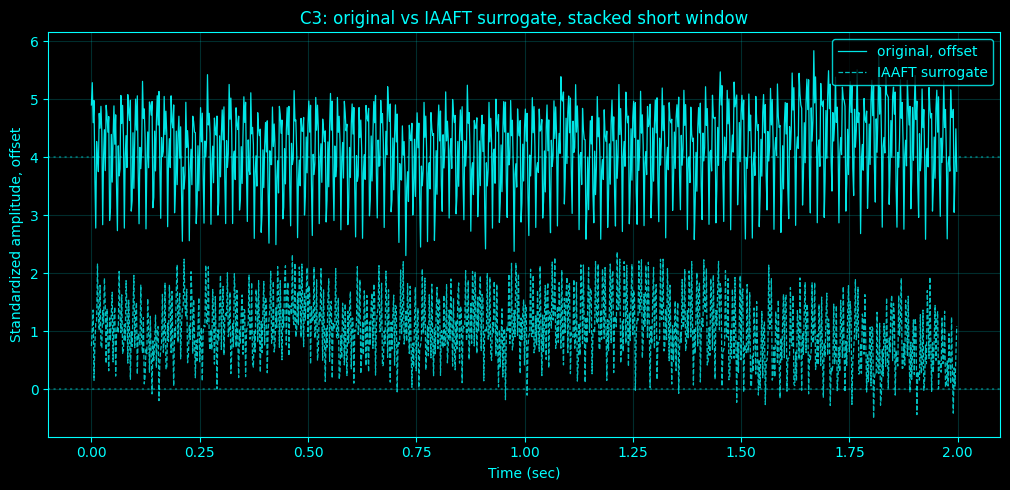

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/plots/01_C3_fixed_stacked_trace.png


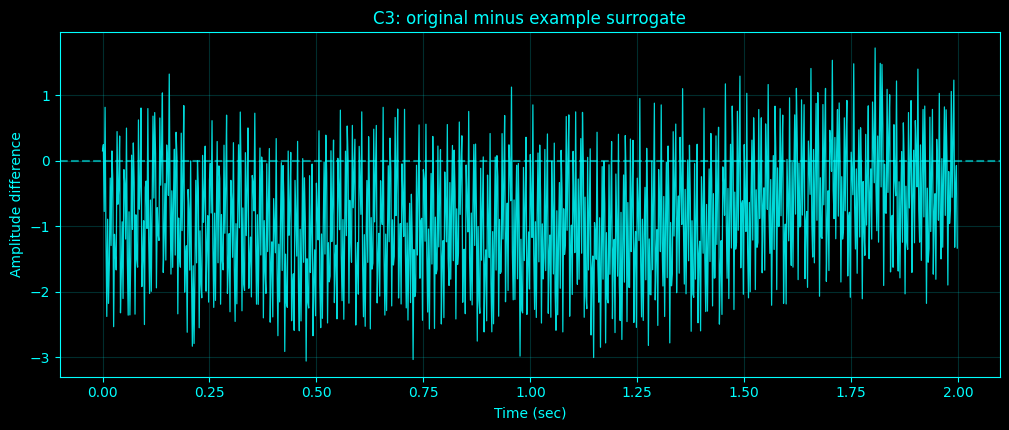

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/plots/02_C3_fixed_original_minus_surrogate_trace.png


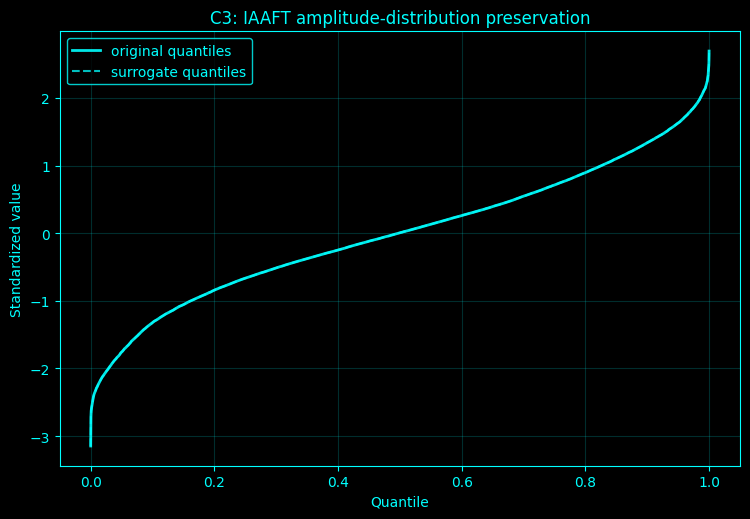

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/plots/03_C3_fixed_amplitude_distribution_match.png


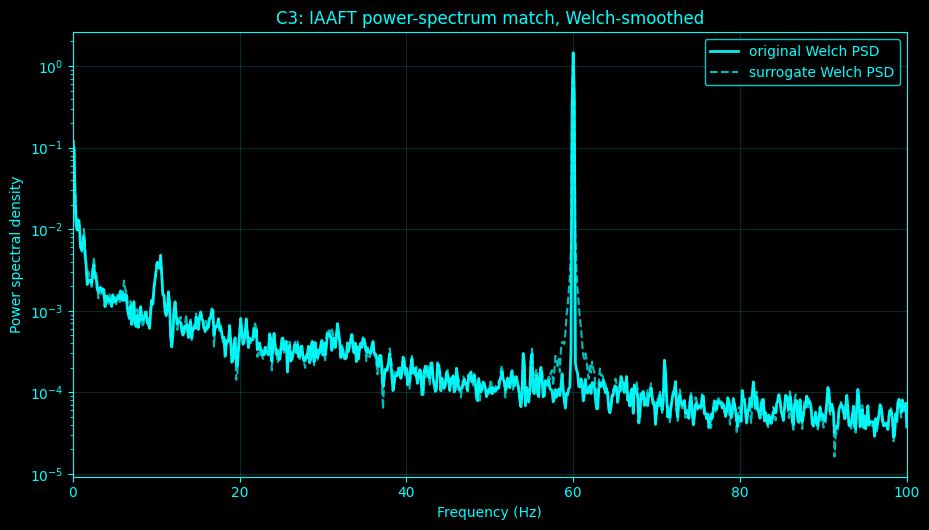

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/plots/04_C3_fixed_welch_power_spectrum_match.png


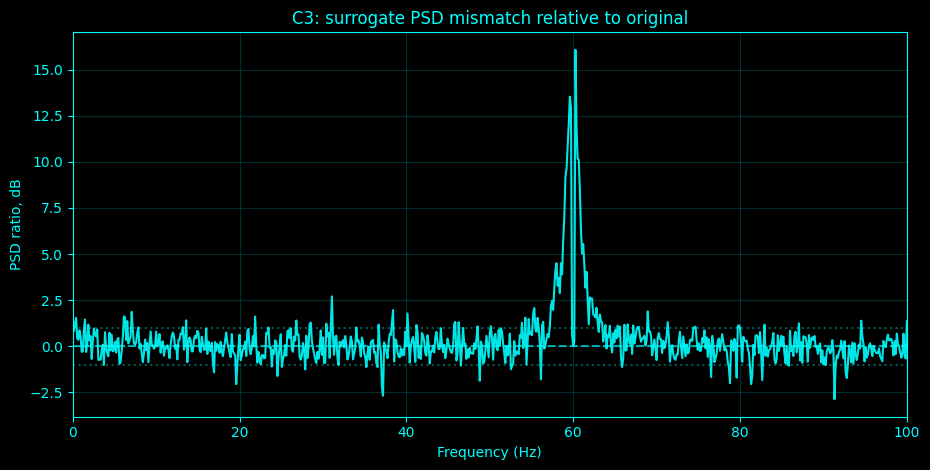

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/plots/05_C3_fixed_psd_mismatch_db.png


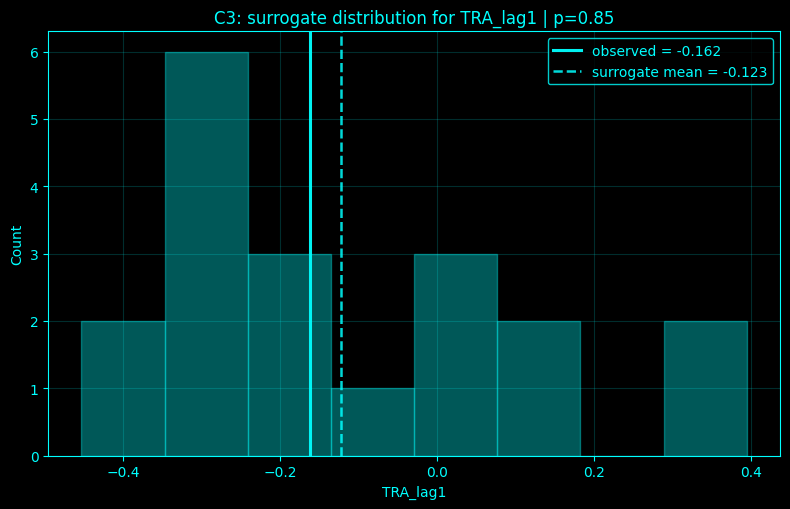

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/plots/06_C3_TRA_lag1_surrogate_histogram.png


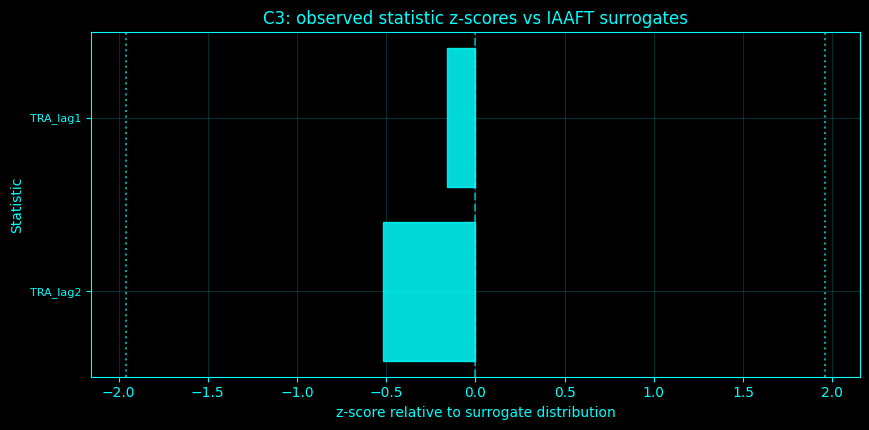

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/plots/07_C3_fixed_statistic_zscores.png

Done.
Elapsed: 0.04 min
Summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/iaaft_fast_summary_20260603_153843.csv
Surrogate statistics CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/iaaft_fast_surrogate_statistics_20260603_153843.csv
QC CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/iaaft_fast_qc_20260603_153843.csv
NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/iaaft_fast_results_20260603_153843.npz
TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/iaaft_fast_report_20260603_153843.txt
Plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/results/surrogate_tests_iaaft_fast/plots


In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed

# ============================================================
# FAST IAAFT SURROGATE NONLINEARITY TESTING BLOCK
# ============================================================

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

results_dir = os.path.join(base_dir, "results", "surrogate_tests_iaaft_fast")
plots_dir = os.path.join(results_dir, "plots")

os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

OUT_SUMMARY_CSV = os.path.join(results_dir, f"iaaft_fast_summary_{timestamp}.csv")
OUT_SURR_STATS_CSV = os.path.join(results_dir, f"iaaft_fast_surrogate_statistics_{timestamp}.csv")
OUT_QC_CSV = os.path.join(results_dir, f"iaaft_fast_qc_{timestamp}.csv")
OUT_NPZ = os.path.join(results_dir, f"iaaft_fast_results_{timestamp}.npz")
OUT_TXT = os.path.join(results_dir, f"iaaft_fast_report_{timestamp}.txt")

# ============================================================
# CONFIG
# ============================================================

CHANNELS = ["C3"]
# CHANNELS = ["C3", "Cz", "C4"]
# CHANNELS = None

eeg_channel_names = [
    "Fp1","Fpz","Fp2","F7","F3","Fz","F4","F8","FC5","FC1","FC2","FC6",
    "M1","T7","C3","Cz","C4","T8","M2","CP5","CP1","CP2","CP6",
    "P7","P3","Pz","P4","P8","POz","O1","Oz","O2"
]

sampling_rate = 1000

start_time = 814.571
end_time = 921.515

start_idx = int(start_time * sampling_rate)
end_idx = int(end_time * sampling_rate)

SEED = 0

N_SURR = 19
IAAFT_ITERS = 80

DECIMATE_FACTOR = 2
MAX_SAMPLES = 30000

N_WORKERS = min(6, max(1, (os.cpu_count() or 2) - 1))

IAAFT_TOL = 2e-3
IAAFT_MIN_ITERS = 30
IAAFT_CHECK_EVERY = 10

STAT_LAGS = [1, 2]

RUN_EXTRA_STATS = False

STANDARDIZE = True
LINEAR_DETREND = False

SAVE_ALL_SURROGATES = False
SAVE_EXAMPLE_SURROGATE = True

PLOT_FIRST_SECONDS = 5
SPECTRUM_XLIM_HZ = 100

PROGRESS_EVERY = 5

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# ============================================================
# STYLE HELPERS
# ============================================================

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def style_legend(leg):
    if leg is not None:
        leg.get_frame().set_facecolor(BG)
        leg.get_frame().set_edgecolor(ACCENT)

        for t in leg.get_texts():
            t.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=190):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)

# ============================================================
# DATA HELPERS
# ============================================================

def linear_detrend_1d(x):
    x = np.asarray(x, dtype=float)
    t = np.arange(len(x), dtype=float)
    coef = np.polyfit(t, x, 1)
    return x - np.polyval(coef, t)


def preprocess_signal(
    x,
    fs,
    decimate_factor=1,
    max_samples=None,
    standardize=True,
    detrend=False,
):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = x[np.isfinite(x)]

    fs_eff = float(fs)

    if detrend:
        x = linear_detrend_1d(x)

    if decimate_factor is not None and decimate_factor > 1:
        try:
            from scipy.signal import decimate
            x = decimate(x, int(decimate_factor), ftype="iir", zero_phase=True)
        except Exception:
            x = x[::int(decimate_factor)]

        fs_eff = fs_eff / float(decimate_factor)

    if max_samples is not None and len(x) > max_samples:
        start = max(0, (len(x) - max_samples) // 2)
        stop = start + max_samples
        x = x[start:stop]

    if standardize:
        x = x - np.mean(x)
        x = x / (np.std(x) + 1e-12)

    return x, fs_eff


def load_eeg_array(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing EEG file: {path}")

    arr = np.load(path, allow_pickle=True)
    arr = np.asarray(arr, dtype=float)
    arr = np.squeeze(arr)

    if arr.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {arr.shape}")

    if arr.shape[0] == len(eeg_channel_names) and arr.shape[1] != len(eeg_channel_names):
        arr = arr.T

    if arr.shape[1] != len(eeg_channel_names):
        raise ValueError(f"Expected {len(eeg_channel_names)} channels, got shape {arr.shape}")

    return arr


def get_channels_to_run():
    if CHANNELS is None:
        return list(eeg_channel_names)

    missing = [ch for ch in CHANNELS if ch not in eeg_channel_names]

    if len(missing) > 0:
        raise ValueError(f"Unknown requested channels: {missing}")

    return list(CHANNELS)

# ============================================================
# FAST IAAFT
# ============================================================

def spectrum_relative_error_from_mag(y, target_mag):
    mag_y = np.abs(np.fft.rfft(y))
    return float(np.linalg.norm(mag_y - target_mag) / (np.linalg.norm(target_mag) + 1e-12))


def iaaft_surrogate_fast(
    x_sorted,
    target_mag,
    n,
    seed,
    n_iter=80,
    tol=2e-3,
    min_iter=30,
    check_every=10,
):
    rng = np.random.default_rng(seed)
    y = rng.permutation(x_sorted)

    final_err = np.nan
    used_iters = 0

    for it in range(1, n_iter + 1):
        Y = np.fft.rfft(y)
        phases = np.exp(1j * np.angle(Y))
        y = np.fft.irfft(target_mag * phases, n=n)

        ranks = np.argsort(y, kind="quicksort")
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2

        used_iters = it

        if it >= min_iter and ((it % check_every == 0) or (it == n_iter)):
            final_err = spectrum_relative_error_from_mag(y, target_mag)

            if final_err <= tol:
                break

    if not np.isfinite(final_err):
        final_err = spectrum_relative_error_from_mag(y, target_mag)

    return y, final_err, used_iters

# ============================================================
# STATISTICS
# ============================================================

def time_reversal_asymmetry(x, lag=1):
    x = np.asarray(x, dtype=float)

    if len(x) <= lag:
        return np.nan

    dx = x[lag:] - x[:-lag]
    sd = np.std(dx) + 1e-12

    return float(np.mean((dx / sd) ** 3))


def third_order_moment(x, lag=1):
    x = np.asarray(x, dtype=float)

    if len(x) <= 2 * lag:
        return np.nan

    a = x[:-2 * lag]
    b = x[lag:-lag]
    c = x[2 * lag:]

    sd = np.std(x) + 1e-12

    return float(np.mean(a * b * c) / (sd ** 3))


def nonlinear_autocorr_asymmetry(x, lag=1):
    x = np.asarray(x, dtype=float)

    if len(x) <= lag:
        return np.nan

    a = x[:-lag]
    b = x[lag:]

    sd = np.std(x) + 1e-12

    return float(np.mean((a ** 2) * b - a * (b ** 2)) / (sd ** 3))


def compute_statistics_fast(x, lags, run_extra=False):
    out = {}

    for lag in lags:
        out[f"TRA_lag{lag}"] = time_reversal_asymmetry(x, lag=lag)

    if run_extra:
        for lag in lags:
            out[f"third_order_lag{lag}"] = third_order_moment(x, lag=lag)

        for lag in lags:
            out[f"nl_autocorr_asym_lag{lag}"] = nonlinear_autocorr_asymmetry(x, lag=lag)

    return out


def empirical_p_values(obs, surr_values):
    surr_values = np.asarray(surr_values, dtype=float)
    surr_values = surr_values[np.isfinite(surr_values)]

    if len(surr_values) == 0 or not np.isfinite(obs):
        return np.nan, np.nan, np.nan, np.nan

    mu = float(np.mean(surr_values))
    sd = float(np.std(surr_values) + 1e-12)

    z = float((obs - mu) / sd)

    p_two = float((np.sum(np.abs(surr_values - mu) >= abs(obs - mu)) + 1.0) / (len(surr_values) + 1.0))
    p_high = float((np.sum(surr_values >= obs) + 1.0) / (len(surr_values) + 1.0))
    p_low = float((np.sum(surr_values <= obs) + 1.0) / (len(surr_values) + 1.0))

    return z, p_two, p_high, p_low


def fft_power(x, fs):
    x = np.asarray(x, dtype=float)
    F = np.fft.rfft(x)
    freq = np.fft.rfftfreq(len(x), d=1.0 / fs)
    power = (np.abs(F) ** 2) / max(len(x), 1)

    return freq, power

# ============================================================
# LOAD EEG
# ============================================================

EEG = load_eeg_array(eeg_path)
channels_to_run = get_channels_to_run()

print("Loaded EEG:", eeg_path, flush=True)
print("EEG shape:", EEG.shape, flush=True)
print("Channels:", channels_to_run, flush=True)
print("Workers:", N_WORKERS, flush=True)
print("N_SURR:", N_SURR, "| IAAFT_ITERS:", IAAFT_ITERS, "| DECIMATE_FACTOR:", DECIMATE_FACTOR, flush=True)
print("SEED:", SEED, flush=True)

# ============================================================
# RUN ANALYSIS
# ============================================================

summary_records = []
surrogate_stat_records = []
qc_records = []
example_store = {}
surrogate_store = {}

run_start = time.time()

for ch_num, channel in enumerate(channels_to_run, start=1):
    print(f"\n[{ch_num}/{len(channels_to_run)}] Channel {channel}", flush=True)

    ch_idx = eeg_channel_names.index(channel)
    x_raw = EEG[start_idx:end_idx, ch_idx].astype(float)

    x, fs_eff = preprocess_signal(
        x_raw,
        fs=sampling_rate,
        decimate_factor=DECIMATE_FACTOR,
        max_samples=MAX_SAMPLES,
        standardize=STANDARDIZE,
        detrend=LINEAR_DETREND,
    )

    if len(x) < 100:
        raise ValueError(f"{channel}: segment too short after preprocessing: N={len(x)}")

    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    n = len(x)

    obs_stats = compute_statistics_fast(x, STAT_LAGS, run_extra=RUN_EXTRA_STATS)
    stat_names = list(obs_stats.keys())

    print(
        f"  N used={len(x)} | fs_eff={fs_eff:g} Hz | "
        f"observed {stat_names[0]}={obs_stats[stat_names[0]]:.6g}",
        flush=True
    )

    surr_stats_matrix = {name: np.zeros(N_SURR, dtype=float) for name in stat_names}
    final_errors = np.full(N_SURR, np.nan, dtype=float)
    used_iters_arr = np.zeros(N_SURR, dtype=int)

    if SAVE_ALL_SURROGATES:
        surr_matrix = np.zeros((N_SURR, len(x)), dtype=np.float32)
    else:
        surr_matrix = None

    y_example = None

    def worker(i):
        y, final_err, used_iters = iaaft_surrogate_fast(
            x_sorted=x_sorted,
            target_mag=target_mag,
            n=n,
            seed=SEED + 1000 * ch_num + i,
            n_iter=IAAFT_ITERS,
            tol=IAAFT_TOL,
            min_iter=IAAFT_MIN_ITERS,
            check_every=IAAFT_CHECK_EVERY,
        )

        stats = compute_statistics_fast(y, STAT_LAGS, run_extra=RUN_EXTRA_STATS)

        return i, y, stats, final_err, used_iters

    completed = 0
    failed = 0

    with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
        futures = [executor.submit(worker, i) for i in range(N_SURR)]

        for future in as_completed(futures):
            try:
                i, y, stats, final_err, used_iters = future.result()
            except Exception as e:
                failed += 1
                print(f"  surrogate worker ERROR: {type(e).__name__}: {e}", flush=True)
                continue

            for name in stat_names:
                surr_stats_matrix[name][i] = stats[name]

                surrogate_stat_records.append({
                    "channel": channel,
                    "surrogate_index": int(i + 1),
                    "statistic": name,
                    "surrogate_value": float(stats[name]),
                    "iaaft_final_spectrum_relative_error": float(final_err),
                    "iaaft_iters_used": int(used_iters),
                    "n_samples": int(len(x)),
                    "fs_eff": float(fs_eff),
                })

            final_errors[i] = final_err
            used_iters_arr[i] = used_iters

            if i == 0:
                y_example = y.copy()

            if SAVE_ALL_SURROGATES:
                surr_matrix[i] = y.astype(np.float32)

            completed += 1

            if (completed % PROGRESS_EVERY == 0) or (completed + failed == N_SURR):
                print(f"  completed {completed}/{N_SURR} surrogates | failed={failed}", flush=True)

    if completed == 0:
        raise RuntimeError(f"{channel}: all surrogate workers failed.")

    if y_example is None:
        y_example = y.copy()

    if SAVE_EXAMPLE_SURROGATE and y_example is not None:
        example_store[channel] = {
            "x": x.astype(np.float32),
            "y_example": y_example.astype(np.float32),
            "fs_eff": np.array([fs_eff], dtype=float),
        }

    if SAVE_ALL_SURROGATES and surr_matrix is not None:
        surrogate_store[channel] = surr_matrix

    for name in stat_names:
        valid_mask = np.isfinite(surr_stats_matrix[name])

        svals = surr_stats_matrix[name][valid_mask]
        obs_val = obs_stats[name]

        z, p_two, p_high, p_low = empirical_p_values(obs_val, svals)

        summary_records.append({
            "channel": channel,
            "statistic": name,
            "observed_value": float(obs_val),
            "surrogate_mean": float(np.mean(svals)),
            "surrogate_std": float(np.std(svals)),
            "surrogate_median": float(np.median(svals)),
            "surrogate_q025": float(np.percentile(svals, 2.5)),
            "surrogate_q975": float(np.percentile(svals, 97.5)),
            "z_score_vs_surrogates": float(z),
            "p_two_centered": float(p_two),
            "p_high": float(p_high),
            "p_low": float(p_low),
            "reject_0p05_two_sided": bool(p_two < 0.05),
            "n_surr_requested": int(N_SURR),
            "n_surr_completed": int(completed),
            "n_surr_failed": int(failed),
            "iaaft_iters_max": int(IAAFT_ITERS),
            "iaaft_iters_mean_used": float(np.nanmean(used_iters_arr[used_iters_arr > 0])),
            "n_samples": int(len(x)),
            "fs_eff": float(fs_eff),
            "start_time": float(start_time),
            "end_time": float(end_time),
            "decimate_factor": int(DECIMATE_FACTOR),
            "max_samples": int(MAX_SAMPLES) if MAX_SAMPLES is not None else -1,
            "standardized": bool(STANDARDIZE),
            "linear_detrend": bool(LINEAR_DETREND),
        })

    qc_records.append({
        "channel": channel,
        "n_samples": int(len(x)),
        "fs_eff": float(fs_eff),
        "duration_sec_after_preprocess": float(len(x) / fs_eff),
        "x_mean": float(np.mean(x)),
        "x_std": float(np.std(x)),
        "x_min": float(np.min(x)),
        "x_q01": float(np.percentile(x, 1)),
        "x_q25": float(np.percentile(x, 25)),
        "x_median": float(np.median(x)),
        "x_q75": float(np.percentile(x, 75)),
        "x_q99": float(np.percentile(x, 99)),
        "x_max": float(np.max(x)),
        "mean_iaaft_final_spectrum_relative_error": float(np.nanmean(final_errors)),
        "max_iaaft_final_spectrum_relative_error": float(np.nanmax(final_errors)),
        "mean_iaaft_iters_used": float(np.nanmean(used_iters_arr[used_iters_arr > 0])),
        "max_iaaft_iters_used": int(np.nanmax(used_iters_arr)),
        "n_surr_completed": int(completed),
        "n_surr_failed": int(failed),
    })

summary_df = pd.DataFrame(summary_records)
surrogate_stats_df = pd.DataFrame(surrogate_stat_records)
qc_df = pd.DataFrame(qc_records)

summary_df.to_csv(OUT_SUMMARY_CSV, index=False)
surrogate_stats_df.to_csv(OUT_SURR_STATS_CSV, index=False)
qc_df.to_csv(OUT_QC_CSV, index=False)

print("\nSaved summary CSV:", OUT_SUMMARY_CSV, flush=True)
print("Saved surrogate statistics CSV:", OUT_SURR_STATS_CSV, flush=True)
print("Saved QC CSV:", OUT_QC_CSV, flush=True)

# ============================================================
# SAVE NPZ
# ============================================================

npz_dict = {
    "summary_table_json": np.array([summary_df.to_json(orient="records")], dtype=object),
    "surrogate_stats_table_json": np.array([surrogate_stats_df.to_json(orient="records")], dtype=object),
    "qc_table_json": np.array([qc_df.to_json(orient="records")], dtype=object),
    "channels": np.array(channels_to_run, dtype=object),
    "stat_lags": np.array(STAT_LAGS, dtype=int),
    "n_surr": np.array([N_SURR], dtype=int),
    "iaaft_iters": np.array([IAAFT_ITERS], dtype=int),
    "sampling_rate": np.array([sampling_rate], dtype=float),
    "decimate_factor": np.array([DECIMATE_FACTOR], dtype=int),
    "start_time": np.array([start_time], dtype=float),
    "end_time": np.array([end_time], dtype=float),
    "seed": np.array([SEED], dtype=int),
}

for channel, data in example_store.items():
    npz_dict[f"{channel}_x"] = data["x"]
    npz_dict[f"{channel}_example_surrogate"] = data["y_example"]
    npz_dict[f"{channel}_fs_eff"] = data["fs_eff"]

for channel, mat in surrogate_store.items():
    npz_dict[f"{channel}_all_surrogates"] = mat

np.savez_compressed(OUT_NPZ, **npz_dict)

print("Saved NPZ:", OUT_NPZ, flush=True)

# ============================================================
# TEXT REPORT
# ============================================================

with open(OUT_TXT, "w") as f:
    f.write("FAST IAAFT Surrogate Nonlinearity Test\n")
    f.write("=====================================\n\n")
    f.write(f"timestamp={timestamp}\n")
    f.write(f"eeg_path={eeg_path}\n")
    f.write(f"channels={channels_to_run}\n")
    f.write(f"sampling_rate={sampling_rate}\n")
    f.write(f"decimate_factor={DECIMATE_FACTOR}\n")
    f.write(f"segment=[{start_time}, {end_time}] sec\n")
    f.write(f"n_surr={N_SURR}\n")
    f.write(f"iaaft_iters={IAAFT_ITERS}\n")
    f.write(f"iaaft_tol={IAAFT_TOL}\n")
    f.write(f"stat_lags={STAT_LAGS}\n")
    f.write(f"run_extra_stats={RUN_EXTRA_STATS}\n")
    f.write(f"max_samples={MAX_SAMPLES}\n")
    f.write(f"n_workers={N_WORKERS}\n")
    f.write(f"seed={SEED}\n\n")
    f.write(summary_df.to_string(index=False))

print("Saved TXT:", OUT_TXT, flush=True)

# ============================================================
# PRINT SUMMARY
# ============================================================

print("\n=== FAST IAAFT surrogate nonlinearity summary ===")
print(
    summary_df[
        [
            "channel",
            "statistic",
            "observed_value",
            "surrogate_mean",
            "surrogate_std",
            "z_score_vs_surrogates",
            "p_two_centered",
            "reject_0p05_two_sided",
            "iaaft_iters_mean_used",
        ]
    ].to_string(index=False)
)

print("\nQC:")
print(qc_df.to_string(index=False))

# ============================================================
# PLOTS
# ============================================================

try:
    from scipy.signal import welch
    HAVE_WELCH = True
except Exception:
    HAVE_WELCH = False

def downsample_for_plot(x, max_plot_points=5000):
    x = np.asarray(x, dtype=float)
    if len(x) <= max_plot_points:
        return np.arange(len(x)), x
    idx = np.linspace(0, len(x) - 1, max_plot_points).astype(int)
    return idx, x[idx]

def welch_power(x, fs, nperseg=None):
    x = np.asarray(x, dtype=float)
    if nperseg is None:
        nperseg = min(4096, max(256, len(x) // 8))
    if HAVE_WELCH:
        freq, power = welch(
            x,
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=nperseg // 2,
            detrend="constant",
            scaling="density"
        )
    else:
        F = np.fft.rfft(x)
        freq = np.fft.rfftfreq(len(x), d=1.0 / fs)
        power = (np.abs(F) ** 2) / max(len(x), 1)
    return freq, power

def safe_db_ratio(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    return 10.0 * np.log10((num + 1e-18) / (den + 1e-18))

for channel in channels_to_run:
    ex = example_store.get(channel, None)
    if ex is None:
        continue

    x = ex["x"].astype(float)
    y_ex = ex["y_example"].astype(float)
    fs_eff = float(ex["fs_eff"][0])

    # --------------------------------------------------------
    # FIXED PLOT 1: stacked short trace, not overplotted
    # --------------------------------------------------------
    trace_seconds = min(2.0, len(x) / fs_eff)
    n_trace = int(trace_seconds * fs_eff)

    x_trace = x[:n_trace]
    y_trace = y_ex[:n_trace]

    idx_plot, x_plot = downsample_for_plot(x_trace, max_plot_points=2500)
    _, y_plot = downsample_for_plot(y_trace, max_plot_points=2500)

    t_plot = idx_plot / fs_eff

    offset = 4.0

    fig, ax = plt.subplots(figsize=(10.2, 5.0), facecolor=BG)
    style_ax(ax)

    ax.plot(
        t_plot,
        x_plot + offset,
        color=ACCENT,
        linewidth=0.9,
        alpha=0.9,
        label="original, offset"
    )

    ax.plot(
        t_plot,
        y_plot,
        color=ACCENT,
        linewidth=0.9,
        linestyle="--",
        alpha=0.75,
        label="IAAFT surrogate"
    )

    ax.axhline(offset, color=ACCENT, linestyle=":", alpha=0.35)
    ax.axhline(0, color=ACCENT, linestyle=":", alpha=0.35)

    ax.set_title(f"{channel}: original vs IAAFT surrogate, stacked short window")
    ax.set_xlabel("Time (sec)")
    ax.set_ylabel("Standardized amplitude, offset")

    leg = ax.legend(loc="upper right")
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"01_{channel}_fixed_stacked_trace.png")
    save_show_close(fig, plot_path)

    # --------------------------------------------------------
    # FIXED PLOT 2: local residual / difference trace
    # --------------------------------------------------------
    diff_trace = x_trace - y_trace
    _, diff_plot = downsample_for_plot(diff_trace, max_plot_points=2500)

    fig, ax = plt.subplots(figsize=(10.2, 4.4), facecolor=BG)
    style_ax(ax)

    ax.plot(
        t_plot,
        diff_plot,
        color=ACCENT,
        linewidth=0.9,
        alpha=0.85
    )

    ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.55)

    ax.set_title(f"{channel}: original minus example surrogate")
    ax.set_xlabel("Time (sec)")
    ax.set_ylabel("Amplitude difference")

    plot_path = os.path.join(plots_dir, f"02_{channel}_fixed_original_minus_surrogate_trace.png")
    save_show_close(fig, plot_path)

    # --------------------------------------------------------
    # FIXED PLOT 3: amplitude distribution match
    # --------------------------------------------------------
    xs = np.sort(x)
    ys = np.sort(y_ex)

    n_q = min(len(xs), len(ys), 5000)
    q_idx = np.linspace(0, len(xs) - 1, n_q).astype(int)
    q = np.linspace(0, 1, n_q)

    fig, ax = plt.subplots(figsize=(7.6, 5.3), facecolor=BG)
    style_ax(ax)

    ax.plot(
        q,
        xs[q_idx],
        color=ACCENT,
        linewidth=2.0,
        alpha=0.9,
        label="original quantiles"
    )

    ax.plot(
        q,
        ys[q_idx],
        color=ACCENT,
        linewidth=1.5,
        linestyle="--",
        alpha=0.75,
        label="surrogate quantiles"
    )

    ax.set_title(f"{channel}: IAAFT amplitude-distribution preservation")
    ax.set_xlabel("Quantile")
    ax.set_ylabel("Standardized value")

    leg = ax.legend()
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"03_{channel}_fixed_amplitude_distribution_match.png")
    save_show_close(fig, plot_path)

    # --------------------------------------------------------
    # FIXED PLOT 4: Welch-smoothed PSD, not raw FFT
    # --------------------------------------------------------
    freq_x, pow_x = welch_power(x, fs_eff)
    freq_y, pow_y = welch_power(y_ex, fs_eff)

    max_hz = min(SPECTRUM_XLIM_HZ, fs_eff / 2)
    keep = (freq_x >= 0) & (freq_x <= max_hz)

    fig, ax = plt.subplots(figsize=(9.4, 5.4), facecolor=BG)
    style_ax(ax)

    ax.plot(
        freq_x[keep],
        pow_x[keep],
        color=ACCENT,
        linewidth=2.0,
        alpha=0.95,
        label="original Welch PSD"
    )

    ax.plot(
        freq_y[keep],
        pow_y[keep],
        color=ACCENT,
        linewidth=1.5,
        linestyle="--",
        alpha=0.75,
        label="surrogate Welch PSD"
    )

    ax.set_yscale("log")
    ax.set_xlim(0, max_hz)

    ax.set_title(f"{channel}: IAAFT power-spectrum match, Welch-smoothed")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power spectral density")

    leg = ax.legend(loc="upper right")
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"04_{channel}_fixed_welch_power_spectrum_match.png")
    save_show_close(fig, plot_path)

    # --------------------------------------------------------
    # FIXED PLOT 5: PSD mismatch in dB
    # --------------------------------------------------------
    psd_error_db = safe_db_ratio(pow_y, pow_x)

    fig, ax = plt.subplots(figsize=(9.4, 4.8), facecolor=BG)
    style_ax(ax)

    ax.plot(
        freq_x[keep],
        psd_error_db[keep],
        color=ACCENT,
        linewidth=1.5,
        alpha=0.9
    )

    ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.65)
    ax.axhline(1, color=ACCENT, linestyle=":", alpha=0.35)
    ax.axhline(-1, color=ACCENT, linestyle=":", alpha=0.35)

    ax.set_xlim(0, max_hz)

    ax.set_title(f"{channel}: surrogate PSD mismatch relative to original")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD ratio, dB")

    plot_path = os.path.join(plots_dir, f"05_{channel}_fixed_psd_mismatch_db.png")
    save_show_close(fig, plot_path)

    # --------------------------------------------------------
    # FIXED PLOT 6: primary surrogate statistic histogram
    # --------------------------------------------------------
    sub_summary = summary_df[summary_df["channel"] == channel].copy()

    primary_stat = "TRA_lag1"

    if primary_stat in sub_summary["statistic"].values:
        obs_val = float(
            sub_summary.loc[
                sub_summary["statistic"] == primary_stat,
                "observed_value"
            ].iloc[0]
        )

        pval = float(
            sub_summary.loc[
                sub_summary["statistic"] == primary_stat,
                "p_two_centered"
            ].iloc[0]
        )

        svals = surrogate_stats_df[
            (surrogate_stats_df["channel"] == channel) &
            (surrogate_stats_df["statistic"] == primary_stat)
        ]["surrogate_value"].to_numpy(dtype=float)

        fig, ax = plt.subplots(figsize=(8.0, 5.2), facecolor=BG)
        style_ax(ax)

        ax.hist(
            svals,
            bins=min(18, max(8, int(np.sqrt(len(svals))))),
            color=ACCENT,
            edgecolor=ACCENT,
            alpha=0.35
        )

        ax.axvline(
            obs_val,
            color=ACCENT,
            linewidth=2.2,
            alpha=0.95,
            label=f"observed = {obs_val:.3g}"
        )

        ax.axvline(
            np.mean(svals),
            color=ACCENT,
            linewidth=1.8,
            linestyle="--",
            alpha=0.85,
            label=f"surrogate mean = {np.mean(svals):.3g}"
        )

        ax.set_title(f"{channel}: surrogate distribution for {primary_stat} | p={pval:.3g}")
        ax.set_xlabel(primary_stat)
        ax.set_ylabel("Count")

        leg = ax.legend()
        style_legend(leg)

        plot_path = os.path.join(plots_dir, f"06_{channel}_{primary_stat}_surrogate_histogram.png")
        save_show_close(fig, plot_path)

    # --------------------------------------------------------
    # FIXED PLOT 7: z-score summary
    # --------------------------------------------------------
    if len(sub_summary) > 0:
        z_df = sub_summary.sort_values("z_score_vs_surrogates", ascending=True).copy()

        fig, ax = plt.subplots(
            figsize=(8.8, max(4.4, 0.4 * len(z_df) + 1.5)),
            facecolor=BG
        )
        style_ax(ax)

        y_pos = np.arange(len(z_df))

        ax.barh(
            y_pos,
            z_df["z_score_vs_surrogates"],
            color=ACCENT,
            edgecolor=ACCENT,
            alpha=0.85
        )

        ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.55)
        ax.axvline(1.96, color=ACCENT, linestyle=":", alpha=0.65)
        ax.axvline(-1.96, color=ACCENT, linestyle=":", alpha=0.65)

        ax.set_yticks(y_pos)
        ax.set_yticklabels(z_df["statistic"].values, fontsize=8)

        ax.set_title(f"{channel}: observed statistic z-scores vs IAAFT surrogates")
        ax.set_xlabel("z-score relative to surrogate distribution")
        ax.set_ylabel("Statistic")

        plot_path = os.path.join(plots_dir, f"07_{channel}_fixed_statistic_zscores.png")
        save_show_close(fig, plot_path)
        
print("\nDone.")
print(f"Elapsed: {(time.time() - run_start) / 60:.2f} min")
print("Summary CSV:", OUT_SUMMARY_CSV)
print("Surrogate statistics CSV:", OUT_SURR_STATS_CSV)
print("QC CSV:", OUT_QC_CSV)
print("NPZ:", OUT_NPZ)
print("TXT:", OUT_TXT)
print("Plots saved to:", plots_dir)

### Rosenstein LLE and IAAFT surrogate comparison

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block provides a reproducible Rosenstein largest-Lyapunov-exponent workflow with a locked fit window and surrogate comparison. It loads a scalar EEG
            segment from one channel (<code>C3</code>), reconstructs the delay-embedded state space, computes the Rosenstein mean-log-divergence curve for multiple
            temporal-separation constraints (<code>min_tsep</code>), fits the same fixed linear window across all runs, converts the fitted slope into an LLE in
            physical units of <code>1/s</code>, and optionally compares the observed estimate against an ensemble of IAAFT surrogates. The key intent is to test how
            robust the LLE estimate is to Theiler-style temporal exclusion while keeping the fitting region identical, so comparisons are not confounded by changing
            windows.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            The Rosenstein method estimates the largest Lyapunov exponent by tracking how nearby trajectories diverge in reconstructed state space. If
            <code>d_i(k)</code> is the separation between a reference point and its nearest valid neighbor after <code>k</code> forward steps, then in a regime of
            exponential divergence:
        </p>
        \[
            d_i(k)\approx d_i(0)e^{\lambda k\Delta t}
        \]
        <p>
            Taking logarithms and averaging across reference pairs yields:
        </p>
        \[
            \left\langle \log d_i(k)\right\rangle \approx \log d_i(0) + \lambda k\Delta t
        \]
        <p>
            Therefore, the slope of the mean log-distance curve versus discrete step index <code>k</code> estimates <code>\(\lambda \Delta t\)</code>. Since the code
            fits in index units and then multiplies by the sampling rate <code>fs</code>, the final estimate is:
        </p>
        \[
            \lambda_{\max} \approx (\text{slope in samples}^{-1})\times fs
        \]
        <p>
            so the reported largest Lyapunov exponent is expressed in <code>1/s</code>.
        </p>
        <h2>Delay Embedding and Temporal Exclusion</h2>
        <p>
            The helper <code>delay_embed_1d</code> reconstructs state vectors of dimension <code>m=10</code> with delay <code>\(\tau=8\)</code>:
        </p>
        \[
            X_t = [x_t,\;x_{t+\tau},\;x_{t+2\tau},\;\dots,\;x_{t+(m-1)\tau}]
        \]
        <p>
            Nearest neighbors are then searched in this reconstructed space. To avoid pairing points that are close merely because they are adjacent in time, the code
            enforces a minimum temporal separation <code>min_tsep</code>. This plays the role of a Theiler window and is swept over the values
            <code>\(\tau\)</code>, <code>\(2\tau\)</code>, and <code>50</code> samples. The purpose of this sweep is to test whether the estimated divergence rate is
            stable when increasingly strict temporal-correlation exclusion is applied.
        </p>
        <h2>Data Model and Segment Selection</h2>
        <p>
            The script expects a multichannel array in <code>eeg_data_with_channels.npy</code>, where rows are time samples and columns correspond to the named EEG
            channels. It extracts channel <code>C3</code> over the interval <code>[814.571, 921.515]</code> seconds at <code>1000 Hz</code>, then standardizes the
            resulting scalar series to zero mean and unit variance. This standardization improves numerical comparability and prevents overall signal amplitude from
            dominating Euclidean distances in the embedded space.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Load</b> the selected EEG channel and extract the target time interval.</li>
                <li><b>Standardize</b> the scalar signal and reconstruct delay vectors with embedding dimension <code>10</code> and delay <code>8</code>.</li>
                <li><b>Compute</b> the Rosenstein divergence curve by pairing each reference point with its nearest valid neighbor outside the temporal exclusion zone.</li>
                <li><b>Lock</b> one fit window <code>[fit_lo, fit_hi]</code> for all observed and surrogate runs, or optionally auto-pick it once from the observed data.</li>
                <li><b>Fit</b> a straight line to the locked portion of the mean log-distance curve and convert the slope to an LLE in <code>1/s</code>.</li>
                <li><b>Sweep</b> over multiple <code>min_tsep</code> values to assess sensitivity to temporal-neighbor exclusion.</li>
                <li><b>Generate</b> IAAFT surrogates and repeat the same Rosenstein fit on each surrogate using the identical locked window.</li>
                <li><b>Compute</b> a one-sided empirical p-value comparing surrogate LLEs against the observed LLE.</li>
                <li><b>Save</b> plots, per-condition <code>.npz</code> files, and a summary text table.</li>
            </ol>
            This makes the script both an LLE estimation workflow and a robustness study across exclusion settings and surrogate null models.
        </p>
        <h2>Locked Fit Window and Interpretability</h2>
        <p>
            A major design choice in this script is that the fit interval is locked for all conditions. By default, the code uses the manually specified index window
            <code>[10,60]</code>, although it can optionally auto-pick one window from the observed curve and then reuse it everywhere. This is important because
            changing the fit window across <code>min_tsep</code> values or across surrogates would make slope comparisons ambiguous. A common window ensures that any
            differences in estimated LLE reflect differences in the divergence curves themselves, not differences in the chosen fitting region.
        </p>
        <h2>Surrogate Comparison and Hypothesis Test</h2>
        <p>
            If surrogate testing is enabled, the code generates IAAFT surrogates that preserve the amplitude distribution and approximately preserve the power spectrum
            of the original signal. For each surrogate, it computes the Rosenstein divergence curve under the same embedding, delay, temporal exclusion, and locked fit
            window, then extracts a surrogate LLE. The one-sided empirical p-value is:
        </p>
        \[
            p_{\mathrm{one}}=\frac{\#\{\,\lambda_{\mathrm{surr}}\ge \lambda_{\mathrm{obs}}\,\}+1}{n_{\mathrm{surr}}+1}
        \]
        <p>
            This tests how often a surrogate generated under a constrained linear-style null yields an LLE at least as large as the observed one. A small value of
            <code>p_one</code> suggests the observed divergence rate is unusually strong relative to the surrogate ensemble.
        </p>
        <h2>Axis Semantics</h2>
        <p>
            <ul>
                <li><b>x-axis in divergence plots:</b> time in seconds, obtained from <code>k/fs</code>.</li>
                <li><b>y-axis in divergence plots:</b> mean log distance between evolving neighbor pairs.</li>
                <li><b>Shaded region:</b> the locked fit window used for all slope estimates.</li>
                <li><b>Fit line:</b> the linear approximation whose slope determines the observed LLE.</li>
                <li><b>x-axis in histogram plots:</b> surrogate LLE values in <code>1/s</code>.</li>
                <li><b>Vertical line in histogram:</b> the observed LLE for the same <code>min_tsep</code>.</li>
            </ul>
            These plots together show both the geometric divergence behavior and where the observed estimate sits relative to the surrogate null distribution.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This view is most useful for:
            <ul>
                <li>Checking whether the largest Lyapunov exponent estimate is stable under different temporal-exclusion settings,</li>
                <li>Comparing observed divergence against IAAFT surrogates under an identical fit window,</li>
                <li>Diagnosing whether a positive LLE is robust or heavily dependent on near-temporal-neighbor contamination,</li>
                <li>Saving a full audit trail of divergence curves, histogram comparisons, and per-condition outputs.</li>
            </ul>
            In practice, consistent LLE values across the <code>min_tsep</code> sweep strengthen confidence that the estimate reflects genuine dynamical divergence
            rather than trivial temporal correlation, while surrogate comparisons provide an additional null-model benchmark.
        </p>
        <h2>Reproducibility Tip</h2>
        <p>
            The script fixes the random seed, records the channel, embedding settings, delay, locked fit window, and timestamp in the output filenames, and saves one
            <code>.npz</code> file per <code>min_tsep</code> condition plus a summary text table. Because the same locked fit window is applied everywhere, the
            resulting LLE comparisons remain directly auditable and easy to rerun.
        </p>
    </div>
</div>

Effective parameters after optional decimation:
  DECIMATE_FACTOR: 1
  tau_eff: 8
  kmax_eff: 200
  fit window: 10 60
  min_tsep_eff_list: [8, 16, 50]
  N_WORKERS: 6

Loaded EEG: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
EEG shape: (4227788, 32)
Channels: ['C3']

[1/1] Channel C3
Loaded C3: N=60000 | fs_eff=1000 Hz | segment=[814.571,921.515] s
LOCKED fit window for C3: k=[10,60] ~ [0.0100,0.0600] s
Observed | min_tsep=8 | LLE=4.65457 1/s | fit R2=0.3742 | RMSE=0.0886 | pairs=4000
Observed | min_tsep=16 | LLE=4.65564 1/s | fit R2=0.3744 | RMSE=0.08858 | pairs=4000
Observed | min_tsep=50 | LLE=4.66244 1/s | fit R2=0.3765 | RMSE=0.08832 | pairs=4000
Running 19 IAAFT surrogates with 6 workers...
  completed 5/19 surrogates | failed=0
  completed 10/19 surrogates | failed=0
  completed 15/19 surrogates | failed=0
  completed 19/19 surrogates | failed=0


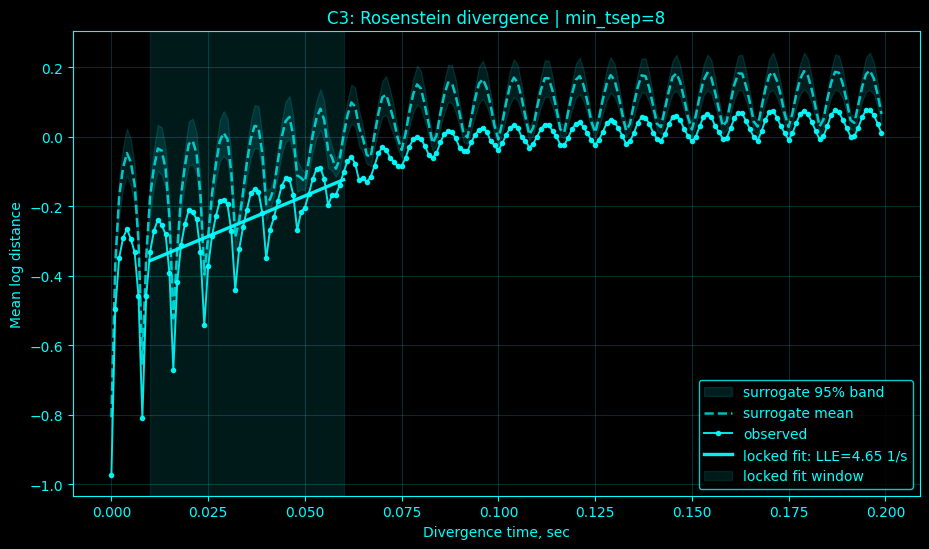

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_fast_locked_window_fixed_plots/plots/01_C3_divergence_tsep8_20260603_154651.png


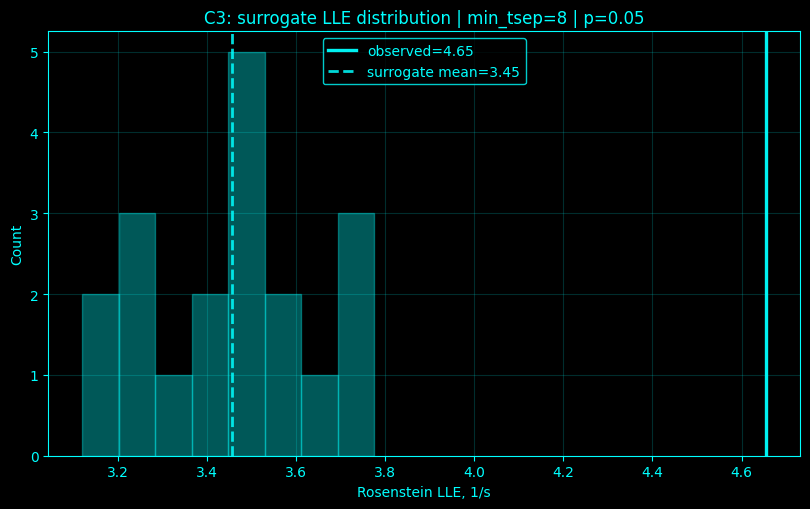

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_fast_locked_window_fixed_plots/plots/02_C3_surrogate_hist_tsep8_20260603_154651.png


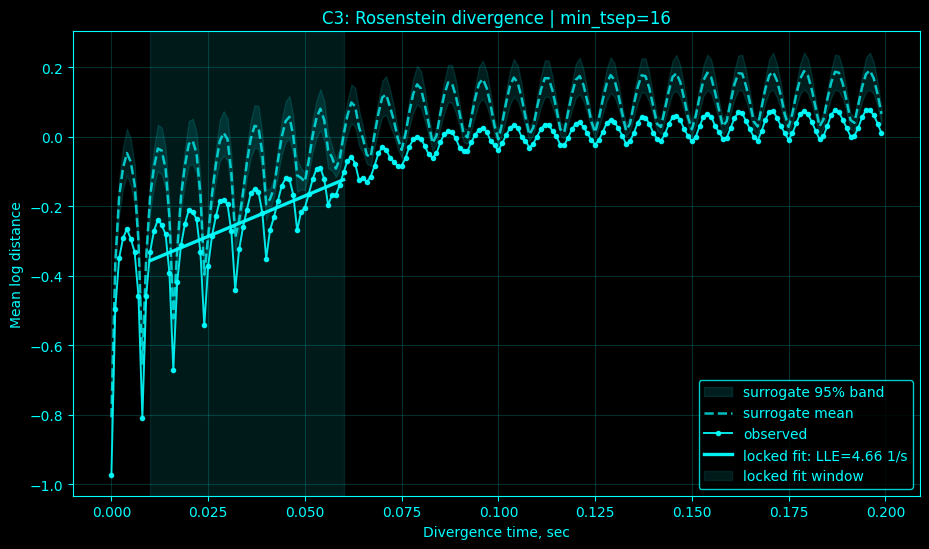

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_fast_locked_window_fixed_plots/plots/01_C3_divergence_tsep16_20260603_154651.png


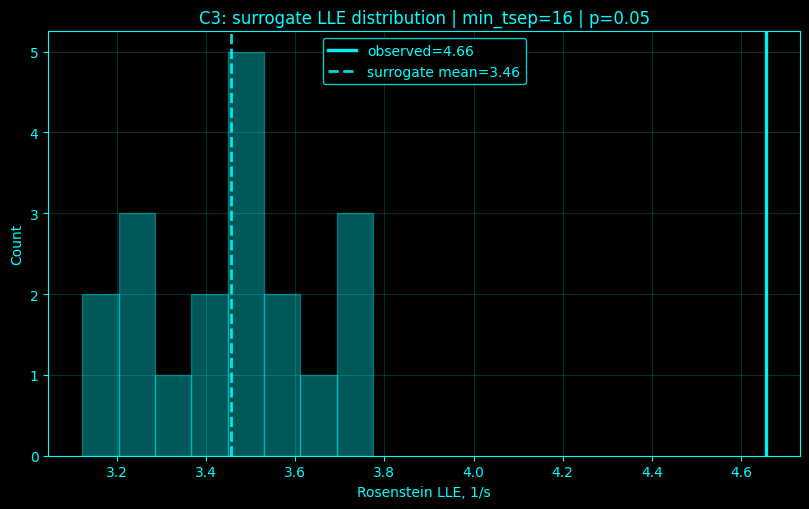

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_fast_locked_window_fixed_plots/plots/02_C3_surrogate_hist_tsep16_20260603_154651.png


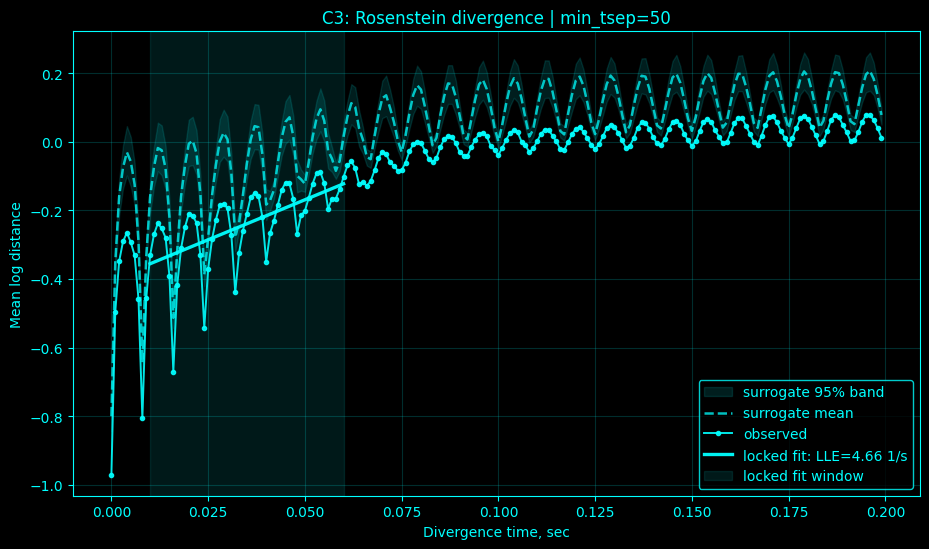

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_fast_locked_window_fixed_plots/plots/01_C3_divergence_tsep50_20260603_154651.png


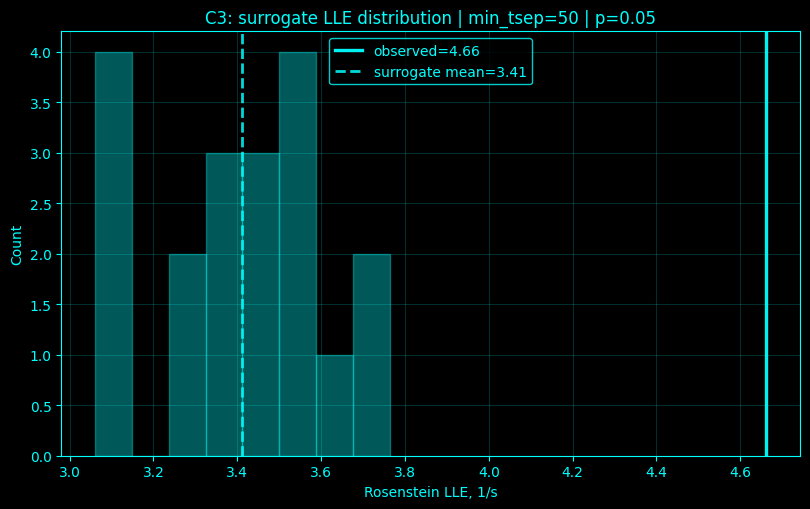

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_fast_locked_window_fixed_plots/plots/02_C3_surrogate_hist_tsep50_20260603_154651.png


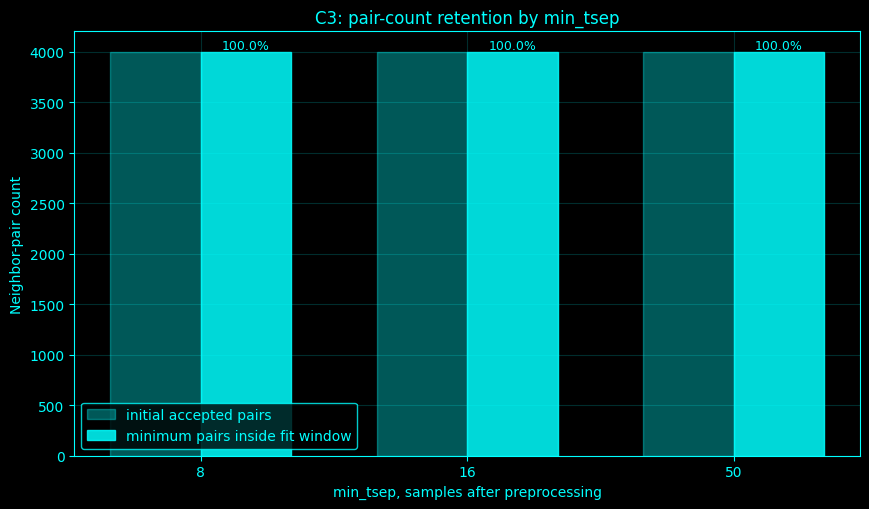

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_fast_locked_window_fixed_plots/plots/03A_C3_pair_count_retention_summary_20260603_154651.png


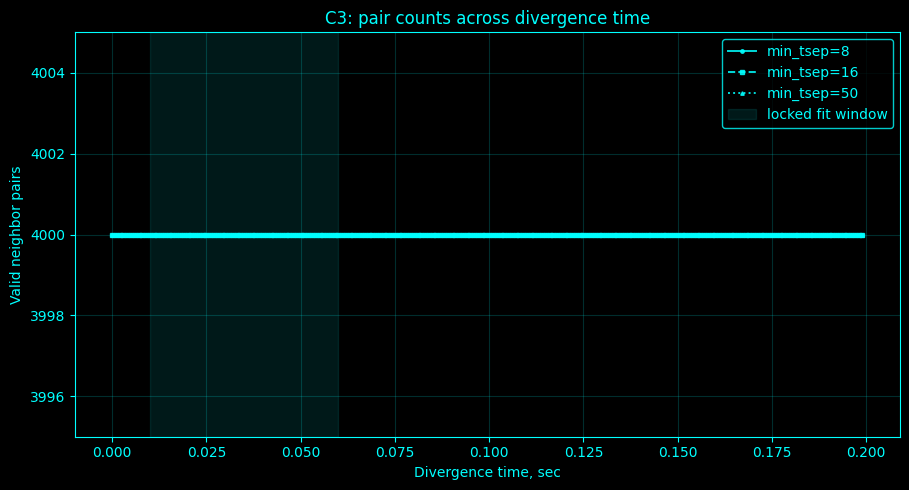

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_fast_locked_window_fixed_plots/plots/03B_C3_pair_counts_zoomed_by_k_20260603_154651.png


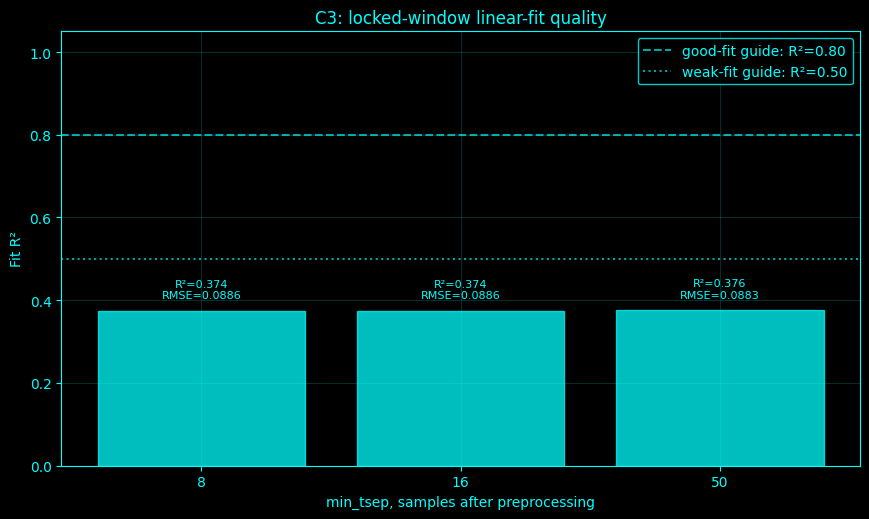

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_fast_locked_window_fixed_plots/plots/04_C3_fit_quality_r2_rmse_by_min_tsep_20260603_154651.png


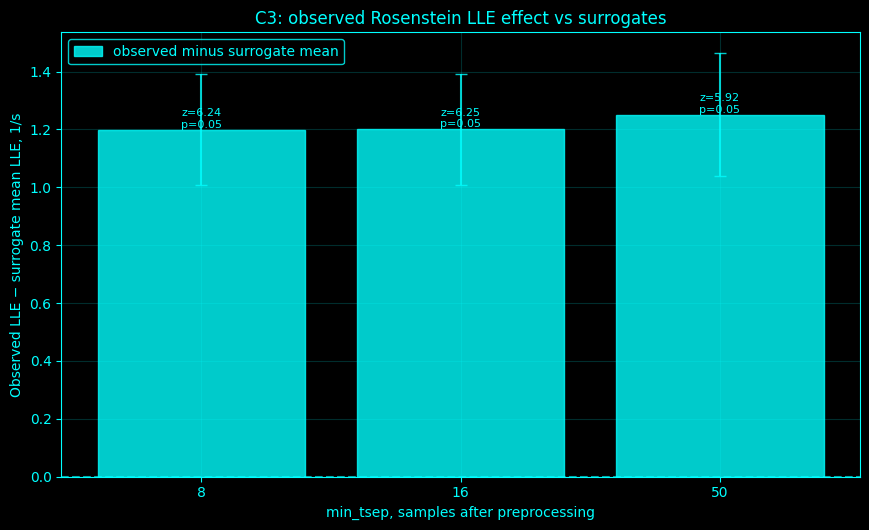

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_fast_locked_window_fixed_plots/plots/05A_C3_LLE_effect_size_vs_surrogates_20260603_154651.png


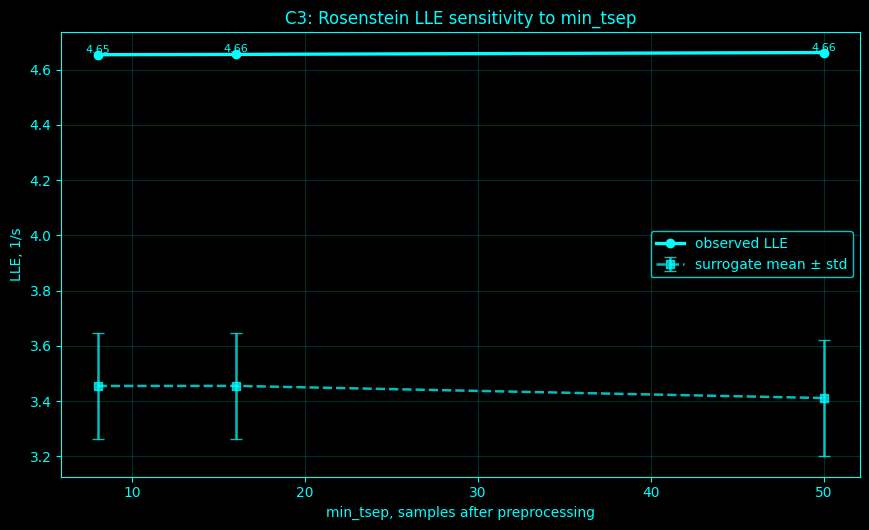

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_fast_locked_window_fixed_plots/plots/05B_C3_LLE_sensitivity_annotated_20260603_154651.png

=== Rosenstein fast summary ===
channel  min_tsep  min_tsep_seconds  lle_obs_per_second  slope_obs_per_sample  fit_intercept_obs  fit_r2_obs  fit_rmse_obs  surrogate_mean_lle  surrogate_std_lle  surrogate_q025_lle  surrogate_q975_lle  z_obs_vs_surrogates  p_one_surr_ge_obs  p_two_centered  n_surrogates_requested  n_surrogates_completed  initial_pair_count  fit_window_min_pair_count  fit_window_median_pair_count  final_nonzero_pair_count  pair_retention_percent  fs_eff  emb_dim  tau_eff  kmax_eff  fit_lo_eff  fit_hi_eff  n_ref  k_query  decimate_factor  max_samples  iaaft_iters
     C3         8             0.008            4.654572              0.004655          -0.403123    0.374213      0.088599            3.454888           0.192275            3.142027             3.75510             6.239420               0.05         

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.neighbors import NearestNeighbors

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    "Fp1","Fpz","Fp2","F7","F3","Fz","F4","F8","FC5","FC1","FC2","FC6",
    "M1","T7","C3","Cz","C4","T8","M2","CP5","CP1","CP2","CP6",
    "P7","P3","Pz","P4","P8","POz","O1","Oz","O2"
]

CHANNELS = ["C3"]

fs_original = 1000
t0, t1 = 814.571, 921.515
start_idx, end_idx = int(t0 * fs_original), int(t1 * fs_original)

EMB_DIM = 10
TAU_ORIGINAL = 8
KMAX_ORIGINAL = 200
MIN_TSEP_ORIGINAL_LIST = [TAU_ORIGINAL, 2 * TAU_ORIGINAL, 50]

LOCK_FIT = True
FIT_LO_ORIGINAL = 10
FIT_HI_ORIGINAL = 60

AUTO_PICK_ONCE = False
FIT_WINDOW_LEN_ORIGINAL = 30
FIT_LO_FRAC = 0.05
FIT_HI_FRAC = 0.60

DECIMATE_FACTOR = 1
MAX_SAMPLES = 60000

N_REF = 4000
K_QUERY = 160
MIN_PAIRS_REQUIRED = 100

DO_SURROGATES = True
N_SURROGATES = 19
IAAFT_ITERS = 80
IAAFT_TOL = 2e-3
IAAFT_MIN_ITERS = 30
IAAFT_CHECK_EVERY = 10
SEED = 0
N_WORKERS = min(6, max(1, (os.cpu_count() or 2) - 1))

results_dir = os.path.join(base_dir, "results", "rosenstein_fast_locked_window_fixed_plots")
plots_dir = os.path.join(results_dir, "plots")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

OUT_SUMMARY_CSV = os.path.join(results_dir, f"rosenstein_fast_summary_{timestamp}.csv")
OUT_SURR_CSV = os.path.join(results_dir, f"rosenstein_fast_surrogate_lle_{timestamp}.csv")
OUT_CURVES_CSV = os.path.join(results_dir, f"rosenstein_fast_curve_summary_{timestamp}.csv")
OUT_QC_CSV = os.path.join(results_dir, f"rosenstein_fast_qc_{timestamp}.csv")
OUT_DIAG_CSV = os.path.join(results_dir, f"rosenstein_fast_diagnostics_{timestamp}.csv")
OUT_NPZ = os.path.join(results_dir, f"rosenstein_fast_results_{timestamp}.npz")
OUT_TXT = os.path.join(results_dir, f"rosenstein_fast_report_{timestamp}.txt")

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.grid(True, color=ACCENT, alpha=0.18)

def style_legend(leg):
    if leg is not None:
        leg.get_frame().set_facecolor(BG)
        leg.get_frame().set_edgecolor(ACCENT)
        for t in leg.get_texts():
            t.set_color(ACCENT)

def save_show_close(fig, out_path, dpi=200):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)

def effective_sample_param(value_original, decimate_factor, minimum=1):
    return max(minimum, int(round(float(value_original) / float(decimate_factor))))

def linear_detrend_1d(x):
    x = np.asarray(x, dtype=float)
    t = np.arange(len(x), dtype=float)
    coef = np.polyfit(t, x, 1)
    return x - np.polyval(coef, t)

def preprocess_signal(x, fs, decimate_factor=1, max_samples=None, standardize=True, detrend=False):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = x[np.isfinite(x)]
    fs_eff = float(fs)
    if detrend:
        x = linear_detrend_1d(x)
    if decimate_factor is not None and decimate_factor > 1:
        try:
            from scipy.signal import decimate
            x = decimate(x, int(decimate_factor), ftype="iir", zero_phase=True)
        except Exception:
            x = x[::int(decimate_factor)]
        fs_eff = fs_eff / float(decimate_factor)
    if max_samples is not None and len(x) > max_samples:
        start = max(0, (len(x) - max_samples) // 2)
        stop = start + max_samples
        x = x[start:stop]
    if standardize:
        x = x - np.mean(x)
        x = x / (np.std(x) + 1e-12)
    return x, fs_eff

def load_eeg_array(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing EEG file: {path}")
    arr = np.load(path, allow_pickle=True)
    arr = np.asarray(arr, dtype=float)
    arr = np.squeeze(arr)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {arr.shape}")
    if arr.shape[0] == len(channel_names) and arr.shape[1] != len(channel_names):
        arr = arr.T
    if arr.shape[1] != len(channel_names):
        raise ValueError(f"Expected {len(channel_names)} channels, got shape {arr.shape}")
    return arr

def get_channels_to_run():
    if CHANNELS is None:
        return list(channel_names)
    missing = [ch for ch in CHANNELS if ch not in channel_names]
    if len(missing) > 0:
        raise ValueError(f"Unknown requested channels: {missing}")
    return list(CHANNELS)

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    n = len(x)
    M = n - (m - 1) * tau
    if M <= 2:
        raise ValueError(f"Embedding failed: len={n}, m={m}, tau={tau}")
    return np.column_stack([x[i * tau:i * tau + M] for i in range(m)])

def spectrum_relative_error_from_mag(y, target_mag):
    mag_y = np.abs(np.fft.rfft(y))
    return float(np.linalg.norm(mag_y - target_mag) / (np.linalg.norm(target_mag) + 1e-12))

def iaaft_surrogate_fast(x_sorted, target_mag, n, seed, n_iter=80, tol=2e-3, min_iter=30, check_every=10):
    rng = np.random.default_rng(seed)
    y = rng.permutation(x_sorted)
    final_err = np.nan
    used_iters = 0
    for it in range(1, n_iter + 1):
        Y = np.fft.rfft(y)
        phase = np.exp(1j * np.angle(Y))
        y = np.fft.irfft(target_mag * phase, n=n)
        ranks = np.argsort(y, kind="quicksort")
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
        used_iters = it
        if it >= min_iter and ((it % check_every == 0) or (it == n_iter)):
            final_err = spectrum_relative_error_from_mag(y, target_mag)
            if final_err <= tol:
                break
    if not np.isfinite(final_err):
        final_err = spectrum_relative_error_from_mag(y, target_mag)
    return y, final_err, used_iters

def fit_slope_locked(ks, log_div, fit_lo, fit_hi, fs_eff):
    fit_lo = int(fit_lo)
    fit_hi = int(fit_hi)
    if fit_hi <= fit_lo:
        raise ValueError(f"Invalid fit window: fit_lo={fit_lo}, fit_hi={fit_hi}")
    if fit_hi >= len(ks):
        raise ValueError(f"fit_hi={fit_hi} outside curve length={len(ks)}")
    xw = ks[fit_lo:fit_hi + 1]
    yw = log_div[fit_lo:fit_hi + 1]
    ok = np.isfinite(xw) & np.isfinite(yw)
    xw = xw[ok]
    yw = yw[ok]
    if len(xw) < 5:
        raise ValueError("Too few finite points in fit window.")
    coef = np.polyfit(xw, yw, 1)
    yhat = np.polyval(coef, xw)
    ss_res = float(np.sum((yw - yhat) ** 2))
    ss_tot = float(np.sum((yw - np.mean(yw)) ** 2))
    r2 = float(1.0 - ss_res / (ss_tot + 1e-12))
    slope_per_sample = float(coef[0])
    intercept = float(coef[1])
    lle_per_second = float(slope_per_sample * fs_eff)
    rmse = float(np.sqrt(np.mean((yw - yhat) ** 2)))
    return slope_per_sample, intercept, lle_per_second, r2, rmse

def auto_pick_fit_window(ks, log_div, fit_len, lo_frac, hi_frac):
    n = len(ks)
    lo = int(lo_frac * n)
    hi = int(hi_frac * n)
    fit_len = int(fit_len)
    best = None
    for start in range(lo, hi - fit_len + 1):
        end = start + fit_len
        xw = ks[start:end]
        yw = log_div[start:end]
        if not np.all(np.isfinite(yw)):
            continue
        coef = np.polyfit(xw, yw, 1)
        yhat = np.polyval(coef, xw)
        resid_std = float(np.std(yw - yhat))
        slope = float(coef[0])
        score = resid_std - 0.05 * max(slope, 0.0)
        if best is None or score < best[0]:
            best = (score, start, end - 1, slope, resid_std)
    if best is None:
        raise RuntimeError("Auto-pick failed.")
    return int(best[1]), int(best[2])

def rosenstein_curves_multi_tsep(x, m, tau, min_tsep_list, n_ref, kmax, seed=0, k_query=160, min_pairs_required=100):
    rng = np.random.default_rng(seed)
    X = delay_embed_1d(x, m, tau)
    M = len(X)
    valid_max = M - kmax - 1
    if valid_max <= 10:
        raise ValueError(f"Too few embedded points for kmax={kmax}. Embedded M={M}.")
    all_idx = np.arange(valid_max)
    if len(all_idx) > n_ref:
        ref_idx = np.sort(rng.choice(all_idx, size=n_ref, replace=False))
    else:
        ref_idx = all_idx
    max_tsep = max(min_tsep_list)
    n_query = min(M, max(k_query, 4 * m + 20, int(max_tsep) + 40))
    nn = NearestNeighbors(n_neighbors=n_query, algorithm="auto").fit(X)
    dists, inds = nn.kneighbors(X[ref_idx])
    ks = np.arange(kmax, dtype=int)
    curves = {}
    counts = {}
    pair_counts = {}
    for min_tsep in min_tsep_list:
        nn_idx = np.full(len(ref_idx), -1, dtype=int)
        for a, i in enumerate(ref_idx):
            for cand in inds[a, 1:]:
                cand = int(cand)
                if cand >= valid_max:
                    continue
                if abs(cand - int(i)) > int(min_tsep):
                    nn_idx[a] = cand
                    break
        keep = nn_idx >= 0
        ref_keep = ref_idx[keep]
        nn_keep = nn_idx[keep]
        pair_counts[int(min_tsep)] = int(len(ref_keep))
        if len(ref_keep) < min_pairs_required:
            raise ValueError(f"Too few pairs after Theiler exclusion for min_tsep={min_tsep}: {len(ref_keep)} pairs.")
        log_div = np.full(kmax, np.nan, dtype=float)
        count_k = np.zeros(kmax, dtype=int)
        for k in range(kmax):
            i = ref_keep + k
            j = nn_keep + k
            ok = (i < M) & (j < M)
            if not np.any(ok):
                continue
            dist = np.linalg.norm(X[i[ok]] - X[j[ok]], axis=1)
            dist = np.maximum(dist, 1e-12)
            log_div[k] = np.mean(np.log(dist))
            count_k[k] = int(np.sum(ok))
        curves[int(min_tsep)] = log_div
        counts[int(min_tsep)] = count_k
    return ks, curves, counts, pair_counts

def empirical_p_values(obs, svals):
    svals = np.asarray(svals, dtype=float)
    svals = svals[np.isfinite(svals)]
    if len(svals) == 0 or not np.isfinite(obs):
        return np.nan, np.nan, np.nan
    mu = float(np.mean(svals))
    sd = float(np.std(svals, ddof=1) + 1e-12) if len(svals) > 1 else 1e-12
    z = float((obs - mu) / sd)
    p_high = float((np.sum(svals >= obs) + 1.0) / (len(svals) + 1.0))
    p_two_centered = float((np.sum(np.abs(svals - mu) >= abs(obs - mu)) + 1.0) / (len(svals) + 1.0))
    return z, p_high, p_two_centered

def add_fit_line(ax, ks, log_div, fit_lo, fit_hi, slope, intercept, fs_eff, label):
    kfit = ks[fit_lo:fit_hi + 1]
    yfit = slope * kfit + intercept
    ax.plot(kfit / fs_eff, yfit, color=ACCENT, linewidth=2.4, alpha=0.95, label=label)

tau_eff = effective_sample_param(TAU_ORIGINAL, DECIMATE_FACTOR, minimum=1)
kmax_eff = effective_sample_param(KMAX_ORIGINAL, DECIMATE_FACTOR, minimum=20)
fit_lo_eff = effective_sample_param(FIT_LO_ORIGINAL, DECIMATE_FACTOR, minimum=1)
fit_hi_eff = effective_sample_param(FIT_HI_ORIGINAL, DECIMATE_FACTOR, minimum=fit_lo_eff + 5)
fit_window_len_eff = effective_sample_param(FIT_WINDOW_LEN_ORIGINAL, DECIMATE_FACTOR, minimum=5)
min_tsep_eff_list = sorted(set([effective_sample_param(v, DECIMATE_FACTOR, minimum=1) for v in MIN_TSEP_ORIGINAL_LIST]))

if fit_hi_eff >= kmax_eff:
    fit_hi_eff = kmax_eff - 2
if fit_hi_eff <= fit_lo_eff:
    fit_hi_eff = min(kmax_eff - 2, fit_lo_eff + 10)

print("Effective parameters after optional decimation:")
print("  DECIMATE_FACTOR:", DECIMATE_FACTOR)
print("  tau_eff:", tau_eff)
print("  kmax_eff:", kmax_eff)
print("  fit window:", fit_lo_eff, fit_hi_eff)
print("  min_tsep_eff_list:", min_tsep_eff_list)
print("  N_WORKERS:", N_WORKERS)

EEG = load_eeg_array(eeg_path)
channels_to_run = get_channels_to_run()

print("\nLoaded EEG:", eeg_path, flush=True)
print("EEG shape:", EEG.shape, flush=True)
print("Channels:", channels_to_run, flush=True)

summary_records = []
surrogate_records = []
curve_records = []
qc_records = []
diagnostic_records = []

npz_payload = {
    "channels": np.array(channels_to_run, dtype=object),
    "min_tsep_eff_list": np.array(min_tsep_eff_list, dtype=int),
    "tau_eff": np.array([tau_eff], dtype=int),
    "kmax_eff": np.array([kmax_eff], dtype=int),
    "fit_lo_eff": np.array([fit_lo_eff], dtype=int),
    "fit_hi_eff": np.array([fit_hi_eff], dtype=int),
    "fs_original": np.array([fs_original], dtype=float),
    "decimate_factor": np.array([DECIMATE_FACTOR], dtype=int),
    "n_surrogates": np.array([N_SURROGATES], dtype=int),
    "iaaft_iters": np.array([IAAFT_ITERS], dtype=int),
}

run_start = time.time()

for ch_num, channel in enumerate(channels_to_run, start=1):
    print(f"\n[{ch_num}/{len(channels_to_run)}] Channel {channel}", flush=True)
    ch_i = channel_names.index(channel)
    x_raw = EEG[start_idx:end_idx, ch_i].astype(float)
    x, fs_eff = preprocess_signal(
        x_raw,
        fs=fs_original,
        decimate_factor=DECIMATE_FACTOR,
        max_samples=MAX_SAMPLES,
        standardize=True,
        detrend=False
    )
    print(f"Loaded {channel}: N={len(x)} | fs_eff={fs_eff:g} Hz | segment=[{t0},{t1}] s", flush=True)

    ks_obs, obs_curves, obs_counts, obs_pair_counts = rosenstein_curves_multi_tsep(
        x,
        m=EMB_DIM,
        tau=tau_eff,
        min_tsep_list=min_tsep_eff_list,
        n_ref=N_REF,
        kmax=kmax_eff,
        seed=SEED,
        k_query=K_QUERY,
        min_pairs_required=MIN_PAIRS_REQUIRED
    )

    local_fit_lo = fit_lo_eff
    local_fit_hi = fit_hi_eff

    if AUTO_PICK_ONCE:
        first_tsep = int(min_tsep_eff_list[0])
        local_fit_lo, local_fit_hi = auto_pick_fit_window(
            ks_obs,
            obs_curves[first_tsep],
            fit_len=fit_window_len_eff,
            lo_frac=FIT_LO_FRAC,
            hi_frac=FIT_HI_FRAC
        )
        print(f"AUTO-PICKED locked fit window for {channel}: k=[{local_fit_lo},{local_fit_hi}] ~ [{local_fit_lo / fs_eff:.4f},{local_fit_hi / fs_eff:.4f}] s", flush=True)
    else:
        print(f"LOCKED fit window for {channel}: k=[{local_fit_lo},{local_fit_hi}] ~ [{local_fit_lo / fs_eff:.4f},{local_fit_hi / fs_eff:.4f}] s", flush=True)

    obs_fit = {}

    for min_tsep in min_tsep_eff_list:
        min_tsep = int(min_tsep)
        ld = obs_curves[min_tsep]
        slope, intercept, lle_obs, r2, rmse = fit_slope_locked(
            ks_obs,
            ld,
            local_fit_lo,
            local_fit_hi,
            fs_eff
        )
        obs_fit[min_tsep] = {
            "slope_per_sample": slope,
            "intercept": intercept,
            "lle_per_second": lle_obs,
            "fit_r2": r2,
            "fit_rmse": rmse,
        }
        print(f"Observed | min_tsep={min_tsep} | LLE={lle_obs:.6g} 1/s | fit R2={r2:.4f} | RMSE={rmse:.4g} | pairs={obs_pair_counts[min_tsep]}", flush=True)

    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    n = len(x)

    surr_lle_by_tsep = {int(t): [] for t in min_tsep_eff_list}
    surr_curve_by_tsep = {int(t): [] for t in min_tsep_eff_list}
    surr_errors = []
    surr_iters = []

    def surrogate_worker(s):
        y, final_err, used_iters = iaaft_surrogate_fast(
            x_sorted=x_sorted,
            target_mag=target_mag,
            n=n,
            seed=SEED + 10000 * ch_num + s,
            n_iter=IAAFT_ITERS,
            tol=IAAFT_TOL,
            min_iter=IAAFT_MIN_ITERS,
            check_every=IAAFT_CHECK_EVERY
        )
        ks_s, s_curves, s_counts, s_pair_counts = rosenstein_curves_multi_tsep(
            y,
            m=EMB_DIM,
            tau=tau_eff,
            min_tsep_list=min_tsep_eff_list,
            n_ref=N_REF,
            kmax=kmax_eff,
            seed=SEED + 1000 + s,
            k_query=K_QUERY,
            min_pairs_required=MIN_PAIRS_REQUIRED
        )
        out = {
            "surrogate_index": int(s + 1),
            "final_error": float(final_err),
            "used_iters": int(used_iters),
            "curves": {},
            "fits": {},
            "pair_counts": {},
        }
        for min_tsep in min_tsep_eff_list:
            min_tsep = int(min_tsep)
            ld = s_curves[min_tsep]
            slope, intercept, lle_surr, r2, rmse = fit_slope_locked(
                ks_s,
                ld,
                local_fit_lo,
                local_fit_hi,
                fs_eff
            )
            out["curves"][min_tsep] = ld
            out["pair_counts"][min_tsep] = int(s_pair_counts[min_tsep])
            out["fits"][min_tsep] = {
                "slope_per_sample": float(slope),
                "intercept": float(intercept),
                "lle_per_second": float(lle_surr),
                "fit_r2": float(r2),
                "fit_rmse": float(rmse),
            }
        return out

    if DO_SURROGATES:
        print(f"Running {N_SURROGATES} IAAFT surrogates with {N_WORKERS} workers...", flush=True)
        completed = 0
        failed = 0
        with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
            futures = [executor.submit(surrogate_worker, s) for s in range(N_SURROGATES)]
            for fut in as_completed(futures):
                try:
                    res = fut.result()
                except Exception as e:
                    failed += 1
                    print(f"  surrogate ERROR: {type(e).__name__}: {e}", flush=True)
                    continue
                sidx = int(res["surrogate_index"])
                surr_errors.append(res["final_error"])
                surr_iters.append(res["used_iters"])
                for min_tsep in min_tsep_eff_list:
                    min_tsep = int(min_tsep)
                    fit = res["fits"][min_tsep]
                    lle_surr = fit["lle_per_second"]
                    surr_lle_by_tsep[min_tsep].append(lle_surr)
                    surr_curve_by_tsep[min_tsep].append(res["curves"][min_tsep])
                    surrogate_records.append({
                        "channel": channel,
                        "surrogate_index": sidx,
                        "min_tsep": min_tsep,
                        "lle_per_second": float(lle_surr),
                        "slope_per_sample": float(fit["slope_per_sample"]),
                        "intercept": float(fit["intercept"]),
                        "fit_r2": float(fit["fit_r2"]),
                        "fit_rmse": float(fit["fit_rmse"]),
                        "iaaft_final_spectrum_relative_error": float(res["final_error"]),
                        "iaaft_iters_used": int(res["used_iters"]),
                        "pair_count": int(res["pair_counts"][min_tsep]),
                    })
                completed += 1
                if completed % 5 == 0 or completed + failed == N_SURROGATES:
                    print(f"  completed {completed}/{N_SURROGATES} surrogates | failed={failed}", flush=True)

    for min_tsep in min_tsep_eff_list:
        min_tsep = int(min_tsep)
        obs = obs_fit[min_tsep]
        lle_obs = obs["lle_per_second"]
        svals = np.asarray(surr_lle_by_tsep[min_tsep], dtype=float)
        svals = svals[np.isfinite(svals)]
        if len(svals) > 0:
            z, p_high, p_two = empirical_p_values(lle_obs, svals)
            surr_mean = float(np.mean(svals))
            surr_std = float(np.std(svals, ddof=1)) if len(svals) > 1 else 0.0
            surr_q025 = float(np.percentile(svals, 2.5))
            surr_q975 = float(np.percentile(svals, 97.5))
        else:
            z, p_high, p_two = np.nan, np.nan, np.nan
            surr_mean, surr_std, surr_q025, surr_q975 = np.nan, np.nan, np.nan, np.nan

        fit_counts = np.asarray(obs_counts[min_tsep][local_fit_lo:local_fit_hi + 1], dtype=float)
        all_counts = np.asarray(obs_counts[min_tsep], dtype=float)
        nonzero_counts = all_counts[all_counts > 0]

        summary_records.append({
            "channel": channel,
            "min_tsep": min_tsep,
            "min_tsep_seconds": float(min_tsep / fs_eff),
            "lle_obs_per_second": float(lle_obs),
            "slope_obs_per_sample": float(obs["slope_per_sample"]),
            "fit_intercept_obs": float(obs["intercept"]),
            "fit_r2_obs": float(obs["fit_r2"]),
            "fit_rmse_obs": float(obs["fit_rmse"]),
            "surrogate_mean_lle": surr_mean,
            "surrogate_std_lle": surr_std,
            "surrogate_q025_lle": surr_q025,
            "surrogate_q975_lle": surr_q975,
            "z_obs_vs_surrogates": float(z),
            "p_one_surr_ge_obs": float(p_high),
            "p_two_centered": float(p_two),
            "n_surrogates_requested": int(N_SURROGATES),
            "n_surrogates_completed": int(len(svals)),
            "initial_pair_count": float(all_counts[0]) if len(all_counts) else np.nan,
            "fit_window_min_pair_count": float(np.nanmin(fit_counts)) if len(fit_counts) else np.nan,
            "fit_window_median_pair_count": float(np.nanmedian(fit_counts)) if len(fit_counts) else np.nan,
            "final_nonzero_pair_count": float(nonzero_counts[-1]) if len(nonzero_counts) else np.nan,
            "pair_retention_percent": float(100.0 * np.nanmin(fit_counts) / max(all_counts[0], 1.0)) if len(fit_counts) and len(all_counts) else np.nan,
            "fs_eff": float(fs_eff),
            "emb_dim": int(EMB_DIM),
            "tau_eff": int(tau_eff),
            "kmax_eff": int(kmax_eff),
            "fit_lo_eff": int(local_fit_lo),
            "fit_hi_eff": int(local_fit_hi),
            "n_ref": int(N_REF),
            "k_query": int(K_QUERY),
            "decimate_factor": int(DECIMATE_FACTOR),
            "max_samples": int(MAX_SAMPLES) if MAX_SAMPLES is not None else -1,
            "iaaft_iters": int(IAAFT_ITERS),
        })

        diagnostic_records.append({
            "channel": channel,
            "min_tsep": min_tsep,
            "initial_pair_count": float(all_counts[0]) if len(all_counts) else np.nan,
            "fit_window_min_pair_count": float(np.nanmin(fit_counts)) if len(fit_counts) else np.nan,
            "fit_window_median_pair_count": float(np.nanmedian(fit_counts)) if len(fit_counts) else np.nan,
            "final_nonzero_pair_count": float(nonzero_counts[-1]) if len(nonzero_counts) else np.nan,
            "pair_retention_percent": float(100.0 * np.nanmin(fit_counts) / max(all_counts[0], 1.0)) if len(fit_counts) and len(all_counts) else np.nan,
            "fit_r2": float(obs["fit_r2"]),
            "fit_rmse": float(obs["fit_rmse"]),
            "lle_obs": float(lle_obs),
            "surrogate_mean_lle": surr_mean,
            "surrogate_std_lle": surr_std,
            "delta_lle": float(lle_obs - surr_mean) if np.isfinite(surr_mean) else np.nan,
            "z_obs_vs_surrogates": float(z),
            "p_one_surr_ge_obs": float(p_high),
        })

        curve_stack = np.asarray(surr_curve_by_tsep[min_tsep], dtype=float)

        for k in range(kmax_eff):
            rec = {
                "channel": channel,
                "min_tsep": min_tsep,
                "k": int(k),
                "time_seconds": float(k / fs_eff),
                "observed_log_div": float(obs_curves[min_tsep][k]),
                "observed_count": int(obs_counts[min_tsep][k]),
            }
            if curve_stack.size > 0:
                rec.update({
                    "surrogate_mean_log_div": float(np.nanmean(curve_stack[:, k])),
                    "surrogate_std_log_div": float(np.nanstd(curve_stack[:, k])),
                    "surrogate_q025_log_div": float(np.nanpercentile(curve_stack[:, k], 2.5)),
                    "surrogate_q975_log_div": float(np.nanpercentile(curve_stack[:, k], 97.5)),
                })
            else:
                rec.update({
                    "surrogate_mean_log_div": np.nan,
                    "surrogate_std_log_div": np.nan,
                    "surrogate_q025_log_div": np.nan,
                    "surrogate_q975_log_div": np.nan,
                })
            curve_records.append(rec)

    qc_records.append({
        "channel": channel,
        "n_samples_used": int(len(x)),
        "fs_eff": float(fs_eff),
        "duration_seconds_used": float(len(x) / fs_eff),
        "x_mean": float(np.mean(x)),
        "x_std": float(np.std(x)),
        "x_min": float(np.min(x)),
        "x_q01": float(np.percentile(x, 1)),
        "x_q25": float(np.percentile(x, 25)),
        "x_median": float(np.median(x)),
        "x_q75": float(np.percentile(x, 75)),
        "x_q99": float(np.percentile(x, 99)),
        "x_max": float(np.max(x)),
        "mean_iaaft_error": float(np.mean(surr_errors)) if len(surr_errors) else np.nan,
        "max_iaaft_error": float(np.max(surr_errors)) if len(surr_errors) else np.nan,
        "mean_iaaft_iters_used": float(np.mean(surr_iters)) if len(surr_iters) else np.nan,
    })

    npz_payload[f"{channel}_ks"] = ks_obs

    for min_tsep in min_tsep_eff_list:
        min_tsep = int(min_tsep)
        npz_payload[f"{channel}_obs_log_div_tsep{min_tsep}"] = obs_curves[min_tsep]
        npz_payload[f"{channel}_obs_counts_tsep{min_tsep}"] = obs_counts[min_tsep]
        if len(surr_curve_by_tsep[min_tsep]) > 0:
            npz_payload[f"{channel}_surr_log_div_tsep{min_tsep}"] = np.asarray(surr_curve_by_tsep[min_tsep], dtype=float)
            npz_payload[f"{channel}_surr_lle_tsep{min_tsep}"] = np.asarray(surr_lle_by_tsep[min_tsep], dtype=float)

    for min_tsep in min_tsep_eff_list:
        min_tsep = int(min_tsep)
        ld = obs_curves[min_tsep]
        obs = obs_fit[min_tsep]
        curve_stack = np.asarray(surr_curve_by_tsep[min_tsep], dtype=float)

        fig, ax = plt.subplots(figsize=(9.4, 5.6), facecolor=BG)
        style_ax(ax)

        if curve_stack.size > 0:
            s_mean = np.nanmean(curve_stack, axis=0)
            s_q025 = np.nanpercentile(curve_stack, 2.5, axis=0)
            s_q975 = np.nanpercentile(curve_stack, 97.5, axis=0)
            ax.fill_between(ks_obs / fs_eff, s_q025, s_q975, color=ACCENT, alpha=0.12, label="surrogate 95% band")
            ax.plot(ks_obs / fs_eff, s_mean, color=ACCENT, linestyle="--", linewidth=1.8, alpha=0.75, label="surrogate mean")

        ax.plot(ks_obs / fs_eff, ld, color=ACCENT, marker="o", markersize=3, linewidth=1.4, alpha=0.9, label="observed")
        add_fit_line(
            ax,
            ks_obs,
            ld,
            local_fit_lo,
            local_fit_hi,
            obs["slope_per_sample"],
            obs["intercept"],
            fs_eff,
            label=f"locked fit: LLE={obs['lle_per_second']:.3g} 1/s"
        )
        ax.axvspan(local_fit_lo / fs_eff, local_fit_hi / fs_eff, color=ACCENT, alpha=0.10, label="locked fit window")
        ax.set_title(f"{channel}: Rosenstein divergence | min_tsep={min_tsep}")
        ax.set_xlabel("Divergence time, sec")
        ax.set_ylabel("Mean log distance")
        leg = ax.legend(loc="best")
        style_legend(leg)
        plot_path = os.path.join(plots_dir, f"01_{channel}_divergence_tsep{min_tsep}_{timestamp}.png")
        save_show_close(fig, plot_path)

        if len(surr_lle_by_tsep[min_tsep]) > 0:
            svals = np.asarray(surr_lle_by_tsep[min_tsep], dtype=float)
            row = [r for r in summary_records if r["channel"] == channel and r["min_tsep"] == min_tsep][0]
            p_one = row["p_one_surr_ge_obs"]

            fig, ax = plt.subplots(figsize=(8.2, 5.2), facecolor=BG)
            style_ax(ax)
            ax.hist(svals, bins=min(18, max(8, int(np.sqrt(len(svals))))), color=ACCENT, edgecolor=ACCENT, alpha=0.35)
            ax.axvline(obs["lle_per_second"], color=ACCENT, linewidth=2.4, alpha=0.95, label=f"observed={obs['lle_per_second']:.3g}")
            ax.axvline(np.mean(svals), color=ACCENT, linestyle="--", linewidth=2.0, alpha=0.85, label=f"surrogate mean={np.mean(svals):.3g}")
            ax.set_title(f"{channel}: surrogate LLE distribution | min_tsep={min_tsep} | p={p_one:.3g}")
            ax.set_xlabel("Rosenstein LLE, 1/s")
            ax.set_ylabel("Count")
            leg = ax.legend()
            style_legend(leg)
            plot_path = os.path.join(plots_dir, f"02_{channel}_surrogate_hist_tsep{min_tsep}_{timestamp}.png")
            save_show_close(fig, plot_path)

    ch_summary = pd.DataFrame([r for r in summary_records if r["channel"] == channel]).sort_values("min_tsep")
    count_diag_df = ch_summary[[
        "min_tsep",
        "initial_pair_count",
        "fit_window_min_pair_count",
        "fit_window_median_pair_count",
        "final_nonzero_pair_count",
        "pair_retention_percent",
    ]].copy()

    fit_diag_df = ch_summary[[
        "min_tsep",
        "fit_r2_obs",
        "fit_rmse_obs",
        "lle_obs_per_second",
    ]].rename(columns={
        "fit_r2_obs": "fit_r2",
        "fit_rmse_obs": "fit_rmse",
        "lle_obs_per_second": "lle_obs",
    }).copy()

    fig, ax = plt.subplots(figsize=(8.8, 5.2), facecolor=BG)
    style_ax(ax)

    xpos = np.arange(len(count_diag_df))
    bar_width = 0.34

    ax.bar(
        xpos - bar_width / 2,
        count_diag_df["initial_pair_count"],
        width=bar_width,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.35,
        label="initial accepted pairs"
    )

    ax.bar(
        xpos + bar_width / 2,
        count_diag_df["fit_window_min_pair_count"],
        width=bar_width,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.85,
        label="minimum pairs inside fit window"
    )

    for i, row in count_diag_df.iterrows():
        ax.text(
            i + bar_width / 2,
            row["fit_window_min_pair_count"],
            f"{row['pair_retention_percent']:.1f}%",
            color=ACCENT,
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_xticks(xpos)
    ax.set_xticklabels(count_diag_df["min_tsep"].astype(int).astype(str).values)
    ax.set_title(f"{channel}: pair-count retention by min_tsep")
    ax.set_xlabel("min_tsep, samples after preprocessing")
    ax.set_ylabel("Neighbor-pair count")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"03A_{channel}_pair_count_retention_summary_{timestamp}.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(9.2, 5.0), facecolor=BG)
    style_ax(ax)

    line_styles = ["-", "--", ":"]
    markers = ["o", "s", "^"]

    for idx, min_tsep in enumerate(min_tsep_eff_list):
        min_tsep = int(min_tsep)
        ct = np.asarray(obs_counts[min_tsep], dtype=float)
        ax.plot(
            ks_obs / fs_eff,
            ct,
            color=ACCENT,
            linestyle=line_styles[idx % len(line_styles)],
            marker=markers[idx % len(markers)],
            markersize=2.5,
            linewidth=1.4,
            alpha=0.85,
            label=f"min_tsep={min_tsep}"
        )

    ax.axvspan(local_fit_lo / fs_eff, local_fit_hi / fs_eff, color=ACCENT, alpha=0.10, label="locked fit window")

    all_counts = np.concatenate([np.asarray(obs_counts[int(t)], dtype=float) for t in min_tsep_eff_list])
    finite_counts = all_counts[np.isfinite(all_counts)]

    if len(finite_counts) > 0:
        cmin = float(np.nanmin(finite_counts))
        cmax = float(np.nanmax(finite_counts))
        pad = max(5.0, 0.03 * max(abs(cmax - cmin), 1.0))
        ax.set_ylim(cmin - pad, cmax + pad)

    ax.set_title(f"{channel}: pair counts across divergence time")
    ax.set_xlabel("Divergence time, sec")
    ax.set_ylabel("Valid neighbor pairs")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"03B_{channel}_pair_counts_zoomed_by_k_{timestamp}.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(8.8, 5.3), facecolor=BG)
    style_ax(ax)

    xpos = np.arange(len(fit_diag_df))

    ax.bar(xpos, fit_diag_df["fit_r2"], color=ACCENT, edgecolor=ACCENT, alpha=0.75)
    ax.axhline(0.80, color=ACCENT, linestyle="--", alpha=0.65, label="good-fit guide: R²=0.80")
    ax.axhline(0.50, color=ACCENT, linestyle=":", alpha=0.65, label="weak-fit guide: R²=0.50")

    for i, row in fit_diag_df.iterrows():
        ax.text(
            i,
            row["fit_r2"] + 0.025,
            f"R²={row['fit_r2']:.3f}\nRMSE={row['fit_rmse']:.3g}",
            color=ACCENT,
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_xticks(xpos)
    ax.set_xticklabels(fit_diag_df["min_tsep"].astype(int).astype(str).values)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{channel}: locked-window linear-fit quality")
    ax.set_xlabel("min_tsep, samples after preprocessing")
    ax.set_ylabel("Fit R²")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, loc="upper right")
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"04_{channel}_fit_quality_r2_rmse_by_min_tsep_{timestamp}.png")
    save_show_close(fig, plot_path)

    effect_df = ch_summary.copy()
    effect_df["delta_lle"] = effect_df["lle_obs_per_second"] - effect_df["surrogate_mean_lle"]

    fig, ax = plt.subplots(figsize=(8.8, 5.4), facecolor=BG)
    style_ax(ax)

    xpos = np.arange(len(effect_df))

    ax.bar(
        xpos,
        effect_df["delta_lle"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.8,
        label="observed minus surrogate mean"
    )

    if effect_df["surrogate_std_lle"].notna().any():
        ax.errorbar(
            xpos,
            effect_df["delta_lle"],
            yerr=effect_df["surrogate_std_lle"],
            fmt="none",
            ecolor=ACCENT,
            elinewidth=1.5,
            capsize=4,
            alpha=0.8
        )

    ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.65)

    for i, row in effect_df.iterrows():
        pval = row["p_one_surr_ge_obs"] if np.isfinite(row["p_one_surr_ge_obs"]) else np.nan
        zval = row["z_obs_vs_surrogates"] if np.isfinite(row["z_obs_vs_surrogates"]) else np.nan
        ax.text(
            i,
            row["delta_lle"],
            f"z={zval:.2f}\np={pval:.3g}",
            color=ACCENT,
            ha="center",
            va="bottom" if row["delta_lle"] >= 0 else "top",
            fontsize=8
        )

    ax.set_xticks(xpos)
    ax.set_xticklabels(effect_df["min_tsep"].astype(int).astype(str).values)
    ax.set_title(f"{channel}: observed Rosenstein LLE effect vs surrogates")
    ax.set_xlabel("min_tsep, samples after preprocessing")
    ax.set_ylabel("Observed LLE − surrogate mean LLE, 1/s")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"05A_{channel}_LLE_effect_size_vs_surrogates_{timestamp}.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(8.8, 5.4), facecolor=BG)
    style_ax(ax)

    ax.plot(
        effect_df["min_tsep"],
        effect_df["lle_obs_per_second"],
        color=ACCENT,
        marker="o",
        linewidth=2.4,
        label="observed LLE"
    )

    if effect_df["surrogate_mean_lle"].notna().any():
        ax.errorbar(
            effect_df["min_tsep"],
            effect_df["surrogate_mean_lle"],
            yerr=effect_df["surrogate_std_lle"],
            color=ACCENT,
            marker="s",
            linestyle="--",
            linewidth=1.8,
            capsize=4,
            alpha=0.75,
            label="surrogate mean ± std"
        )

    for _, row in effect_df.iterrows():
        ax.text(
            row["min_tsep"],
            row["lle_obs_per_second"],
            f"{row['lle_obs_per_second']:.2f}",
            color=ACCENT,
            fontsize=8,
            ha="center",
            va="bottom"
        )

    ax.set_title(f"{channel}: Rosenstein LLE sensitivity to min_tsep")
    ax.set_xlabel("min_tsep, samples after preprocessing")
    ax.set_ylabel("LLE, 1/s")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"05B_{channel}_LLE_sensitivity_annotated_{timestamp}.png")
    save_show_close(fig, plot_path)

summary_df = pd.DataFrame(summary_records)
surrogate_df = pd.DataFrame(surrogate_records)
curve_df = pd.DataFrame(curve_records)
qc_df = pd.DataFrame(qc_records)
diagnostic_df = pd.DataFrame(diagnostic_records)

summary_df.to_csv(OUT_SUMMARY_CSV, index=False)
surrogate_df.to_csv(OUT_SURR_CSV, index=False)
curve_df.to_csv(OUT_CURVES_CSV, index=False)
qc_df.to_csv(OUT_QC_CSV, index=False)
diagnostic_df.to_csv(OUT_DIAG_CSV, index=False)

npz_payload["summary_json"] = np.array([summary_df.to_json(orient="records")], dtype=object)
npz_payload["surrogate_json"] = np.array([surrogate_df.to_json(orient="records")], dtype=object)
npz_payload["curve_summary_json"] = np.array([curve_df.to_json(orient="records")], dtype=object)
npz_payload["qc_json"] = np.array([qc_df.to_json(orient="records")], dtype=object)
npz_payload["diagnostic_json"] = np.array([diagnostic_df.to_json(orient="records")], dtype=object)

np.savez_compressed(OUT_NPZ, **npz_payload)

with open(OUT_TXT, "w") as f:
    f.write("Fast Rosenstein LLE Sweep with Locked Fit Window and IAAFT Surrogates\n")
    f.write("====================================================================\n\n")
    f.write(f"timestamp={timestamp}\n")
    f.write(f"eeg_path={eeg_path}\n")
    f.write(f"channels={channels_to_run}\n")
    f.write(f"segment=[{t0},{t1}] sec\n")
    f.write(f"fs_original={fs_original}\n")
    f.write(f"decimate_factor={DECIMATE_FACTOR}\n")
    f.write(f"tau_eff={tau_eff}\n")
    f.write(f"kmax_eff={kmax_eff}\n")
    f.write(f"min_tsep_eff_list={min_tsep_eff_list}\n")
    f.write(f"fit_window_eff=[{fit_lo_eff},{fit_hi_eff}]\n")
    f.write(f"n_ref={N_REF}\n")
    f.write(f"k_query={K_QUERY}\n")
    f.write(f"n_surrogates={N_SURROGATES}\n")
    f.write(f"iaaft_iters={IAAFT_ITERS}\n")
    f.write(f"iaaft_tol={IAAFT_TOL}\n\n")
    f.write("Summary:\n")
    f.write(summary_df.to_string(index=False))
    f.write("\n\nDiagnostics:\n")
    f.write(diagnostic_df.to_string(index=False))
    f.write("\n\nQC:\n")
    f.write(qc_df.to_string(index=False))

print("\n=== Rosenstein fast summary ===")
print(summary_df.to_string(index=False))

print("\nDiagnostics:")
print(diagnostic_df.to_string(index=False))

print("\nQC:")
print(qc_df.to_string(index=False))

print("\nSaved outputs:")
print("Summary CSV:", OUT_SUMMARY_CSV)
print("Surrogate CSV:", OUT_SURR_CSV)
print("Curve summary CSV:", OUT_CURVES_CSV)
print("QC CSV:", OUT_QC_CSV)
print("Diagnostics CSV:", OUT_DIAG_CSV)
print("NPZ:", OUT_NPZ)
print("TXT:", OUT_TXT)
print("Plots:", plots_dir)
print(f"Elapsed: {(time.time() - run_start) / 60:.2f} minutes")
print("Done.")

### Rosenstein LLE Surrogate Sweep with Locked Fit Window (199 IAAFT Surrogates)

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block provides a reproducible Rosenstein largest-Lyapunov-exponent workflow with an expanded surrogate ensemble and a locked fit window. It loads a
            scalar EEG segment from one channel (<code>C3</code>), reconstructs the delay-embedded state space, computes the Rosenstein mean-log-divergence curve for
            several temporal-separation constraints (<code>min_tsep</code>), fits the same fixed scaling window for every condition, converts the fitted slope into a
            largest Lyapunov exponent in <code>1/s</code>, and compares the observed estimate against <code>199</code> IAAFT surrogates. The key intent is to make the
            surrogate hypothesis test more statistically resolved while keeping the geometric estimation procedure identical across all conditions.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            The Rosenstein method estimates the largest Lyapunov exponent by measuring how nearby trajectories separate in reconstructed phase space. If
            <code>d_i(k)</code> denotes the separation between a reference point and its nearest valid neighbor after <code>k</code> forward steps, then in an
            approximately exponential regime:
        </p>
        \[
            d_i(k)\approx d_i(0)e^{\lambda k\Delta t}
        \]
        <p>
            Taking logarithms and averaging across reference-neighbor pairs gives:
        </p>
        \[
            \left\langle \log d_i(k)\right\rangle \approx \log d_i(0) + \lambda k\Delta t
        \]
        <p>
            Therefore, the slope of the mean log-distance curve with respect to discrete step index <code>k</code> estimates <code>\(\lambda \Delta t\)</code>. Since
            the code fits in sample units and multiplies by the sampling rate <code>fs</code>, the reported largest Lyapunov exponent is:
        </p>
        \[
            \lambda_{\max} \approx (\text{slope})\times fs
        \]
        <p>
            and is expressed in physical units of <code>1/s</code>.
        </p>
        <h2>Delay Embedding and Theiler-Style Separation</h2>
        <p>
            The helper <code>delay_embed_1d</code> reconstructs the phase space using embedding dimension <code>m=10</code> and delay <code>\(\tau=8\)</code>:
        </p>
        \[
            X_t = [x_t,\;x_{t+\tau},\;x_{t+2\tau},\;\dots,\;x_{t+(m-1)\tau}]
        \]
        <p>
            Nearest neighbors are selected in this reconstructed space, but only if they are separated in time by more than <code>min_tsep</code>. This exclusion
            prevents trivial temporal neighbors from dominating the divergence estimate. The script evaluates three values:
            <code>\(\tau\)</code>, <code>\(2\tau\)</code>, and <code>50</code> samples, allowing the user to test whether the estimated LLE is robust to stronger
            temporal-separation constraints.
        </p>
        <h2>Data Model and Signal Preparation</h2>
        <p>
            The script expects a multichannel EEG array in <code>eeg_data_with_channels.npy</code>, where rows are time samples and columns correspond to the listed
            EEG channel names. It extracts channel <code>C3</code> over the interval <code>[814.571, 921.515]</code> seconds at <code>1000 Hz</code>, then
            standardizes the scalar signal to zero mean and unit variance. This preprocessing improves numerical comparability and keeps overall signal amplitude from
            biasing Euclidean distances in the reconstructed state space.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Load</b> the selected EEG channel and extract the target time segment.</li>
                <li><b>Standardize</b> the scalar signal and reconstruct delay vectors with <code>emb_dim=10</code> and <code>tau=8</code>.</li>
                <li><b>Compute</b> the Rosenstein divergence curve for each value in <code>min_tsep_list</code>.</li>
                <li><b>Fit</b> the same locked index window <code>[10,60]</code> to every observed divergence curve.</li>
                <li><b>Convert</b> each fitted slope into an observed LLE in <code>1/s</code>.</li>
                <li><b>Generate</b> <code>199</code> IAAFT surrogates for each <code>min_tsep</code> condition.</li>
                <li><b>Repeat</b> the identical Rosenstein fit on every surrogate using the same embedding, delay, temporal exclusion, and locked fit window.</li>
                <li><b>Compute</b> a one-sided empirical p-value comparing surrogate LLEs to the observed LLE.</li>
                <li><b>Save</b> per-condition <code>.npz</code> files, histogram figures, and one summary text file.</li>
            </ol>
            This makes the script a higher-resolution surrogate-testing version of the locked-window Rosenstein pipeline.
        </p>
        <h2>Why More Surrogates Matter</h2>
        <p>
            Compared with a smaller surrogate ensemble, using <code>199</code> surrogates improves the granularity of the empirical p-value. The one-sided test is:
        </p>
        \[
            p_{\mathrm{one}}=\frac{\#\{\,\lambda_{\mathrm{surr}}\ge \lambda_{\mathrm{obs}}\,\}+1}{n_{\mathrm{surr}}+1}
        \]
        <p>
            so with <code>199</code> surrogates the p-value resolution becomes <code>1/200 = 0.005</code>. This provides a more precise assessment of whether the
            observed LLE is unusually large relative to the surrogate null distribution than a smaller ensemble would allow.
        </p>
        <h2>Locked Fit Window and Comparison Logic</h2>
        <p>
            A major design choice is the use of one fixed fit window, <code>k=[10,60]</code>, for all observed and surrogate curves. This ensures that differences in
            estimated LLE arise from the divergence behavior itself rather than from varying fit intervals. Because the same locked window is applied to every
            <code>min_tsep</code> value and every surrogate realization, the resulting comparisons are directly interpretable and methodologically consistent.
        </p>
        <h2>Axis Semantics</h2>
        <p>
            <ul>
                <li><b>x-axis in the histogram plots:</b> surrogate Rosenstein LLE values in <code>1/s</code>.</li>
                <li><b>y-axis in the histogram plots:</b> count of surrogate realizations falling in each bin.</li>
                <li><b>Vertical line:</b> the observed LLE for the same <code>min_tsep</code> condition.</li>
                <li><b>Saved arrays:</b> <code>ks</code> stores divergence-step indices, <code>log_div</code> stores the mean log-distance curve, and
                <code>counts</code> stores the number of valid pairs contributing at each step.</li>
            </ul>
            The histograms therefore show where the observed LLE lies relative to the surrogate null distribution, while the saved arrays preserve the underlying
            divergence geometry used to compute each estimate.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This view is most useful for:
            <ul>
                <li>Testing whether the observed LLE remains larger than surrogate LLEs across multiple temporal-separation settings,</li>
                <li>Checking whether the LLE estimate is robust to stronger exclusion of temporally adjacent neighbors,</li>
                <li>Obtaining a finer-resolution empirical p-value using a larger surrogate ensemble,</li>
                <li>Saving a clean summary of observed and surrogate LLE behavior for each <code>min_tsep</code> condition.</li>
            </ul>
            In practice, a small one-sided p-value indicates that the observed divergence rate is unusually large compared with constrained surrogate signals, while
            stability across the <code>min_tsep</code> sweep strengthens confidence that the effect is not driven only by short-term temporal correlation.
        </p>
        <h2>Reproducibility Tip</h2>
        <p>
            The script fixes the random seed, records the channel, embedding settings, delay, surrogate count, and timestamp in the output filenames, and saves both
            the raw numerical arrays and summary statistics for each <code>min_tsep</code> value. Because the fit window is locked and the surrogate count is encoded
            in the run tag, the entire experiment can be rerun or audited with minimal ambiguity.
        </p>
    </div>
</div>

Effective parameters:
  decimate_factor: 1
  tau_eff: 8
  kmax_eff: 200
  locked fit window: 10 60
  min_tsep_eff_list: [8, 16, 50]
  n_surrogates: 199
  iaaft_iters: 200
  n_workers: 6

Loaded EEG: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
EEG shape: (4227788, 32)
Channels: ['C3']

[1/1] Channel C3
Loaded C3: N=106944 | fs_eff=1000 Hz | segment=[814.571,921.515] s
LOCKED fit window: k=[10,60] ~ [0.0100,0.0600] s
Observed | min_tsep=8 | obs=5.17405 1/s | R2=0.4367 | RMSE=0.0865 | pairs=6000
Observed | min_tsep=16 | obs=5.17405 1/s | R2=0.4367 | RMSE=0.0865 | pairs=6000
Observed | min_tsep=50 | obs=5.17994 1/s | R2=0.4387 | RMSE=0.08625 | pairs=6000
Running 199 IAAFT surrogates with 6 workers...
  completed 25/199 surrogates | failed=0
  completed 50/199 surrogates | failed=0
  completed 75/199 surrogates | failed=0
  completed 100/199 surrogates | failed=0
  completed 125/199 surrogates | failed=0
  completed 150/199 surrogates | failed=0
  completed 1

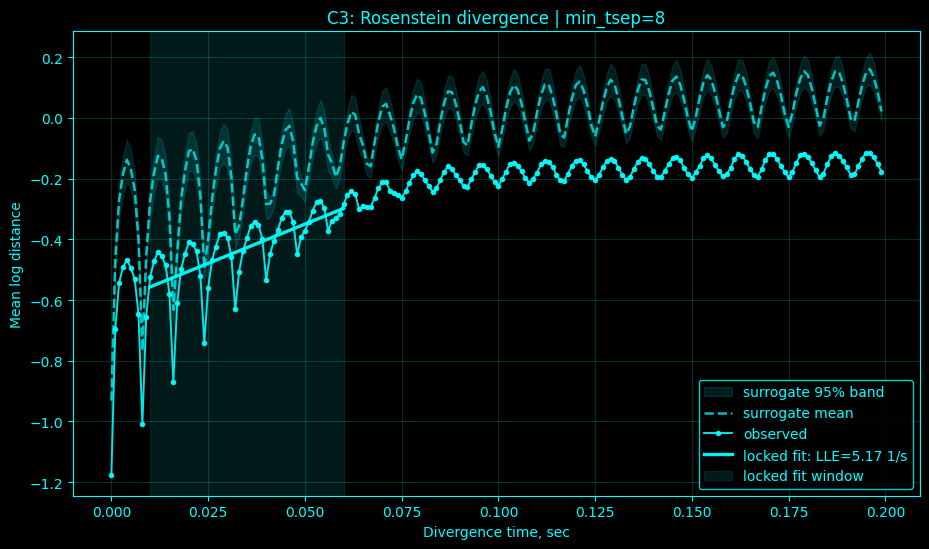

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/01_C3_divergence_tsep8_C3_m10_tau8_nS199_20260603_154926.png


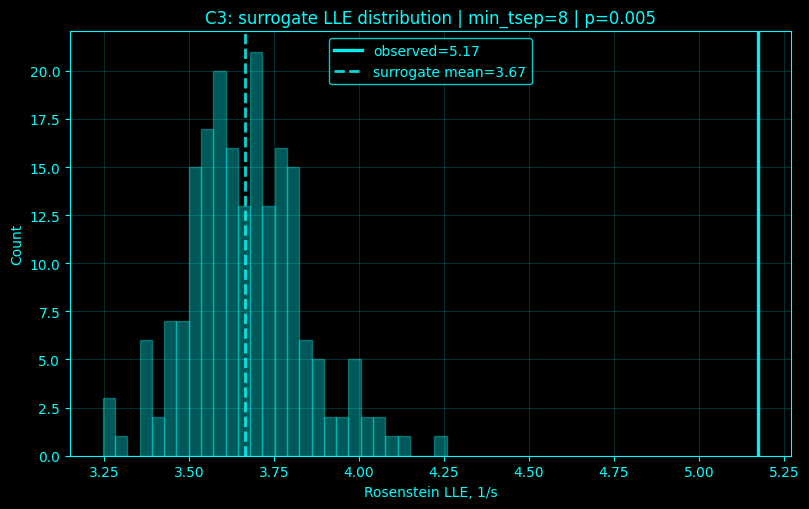

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/02_C3_surrogate_hist_tsep8_C3_m10_tau8_nS199_20260603_154926.png


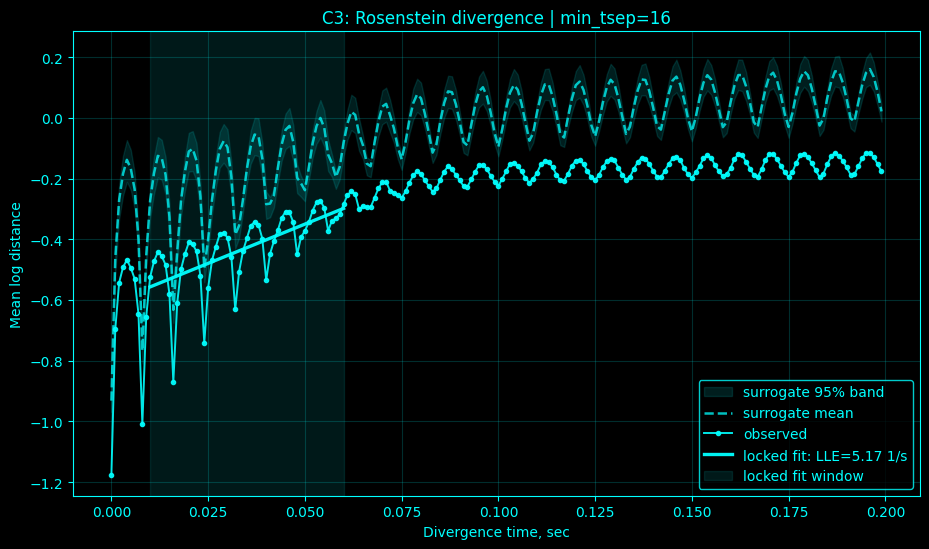

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/01_C3_divergence_tsep16_C3_m10_tau8_nS199_20260603_154926.png


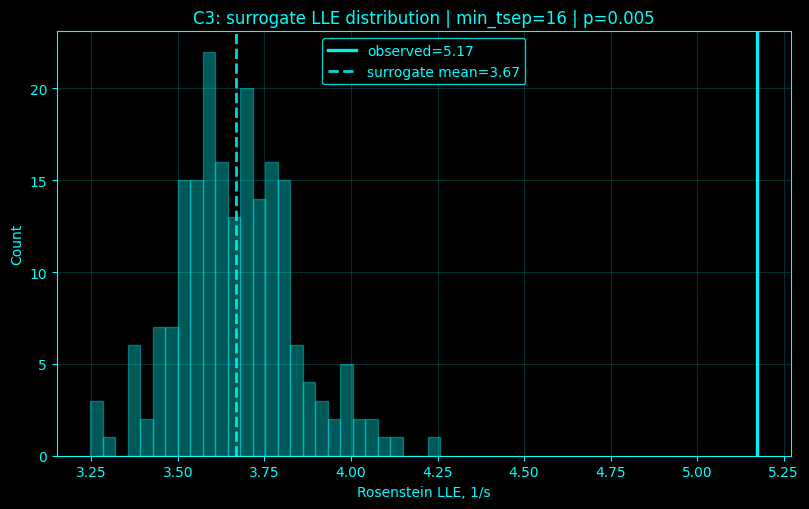

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/02_C3_surrogate_hist_tsep16_C3_m10_tau8_nS199_20260603_154926.png


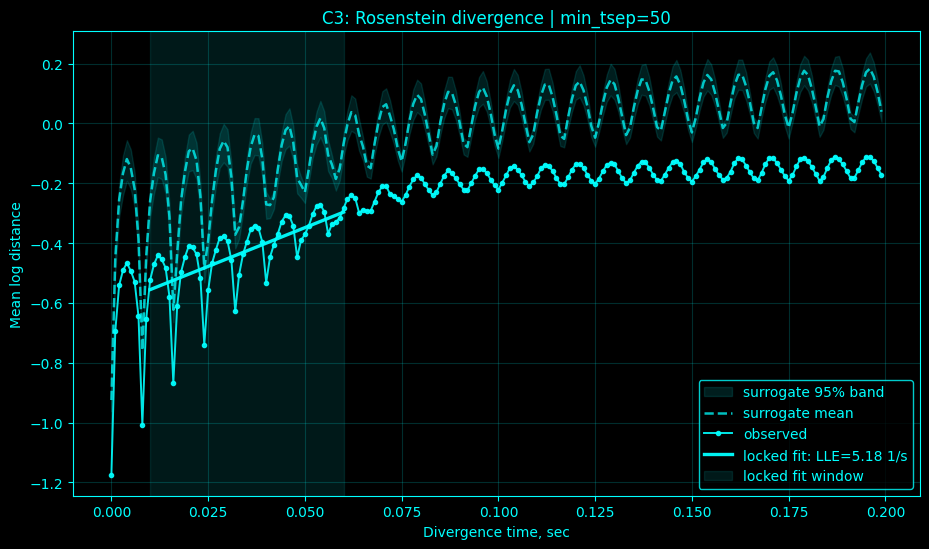

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/01_C3_divergence_tsep50_C3_m10_tau8_nS199_20260603_154926.png


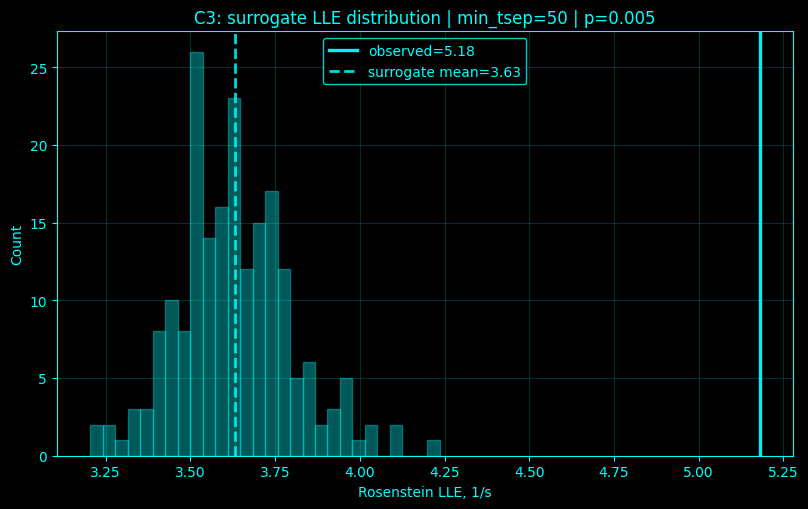

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/02_C3_surrogate_hist_tsep50_C3_m10_tau8_nS199_20260603_154926.png


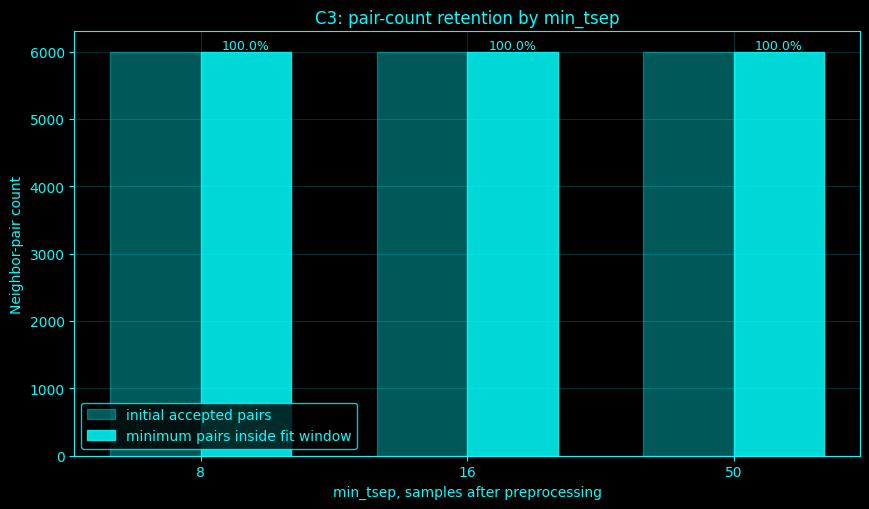

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/03A_C3_pair_count_retention_summary_C3_m10_tau8_nS199_20260603_154926.png


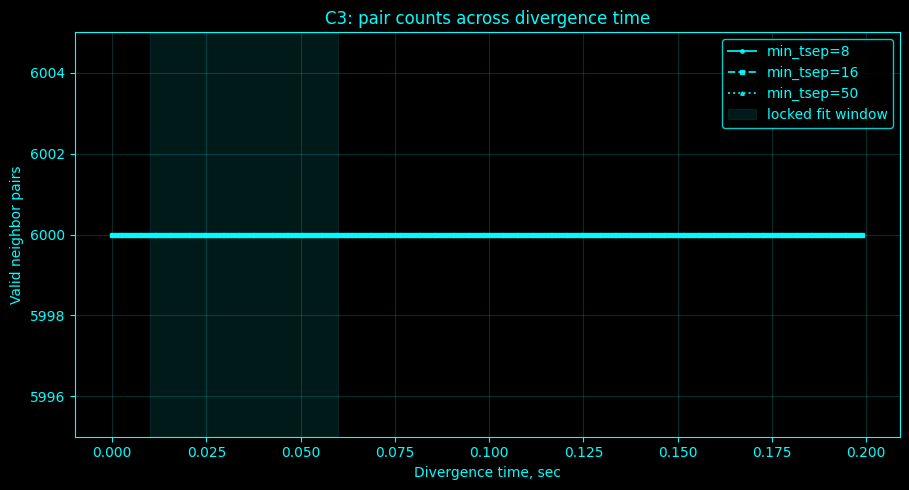

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/03B_C3_pair_counts_zoomed_by_k_C3_m10_tau8_nS199_20260603_154926.png


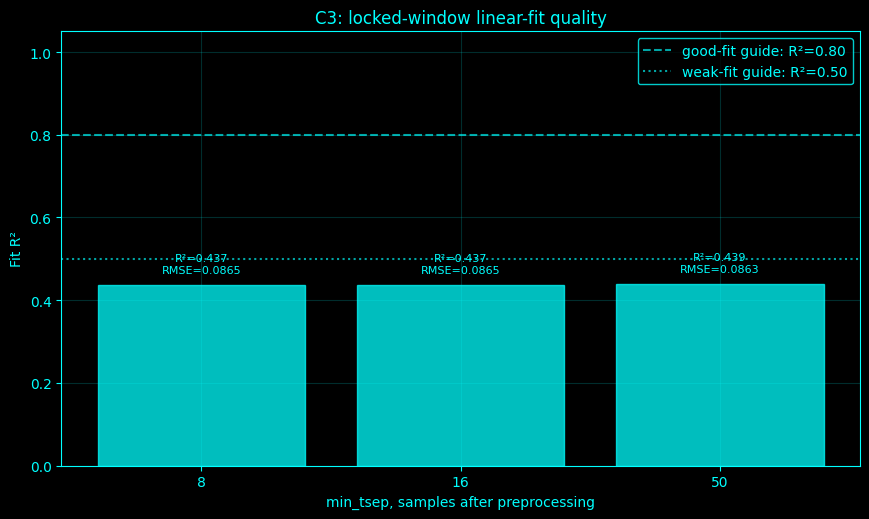

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/04_C3_fit_quality_r2_rmse_by_min_tsep_C3_m10_tau8_nS199_20260603_154926.png


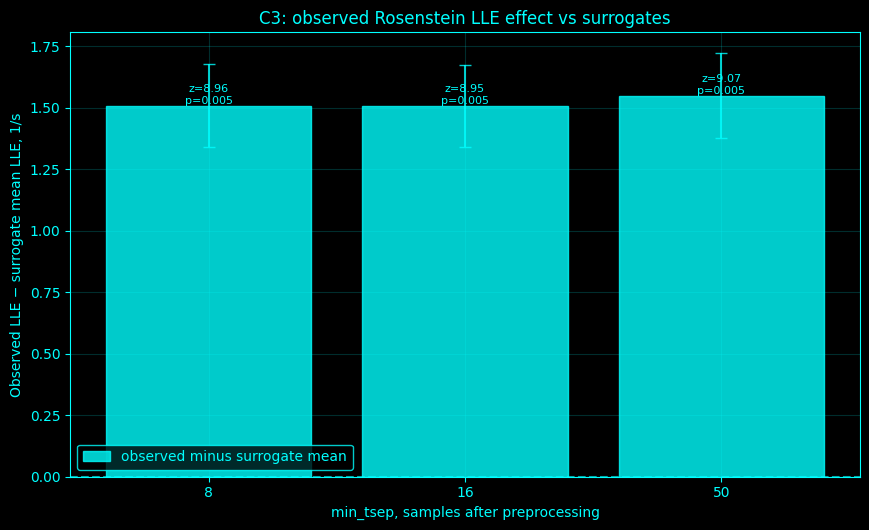

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/05A_C3_LLE_effect_size_vs_surrogates_C3_m10_tau8_nS199_20260603_154926.png


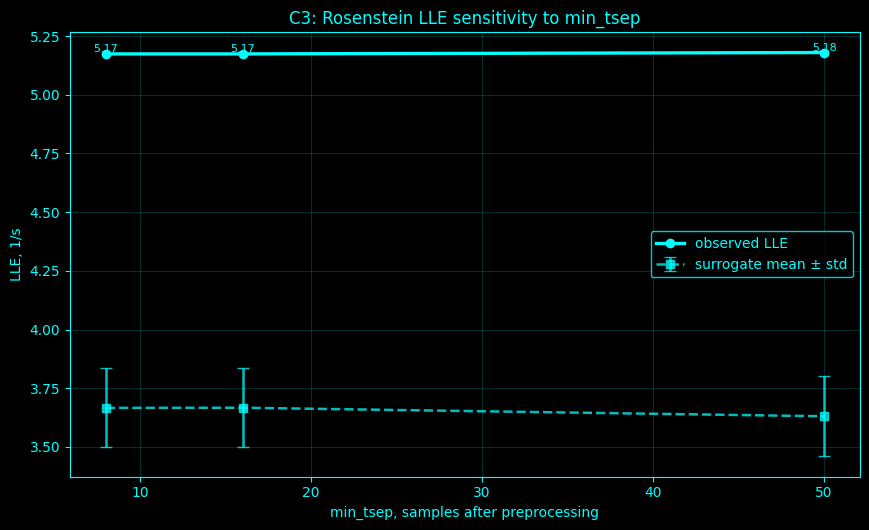

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/05B_C3_LLE_sensitivity_annotated_C3_m10_tau8_nS199_20260603_154926.png

=== Rosenstein more-surrogate summary ===
channel  min_tsep  min_tsep_seconds  LLE_obs  LLE_surr_mean  LLE_surr_std  LLE_surr_q025  LLE_surr_q975  z_obs_vs_surrogates  p_one_surr_ge_obs  p_two_centered  n_surrogates_requested  n_surrogates_completed  fit_r2_obs  fit_rmse_obs  slope_obs_per_sample  fit_intercept_obs  initial_pair_count  fit_window_min_pair_count  fit_window_median_pair_count  final_nonzero_pair_count  pair_retention_percent  fs_eff  emb_dim  tau_eff  kmax_eff  fit_lo_eff  fit_hi_eff  n_ref  k_query_base  decimate_factor  max_samples  iaaft_iters  iaaft_tol
     C3         8             0.008 5.174052       3.666374      0.168285       3.362645       4.024972             8.959079              0.005           0.005                     199                     199    0.436696      0.086498    

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.neighbors import NearestNeighbors

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    "Fp1","Fpz","Fp2","F7","F3","Fz","F4","F8","FC5","FC1","FC2","FC6",
    "M1","T7","C3","Cz","C4","T8","M2","CP5","CP1","CP2","CP6",
    "P7","P3","Pz","P4","P8","POz","O1","Oz","O2"
]

CHANNELS = ["C3"]

fs_original = 1000
t0, t1 = 814.571, 921.515
start_idx, end_idx = int(t0 * fs_original), int(t1 * fs_original)

emb_dim = 10
tau_original = 8

fit_lo_original = 10
fit_hi_original = 60

min_tsep_original_list = [tau_original, 2 * tau_original, 50]

n_ref = 6000
kmax_original = 200
k_query_base = 80
min_pairs_required = 100

n_surrogates = 199
iaaft_iters = 200
iaaft_tol = 1e-4
iaaft_min_iters = 80
iaaft_check_every = 20

seed = 0
n_workers = min(6, max(1, (os.cpu_count() or 2) - 1))

decimate_factor = 1
max_samples = None

standardize = True
linear_detrend = False

results_dir = os.path.join(base_dir, "results", "rosenstein_sweep_locked_window_moreS_fast")
plots_dir = os.path.join(results_dir, "plots")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
tag = f"C3_m{emb_dim}_tau{tau_original}_nS{n_surrogates}_{timestamp}"

OUT_SUMMARY_CSV = os.path.join(results_dir, f"rosenstein_moreS_summary_{tag}.csv")
OUT_SURR_CSV = os.path.join(results_dir, f"rosenstein_moreS_surrogates_{tag}.csv")
OUT_CURVES_CSV = os.path.join(results_dir, f"rosenstein_moreS_curves_{tag}.csv")
OUT_DIAG_CSV = os.path.join(results_dir, f"rosenstein_moreS_diagnostics_{tag}.csv")
OUT_QC_CSV = os.path.join(results_dir, f"rosenstein_moreS_qc_{tag}.csv")
OUT_NPZ = os.path.join(results_dir, f"rosenstein_moreS_arrays_{tag}.npz")
OUT_TXT = os.path.join(results_dir, f"summary_{tag}.txt")

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.grid(True, color=ACCENT, alpha=0.18)

def style_legend(leg):
    if leg is not None:
        leg.get_frame().set_facecolor(BG)
        leg.get_frame().set_edgecolor(ACCENT)
        for t in leg.get_texts():
            t.set_color(ACCENT)

def save_show_close(fig, out_path, dpi=200):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)

def effective_sample_param(value_original, decimate_factor, minimum=1):
    return max(minimum, int(round(float(value_original) / float(decimate_factor))))

def linear_detrend_1d(x):
    x = np.asarray(x, dtype=float)
    t = np.arange(len(x), dtype=float)
    coef = np.polyfit(t, x, 1)
    return x - np.polyval(coef, t)

def preprocess_signal(x, fs, decimate_factor=1, max_samples=None, standardize=True, detrend=False):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = x[np.isfinite(x)]
    fs_eff = float(fs)
    if detrend:
        x = linear_detrend_1d(x)
    if decimate_factor is not None and decimate_factor > 1:
        try:
            from scipy.signal import decimate
            x = decimate(x, int(decimate_factor), ftype="iir", zero_phase=True)
        except Exception:
            x = x[::int(decimate_factor)]
        fs_eff = fs_eff / float(decimate_factor)
    if max_samples is not None and len(x) > max_samples:
        start = max(0, (len(x) - max_samples) // 2)
        stop = start + max_samples
        x = x[start:stop]
    if standardize:
        x = x - np.mean(x)
        x = x / (np.std(x) + 1e-12)
    return x, fs_eff

def load_eeg_array(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing EEG file: {path}")
    arr = np.load(path, allow_pickle=True)
    arr = np.asarray(arr, dtype=float)
    arr = np.squeeze(arr)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {arr.shape}")
    if arr.shape[0] == len(channel_names) and arr.shape[1] != len(channel_names):
        arr = arr.T
    if arr.shape[1] != len(channel_names):
        raise ValueError(f"Expected {len(channel_names)} channels, got shape {arr.shape}")
    return arr

def get_channels_to_run():
    if CHANNELS is None:
        return list(channel_names)
    missing = [ch for ch in CHANNELS if ch not in channel_names]
    if len(missing) > 0:
        raise ValueError(f"Unknown requested channels: {missing}")
    return list(CHANNELS)

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    n = len(x)
    M = n - (m - 1) * tau
    if M <= 2:
        raise ValueError(f"Embedding failed: len={n}, m={m}, tau={tau}")
    return np.column_stack([x[i * tau:i * tau + M] for i in range(m)])

def spectrum_relative_error_from_mag(y, target_mag):
    mag_y = np.abs(np.fft.rfft(y))
    return float(np.linalg.norm(mag_y - target_mag) / (np.linalg.norm(target_mag) + 1e-12))

def iaaft_surrogate_fast(x_sorted, target_mag, n, seed, n_iter=200, tol=1e-4, min_iter=80, check_every=20):
    rng = np.random.default_rng(seed)
    y = rng.permutation(x_sorted)
    final_err = np.nan
    used_iters = 0
    for it in range(1, n_iter + 1):
        Y = np.fft.rfft(y)
        phase = np.exp(1j * np.angle(Y))
        y = np.fft.irfft(target_mag * phase, n=n)
        ranks = np.argsort(y, kind="quicksort")
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
        used_iters = it
        if it >= min_iter and ((it % check_every == 0) or (it == n_iter)):
            final_err = spectrum_relative_error_from_mag(y, target_mag)
            if final_err <= tol:
                break
    if not np.isfinite(final_err):
        final_err = spectrum_relative_error_from_mag(y, target_mag)
    return y, final_err, used_iters

def fit_slope_locked(ks, log_div, fit_lo, fit_hi, fs_eff):
    fit_lo = int(fit_lo)
    fit_hi = int(fit_hi)
    if fit_hi <= fit_lo:
        raise ValueError(f"Invalid fit window: fit_lo={fit_lo}, fit_hi={fit_hi}")
    if fit_hi >= len(ks):
        raise ValueError(f"fit_hi={fit_hi} outside curve length={len(ks)}")
    xw = ks[fit_lo:fit_hi + 1]
    yw = log_div[fit_lo:fit_hi + 1]
    ok = np.isfinite(xw) & np.isfinite(yw)
    xw = xw[ok]
    yw = yw[ok]
    if len(xw) < 5:
        raise ValueError("Too few finite points in fit window.")
    coef = np.polyfit(xw, yw, 1)
    yhat = np.polyval(coef, xw)
    ss_res = float(np.sum((yw - yhat) ** 2))
    ss_tot = float(np.sum((yw - np.mean(yw)) ** 2))
    r2 = float(1.0 - ss_res / (ss_tot + 1e-12))
    rmse = float(np.sqrt(np.mean((yw - yhat) ** 2)))
    slope_per_sample = float(coef[0])
    intercept = float(coef[1])
    lle_per_second = float(slope_per_sample * fs_eff)
    return slope_per_sample, intercept, lle_per_second, r2, rmse

def rosenstein_curves_multi_tsep(x, m, tau, min_tsep_list, n_ref, kmax, seed=0, k_query_base=80, min_pairs_required=100):
    rng = np.random.default_rng(seed)
    X = delay_embed_1d(x, m, tau)
    M = len(X)
    valid_max = M - kmax - 1
    if valid_max <= 10:
        raise ValueError(f"Too few embedded points for kmax={kmax}. Embedded M={M}.")
    all_idx = np.arange(valid_max)
    if len(all_idx) > n_ref:
        ref_idx = np.sort(rng.choice(all_idx, size=n_ref, replace=False))
    else:
        ref_idx = all_idx
    max_tsep = int(max(min_tsep_list))
    k_query = min(M, max(k_query_base, max_tsep + 40, 4 * m + 20))
    nn = NearestNeighbors(n_neighbors=k_query, algorithm="auto").fit(X)
    _, inds = nn.kneighbors(X[ref_idx])
    ks = np.arange(kmax, dtype=int)
    curves = {}
    counts = {}
    pair_counts = {}
    for min_tsep in min_tsep_list:
        min_tsep = int(min_tsep)
        nn_idx = np.full(len(ref_idx), -1, dtype=int)
        for a, i in enumerate(ref_idx):
            for cand in inds[a, 1:]:
                cand = int(cand)
                if cand >= valid_max:
                    continue
                if abs(cand - int(i)) > min_tsep:
                    nn_idx[a] = cand
                    break
        keep = nn_idx >= 0
        ref_keep = ref_idx[keep]
        nn_keep = nn_idx[keep]
        pair_counts[min_tsep] = int(len(ref_keep))
        if len(ref_keep) < min_pairs_required:
            raise ValueError(f"Too few pairs after Theiler exclusion for min_tsep={min_tsep}: {len(ref_keep)} pairs.")
        log_div = np.full(kmax, np.nan, dtype=float)
        count_k = np.zeros(kmax, dtype=int)
        for k in range(kmax):
            i = ref_keep + k
            j = nn_keep + k
            ok = (i < M) & (j < M)
            if not np.any(ok):
                continue
            dist = np.linalg.norm(X[i[ok]] - X[j[ok]], axis=1)
            dist = np.maximum(dist, 1e-12)
            log_div[k] = float(np.mean(np.log(dist)))
            count_k[k] = int(np.sum(ok))
        curves[min_tsep] = log_div
        counts[min_tsep] = count_k
    return ks, curves, counts, pair_counts

def empirical_p_values(obs, svals):
    svals = np.asarray(svals, dtype=float)
    svals = svals[np.isfinite(svals)]
    if len(svals) == 0 or not np.isfinite(obs):
        return np.nan, np.nan, np.nan
    mu = float(np.mean(svals))
    sd = float(np.std(svals, ddof=1) + 1e-12) if len(svals) > 1 else 1e-12
    z = float((obs - mu) / sd)
    p_high = float((np.sum(svals >= obs) + 1.0) / (len(svals) + 1.0))
    p_two_centered = float((np.sum(np.abs(svals - mu) >= abs(obs - mu)) + 1.0) / (len(svals) + 1.0))
    return z, p_high, p_two_centered

def add_fit_line(ax, ks, log_div, fit_lo, fit_hi, slope, intercept, fs_eff, label):
    kfit = ks[fit_lo:fit_hi + 1]
    yfit = slope * kfit + intercept
    ax.plot(kfit / fs_eff, yfit, color=ACCENT, linewidth=2.4, alpha=0.95, label=label)

tau_eff = effective_sample_param(tau_original, decimate_factor, minimum=1)
kmax_eff = effective_sample_param(kmax_original, decimate_factor, minimum=20)
fit_lo_eff = effective_sample_param(fit_lo_original, decimate_factor, minimum=1)
fit_hi_eff = effective_sample_param(fit_hi_original, decimate_factor, minimum=fit_lo_eff + 5)
min_tsep_eff_list = sorted(set([effective_sample_param(v, decimate_factor, minimum=1) for v in min_tsep_original_list]))

if fit_hi_eff >= kmax_eff:
    fit_hi_eff = kmax_eff - 2
if fit_hi_eff <= fit_lo_eff:
    fit_hi_eff = min(kmax_eff - 2, fit_lo_eff + 10)

print("Effective parameters:")
print("  decimate_factor:", decimate_factor)
print("  tau_eff:", tau_eff)
print("  kmax_eff:", kmax_eff)
print("  locked fit window:", fit_lo_eff, fit_hi_eff)
print("  min_tsep_eff_list:", min_tsep_eff_list)
print("  n_surrogates:", n_surrogates)
print("  iaaft_iters:", iaaft_iters)
print("  n_workers:", n_workers)

EEG = load_eeg_array(eeg_path)
channels_to_run = get_channels_to_run()

print("\nLoaded EEG:", eeg_path, flush=True)
print("EEG shape:", EEG.shape, flush=True)
print("Channels:", channels_to_run, flush=True)

summary_records = []
surrogate_records = []
curve_records = []
diagnostic_records = []
qc_records = []

npz_payload = {
    "channels": np.array(channels_to_run, dtype=object),
    "min_tsep_eff_list": np.array(min_tsep_eff_list, dtype=int),
    "tau_eff": np.array([tau_eff], dtype=int),
    "kmax_eff": np.array([kmax_eff], dtype=int),
    "fit_lo_eff": np.array([fit_lo_eff], dtype=int),
    "fit_hi_eff": np.array([fit_hi_eff], dtype=int),
    "fs_original": np.array([fs_original], dtype=float),
    "decimate_factor": np.array([decimate_factor], dtype=int),
    "n_surrogates": np.array([n_surrogates], dtype=int),
    "iaaft_iters": np.array([iaaft_iters], dtype=int),
}

run_start = time.time()

for ch_num, channel in enumerate(channels_to_run, start=1):
    print(f"\n[{ch_num}/{len(channels_to_run)}] Channel {channel}", flush=True)

    ch_i = channel_names.index(channel)
    x_raw = EEG[start_idx:end_idx, ch_i].astype(float)

    x, fs_eff = preprocess_signal(
        x_raw,
        fs=fs_original,
        decimate_factor=decimate_factor,
        max_samples=max_samples,
        standardize=standardize,
        detrend=linear_detrend
    )

    print(f"Loaded {channel}: N={len(x)} | fs_eff={fs_eff:g} Hz | segment=[{t0},{t1}] s", flush=True)
    print(f"LOCKED fit window: k=[{fit_lo_eff},{fit_hi_eff}] ~ [{fit_lo_eff/fs_eff:.4f},{fit_hi_eff/fs_eff:.4f}] s", flush=True)

    ks_obs, obs_curves, obs_counts, obs_pair_counts = rosenstein_curves_multi_tsep(
        x,
        m=emb_dim,
        tau=tau_eff,
        min_tsep_list=min_tsep_eff_list,
        n_ref=n_ref,
        kmax=kmax_eff,
        seed=seed,
        k_query_base=k_query_base,
        min_pairs_required=min_pairs_required
    )

    obs_fit = {}

    for min_tsep in min_tsep_eff_list:
        min_tsep = int(min_tsep)
        ld = obs_curves[min_tsep]
        slope, intercept, lle_obs, r2, rmse = fit_slope_locked(
            ks_obs,
            ld,
            fit_lo_eff,
            fit_hi_eff,
            fs_eff
        )
        obs_fit[min_tsep] = {
            "slope_per_sample": slope,
            "intercept": intercept,
            "lle_per_second": lle_obs,
            "fit_r2": r2,
            "fit_rmse": rmse,
        }
        print(f"Observed | min_tsep={min_tsep} | obs={lle_obs:.6g} 1/s | R2={r2:.4f} | RMSE={rmse:.4g} | pairs={obs_pair_counts[min_tsep]}", flush=True)

    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    n = len(x)

    surr_lle_by_tsep = {int(t): [] for t in min_tsep_eff_list}
    surr_curve_by_tsep = {int(t): [] for t in min_tsep_eff_list}
    surr_errors = []
    surr_iters = []

    def surrogate_worker(s):
        y, final_err, used_iters = iaaft_surrogate_fast(
            x_sorted=x_sorted,
            target_mag=target_mag,
            n=n,
            seed=seed + 10000 * ch_num + s,
            n_iter=iaaft_iters,
            tol=iaaft_tol,
            min_iter=iaaft_min_iters,
            check_every=iaaft_check_every
        )

        ks_s, s_curves, s_counts, s_pair_counts = rosenstein_curves_multi_tsep(
            y,
            m=emb_dim,
            tau=tau_eff,
            min_tsep_list=min_tsep_eff_list,
            n_ref=n_ref,
            kmax=kmax_eff,
            seed=seed + 1000 + s,
            k_query_base=k_query_base,
            min_pairs_required=min_pairs_required
        )

        out = {
            "surrogate_index": int(s + 1),
            "final_error": float(final_err),
            "used_iters": int(used_iters),
            "curves": {},
            "fits": {},
            "pair_counts": {},
        }

        for min_tsep in min_tsep_eff_list:
            min_tsep = int(min_tsep)
            ld_s = s_curves[min_tsep]
            slope_s, intercept_s, lle_s, r2_s, rmse_s = fit_slope_locked(
                ks_s,
                ld_s,
                fit_lo_eff,
                fit_hi_eff,
                fs_eff
            )
            out["curves"][min_tsep] = ld_s
            out["pair_counts"][min_tsep] = int(s_pair_counts[min_tsep])
            out["fits"][min_tsep] = {
                "slope_per_sample": float(slope_s),
                "intercept": float(intercept_s),
                "lle_per_second": float(lle_s),
                "fit_r2": float(r2_s),
                "fit_rmse": float(rmse_s),
            }

        return out

    print(f"Running {n_surrogates} IAAFT surrogates with {n_workers} workers...", flush=True)

    completed = 0
    failed = 0

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(surrogate_worker, s) for s in range(n_surrogates)]

        for fut in as_completed(futures):
            try:
                res = fut.result()
            except Exception as e:
                failed += 1
                print(f"  surrogate ERROR: {type(e).__name__}: {e}", flush=True)
                continue

            sidx = int(res["surrogate_index"])
            surr_errors.append(res["final_error"])
            surr_iters.append(res["used_iters"])

            for min_tsep in min_tsep_eff_list:
                min_tsep = int(min_tsep)
                fit = res["fits"][min_tsep]
                lle_surr = fit["lle_per_second"]

                surr_lle_by_tsep[min_tsep].append(lle_surr)
                surr_curve_by_tsep[min_tsep].append(res["curves"][min_tsep])

                surrogate_records.append({
                    "channel": channel,
                    "surrogate_index": sidx,
                    "min_tsep": min_tsep,
                    "lle_per_second": float(lle_surr),
                    "slope_per_sample": float(fit["slope_per_sample"]),
                    "intercept": float(fit["intercept"]),
                    "fit_r2": float(fit["fit_r2"]),
                    "fit_rmse": float(fit["fit_rmse"]),
                    "iaaft_final_spectrum_relative_error": float(res["final_error"]),
                    "iaaft_iters_used": int(res["used_iters"]),
                    "pair_count": int(res["pair_counts"][min_tsep]),
                })

            completed += 1

            if completed % 25 == 0 or completed + failed == n_surrogates:
                print(f"  completed {completed}/{n_surrogates} surrogates | failed={failed}", flush=True)

    for min_tsep in min_tsep_eff_list:
        min_tsep = int(min_tsep)
        obs = obs_fit[min_tsep]
        lle_obs = obs["lle_per_second"]

        svals = np.asarray(surr_lle_by_tsep[min_tsep], dtype=float)
        svals = svals[np.isfinite(svals)]

        if len(svals) > 0:
            z, p_one, p_two = empirical_p_values(lle_obs, svals)
            surr_mean = float(np.mean(svals))
            surr_std = float(np.std(svals, ddof=1)) if len(svals) > 1 else 0.0
            surr_q025 = float(np.percentile(svals, 2.5))
            surr_q975 = float(np.percentile(svals, 97.5))
        else:
            z, p_one, p_two = np.nan, np.nan, np.nan
            surr_mean, surr_std, surr_q025, surr_q975 = np.nan, np.nan, np.nan, np.nan

        fit_counts = np.asarray(obs_counts[min_tsep][fit_lo_eff:fit_hi_eff + 1], dtype=float)
        all_counts = np.asarray(obs_counts[min_tsep], dtype=float)
        nonzero_counts = all_counts[all_counts > 0]

        summary_records.append({
            "channel": channel,
            "min_tsep": min_tsep,
            "min_tsep_seconds": float(min_tsep / fs_eff),
            "LLE_obs": float(lle_obs),
            "LLE_surr_mean": surr_mean,
            "LLE_surr_std": surr_std,
            "LLE_surr_q025": surr_q025,
            "LLE_surr_q975": surr_q975,
            "z_obs_vs_surrogates": float(z),
            "p_one_surr_ge_obs": float(p_one),
            "p_two_centered": float(p_two),
            "n_surrogates_requested": int(n_surrogates),
            "n_surrogates_completed": int(len(svals)),
            "fit_r2_obs": float(obs["fit_r2"]),
            "fit_rmse_obs": float(obs["fit_rmse"]),
            "slope_obs_per_sample": float(obs["slope_per_sample"]),
            "fit_intercept_obs": float(obs["intercept"]),
            "initial_pair_count": float(all_counts[0]) if len(all_counts) else np.nan,
            "fit_window_min_pair_count": float(np.nanmin(fit_counts)) if len(fit_counts) else np.nan,
            "fit_window_median_pair_count": float(np.nanmedian(fit_counts)) if len(fit_counts) else np.nan,
            "final_nonzero_pair_count": float(nonzero_counts[-1]) if len(nonzero_counts) else np.nan,
            "pair_retention_percent": float(100.0 * np.nanmin(fit_counts) / max(all_counts[0], 1.0)) if len(fit_counts) and len(all_counts) else np.nan,
            "fs_eff": float(fs_eff),
            "emb_dim": int(emb_dim),
            "tau_eff": int(tau_eff),
            "kmax_eff": int(kmax_eff),
            "fit_lo_eff": int(fit_lo_eff),
            "fit_hi_eff": int(fit_hi_eff),
            "n_ref": int(n_ref),
            "k_query_base": int(k_query_base),
            "decimate_factor": int(decimate_factor),
            "max_samples": int(max_samples) if max_samples is not None else -1,
            "iaaft_iters": int(iaaft_iters),
            "iaaft_tol": float(iaaft_tol),
        })

        diagnostic_records.append({
            "channel": channel,
            "min_tsep": min_tsep,
            "initial_pair_count": float(all_counts[0]) if len(all_counts) else np.nan,
            "fit_window_min_pair_count": float(np.nanmin(fit_counts)) if len(fit_counts) else np.nan,
            "fit_window_median_pair_count": float(np.nanmedian(fit_counts)) if len(fit_counts) else np.nan,
            "final_nonzero_pair_count": float(nonzero_counts[-1]) if len(nonzero_counts) else np.nan,
            "pair_retention_percent": float(100.0 * np.nanmin(fit_counts) / max(all_counts[0], 1.0)) if len(fit_counts) and len(all_counts) else np.nan,
            "fit_r2_obs": float(obs["fit_r2"]),
            "fit_rmse_obs": float(obs["fit_rmse"]),
            "LLE_obs": float(lle_obs),
            "LLE_surr_mean": surr_mean,
            "LLE_surr_std": surr_std,
            "delta_LLE": float(lle_obs - surr_mean) if np.isfinite(surr_mean) else np.nan,
            "z_obs_vs_surrogates": float(z),
            "p_one_surr_ge_obs": float(p_one),
        })

        curve_stack = np.asarray(surr_curve_by_tsep[min_tsep], dtype=float)

        for k in range(kmax_eff):
            rec = {
                "channel": channel,
                "min_tsep": min_tsep,
                "k": int(k),
                "time_seconds": float(k / fs_eff),
                "observed_log_div": float(obs_curves[min_tsep][k]),
                "observed_count": int(obs_counts[min_tsep][k]),
            }

            if curve_stack.size > 0:
                rec.update({
                    "surrogate_mean_log_div": float(np.nanmean(curve_stack[:, k])),
                    "surrogate_std_log_div": float(np.nanstd(curve_stack[:, k])),
                    "surrogate_q025_log_div": float(np.nanpercentile(curve_stack[:, k], 2.5)),
                    "surrogate_q975_log_div": float(np.nanpercentile(curve_stack[:, k], 97.5)),
                })
            else:
                rec.update({
                    "surrogate_mean_log_div": np.nan,
                    "surrogate_std_log_div": np.nan,
                    "surrogate_q025_log_div": np.nan,
                    "surrogate_q975_log_div": np.nan,
                })

            curve_records.append(rec)

    qc_records.append({
        "channel": channel,
        "n_samples_used": int(len(x)),
        "fs_eff": float(fs_eff),
        "duration_seconds_used": float(len(x) / fs_eff),
        "x_mean": float(np.mean(x)),
        "x_std": float(np.std(x)),
        "x_min": float(np.min(x)),
        "x_q01": float(np.percentile(x, 1)),
        "x_q25": float(np.percentile(x, 25)),
        "x_median": float(np.median(x)),
        "x_q75": float(np.percentile(x, 75)),
        "x_q99": float(np.percentile(x, 99)),
        "x_max": float(np.max(x)),
        "mean_iaaft_error": float(np.mean(surr_errors)) if len(surr_errors) else np.nan,
        "max_iaaft_error": float(np.max(surr_errors)) if len(surr_errors) else np.nan,
        "mean_iaaft_iters_used": float(np.mean(surr_iters)) if len(surr_iters) else np.nan,
        "max_iaaft_iters_used": int(np.max(surr_iters)) if len(surr_iters) else -1,
        "surrogates_completed": int(completed),
        "surrogates_failed": int(failed),
    })

    npz_payload[f"{channel}_ks"] = ks_obs

    for min_tsep in min_tsep_eff_list:
        min_tsep = int(min_tsep)
        npz_payload[f"{channel}_obs_log_div_tsep{min_tsep}"] = obs_curves[min_tsep]
        npz_payload[f"{channel}_obs_counts_tsep{min_tsep}"] = obs_counts[min_tsep]

        if len(surr_curve_by_tsep[min_tsep]) > 0:
            npz_payload[f"{channel}_surr_log_div_tsep{min_tsep}"] = np.asarray(surr_curve_by_tsep[min_tsep], dtype=float)
            npz_payload[f"{channel}_surr_lle_tsep{min_tsep}"] = np.asarray(surr_lle_by_tsep[min_tsep], dtype=float)

    for min_tsep in min_tsep_eff_list:
        min_tsep = int(min_tsep)
        ld = obs_curves[min_tsep]
        obs = obs_fit[min_tsep]
        curve_stack = np.asarray(surr_curve_by_tsep[min_tsep], dtype=float)

        fig, ax = plt.subplots(figsize=(9.4, 5.6), facecolor=BG)
        style_ax(ax)

        if curve_stack.size > 0:
            s_mean = np.nanmean(curve_stack, axis=0)
            s_q025 = np.nanpercentile(curve_stack, 2.5, axis=0)
            s_q975 = np.nanpercentile(curve_stack, 97.5, axis=0)

            ax.fill_between(
                ks_obs / fs_eff,
                s_q025,
                s_q975,
                color=ACCENT,
                alpha=0.12,
                label="surrogate 95% band"
            )

            ax.plot(
                ks_obs / fs_eff,
                s_mean,
                color=ACCENT,
                linestyle="--",
                linewidth=1.8,
                alpha=0.75,
                label="surrogate mean"
            )

        ax.plot(
            ks_obs / fs_eff,
            ld,
            color=ACCENT,
            marker="o",
            markersize=3,
            linewidth=1.4,
            alpha=0.9,
            label="observed"
        )

        add_fit_line(
            ax,
            ks_obs,
            ld,
            fit_lo_eff,
            fit_hi_eff,
            obs["slope_per_sample"],
            obs["intercept"],
            fs_eff,
            label=f"locked fit: LLE={obs['lle_per_second']:.3g} 1/s"
        )

        ax.axvspan(
            fit_lo_eff / fs_eff,
            fit_hi_eff / fs_eff,
            color=ACCENT,
            alpha=0.10,
            label="locked fit window"
        )

        ax.set_title(f"{channel}: Rosenstein divergence | min_tsep={min_tsep}")
        ax.set_xlabel("Divergence time, sec")
        ax.set_ylabel("Mean log distance")

        leg = ax.legend(loc="best")
        style_legend(leg)

        plot_path = os.path.join(plots_dir, f"01_{channel}_divergence_tsep{min_tsep}_{tag}.png")
        save_show_close(fig, plot_path)

        if len(surr_lle_by_tsep[min_tsep]) > 0:
            svals = np.asarray(surr_lle_by_tsep[min_tsep], dtype=float)
            row = [r for r in summary_records if r["channel"] == channel and r["min_tsep"] == min_tsep][0]
            p_one = row["p_one_surr_ge_obs"]

            fig, ax = plt.subplots(figsize=(8.2, 5.2), facecolor=BG)
            style_ax(ax)

            ax.hist(
                svals,
                bins=min(28, max(10, int(np.sqrt(len(svals)) * 2))),
                color=ACCENT,
                edgecolor=ACCENT,
                alpha=0.35
            )

            ax.axvline(
                obs["lle_per_second"],
                color=ACCENT,
                linewidth=2.4,
                alpha=0.95,
                label=f"observed={obs['lle_per_second']:.3g}"
            )

            ax.axvline(
                np.mean(svals),
                color=ACCENT,
                linestyle="--",
                linewidth=2.0,
                alpha=0.85,
                label=f"surrogate mean={np.mean(svals):.3g}"
            )

            ax.set_title(f"{channel}: surrogate LLE distribution | min_tsep={min_tsep} | p={p_one:.4g}")
            ax.set_xlabel("Rosenstein LLE, 1/s")
            ax.set_ylabel("Count")

            leg = ax.legend()
            style_legend(leg)

            plot_path = os.path.join(plots_dir, f"02_{channel}_surrogate_hist_tsep{min_tsep}_{tag}.png")
            save_show_close(fig, plot_path)

    ch_summary = pd.DataFrame([r for r in summary_records if r["channel"] == channel]).sort_values("min_tsep")

    count_diag_df = ch_summary[[
        "min_tsep",
        "initial_pair_count",
        "fit_window_min_pair_count",
        "fit_window_median_pair_count",
        "final_nonzero_pair_count",
        "pair_retention_percent",
    ]].copy()

    fit_diag_df = ch_summary[[
        "min_tsep",
        "fit_r2_obs",
        "fit_rmse_obs",
        "LLE_obs",
    ]].copy()

    fig, ax = plt.subplots(figsize=(8.8, 5.2), facecolor=BG)
    style_ax(ax)

    xpos = np.arange(len(count_diag_df))
    bar_width = 0.34

    ax.bar(
        xpos - bar_width / 2,
        count_diag_df["initial_pair_count"],
        width=bar_width,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.35,
        label="initial accepted pairs"
    )

    ax.bar(
        xpos + bar_width / 2,
        count_diag_df["fit_window_min_pair_count"],
        width=bar_width,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.85,
        label="minimum pairs inside fit window"
    )

    for i, row in count_diag_df.iterrows():
        ax.text(
            i + bar_width / 2,
            row["fit_window_min_pair_count"],
            f"{row['pair_retention_percent']:.1f}%",
            color=ACCENT,
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_xticks(xpos)
    ax.set_xticklabels(count_diag_df["min_tsep"].astype(int).astype(str).values)
    ax.set_title(f"{channel}: pair-count retention by min_tsep")
    ax.set_xlabel("min_tsep, samples after preprocessing")
    ax.set_ylabel("Neighbor-pair count")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"03A_{channel}_pair_count_retention_summary_{tag}.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(9.2, 5.0), facecolor=BG)
    style_ax(ax)

    line_styles = ["-", "--", ":"]
    markers = ["o", "s", "^"]

    for idx, min_tsep in enumerate(min_tsep_eff_list):
        min_tsep = int(min_tsep)
        ct = np.asarray(obs_counts[min_tsep], dtype=float)

        ax.plot(
            ks_obs / fs_eff,
            ct,
            color=ACCENT,
            linestyle=line_styles[idx % len(line_styles)],
            marker=markers[idx % len(markers)],
            markersize=2.5,
            linewidth=1.4,
            alpha=0.85,
            label=f"min_tsep={min_tsep}"
        )

    ax.axvspan(
        fit_lo_eff / fs_eff,
        fit_hi_eff / fs_eff,
        color=ACCENT,
        alpha=0.10,
        label="locked fit window"
    )

    all_counts = np.concatenate([np.asarray(obs_counts[int(t)], dtype=float) for t in min_tsep_eff_list])
    finite_counts = all_counts[np.isfinite(all_counts)]

    if len(finite_counts) > 0:
        cmin = float(np.nanmin(finite_counts))
        cmax = float(np.nanmax(finite_counts))
        pad = max(5.0, 0.03 * max(abs(cmax - cmin), 1.0))
        ax.set_ylim(cmin - pad, cmax + pad)

    ax.set_title(f"{channel}: pair counts across divergence time")
    ax.set_xlabel("Divergence time, sec")
    ax.set_ylabel("Valid neighbor pairs")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"03B_{channel}_pair_counts_zoomed_by_k_{tag}.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(8.8, 5.3), facecolor=BG)
    style_ax(ax)

    xpos = np.arange(len(fit_diag_df))

    ax.bar(
        xpos,
        fit_diag_df["fit_r2_obs"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.75
    )

    ax.axhline(0.80, color=ACCENT, linestyle="--", alpha=0.65, label="good-fit guide: R²=0.80")
    ax.axhline(0.50, color=ACCENT, linestyle=":", alpha=0.65, label="weak-fit guide: R²=0.50")

    for i, row in fit_diag_df.iterrows():
        ax.text(
            i,
            row["fit_r2_obs"] + 0.025,
            f"R²={row['fit_r2_obs']:.3f}\nRMSE={row['fit_rmse_obs']:.3g}",
            color=ACCENT,
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_xticks(xpos)
    ax.set_xticklabels(fit_diag_df["min_tsep"].astype(int).astype(str).values)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{channel}: locked-window linear-fit quality")
    ax.set_xlabel("min_tsep, samples after preprocessing")
    ax.set_ylabel("Fit R²")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, loc="upper right")
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"04_{channel}_fit_quality_r2_rmse_by_min_tsep_{tag}.png")
    save_show_close(fig, plot_path)

    effect_df = ch_summary.copy()
    effect_df["delta_LLE"] = effect_df["LLE_obs"] - effect_df["LLE_surr_mean"]

    fig, ax = plt.subplots(figsize=(8.8, 5.4), facecolor=BG)
    style_ax(ax)

    xpos = np.arange(len(effect_df))

    ax.bar(
        xpos,
        effect_df["delta_LLE"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.8,
        label="observed minus surrogate mean"
    )

    if effect_df["LLE_surr_std"].notna().any():
        ax.errorbar(
            xpos,
            effect_df["delta_LLE"],
            yerr=effect_df["LLE_surr_std"],
            fmt="none",
            ecolor=ACCENT,
            elinewidth=1.5,
            capsize=4,
            alpha=0.8
        )

    ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.65)

    for i, row in effect_df.iterrows():
        pval = row["p_one_surr_ge_obs"] if np.isfinite(row["p_one_surr_ge_obs"]) else np.nan
        zval = row["z_obs_vs_surrogates"] if np.isfinite(row["z_obs_vs_surrogates"]) else np.nan
        ax.text(
            i,
            row["delta_LLE"],
            f"z={zval:.2f}\np={pval:.4g}",
            color=ACCENT,
            ha="center",
            va="bottom" if row["delta_LLE"] >= 0 else "top",
            fontsize=8
        )

    ax.set_xticks(xpos)
    ax.set_xticklabels(effect_df["min_tsep"].astype(int).astype(str).values)
    ax.set_title(f"{channel}: observed Rosenstein LLE effect vs surrogates")
    ax.set_xlabel("min_tsep, samples after preprocessing")
    ax.set_ylabel("Observed LLE − surrogate mean LLE, 1/s")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"05A_{channel}_LLE_effect_size_vs_surrogates_{tag}.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(8.8, 5.4), facecolor=BG)
    style_ax(ax)

    ax.plot(
        effect_df["min_tsep"],
        effect_df["LLE_obs"],
        color=ACCENT,
        marker="o",
        linewidth=2.4,
        label="observed LLE"
    )

    if effect_df["LLE_surr_mean"].notna().any():
        ax.errorbar(
            effect_df["min_tsep"],
            effect_df["LLE_surr_mean"],
            yerr=effect_df["LLE_surr_std"],
            color=ACCENT,
            marker="s",
            linestyle="--",
            linewidth=1.8,
            capsize=4,
            alpha=0.75,
            label="surrogate mean ± std"
        )

    for _, row in effect_df.iterrows():
        ax.text(
            row["min_tsep"],
            row["LLE_obs"],
            f"{row['LLE_obs']:.2f}",
            color=ACCENT,
            fontsize=8,
            ha="center",
            va="bottom"
        )

    ax.set_title(f"{channel}: Rosenstein LLE sensitivity to min_tsep")
    ax.set_xlabel("min_tsep, samples after preprocessing")
    ax.set_ylabel("LLE, 1/s")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"05B_{channel}_LLE_sensitivity_annotated_{tag}.png")
    save_show_close(fig, plot_path)

summary_df = pd.DataFrame(summary_records)
surrogate_df = pd.DataFrame(surrogate_records)
curve_df = pd.DataFrame(curve_records)
diagnostic_df = pd.DataFrame(diagnostic_records)
qc_df = pd.DataFrame(qc_records)

summary_df.to_csv(OUT_SUMMARY_CSV, index=False)
surrogate_df.to_csv(OUT_SURR_CSV, index=False)
curve_df.to_csv(OUT_CURVES_CSV, index=False)
diagnostic_df.to_csv(OUT_DIAG_CSV, index=False)
qc_df.to_csv(OUT_QC_CSV, index=False)

npz_payload["summary_json"] = np.array([summary_df.to_json(orient="records")], dtype=object)
npz_payload["surrogate_json"] = np.array([surrogate_df.to_json(orient="records")], dtype=object)
npz_payload["curve_json"] = np.array([curve_df.to_json(orient="records")], dtype=object)
npz_payload["diagnostic_json"] = np.array([diagnostic_df.to_json(orient="records")], dtype=object)
npz_payload["qc_json"] = np.array([qc_df.to_json(orient="records")], dtype=object)

np.savez_compressed(OUT_NPZ, **npz_payload)

with open(OUT_TXT, "w") as f:
    f.write("Fast More-Surrogate Rosenstein Sweep with Locked Fit Window\n")
    f.write("==========================================================\n\n")
    f.write(f"timestamp={timestamp}\n")
    f.write(f"eeg_path={eeg_path}\n")
    f.write(f"channels={channels_to_run}\n")
    f.write(f"segment=[{t0},{t1}] sec\n")
    f.write(f"fs_original={fs_original}\n")
    f.write(f"decimate_factor={decimate_factor}\n")
    f.write(f"emb_dim={emb_dim}\n")
    f.write(f"tau_eff={tau_eff}\n")
    f.write(f"kmax_eff={kmax_eff}\n")
    f.write(f"min_tsep_eff_list={min_tsep_eff_list}\n")
    f.write(f"locked_fit_window_eff=[{fit_lo_eff},{fit_hi_eff}]\n")
    f.write(f"n_ref={n_ref}\n")
    f.write(f"k_query_base={k_query_base}\n")
    f.write(f"n_surrogates={n_surrogates}\n")
    f.write(f"iaaft_iters={iaaft_iters}\n")
    f.write(f"iaaft_tol={iaaft_tol}\n")
    f.write(f"n_workers={n_workers}\n\n")
    f.write("Summary:\n")
    f.write(summary_df.to_string(index=False))
    f.write("\n\nDiagnostics:\n")
    f.write(diagnostic_df.to_string(index=False))
    f.write("\n\nQC:\n")
    f.write(qc_df.to_string(index=False))

print("\n=== Rosenstein more-surrogate summary ===")
print(summary_df.to_string(index=False))

print("\nDiagnostics:")
print(diagnostic_df.to_string(index=False))

print("\nQC:")
print(qc_df.to_string(index=False))

print("\nSaved outputs:")
print("Summary CSV:", OUT_SUMMARY_CSV)
print("Surrogate CSV:", OUT_SURR_CSV)
print("Curve CSV:", OUT_CURVES_CSV)
print("Diagnostics CSV:", OUT_DIAG_CSV)
print("QC CSV:", OUT_QC_CSV)
print("NPZ:", OUT_NPZ)
print("TXT:", OUT_TXT)
print("Plots:", plots_dir)
print(f"Elapsed: {(time.time() - run_start) / 60:.2f} minutes")
print("Done.")

### Robust Rosenstein Window Sweep

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block provides a reproducible window-robustness workflow for Rosenstein largest-Lyapunov-exponent estimation. It loads one EEG segment from channel
            <code>C3</code>, reconstructs a delay embedding, estimates the observed largest Lyapunov exponent (LLE) with the Rosenstein method, repeats the same
            calculation on <code>199</code> IAAFT surrogates, and compares results across several early-time linear fit windows. The key intent is to test whether the
            estimated LLE and its surrogate-based significance remain stable when the slope is fit over different short-time divergence regions rather than relying on a
            single arbitrary window.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            The Rosenstein method estimates the largest Lyapunov exponent from the growth of distances between nearby trajectories in reconstructed state space. If
            <code>d(k)</code> denotes the average separation after <code>k</code> forward steps, then in an exponential-divergence regime:
        </p>
        \[
            d(k)\approx d(0)e^{\lambda k\Delta t}
        \]
        <p>
            Taking logarithms gives an approximately linear relation:
        </p>
        \[
            \log d(k)\approx \log d(0)+\lambda k\Delta t
        \]
        <p>
            Therefore, the slope of <code>log d(k)</code> versus <code>k</code> estimates <code>\(\lambda\Delta t\)</code>. Since the code multiplies the fitted slope
            by the sampling rate <code>fs</code>, the final reported largest Lyapunov exponent is expressed in physical units of <code>1/s</code>.
        </p>
        <h2>Delay Embedding and Temporal Exclusion</h2>
        <p>
            The signal is reconstructed in delay-coordinate space using embedding dimension <code>m=10</code> and delay <code>\(\tau=8\)</code>, so each embedded state
            has the form:
        </p>
        \[
            X_t=[x_t,\;x_{t+\tau},\;x_{t+2\tau},\;\dots,\;x_{t+(m-1)\tau}]
        \]
        <p>
            Nearest neighbors are then found in this reconstructed space. To reduce trivial temporal correlation, pairs are required to satisfy a minimum time
            separation <code>min_tsep=8</code>. This acts like a Theiler-style exclusion so that neighbors are not chosen purely because they are adjacent in time.
        </p>
        <h2>Data Model and Window Sweep Purpose</h2>
        <p>
            The script expects a multichannel EEG array in <code>eeg_data_with_channels.npy</code>, where rows are time samples and columns correspond to the listed
            EEG channels. It extracts channel <code>C3</code> over the interval <code>[814.571, 921.515]</code> seconds at <code>1000 Hz</code>, standardizes the
            resulting scalar time series, and then evaluates four candidate early-time fit windows:
            <ul>
                <li><code>(5,30)</code>,</li>
                <li><code>(10,60)</code>,</li>
                <li><code>(10,80)</code>,</li>
                <li><code>(20,100)</code>.</li>
            </ul>
            The purpose of this sweep is to test whether the inferred LLE is robust to reasonable changes in the chosen linear region of the divergence curve.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Load</b> the selected EEG channel and extract the target no-stimulation segment.</li>
                <li><b>Standardize</b> the scalar signal to zero mean and unit variance.</li>
                <li><b>Embed</b> the signal in delay-coordinate space with <code>m=10</code> and <code>tau=8</code>.</li>
                <li><b>Estimate</b> the observed Rosenstein LLE for each candidate fit window.</li>
                <li><b>Generate</b> <code>199</code> IAAFT surrogates for the same signal.</li>
                <li><b>Compute</b> the Rosenstein LLE for every surrogate using the same fit window.</li>
                <li><b>Compare</b> the observed LLE against the surrogate distribution using a one-sided p-value.</li>
                <li><b>Summarize</b> all windows in printed output and a final plot of observed LLE versus fit window.</li>
                <li><b>Save</b> the results to a timestamped <code>.npz</code> file.</li>
            </ol>
            This makes the code both an LLE-estimation script and a sensitivity analysis for the choice of fitting interval.
        </p>
        <h2>IAAFT Surrogates and Null Hypothesis</h2>
        <p>
            The surrogate generator uses the IAAFT procedure, which iteratively enforces two properties of the original signal:
            <ul>
                <li><b>Amplitude preservation:</b> the surrogate matches the original amplitude distribution through rank-order remapping.</li>
                <li><b>Spectral preservation:</b> the surrogate approximately matches the original Fourier magnitude spectrum.</li>
            </ul>
            These surrogates provide a constrained null model that preserves linear autocorrelation structure and histogram shape while disrupting nonlinear temporal
            organization. Comparing the observed LLE to this surrogate distribution helps assess whether the divergence estimate is unusually large relative to a
            linearized alternative.
        </p>
        <h2>Hypothesis Test and Interpretability</h2>
        <p>
            For each fit window, the code computes a one-sided empirical p-value as the fraction of surrogate LLE values that are greater than or equal to the observed
            LLE:
        </p>
        \[
            p=\mathrm{mean}\big(D_{\mathrm{surr}}\ge D_{\mathrm{obs}}\big)
        \]
        <p>
            where <code>D</code> here denotes the estimated Rosenstein LLE. A small p-value indicates that few surrogates produce an LLE as large as the observed one,
            suggesting that the observed divergence is stronger than expected under the surrogate null model.
        </p>
        <h2>Axis Semantics</h2>
        <p>
            <ul>
                <li><b>x-axis in the final plot:</b> the tested fit-window labels in sample units, such as <code>5-30</code> or <code>10-60</code>.</li>
                <li><b>y-axis in the final plot:</b> the observed Rosenstein LLE in <code>1/s</code> for each window.</li>
                <li><b>Printed summary columns:</b> fit-window start, fit-window end, observed LLE, surrogate mean, surrogate standard deviation, and p-value.</li>
            </ul>
            The plot therefore shows how the observed LLE changes as the chosen early-time fitting region is varied, while the printed summary adds the surrogate-based
            statistical comparison for each window.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This view is most useful for:
            <ul>
                <li>Checking whether the Rosenstein LLE estimate is stable across plausible early-time fit windows,</li>
                <li>Seeing whether surrogate significance depends strongly on where the linear slope is measured,</li>
                <li>Identifying windows that produce unusually inflated or unstable LLE values,</li>
                <li>Providing a sensitivity analysis before selecting one final reporting window for downstream work.</li>
            </ul>
            If both the observed LLE and the surrogate comparison are reasonably consistent across windows, confidence in the robustness of the result is stronger. If
            they vary substantially, then the LLE estimate may be highly window-dependent and should be interpreted more cautiously.
        </p>
        <h2>Reproducibility Tip</h2>
        <p>
            The script fixes the channel, segment, embedding parameters, surrogate count, and tested fit windows directly in the configuration block, and it saves the
            full result table to a timestamped <code>.npz</code> file. This makes the window-robustness analysis easy to rerun and audit later without ambiguity about
            which settings were used.
        </p>
    </div>
</div>

Effective parameters:
  decimate_factor: 1
  tau_eff: 8
  min_tsep_eff: 8
  kmax_eff: 200
  windows_eff: [(5, 30), (10, 60), (10, 80), (20, 100)]
  n_surrogates: 199
  iaaft_iters: 200
  n_workers: 6

Loaded EEG: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
EEG shape: (4227788, 32)
Channels: ['C3']

[1/1] Channel C3
Loaded C3: N=106944 | fs_eff=1000 Hz | segment=[814.571,921.515] s
Observed window fits:
  k=5-30 | LLE=8.1218 1/s | R2=0.1691 | RMSE=0.135
  k=10-60 | LLE=5.17405 1/s | R2=0.4367 | RMSE=0.0865
  k=10-80 | LLE=5.17492 1/s | R2=0.6684 | RMSE=0.07469
  k=20-100 | LLE=4.30573 1/s | R2=0.7498 | RMSE=0.05816
Running 199 IAAFT surrogates with 6 workers...
  completed 25/199 surrogates | failed=0
  completed 50/199 surrogates | failed=0
  completed 75/199 surrogates | failed=0
  completed 100/199 surrogates | failed=0
  completed 125/199 surrogates | failed=0
  completed 150/199 surrogates | failed=0
  completed 175/199 surrogates | failed=0
  comple

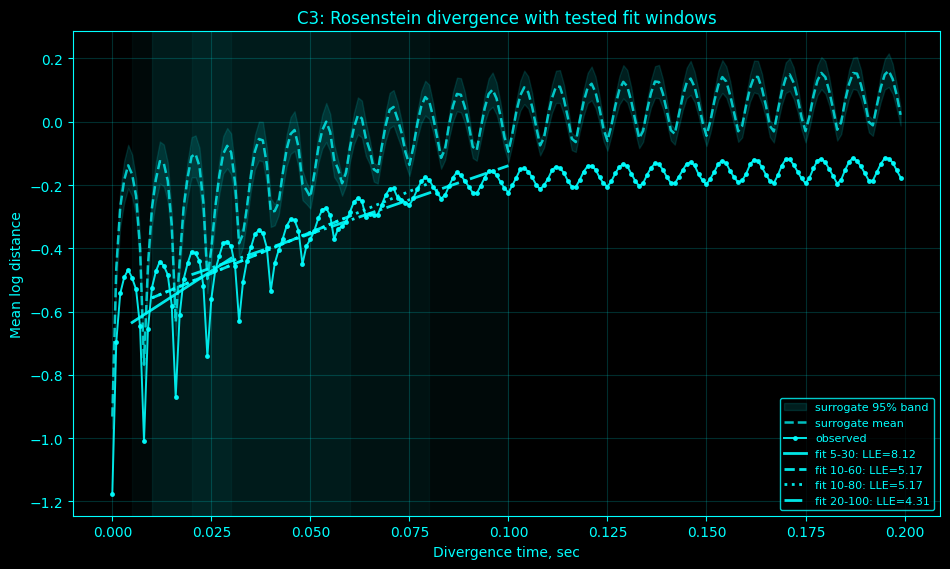

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_window_robustness_fast/plots/01_C3_divergence_fit_windows_C3_m10_tau8_tsep8_nS199_20260603_160047.png


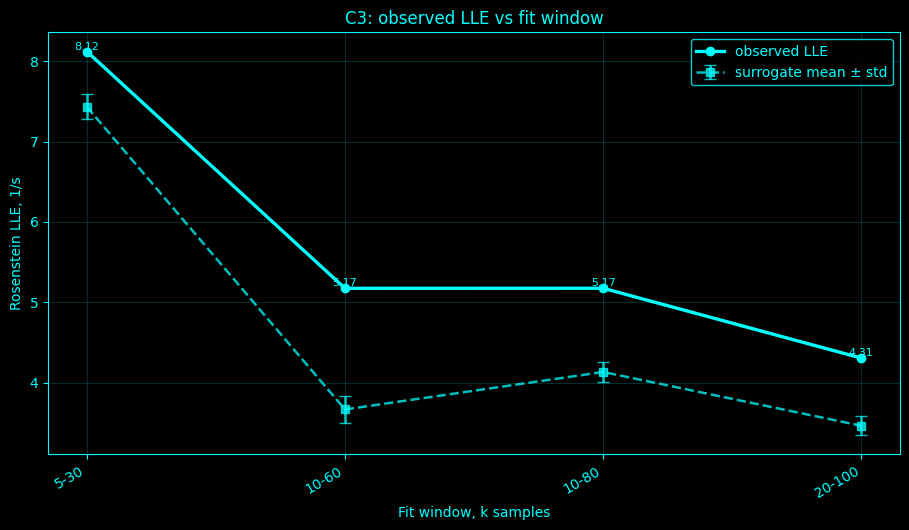

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_window_robustness_fast/plots/02_C3_LLE_vs_fit_window_C3_m10_tau8_tsep8_nS199_20260603_160047.png


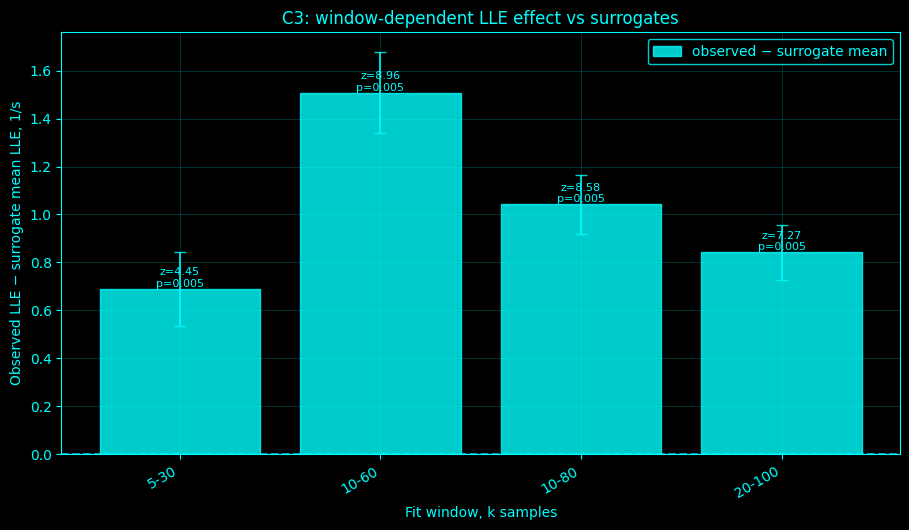

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_window_robustness_fast/plots/03_C3_LLE_effect_size_by_window_C3_m10_tau8_tsep8_nS199_20260603_160047.png


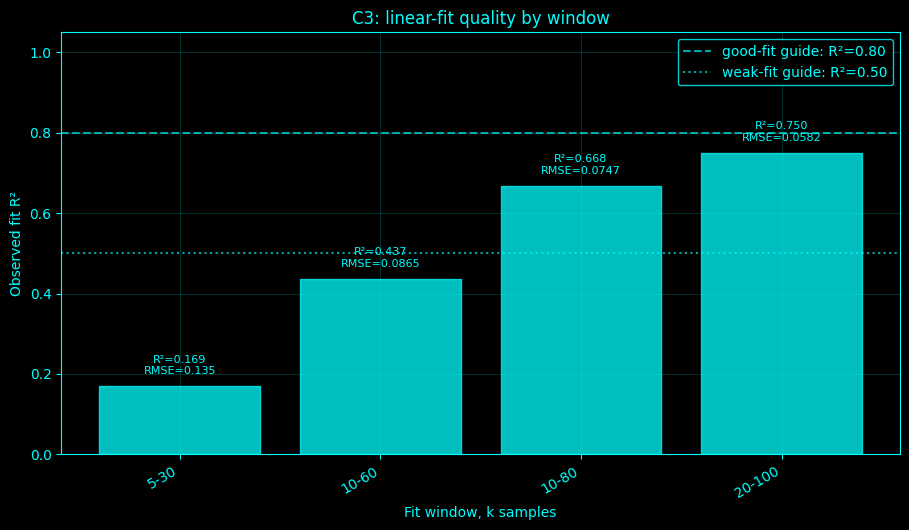

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_window_robustness_fast/plots/04_C3_fit_quality_by_window_C3_m10_tau8_tsep8_nS199_20260603_160047.png


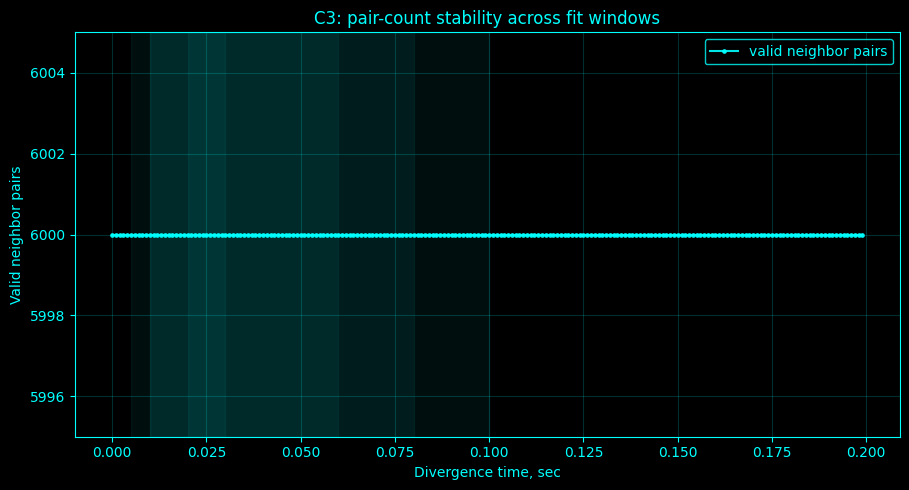

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_window_robustness_fast/plots/05_C3_pair_counts_by_k_C3_m10_tau8_tsep8_nS199_20260603_160047.png


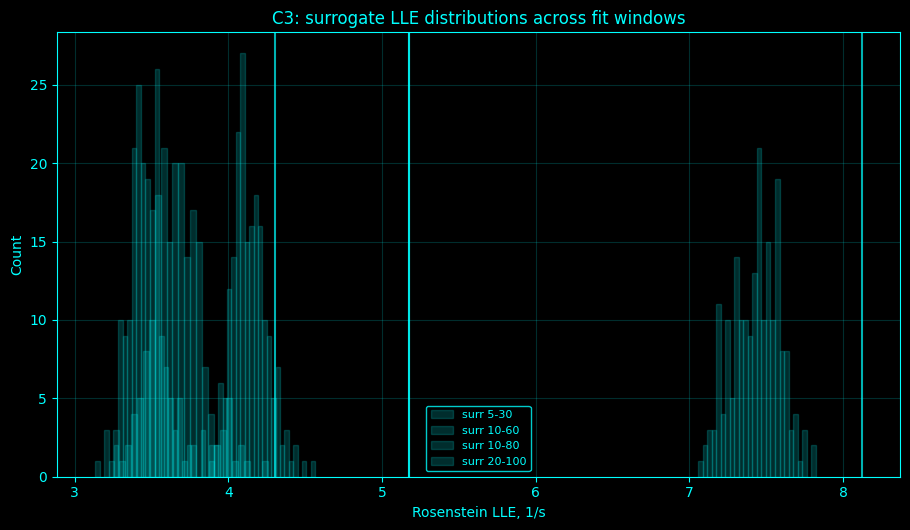

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_window_robustness_fast/plots/06_C3_surrogate_histograms_by_window_C3_m10_tau8_tsep8_nS199_20260603_160047.png

WINDOW ROBUSTNESS SUMMARY
channel  window_lo  window_hi window_label  window_lo_seconds  window_hi_seconds  LLE_obs  LLE_surr_mean  LLE_surr_std  LLE_surr_q025  LLE_surr_q975  delta_LLE  z_obs_vs_surrogates  p_one_surr_ge_obs  p_two_centered  fit_r2_obs  fit_rmse_obs  slope_obs_per_sample  fit_intercept_obs  pair_count_initial  fit_window_min_pair_count  fit_window_median_pair_count  pair_retention_percent  n_surrogates_requested  n_surrogates_completed  n_surrogates_failed  fs_eff  emb_dim  tau_eff  min_tsep_eff  kmax_eff  n_ref  k_query_base  iaaft_iters  iaaft_tol
     C3          5         30         5-30              0.005               0.03 8.121800       7.432570      0.154776       7.135871       7.732790   0.689230             4.453067              0.005           0.005    0.169146      0.13500

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.neighbors import NearestNeighbors

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    "Fp1","Fpz","Fp2","F7","F3","Fz","F4","F8","FC5","FC1","FC2","FC6",
    "M1","T7","C3","Cz","C4","T8","M2","CP5","CP1","CP2","CP6",
    "P7","P3","Pz","P4","P8","POz","O1","Oz","O2"
]

CHANNELS = ["C3"]

fs_original = 1000
start_time = 814.571
end_time = 921.515
start_index = int(start_time * fs_original)
end_index = int(end_time * fs_original)

emb_dim = 10
tau_original = 8
min_tsep_original = 8
kmax_original = 200
n_ref = 6000
k_query_base = 120
min_pairs_required = 100

windows_original = [
    (5, 30),
    (10, 60),
    (10, 80),
    (20, 100)
]

n_surrogates = 199
iaaft_iters = 200
iaaft_tol = 1e-4
iaaft_min_iters = 80
iaaft_check_every = 20
seed = 0
n_workers = min(6, max(1, (os.cpu_count() or 2) - 1))

decimate_factor = 1
max_samples = None
standardize = True
linear_detrend = False

results_dir = os.path.join(base_dir, "results", "rosenstein_window_robustness_fast")
plots_dir = os.path.join(results_dir, "plots")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
tag = f"C3_m{emb_dim}_tau{tau_original}_tsep{min_tsep_original}_nS{n_surrogates}_{timestamp}"

OUT_SUMMARY_CSV = os.path.join(results_dir, f"window_robustness_summary_{tag}.csv")
OUT_SURR_CSV = os.path.join(results_dir, f"window_robustness_surrogates_{tag}.csv")
OUT_CURVES_CSV = os.path.join(results_dir, f"window_robustness_curves_{tag}.csv")
OUT_QC_CSV = os.path.join(results_dir, f"window_robustness_qc_{tag}.csv")
OUT_NPZ = os.path.join(results_dir, f"window_robustness_arrays_{tag}.npz")
OUT_TXT = os.path.join(results_dir, f"window_robustness_report_{tag}.txt")

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.grid(True, color=ACCENT, alpha=0.18)

def style_legend(leg):
    if leg is not None:
        leg.get_frame().set_facecolor(BG)
        leg.get_frame().set_edgecolor(ACCENT)
        for text in leg.get_texts():
            text.set_color(ACCENT)

def save_show_close(fig, out_path, dpi=200):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)

def effective_sample_param(value_original, decimate_factor, minimum=1):
    return max(minimum, int(round(float(value_original) / float(decimate_factor))))

def effective_window(win_original, decimate_factor, kmax_eff):
    lo = effective_sample_param(win_original[0], decimate_factor, minimum=1)
    hi = effective_sample_param(win_original[1], decimate_factor, minimum=lo + 5)
    hi = min(hi, kmax_eff - 2)
    if hi <= lo + 4:
        hi = min(kmax_eff - 2, lo + 5)
    return int(lo), int(hi)

def linear_detrend_1d(x):
    x = np.asarray(x, dtype=float)
    t = np.arange(len(x), dtype=float)
    coef = np.polyfit(t, x, 1)
    return x - np.polyval(coef, t)

def preprocess_signal(x, fs, decimate_factor=1, max_samples=None, standardize=True, detrend=False):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = x[np.isfinite(x)]
    fs_eff = float(fs)
    if detrend:
        x = linear_detrend_1d(x)
    if decimate_factor is not None and decimate_factor > 1:
        try:
            from scipy.signal import decimate
            x = decimate(x, int(decimate_factor), ftype="iir", zero_phase=True)
        except Exception:
            x = x[::int(decimate_factor)]
        fs_eff = fs_eff / float(decimate_factor)
    if max_samples is not None and len(x) > max_samples:
        start = max(0, (len(x) - max_samples) // 2)
        stop = start + max_samples
        x = x[start:stop]
    if standardize:
        x = x - np.mean(x)
        x = x / (np.std(x) + 1e-12)
    return x, fs_eff

def load_eeg_array(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing EEG file: {path}")
    arr = np.load(path, allow_pickle=True)
    arr = np.asarray(arr, dtype=float)
    arr = np.squeeze(arr)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {arr.shape}")
    if arr.shape[0] == len(channel_names) and arr.shape[1] != len(channel_names):
        arr = arr.T
    if arr.shape[1] != len(channel_names):
        raise ValueError(f"Expected {len(channel_names)} channels, got shape {arr.shape}")
    return arr

def get_channels_to_run():
    if CHANNELS is None:
        return list(channel_names)
    missing = [ch for ch in CHANNELS if ch not in channel_names]
    if len(missing) > 0:
        raise ValueError(f"Unknown requested channels: {missing}")
    return list(CHANNELS)

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    n = len(x)
    M = n - (m - 1) * tau
    if M <= 2:
        raise ValueError(f"Embedding failed: len={n}, m={m}, tau={tau}")
    return np.column_stack([x[i * tau:i * tau + M] for i in range(m)])

def spectrum_relative_error_from_mag(y, target_mag):
    mag_y = np.abs(np.fft.rfft(y))
    return float(np.linalg.norm(mag_y - target_mag) / (np.linalg.norm(target_mag) + 1e-12))

def iaaft_surrogate_fast(x_sorted, target_mag, n, seed, n_iter=200, tol=1e-4, min_iter=80, check_every=20):
    rng = np.random.default_rng(seed)
    y = rng.permutation(x_sorted)
    final_err = np.nan
    used_iters = 0
    for it in range(1, n_iter + 1):
        Y = np.fft.rfft(y)
        phase = np.exp(1j * np.angle(Y))
        y = np.fft.irfft(target_mag * phase, n=n)
        ranks = np.argsort(y, kind="quicksort")
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
        used_iters = it
        if it >= min_iter and ((it % check_every == 0) or (it == n_iter)):
            final_err = spectrum_relative_error_from_mag(y, target_mag)
            if final_err <= tol:
                break
    if not np.isfinite(final_err):
        final_err = spectrum_relative_error_from_mag(y, target_mag)
    return y, final_err, used_iters

def rosenstein_curve_fixed_tsep(x, m, tau, min_tsep, n_ref, kmax, seed=0, k_query_base=120, min_pairs_required=100):
    rng = np.random.default_rng(seed)
    X = delay_embed_1d(x, m, tau)
    M = len(X)
    valid_max = M - kmax - 1
    if valid_max <= 10:
        raise ValueError(f"Too few embedded points for kmax={kmax}. Embedded M={M}.")
    all_idx = np.arange(valid_max)
    if len(all_idx) > n_ref:
        ref_idx = np.sort(rng.choice(all_idx, size=n_ref, replace=False))
    else:
        ref_idx = all_idx
    k_query = min(M, max(k_query_base, int(min_tsep) + 40, 4 * m + 20))
    nn = NearestNeighbors(n_neighbors=k_query, algorithm="auto").fit(X)
    _, inds = nn.kneighbors(X[ref_idx])
    nn_idx = np.full(len(ref_idx), -1, dtype=int)
    for a, i in enumerate(ref_idx):
        for cand in inds[a, 1:]:
            cand = int(cand)
            if cand >= valid_max:
                continue
            if abs(cand - int(i)) > int(min_tsep):
                nn_idx[a] = cand
                break
    keep = nn_idx >= 0
    ref_keep = ref_idx[keep]
    nn_keep = nn_idx[keep]
    pair_count_initial = int(len(ref_keep))
    if pair_count_initial < min_pairs_required:
        raise ValueError(f"Too few pairs after Theiler exclusion: {pair_count_initial}")
    ks = np.arange(kmax, dtype=int)
    log_div = np.full(kmax, np.nan, dtype=float)
    counts = np.zeros(kmax, dtype=int)
    for k in range(kmax):
        i = ref_keep + k
        j = nn_keep + k
        ok = (i < M) & (j < M)
        if not np.any(ok):
            continue
        dist = np.linalg.norm(X[i[ok]] - X[j[ok]], axis=1)
        dist = np.maximum(dist, 1e-12)
        log_div[k] = float(np.mean(np.log(dist)))
        counts[k] = int(np.sum(ok))
    return ks, log_div, counts, pair_count_initial

def fit_curve_window(ks, log_div, lo, hi, fs_eff):
    lo = int(lo)
    hi = int(hi)
    if hi <= lo:
        raise ValueError(f"Invalid window: lo={lo}, hi={hi}")
    if hi >= len(ks):
        raise ValueError(f"Window hi={hi} outside k length {len(ks)}")
    xw = ks[lo:hi + 1]
    yw = log_div[lo:hi + 1]
    ok = np.isfinite(xw) & np.isfinite(yw)
    xw = xw[ok]
    yw = yw[ok]
    if len(xw) < 5:
        raise ValueError(f"Too few finite points in window {lo}-{hi}")
    coef = np.polyfit(xw, yw, 1)
    yhat = np.polyval(coef, xw)
    ss_res = float(np.sum((yw - yhat) ** 2))
    ss_tot = float(np.sum((yw - np.mean(yw)) ** 2))
    r2 = float(1.0 - ss_res / (ss_tot + 1e-12))
    rmse = float(np.sqrt(np.mean((yw - yhat) ** 2)))
    slope_per_sample = float(coef[0])
    intercept = float(coef[1])
    lle_per_second = float(slope_per_sample * fs_eff)
    return slope_per_sample, intercept, lle_per_second, r2, rmse

def fit_all_windows(ks, log_div, windows, fs_eff):
    out = {}
    for lo, hi in windows:
        slope, intercept, lle, r2, rmse = fit_curve_window(ks, log_div, lo, hi, fs_eff)
        out[(int(lo), int(hi))] = {
            "slope_per_sample": slope,
            "intercept": intercept,
            "LLE": lle,
            "fit_r2": r2,
            "fit_rmse": rmse,
        }
    return out

def empirical_p_values(obs, svals):
    svals = np.asarray(svals, dtype=float)
    svals = svals[np.isfinite(svals)]
    if len(svals) == 0 or not np.isfinite(obs):
        return np.nan, np.nan, np.nan
    mu = float(np.mean(svals))
    sd = float(np.std(svals, ddof=1) + 1e-12) if len(svals) > 1 else 1e-12
    z = float((obs - mu) / sd)
    p_high = float((np.sum(svals >= obs) + 1.0) / (len(svals) + 1.0))
    p_two_centered = float((np.sum(np.abs(svals - mu) >= abs(obs - mu)) + 1.0) / (len(svals) + 1.0))
    return z, p_high, p_two_centered

def add_fit_line(ax, ks, log_div, lo, hi, slope, intercept, fs_eff, label, linestyle="-"):
    kfit = ks[lo:hi + 1]
    yfit = slope * kfit + intercept
    ax.plot(kfit / fs_eff, yfit, color=ACCENT, linestyle=linestyle, linewidth=2.0, alpha=0.9, label=label)

tau_eff = effective_sample_param(tau_original, decimate_factor, minimum=1)
min_tsep_eff = effective_sample_param(min_tsep_original, decimate_factor, minimum=1)
kmax_eff = effective_sample_param(kmax_original, decimate_factor, minimum=20)
windows_eff = [effective_window(w, decimate_factor, kmax_eff) for w in windows_original]
windows_eff = sorted(set(windows_eff), key=lambda w: (w[0], w[1]))

print("Effective parameters:")
print("  decimate_factor:", decimate_factor)
print("  tau_eff:", tau_eff)
print("  min_tsep_eff:", min_tsep_eff)
print("  kmax_eff:", kmax_eff)
print("  windows_eff:", windows_eff)
print("  n_surrogates:", n_surrogates)
print("  iaaft_iters:", iaaft_iters)
print("  n_workers:", n_workers)

EEG = load_eeg_array(eeg_path)
channels_to_run = get_channels_to_run()

print("\nLoaded EEG:", eeg_path, flush=True)
print("EEG shape:", EEG.shape, flush=True)
print("Channels:", channels_to_run, flush=True)

summary_records = []
surrogate_records = []
curve_records = []
qc_records = []

npz_payload = {
    "channels": np.array(channels_to_run, dtype=object),
    "tau_eff": np.array([tau_eff], dtype=int),
    "min_tsep_eff": np.array([min_tsep_eff], dtype=int),
    "kmax_eff": np.array([kmax_eff], dtype=int),
    "windows_eff": np.array(windows_eff, dtype=int),
    "windows_original": np.array(windows_original, dtype=int),
    "fs_original": np.array([fs_original], dtype=float),
    "decimate_factor": np.array([decimate_factor], dtype=int),
    "n_surrogates": np.array([n_surrogates], dtype=int),
    "iaaft_iters": np.array([iaaft_iters], dtype=int),
}

run_start = time.time()

for ch_num, channel in enumerate(channels_to_run, start=1):
    print(f"\n[{ch_num}/{len(channels_to_run)}] Channel {channel}", flush=True)
    ch_i = channel_names.index(channel)
    x_raw = EEG[start_index:end_index, ch_i].astype(float)
    x, fs_eff = preprocess_signal(
        x_raw,
        fs=fs_original,
        decimate_factor=decimate_factor,
        max_samples=max_samples,
        standardize=standardize,
        detrend=linear_detrend
    )
    print(f"Loaded {channel}: N={len(x)} | fs_eff={fs_eff:g} Hz | segment=[{start_time},{end_time}] s", flush=True)
    ks_obs, ld_obs, counts_obs, pair_count_obs = rosenstein_curve_fixed_tsep(
        x,
        m=emb_dim,
        tau=tau_eff,
        min_tsep=min_tsep_eff,
        n_ref=n_ref,
        kmax=kmax_eff,
        seed=seed,
        k_query_base=k_query_base,
        min_pairs_required=min_pairs_required
    )
    obs_fits = fit_all_windows(ks_obs, ld_obs, windows_eff, fs_eff)
    print("Observed window fits:", flush=True)
    for win, fit in obs_fits.items():
        print(f"  k={win[0]}-{win[1]} | LLE={fit['LLE']:.6g} 1/s | R2={fit['fit_r2']:.4f} | RMSE={fit['fit_rmse']:.4g}", flush=True)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    n = len(x)
    surr_lle_by_window = {win: [] for win in windows_eff}
    surr_curve_stack = []
    surr_errors = []
    surr_iters = []
    def surrogate_worker(s):
        y, final_err, used_iters = iaaft_surrogate_fast(
            x_sorted=x_sorted,
            target_mag=target_mag,
            n=n,
            seed=seed + 10000 * ch_num + s,
            n_iter=iaaft_iters,
            tol=iaaft_tol,
            min_iter=iaaft_min_iters,
            check_every=iaaft_check_every
        )
        ks_s, ld_s, counts_s, pair_count_s = rosenstein_curve_fixed_tsep(
            y,
            m=emb_dim,
            tau=tau_eff,
            min_tsep=min_tsep_eff,
            n_ref=n_ref,
            kmax=kmax_eff,
            seed=seed + 1000 + s,
            k_query_base=k_query_base,
            min_pairs_required=min_pairs_required
        )
        fits_s = fit_all_windows(ks_s, ld_s, windows_eff, fs_eff)
        return {
            "surrogate_index": int(s + 1),
            "final_error": float(final_err),
            "used_iters": int(used_iters),
            "ks": ks_s,
            "log_div": ld_s,
            "counts": counts_s,
            "pair_count": int(pair_count_s),
            "fits": fits_s,
        }
    print(f"Running {n_surrogates} IAAFT surrogates with {n_workers} workers...", flush=True)
    completed = 0
    failed = 0
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(surrogate_worker, s) for s in range(n_surrogates)]
        for fut in as_completed(futures):
            try:
                res = fut.result()
            except Exception as e:
                failed += 1
                print(f"  surrogate ERROR: {type(e).__name__}: {e}", flush=True)
                continue
            sidx = int(res["surrogate_index"])
            surr_errors.append(res["final_error"])
            surr_iters.append(res["used_iters"])
            surr_curve_stack.append(res["log_div"])
            for win in windows_eff:
                fit = res["fits"][win]
                surr_lle_by_window[win].append(fit["LLE"])
                surrogate_records.append({
                    "channel": channel,
                    "surrogate_index": sidx,
                    "window_lo": int(win[0]),
                    "window_hi": int(win[1]),
                    "window_label": f"{win[0]}-{win[1]}",
                    "LLE_surr": float(fit["LLE"]),
                    "slope_per_sample": float(fit["slope_per_sample"]),
                    "intercept": float(fit["intercept"]),
                    "fit_r2": float(fit["fit_r2"]),
                    "fit_rmse": float(fit["fit_rmse"]),
                    "pair_count": int(res["pair_count"]),
                    "iaaft_final_spectrum_relative_error": float(res["final_error"]),
                    "iaaft_iters_used": int(res["used_iters"]),
                })
            completed += 1
            if completed % 25 == 0 or completed + failed == n_surrogates:
                print(f"  completed {completed}/{n_surrogates} surrogates | failed={failed}", flush=True)
    for win in windows_eff:
        fit_obs = obs_fits[win]
        obs_val = float(fit_obs["LLE"])
        svals = np.asarray(surr_lle_by_window[win], dtype=float)
        svals = svals[np.isfinite(svals)]
        if len(svals) > 0:
            z, p_one, p_two = empirical_p_values(obs_val, svals)
            surr_mean = float(np.mean(svals))
            surr_std = float(np.std(svals, ddof=1)) if len(svals) > 1 else 0.0
            surr_q025 = float(np.percentile(svals, 2.5))
            surr_q975 = float(np.percentile(svals, 97.5))
        else:
            z, p_one, p_two = np.nan, np.nan, np.nan
            surr_mean, surr_std, surr_q025, surr_q975 = np.nan, np.nan, np.nan, np.nan
        fit_counts = counts_obs[win[0]:win[1] + 1]
        summary_records.append({
            "channel": channel,
            "window_lo": int(win[0]),
            "window_hi": int(win[1]),
            "window_label": f"{win[0]}-{win[1]}",
            "window_lo_seconds": float(win[0] / fs_eff),
            "window_hi_seconds": float(win[1] / fs_eff),
            "LLE_obs": obs_val,
            "LLE_surr_mean": surr_mean,
            "LLE_surr_std": surr_std,
            "LLE_surr_q025": surr_q025,
            "LLE_surr_q975": surr_q975,
            "delta_LLE": float(obs_val - surr_mean) if np.isfinite(surr_mean) else np.nan,
            "z_obs_vs_surrogates": float(z),
            "p_one_surr_ge_obs": float(p_one),
            "p_two_centered": float(p_two),
            "fit_r2_obs": float(fit_obs["fit_r2"]),
            "fit_rmse_obs": float(fit_obs["fit_rmse"]),
            "slope_obs_per_sample": float(fit_obs["slope_per_sample"]),
            "fit_intercept_obs": float(fit_obs["intercept"]),
            "pair_count_initial": int(pair_count_obs),
            "fit_window_min_pair_count": int(np.nanmin(fit_counts)) if len(fit_counts) else -1,
            "fit_window_median_pair_count": float(np.nanmedian(fit_counts)) if len(fit_counts) else np.nan,
            "pair_retention_percent": float(100.0 * np.nanmin(fit_counts) / max(pair_count_obs, 1)) if len(fit_counts) else np.nan,
            "n_surrogates_requested": int(n_surrogates),
            "n_surrogates_completed": int(len(svals)),
            "n_surrogates_failed": int(failed),
            "fs_eff": float(fs_eff),
            "emb_dim": int(emb_dim),
            "tau_eff": int(tau_eff),
            "min_tsep_eff": int(min_tsep_eff),
            "kmax_eff": int(kmax_eff),
            "n_ref": int(n_ref),
            "k_query_base": int(k_query_base),
            "iaaft_iters": int(iaaft_iters),
            "iaaft_tol": float(iaaft_tol),
        })
    surr_curve_stack = np.asarray(surr_curve_stack, dtype=float)
    for k in range(kmax_eff):
        rec = {
            "channel": channel,
            "k": int(k),
            "time_seconds": float(k / fs_eff),
            "observed_log_div": float(ld_obs[k]),
            "observed_count": int(counts_obs[k]),
        }
        if surr_curve_stack.size > 0:
            rec.update({
                "surrogate_mean_log_div": float(np.nanmean(surr_curve_stack[:, k])),
                "surrogate_std_log_div": float(np.nanstd(surr_curve_stack[:, k])),
                "surrogate_q025_log_div": float(np.nanpercentile(surr_curve_stack[:, k], 2.5)),
                "surrogate_q975_log_div": float(np.nanpercentile(surr_curve_stack[:, k], 97.5)),
            })
        else:
            rec.update({
                "surrogate_mean_log_div": np.nan,
                "surrogate_std_log_div": np.nan,
                "surrogate_q025_log_div": np.nan,
                "surrogate_q975_log_div": np.nan,
            })
        curve_records.append(rec)
    qc_records.append({
        "channel": channel,
        "n_samples_used": int(len(x)),
        "fs_eff": float(fs_eff),
        "duration_seconds_used": float(len(x) / fs_eff),
        "x_mean": float(np.mean(x)),
        "x_std": float(np.std(x)),
        "x_min": float(np.min(x)),
        "x_q01": float(np.percentile(x, 1)),
        "x_q25": float(np.percentile(x, 25)),
        "x_median": float(np.median(x)),
        "x_q75": float(np.percentile(x, 75)),
        "x_q99": float(np.percentile(x, 99)),
        "x_max": float(np.max(x)),
        "observed_pair_count": int(pair_count_obs),
        "mean_iaaft_error": float(np.mean(surr_errors)) if len(surr_errors) else np.nan,
        "max_iaaft_error": float(np.max(surr_errors)) if len(surr_errors) else np.nan,
        "mean_iaaft_iters_used": float(np.mean(surr_iters)) if len(surr_iters) else np.nan,
        "max_iaaft_iters_used": int(np.max(surr_iters)) if len(surr_iters) else -1,
        "surrogates_completed": int(completed),
        "surrogates_failed": int(failed),
    })
    npz_payload[f"{channel}_ks"] = ks_obs
    npz_payload[f"{channel}_obs_log_div"] = ld_obs
    npz_payload[f"{channel}_obs_counts"] = counts_obs
    if surr_curve_stack.size > 0:
        npz_payload[f"{channel}_surr_log_div"] = surr_curve_stack
    for win in windows_eff:
        npz_payload[f"{channel}_surr_lle_window_{win[0]}_{win[1]}"] = np.asarray(surr_lle_by_window[win], dtype=float)
    summary_ch = pd.DataFrame([r for r in summary_records if r["channel"] == channel]).sort_values(["window_lo", "window_hi"])
    fig, ax = plt.subplots(figsize=(9.6, 5.8), facecolor=BG)
    style_ax(ax)
    if surr_curve_stack.size > 0:
        s_mean = np.nanmean(surr_curve_stack, axis=0)
        s_q025 = np.nanpercentile(surr_curve_stack, 2.5, axis=0)
        s_q975 = np.nanpercentile(surr_curve_stack, 97.5, axis=0)
        ax.fill_between(ks_obs / fs_eff, s_q025, s_q975, color=ACCENT, alpha=0.12, label="surrogate 95% band")
        ax.plot(ks_obs / fs_eff, s_mean, color=ACCENT, linestyle="--", linewidth=1.8, alpha=0.75, label="surrogate mean")
    ax.plot(ks_obs / fs_eff, ld_obs, color=ACCENT, marker="o", markersize=2.5, linewidth=1.4, alpha=0.9, label="observed")
    linestyles = ["-", "--", ":", "-."]
    for wi, win in enumerate(windows_eff):
        fit = obs_fits[win]
        add_fit_line(
            ax,
            ks_obs,
            ld_obs,
            win[0],
            win[1],
            fit["slope_per_sample"],
            fit["intercept"],
            fs_eff,
            label=f"fit {win[0]}-{win[1]}: LLE={fit['LLE']:.2f}",
            linestyle=linestyles[wi % len(linestyles)]
        )
        ax.axvspan(win[0] / fs_eff, win[1] / fs_eff, color=ACCENT, alpha=0.04)
    ax.set_title(f"{channel}: Rosenstein divergence with tested fit windows")
    ax.set_xlabel("Divergence time, sec")
    ax.set_ylabel("Mean log distance")
    leg = ax.legend(loc="best", fontsize=8)
    style_legend(leg)
    plot_path = os.path.join(plots_dir, f"01_{channel}_divergence_fit_windows_{tag}.png")
    save_show_close(fig, plot_path)
    fig, ax = plt.subplots(figsize=(9.2, 5.4), facecolor=BG)
    style_ax(ax)
    xpos = np.arange(len(summary_ch))
    labels = summary_ch["window_label"].values
    ax.errorbar(
        xpos,
        summary_ch["LLE_surr_mean"],
        yerr=summary_ch["LLE_surr_std"],
        color=ACCENT,
        linestyle="--",
        marker="s",
        capsize=4,
        linewidth=1.8,
        alpha=0.75,
        label="surrogate mean ± std"
    )
    ax.plot(
        xpos,
        summary_ch["LLE_obs"],
        color=ACCENT,
        marker="o",
        linewidth=2.4,
        label="observed LLE"
    )
    for i, row in summary_ch.iterrows():
        ax.text(
            list(summary_ch.index).index(i),
            row["LLE_obs"],
            f"{row['LLE_obs']:.2f}",
            color=ACCENT,
            ha="center",
            va="bottom",
            fontsize=8
        )
    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_title(f"{channel}: observed LLE vs fit window")
    ax.set_xlabel("Fit window, k samples")
    ax.set_ylabel("Rosenstein LLE, 1/s")
    leg = ax.legend()
    style_legend(leg)
    plot_path = os.path.join(plots_dir, f"02_{channel}_LLE_vs_fit_window_{tag}.png")
    save_show_close(fig, plot_path)
    fig, ax = plt.subplots(figsize=(9.2, 5.4), facecolor=BG)
    style_ax(ax)
    ax.bar(
        xpos,
        summary_ch["delta_LLE"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.8,
        label="observed − surrogate mean"
    )
    ax.errorbar(
        xpos,
        summary_ch["delta_LLE"],
        yerr=summary_ch["LLE_surr_std"],
        fmt="none",
        ecolor=ACCENT,
        elinewidth=1.5,
        capsize=4,
        alpha=0.8
    )
    ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.65)
    for i, row in summary_ch.reset_index(drop=True).iterrows():
        ax.text(
            i,
            row["delta_LLE"],
            f"z={row['z_obs_vs_surrogates']:.2f}\np={row['p_one_surr_ge_obs']:.4g}",
            color=ACCENT,
            ha="center",
            va="bottom" if row["delta_LLE"] >= 0 else "top",
            fontsize=8
        )
    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_title(f"{channel}: window-dependent LLE effect vs surrogates")
    ax.set_xlabel("Fit window, k samples")
    ax.set_ylabel("Observed LLE − surrogate mean LLE, 1/s")
    leg = ax.legend()
    style_legend(leg)
    plot_path = os.path.join(plots_dir, f"03_{channel}_LLE_effect_size_by_window_{tag}.png")
    save_show_close(fig, plot_path)
    fig, ax = plt.subplots(figsize=(9.2, 5.4), facecolor=BG)
    style_ax(ax)
    ax.bar(
        xpos,
        summary_ch["fit_r2_obs"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.75
    )
    ax.axhline(0.80, color=ACCENT, linestyle="--", alpha=0.65, label="good-fit guide: R²=0.80")
    ax.axhline(0.50, color=ACCENT, linestyle=":", alpha=0.65, label="weak-fit guide: R²=0.50")
    for i, row in summary_ch.reset_index(drop=True).iterrows():
        ax.text(
            i,
            row["fit_r2_obs"] + 0.025,
            f"R²={row['fit_r2_obs']:.3f}\nRMSE={row['fit_rmse_obs']:.3g}",
            color=ACCENT,
            ha="center",
            va="bottom",
            fontsize=8
        )
    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{channel}: linear-fit quality by window")
    ax.set_xlabel("Fit window, k samples")
    ax.set_ylabel("Observed fit R²")
    leg = ax.legend()
    style_legend(leg)
    plot_path = os.path.join(plots_dir, f"04_{channel}_fit_quality_by_window_{tag}.png")
    save_show_close(fig, plot_path)
    fig, ax = plt.subplots(figsize=(9.2, 5.0), facecolor=BG)
    style_ax(ax)
    ax.plot(
        ks_obs / fs_eff,
        counts_obs,
        color=ACCENT,
        marker="o",
        markersize=2.4,
        linewidth=1.5,
        alpha=0.9,
        label="valid neighbor pairs"
    )
    for win in windows_eff:
        ax.axvspan(win[0] / fs_eff, win[1] / fs_eff, color=ACCENT, alpha=0.06)
    cmin = float(np.nanmin(counts_obs))
    cmax = float(np.nanmax(counts_obs))
    pad = max(5.0, 0.03 * max(abs(cmax - cmin), 1.0))
    ax.set_ylim(cmin - pad, cmax + pad)
    ax.set_title(f"{channel}: pair-count stability across fit windows")
    ax.set_xlabel("Divergence time, sec")
    ax.set_ylabel("Valid neighbor pairs")
    leg = ax.legend()
    style_legend(leg)
    plot_path = os.path.join(plots_dir, f"05_{channel}_pair_counts_by_k_{tag}.png")
    save_show_close(fig, plot_path)
    fig, ax = plt.subplots(figsize=(9.2, 5.4), facecolor=BG)
    style_ax(ax)
    for win in windows_eff:
        svals = np.asarray(surr_lle_by_window[win], dtype=float)
        ax.hist(
            svals,
            bins=min(26, max(10, int(np.sqrt(len(svals)) * 2))),
            alpha=0.18,
            color=ACCENT,
            edgecolor=ACCENT,
            label=f"surr {win[0]}-{win[1]}"
        )
        ax.axvline(obs_fits[win]["LLE"], color=ACCENT, linewidth=1.5, alpha=0.7)
    ax.set_title(f"{channel}: surrogate LLE distributions across fit windows")
    ax.set_xlabel("Rosenstein LLE, 1/s")
    ax.set_ylabel("Count")
    leg = ax.legend(fontsize=8)
    style_legend(leg)
    plot_path = os.path.join(plots_dir, f"06_{channel}_surrogate_histograms_by_window_{tag}.png")
    save_show_close(fig, plot_path)

summary_df = pd.DataFrame(summary_records)
surrogate_df = pd.DataFrame(surrogate_records)
curve_df = pd.DataFrame(curve_records)
qc_df = pd.DataFrame(qc_records)

summary_df.to_csv(OUT_SUMMARY_CSV, index=False)
surrogate_df.to_csv(OUT_SURR_CSV, index=False)
curve_df.to_csv(OUT_CURVES_CSV, index=False)
qc_df.to_csv(OUT_QC_CSV, index=False)

npz_payload["summary_json"] = np.array([summary_df.to_json(orient="records")], dtype=object)
npz_payload["surrogate_json"] = np.array([surrogate_df.to_json(orient="records")], dtype=object)
npz_payload["curve_json"] = np.array([curve_df.to_json(orient="records")], dtype=object)
npz_payload["qc_json"] = np.array([qc_df.to_json(orient="records")], dtype=object)

np.savez_compressed(OUT_NPZ, **npz_payload)

with open(OUT_TXT, "w") as f:
    f.write("Fast Rosenstein Fit-Window Robustness with IAAFT Surrogates\n")
    f.write("==========================================================\n\n")
    f.write(f"timestamp={timestamp}\n")
    f.write(f"eeg_path={eeg_path}\n")
    f.write(f"channels={channels_to_run}\n")
    f.write(f"segment=[{start_time},{end_time}] sec\n")
    f.write(f"fs_original={fs_original}\n")
    f.write(f"decimate_factor={decimate_factor}\n")
    f.write(f"emb_dim={emb_dim}\n")
    f.write(f"tau_eff={tau_eff}\n")
    f.write(f"min_tsep_eff={min_tsep_eff}\n")
    f.write(f"kmax_eff={kmax_eff}\n")
    f.write(f"windows_eff={windows_eff}\n")
    f.write(f"n_ref={n_ref}\n")
    f.write(f"k_query_base={k_query_base}\n")
    f.write(f"n_surrogates={n_surrogates}\n")
    f.write(f"iaaft_iters={iaaft_iters}\n")
    f.write(f"iaaft_tol={iaaft_tol}\n")
    f.write(f"n_workers={n_workers}\n\n")
    f.write("Summary:\n")
    f.write(summary_df.to_string(index=False))
    f.write("\n\nQC:\n")
    f.write(qc_df.to_string(index=False))

print("\n==============================")
print("WINDOW ROBUSTNESS SUMMARY")
print("==============================")
print(summary_df.to_string(index=False))

print("\nQC:")
print(qc_df.to_string(index=False))

print("\nSaved outputs:")
print("Summary CSV:", OUT_SUMMARY_CSV)
print("Surrogate CSV:", OUT_SURR_CSV)
print("Curve CSV:", OUT_CURVES_CSV)
print("QC CSV:", OUT_QC_CSV)
print("NPZ:", OUT_NPZ)
print("TXT:", OUT_TXT)
print("Plots:", plots_dir)
print(f"Elapsed: {(time.time() - run_start) / 60:.2f} minutes")
print("Done.")

### Kantz LLE + IAAFT surrogate comparison

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block provides a reproducible Kantz-method workflow for estimating the largest Lyapunov exponent (LLE) from an EEG segment and comparing that estimate
            against an ensemble of IAAFT surrogates. It loads a scalar time series from one channel (<code>C3</code>), standardizes the signal, reconstructs the
            delay-embedded state space, computes the Kantz mean-log-divergence curve using multiple neighbors per reference point, fits a linear region of that curve to
            estimate the observed LLE, and then repeats the same procedure on <code>199</code> IAAFT surrogates. The key intent is to test whether the observed
            divergence rate is unusually large relative to surrogate signals that preserve the amplitude distribution and approximately preserve the power spectrum.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            The Kantz method estimates the largest Lyapunov exponent by following the average divergence of local neighborhoods in reconstructed phase space. For a
            reference point <code>x_i</code> and a set of valid neighbors <code>\(\mathcal{N}(i)\)</code>, the average future divergence after <code>k</code> steps is
            summarized by:
        </p>
        \[
            y(k)=\left\langle \log\left(\frac{1}{|\mathcal{N}(i)|}\sum_{j\in\mathcal{N}(i)} \|X_{i+k}-X_{j+k}\|\right)\right\rangle_i
        \]
        <p>
            In a regime of exponential divergence, this behaves approximately linearly:
        </p>
        \[
            y(k)\approx c+\lambda k\Delta t
        \]
        <p>
            where <code>\(\lambda\)</code> is the largest Lyapunov exponent and <code>\(\Delta t = 1/fs\)</code>. The code fits <code>y(k)</code> over a selected
            window <code>k=[10,60]</code> samples, estimates the slope per sample, and multiplies by the sampling rate to express the final LLE in physical units of
            <code>1/s</code>.
        </p>
        <h2>Delay Embedding and Neighbor Structure</h2>
        <p>
            The scalar signal is reconstructed into delay vectors using embedding dimension <code>m=10</code> and delay <code>\(\tau=8\)</code>:
        </p>
        \[
            X_t=[x_t,\;x_{t+\tau},\;x_{t+2\tau},\;\dots,\;x_{t+(m-1)\tau}]
        \]
        <p>
            Unlike Rosenstein-style estimation, which typically uses one nearest neighbor per reference point, the Kantz method averages divergence over
            <code>K_use=20</code> neighbors per reference. This can make the divergence curve more stable by reducing sensitivity to any single neighbor pairing. The
            code first requests up to <code>K_search=400</code> candidate neighbors, then filters them according to self-exclusion, Theiler separation, and forward
            index validity before keeping the first <code>K_use</code> usable neighbors.
        </p>
        <h2>Critical Index-Safety Fix</h2>
        <p>
            A central feature of this implementation is the explicit requirement that both the reference index <code>i</code> and every chosen neighbor index
            <code>j</code> must remain valid for all forward evolution steps up to <code>kmax_eff</code>. In other words, both must satisfy
            <code>i + kmax_eff &lt; M</code> and <code>j + kmax_eff &lt; M</code>. This prevents out-of-bounds access when evaluating
            <code>X[i+k]</code> and <code>X[j+k]</code> and ensures that every pair contributes valid future trajectories throughout the full divergence calculation.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Load</b> the selected EEG channel and extract the target time segment.</li>
                <li><b>Standardize</b> the scalar signal with a z-score transform.</li>
                <li><b>Embed</b> the signal in delay-coordinate space with <code>m=10</code> and <code>tau=8</code>.</li>
                <li><b>Select</b> reference points and candidate neighbors in embedded space using nearest-neighbor search.</li>
                <li><b>Filter</b> neighbors by self-removal, Theiler separation, and forward-validity constraints.</li>
                <li><b>Compute</b> the Kantz mean-log-divergence curve by averaging log distances across neighbors and reference points.</li>
                <li><b>Fit</b> the divergence curve over the chosen window <code>k=[10,60]</code> to estimate the observed LLE.</li>
                <li><b>Generate</b> <code>199</code> IAAFT surrogates and repeat the identical Kantz analysis for each surrogate.</li>
                <li><b>Compute</b> a one-sided empirical p-value comparing surrogate LLEs against the observed LLE.</li>
                <li><b>Save</b> structured outputs, summary text, divergence and histogram plots, and the full surrogate result array.</li>
            </ol>
            This makes the script both an LLE-estimation workflow and a surrogate-based significance test under fixed embedding and neighbor-selection rules.
        </p>
        <h2>IAAFT Surrogates and Null Model</h2>
        <p>
            The surrogate generator uses the Iterative Amplitude Adjusted Fourier Transform method. Each surrogate is initialized from a random permutation of the
            original signal and then iteratively alternates between:
            <ul>
                <li><b>Spectrum enforcement:</b> replacing the surrogate Fourier magnitudes with the original magnitudes while keeping surrogate phases,</li>
                <li><b>Amplitude enforcement:</b> rank-order remapping so the surrogate matches the original amplitude distribution.</li>
            </ul>
            The resulting surrogates preserve the marginal distribution exactly and approximate the original power spectrum, while disrupting nonlinear temporal
            structure. This provides a constrained null model for testing whether the observed Kantz LLE is unusually large.
        </p>
        <h2>Hypothesis Test and Interpretability</h2>
        <p>
            After computing the observed LLE and the surrogate LLE ensemble, the code evaluates a one-sided empirical p-value:
        </p>
        \[
            p_{\mathrm{one}}=\frac{\#\{\,\lambda_{\mathrm{surr}}\ge\lambda_{\mathrm{obs}}\,\}+1}{n_{\mathrm{surr}}+1}
        \]
        <p>
            This quantity measures how often a surrogate produces an LLE at least as large as the observed signal. A small value indicates that the observed divergence
            rate is unusually large relative to the surrogate null distribution, providing evidence that the original signal contains stronger divergence structure than
            expected from a linearized surrogate process with matched spectrum and histogram.
        </p>
        <h2>Axis Semantics</h2>
        <p>
            <ul>
                <li><b>x-axis in the divergence plot:</b> forward step index <code>k</code> in samples.</li>
                <li><b>y-axis in the divergence plot:</b> mean log distance across reference-neighbor ensembles.</li>
                <li><b>Shaded region:</b> the fit window <code>k=[10,60]</code> used for regression.</li>
                <li><b>Fit line:</b> the linear approximation whose slope determines the observed LLE.</li>
                <li><b>x-axis in the histogram plot:</b> surrogate LLE values in <code>1/s</code>.</li>
                <li><b>Vertical line in the histogram:</b> the observed Kantz LLE.</li>
            </ul>
            Together, these figures show both the geometry of divergence in reconstructed space and the position of the observed estimate relative to the surrogate
            null distribution.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This view is most useful for:
            <ul>
                <li>Estimating the largest Lyapunov exponent with neighborhood averaging rather than single-neighbor divergence,</li>
                <li>Testing whether the observed LLE is unusually large compared with IAAFT surrogates,</li>
                <li>Checking that neighbor selection remains valid for all forward evolution steps,</li>
                <li>Saving an auditable record of divergence curves, surrogate distributions, and fitted results.</li>
            </ul>
            In practice, a positive observed LLE together with a small one-sided surrogate p-value suggests stronger instability or divergence structure than would be
            expected under the chosen surrogate null model. However, as with all surrogate-based dynamical tests, this supports nontrivial structure rather than proving
            deterministic chaos by itself.
        </p>
        <h2>Reproducibility Tip</h2>
        <p>
            The script fixes the random seed, records the channel, segment, embedding parameters, Theiler separation, neighbor settings, surrogate count, and fit window
            in the saved outputs, and stores both raw arrays and human-readable summary text. Because the forward-validity constraints are enforced explicitly for both
            references and neighbors, the resulting Kantz analysis can be rerun reliably without hidden indexing failures.
        </p>
    </div>
</div>